In [ ]:
# 加载图像
from torch.utils.data import Dataset
from torchvision import transforms
import torch
import os
from pathlib import Path
import numpy as np
from PIL import Image
from diffusers import AutoencoderKL, DDPMScheduler, DiffusionPipeline, UNet2DConditionModel
from transformers.models.clip.modeling_clip import CLIPVisionModelWithProjection


resample_interpolation = transforms.InterpolationMode.BILINEAR
center_crop = True
target_image_path="/data1/humw/Datasets/VGGFace2/n000050/set_B/0012_01.png"
resolution = 512
eot = 0
torch_dtype = torch.bfloat16
pretrained_model_name_or_path="/data1/humw/Pretrains/stable-diffusion-v1-5"
revision="bf16"

vae = AutoencoderKL.from_pretrained(
        pretrained_model_name_or_path, subfolder="vae", revision=revision).cuda().to(dtype=torch_dtype)

vae.requires_grad_(False)

ipadapter_path = "/data1/humw/Pretrains/IP-Adapter/models/image_encoder"
ipadapter = CLIPVisionModelWithProjection.from_pretrained(ipadapter_path).cuda().to(dtype=torch_dtype).requires_grad_(False)
        
if eot == 0: # 不用eot，不过ipadapter因为尺寸不一致不得不用eot
    trans_224 = [
        transforms.Resize(224, interpolation=resample_interpolation),
        transforms.CenterCrop(224) if center_crop else transforms.RandomCrop(224),
    ]
    trans_224 = transforms.Compose(trans_224)
else: # 使用eot
    resample_interpolation = transforms.InterpolationMode.BILINEAR
        
    train_aug_224 = [
        transforms.Resize(224, interpolation=resample_interpolation),
        transforms.CenterCrop(224) if center_crop else transforms.RandomCrop(224),
    ]
    tensorize_and_normalize = [
        transforms.Normalize([0.5*255]*3,[0.5*255]*3),
    ]
    trans_224 = train_aug_224 + tensorize_and_normalize
    trans_224 = transforms.Compose(trans_224)
    print("all_trans:{}".format(trans_224))
    
    train_aug_512 = [
        transforms.Resize(512, interpolation=resample_interpolation),
        transforms.CenterCrop(512) if center_crop else transforms.RandomCrop(512),
    ]
    trans_512 = train_aug_512 + tensorize_and_normalize
    trans_512 = transforms.Compose(trans_512)
    print("all_trans:{}".format(trans_512))
    pgd_eps = 16.0
    pgd_alpha = 16/10 # 默认是阈值的1/10


target_image_path = Path(target_image_path)
assert target_image_path.is_file(), f"Target image path {target_image_path} does not exist"

target_image = Image.open(target_image_path).convert("RGB").resize((resolution, resolution))
target_image = np.array(target_image)[None].transpose(0, 3, 1, 2)
if eot == 0:
    target_image_tensor = torch.from_numpy(target_image).to("cuda", dtype=torch_dtype) / 127.5 - 1.0
    target_latent_tensor = (
        vae.encode(target_image_tensor).latent_dist.sample().to(dtype=torch_dtype) * vae.config.scaling_factor
    )
else:
    # import pdb; pdb.set_trace()
    target_image_tensor = torch.from_numpy(target_image).to("cuda", dtype=torch_dtype)
    target_latent_tensor = (
        vae.encode(trans_512(target_image_tensor)).latent_dist.sample().to(dtype=torch_dtype) * vae.config.scaling_factor
    )

# get ipadapter target latent tensor
ipadapter_target_tensor  = ipadapter(trans_224(target_image_tensor), output_hidden_states=True).hidden_states[-2].detach()

In [ ]:
# 将不同特征放缩到相同尺度，然后计算余弦相似度 NKO 这条路行不通，因为特征的尺度相差太大
print(target_latent_tensor.shape)
print(ipadapter_target_tensor.shape)

In [ ]:
# 获取不同模型上对抗样本的梯度，然后计算余弦相似度
## 思路：直接获取第一轮各个模型上的图像梯度（预先损失），然后计算模型梯度之间的余弦相似度
# 完整SD模型：SD14、SD15、SD21、SDXL、SD3
# 图像编码器：ipadapter_clip, photomaker_clip, clip-vit-large-patch14, SD14_VAE, SD15_VAE, SD21_VAE, SDXL_VAE
# 两张对比图：一张是agm前的梯度热力图，一张是agm后的梯度热力图

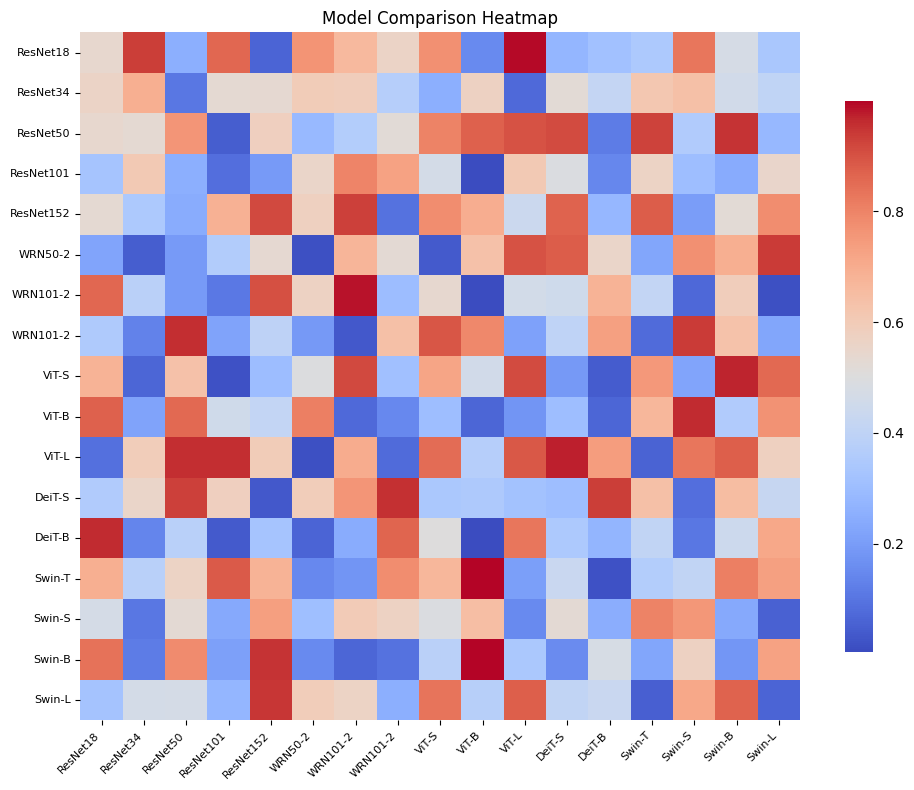

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models = ["ResNet18", "ResNet34", "ResNet50", "ResNet101", "ResNet152",
          "WRN50-2", "WRN101-2", "WRN101-2", "ViT-S", "ViT-B", "ViT-L",
          "DeiT-S", "DeiT-B", "Swin-T", "Swin-S", "Swin-B", "Swin-L"]
data = np.random.rand(len(models), len(models))  # 随机生成数据

# 创建热图
plt.figure(figsize=(10, 8))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models, yticklabels=models, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# non target 第一轮：
# alpha:  tensor([9.9994e-01, 1.0799e-05, 4.4424e-05], device='cuda:0')
# losses_dict: {'unet': tensor(-0.9688, device='cuda:0', dtype=torch.bfloat16, grad_fn=<NegBackward0>), 'vae': tensor(-0.8633, device='cuda:0', dtype=torch.bfloat16, grad_fn=<NegBackward0>), 'ipadapter': tensor(-0.7812, device='cuda:0', dtype=torch.bfloat16, grad_fn=<NegBackward0>)}
# before agm: 
# cos_sim_matrix: 
#  [[ 8.57990444e-01  9.30835307e-02  1.19683042e-04]
#  [ 9.30835307e-02  1.00000000e+00 -4.69329389e-04]
#  [ 1.19683042e-04 -4.69329389e-04  8.75000000e-01]]
 # after agm: 
# alphas_cos_sim_matrix: 
#  [[ 8.57990444e-01  9.02740983e-04 -3.00288462e-04]
#  [ 9.02740983e-04  5.05675853e-05 -9.07873016e-07]
#  [-3.00288462e-04 -9.07873016e-07  2.71712523e-02]]


# before agm: 
# cos_sim_matrix: 

# 余弦相似度似乎有问题，自己和自己都得不到1: 就是数值太小了，误差就会很大
# agm代码有问题，alphas之和不是1： 没有问题，和是1

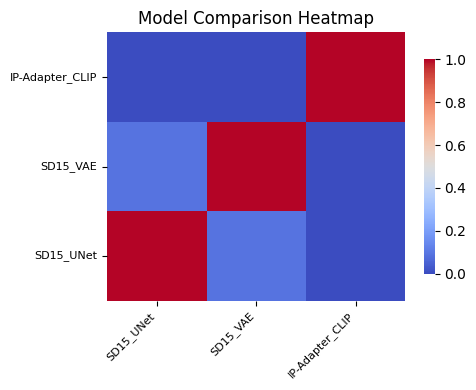

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models_x = ["SD15_UNet", "SD15_VAE", "IP-Adapter_CLIP"]
models_y = [ "IP-Adapter_CLIP", "SD15_VAE", "SD15_UNet",]
data = [[1.19683042e-04, -4.69329389e-04, 1], 
        [9.30835307e-02, 1, -4.69329389e-04], 
        [1, 9.30835307e-02, 1.19683042e-04],]

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

# after agm: 
# alphas_cos_sim_matrix: 

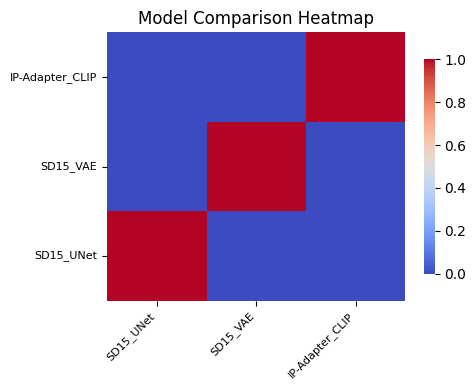

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models_x = ["SD15_UNet", "SD15_VAE", "IP-Adapter_CLIP"]
models_y = [ "IP-Adapter_CLIP", "SD15_VAE", "SD15_UNet",]
data =  [[-3.00288462e-04, -9.07873016e-07, 1],
         [ 9.02740983e-04,  1, -9.07873016e-07],
         [1 ,9.02740983e-04 ,-3.00288462e-04],]

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# mist 第一轮：
# alpha:  tensor([7.5176e-01, 2.4824e-01, 4.0629e-07], device='cuda:0')
# losses_dict: {'unet': tensor(-0.0052, device='cuda:0', dtype=torch.bfloat16, grad_fn=<MeanBackward0>), 'vae': tensor(0.0537, device='cuda:0', dtype=torch.bfloat16, grad_fn=<MeanBackward0>), 'ipadapter': tensor(0.1235, device='cuda:0', dtype=torch.bfloat16, grad_fn=<MeanBackward0>)}
# cos_sim_matrix: 
#  [[ 1.00000000e+00  8.16762447e-01 -3.80436395e-04]
#  [ 8.16762447e-01  1.00000000e+00  1.52671870e-04]
#  [-3.80436395e-04  1.52671870e-04  8.75000000e-01]]
# alphas_cos_sim_matrix: 
#  [[ 1.00000000e+00  8.16762388e-01 -1.66707321e-06]
#  [ 8.16762388e-01  1.00000000e+00 -5.44794091e-07]
#  [-1.66707321e-06 -5.44794091e-07  4.76952948e-07]]
# alpha:  tensor([7.5831e-01, 2.4169e-01, 4.1717e-07], device='cuda:0')
# cos_sim_matrix: 
#  [[ 1.00000000e+00  8.16592634e-01 -3.77623364e-04]
#  [ 8.16592634e-01  1.00000000e+00  1.52671870e-04]
#  [-3.77623364e-04  1.52671870e-04  8.75000000e-01]]
# alphas_cos_sim_matrix: 
#  [[ 1.00000000e+00  8.16592634e-01 -1.75621926e-06]
#  [ 8.16592634e-01  1.00000000e+00 -5.73196360e-07]
#  [-1.75621926e-06 -5.73196360e-07  5.27980376e-07]]

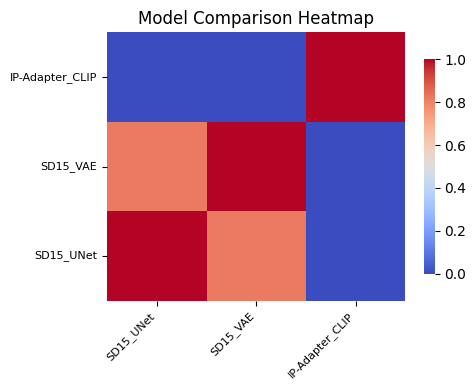

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models_x = ["SD15_UNet", "SD15_VAE", "IP-Adapter_CLIP"]
models_y = [ "IP-Adapter_CLIP", "SD15_VAE", "SD15_UNet",]
data =  [[-3.80436395e-04,  1.52671870e-04,  1],
         [ 8.16762447e-01,  1.00000000e+00 , 1.52671870e-04],
         [ 1.00000000e+00,  8.16762447e-01, -3.80436395e-04],]

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

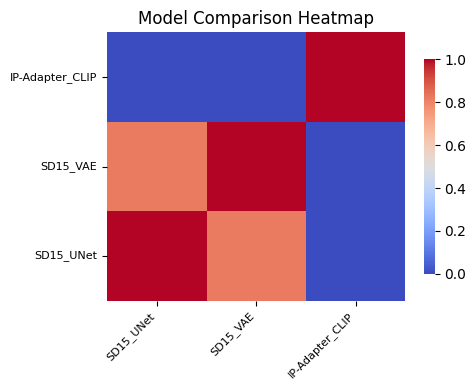

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models_x = ["SD15_UNet", "SD15_VAE", "IP-Adapter_CLIP"]
models_y = [ "IP-Adapter_CLIP", "SD15_VAE", "SD15_UNet",]
data =  [[-1.66707321e-06, -5.44794091e-07,  1],
         [ 8.16762447e-01,  1.00000000e+00, 1.52671870e-04],
         [ 1.00000000e+00, 8.16762388e-01, -1.66707321e-06],]

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

In [21]:
import numpy as np
import torch.nn.functional as F
import torch

grad_list = [torch.tensor(1.0), torch.tensor(-2.0), torch.tensor(3.0)]
# 定义一个3*3 numpy矩阵，矩阵的每个元素是grd_list[i]和grad_list[j]的余弦相似度分数
cos_sim_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        cos_sim_matrix[i][j] = F.cosine_similarity(grad_list[i], grad_list[j], -1).mean()
print("cos_sim_matrix: \n", cos_sim_matrix)

cos_sim_matrix: 
 [[ 1. -1.  1.]
 [-1.  1. -1.]
 [ 1. -1.  1.]]


In [7]:
import torch
import torch.nn.functional as F

# 定义两个向量
vector1 = torch.tensor([1.0, 2.0, 3.0])
vector2 = torch.tensor([4.0, 5.0, 6.0])

# 计算余弦相似度
similarity = F.cosine_similarity(vector1.unsqueeze(0), vector2.unsqueeze(0))
print(similarity)  # 输出: tensor([0.9746])}

tensor([0.9746])


In [8]:
vector1.unsqueeze(0)

tensor([[1., 2., 3.]])

In [14]:
import torch
import torch.nn.functional as F

# 定义一个批次的向量
batch_vectors1 = torch.tensor([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
    [7.0, 8.0, 9.0]
])

batch_vectors2 = torch.tensor([
    [2.0, 3.0, 4.0],
    [5.0, 6.0, 7.0],
    [8.0, 9.0, 10.0]
])

# 计算每对向量的余弦相似度
similarities = F.cosine_similarity(batch_vectors1, batch_vectors2, dim=1)
print(similarities)  
# 输出: tensor([0.9926, 0.9984, 0.9996])

tensor([0.9926, 0.9996, 0.9999])


In [15]:
mean_similarities = F.cosine_similarity(batch_vectors1, batch_vectors2, dim=1).mean()
print(mean_similarities)  

tensor(0.9974)


In [ ]:
mean_similarities = F.cosine_similarity(batch_vectors1, batch_vectors2, dim=-1).mean()
print(mean_similarities)  

tensor(1.)


# 不同模型上生成扰动的相似度

## Target(mist) + cosine

In [26]:
# 检测图像阈值，MetaCloak模式
from torchvision import transforms
import torch
from pathlib import Path
from PIL import Image

def load_data(data_dir, size=512, center_crop=True) -> torch.Tensor:
    image_transforms = transforms.Compose(
        [
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),
            transforms.ToTensor(),
            # transforms.Normalize([0.5], [0.5]),
        ]
    )

    images = [image_transforms(Image.open(i).convert("RGB")) for i in sorted(list(Path(data_dir).iterdir()))]
    images = torch.stack(images)
    return images

weight_type = torch.bfloat16
clean_images = load_data('/data1/humw/Datasets/VGGFace2/n000050/set_B').to(dtype=weight_type)
adv_images_of_unet = load_data('/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/ASPL_ace-plus-ipadapter_VGGFace2_SD15_unet_mist_agm_cosine_eot-1/n000050').to(dtype=weight_type)
adv_images_of_vae = load_data('/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae_mist_agm_cosine_eot-1/n000050').to(dtype=weight_type)
adv_images_of_clip = load_data('/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/ASPL_ace-plus-ipadapter_VGGFace2_SD15_ipadapter_mist_agm_cosine_eot-1/n000050').to(dtype=weight_type)

et_of_unet = adv_images_of_unet - clean_images
et_of_vae = adv_images_of_vae - clean_images
et_of_clip = adv_images_of_clip - clean_images

In [36]:
print(et_of_clip.shape)
print(et_of_clip.mean())
print(et_of_clip.std())
print(et_of_clip.min())
print(et_of_clip.max())
print(F.cosine_similarity(sum(et_of_clip), sum(et_of_clip), -1).mean())

torch.Size([4, 3, 512, 512])
tensor(0.0001, dtype=torch.bfloat16)
tensor(0.0386, dtype=torch.bfloat16)
tensor(-0.0645, dtype=torch.bfloat16)
tensor(0.0645, dtype=torch.bfloat16)
tensor(0.8750, dtype=torch.bfloat16)


In [28]:
import numpy as np
import torch.nn.functional as F

et_list = [et_of_unet, et_of_vae, et_of_clip]
# 定义一个3*3 numpy矩阵，矩阵的每个元素是grd_list[i]和grad_list[j]的余弦相似度分数
cos_sim_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        cos_sim_matrix[i][j] = F.cosine_similarity(et_list[i], et_list[j], -1).mean()
print("cos_sim_matrix: \n", cos_sim_matrix)

cos_sim_matrix: 
 [[1.         0.29296875 0.02307129]
 [0.29296875 1.         0.03320312]
 [0.02307129 0.03320312 0.875     ]]


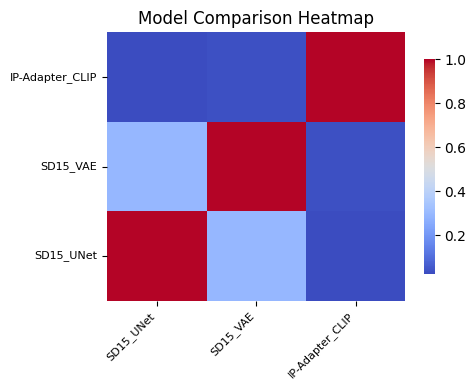

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models_x = ["SD15_UNet", "SD15_VAE", "IP-Adapter_CLIP"]
models_y = [ "IP-Adapter_CLIP", "SD15_VAE", "SD15_UNet",]
data =  [[0.02307129, 0.03320312, 1],
         [0.29296875, 1., 0.03320312],
         [1. , 0.29296875, 0.02307129],]

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

<!DOCTYPE html>
<html lang="zh-CN">
<head>
    <meta charset="UTF-8">
    <title>六一的零花钱小管家计划</title>
    <style>
        :root {
            --red: #ff9999;
            --blue: #99ccff;
            --yellow: #fff099;
        }

        body {
            font-family: "Comic Sans MS", 楷体, cursive;
            max-width: 800px;
            margin: 20px auto;
            padding: 20px;
            background: #f0f9ff;
        }

        .contract {
            border: 3px solid #99ccff;
            border-radius: 15px;
            padding: 25px;
            background: white;
            box-shadow: 0 0 15px rgba(0,0,0,0.1);
        }

        h1 {
            color: #ff6b6b;
            text-align: center;
            font-size: 2.5em;
            margin-bottom: 30px;
            text-shadow: 2px 2px 2px rgba(0,0,0,0.1);
        }

        .section {
            margin: 25px 0;
            padding: 15px;
            border-radius: 10px;
        }

        .rights { background: var(--red); }
        .wallets { background: var(--blue); }
        .promise { background: var(--yellow); }
        .rules { border: 2px dashed #99ccff; }

        .icon {
            font-size: 1.5em;
            margin-right: 10px;
        }

        .signature-box {
            margin-top: 40px;
            text-align: center;
        }

        .signature {
            display: inline-block;
            width: 250px;
            border-bottom: 2px solid black;
            margin: 20px;
        }

        @media print {
            body { background: white; }
            .contract { box-shadow: none; }
            .section { break-inside: avoid; }
        }
    </style>
</head>
<body>
    <div class="contract">
        <h1>✨ 六一的零花钱小管家计划 ✨</h1>
        
        <div class="section rights">
            <h2>📜 六一的权利</h2>
            <p>✅ 每月1号收到50元零花钱</p >
            <p>✅ 可以自己决定买：</p >
            <ul>
                <li>🍭 小零食（棒棒糖、酸奶）</li>
                <li>🚗 小玩具（不超过30元）</li>
                <li>🎁 送朋友的小礼物</li>
            </ul>
        </div>

        <div class="section wallets">
            <h2>🎒 三个魔法钱包</h2>
            <div style="display: flex; gap: 20px; margin-top: 15px;">
                <div style="flex:1; background:var(--red); padding:10px; border-radius:8px;">
                    <h3>🔴 红色钱包 (30元)</h3>
                    <p>每周最多买3次零食</p >
                </div>
                <div style="flex:1; background:var(--blue); padding:10px; border-radius:8px;">
                    <h3>🔵 蓝色存钱罐 (15元)</h3>
                    <p>存满3个月打开</p >
                </div>
                <div style="flex:1; background:var(--yellow); padding:10px; border-radius:8px;">
                    <h3>🟡 黄色爱心盒 (5元)</h3>
                    <p>帮助其他小朋友</p >
                </div>
            </div>
        </div>

        <div class="section promise">
            <h2>🤝 爸爸的承诺</h2>
            <ul>
                <li>⏰ 每月按时发零花钱</li>
                <li>🛒 教你看价格标签</li>
                <li>📒 准备漂亮记账本</li>
            </ul>
        </div>

        <div class="section rules">
            <h2>❗ 重要约定</h2>
            <p>⚖ 钱用完要等到下个月</p >
            <p>📆 每周六一起数钱</p >
            <p>🎂 每年生日可以调整</p >
        </div>

        <div class="signature-box">
            <p>我，<span class="signature"></span>，同意当聪明小管家！</p >
            <p>我，<span class="signature"></span>，保证做守信好伙伴！</p >
            <p>签订日期：2025年__月__日 📅</p >
        </div>
    </div>
</body>
</html>

# 不同模型上生成扰动的正交度

## Target(mist) + cosine

In [33]:
import torch

def calculate_orthogonality(matrix1, matrix2):
    # # 示例：两个特征矩阵
    # matrix1 = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
    # matrix2 = torch.tensor([[4, 3], [2, 1]], dtype=torch.float32)

    # 计算内积
    dot_product = torch.sum(matrix1 * matrix2)

    # 计算自内积
    norm_matrix1 = torch.sum(matrix1 * matrix1)
    norm_matrix2 = torch.sum(matrix2 * matrix2)

    # 计算正交度
    orthogonality = 1 - (dot_product ** 2) / (norm_matrix1 * norm_matrix2)

    print(f"正交度: {orthogonality.item()}")
    return orthogonality

In [ ]:
import numpy as np
import torch.nn.functional as F

et_list = [et_of_unet, et_of_vae, et_of_clip]
# 定义一个3*3 numpy矩阵，矩阵的每个元素是grd_list[i]和grad_list[j]的正交度
orthogonality_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        orthogonality_matrix[i][j] = calculate_orthogonality(et_list[i], et_list[j])
print("orthogonality_matrix: \n", orthogonality_matrix)

正交度: 0.0
正交度: 0.91015625
正交度: 1.0
正交度: 0.91015625
正交度: 0.0
正交度: 1.0
正交度: 1.0
正交度: 1.0
正交度: 0.0
orthogonality_matrix: 
 [[0.         0.91015625 1.        ]
 [0.91015625 0.         1.        ]
 [1.         1.         0.        ]]


- 发现：UNet和VAE的扰动正交度很大，UNet和CLIP的正交度为1，VAE和CLIP的正交度也为1，即正交。
- 但是，似乎没有什么关系。是否意味着，分别学习到的扰动，直接累加的效果会很好？因为它们互不干扰？

In [38]:
new_et = et_of_unet + et_of_vae + et_of_clip

In [53]:
import torch

new_et = torch.clamp(new_et, min=-16/255, max=+16/255)
new_adversarial_images = torch.clamp(clean_images + new_et, min=torch.min(clean_images), max=torch.max(clean_images)).detach_()

In [54]:
torch.max(clean_images)

tensor(1., dtype=torch.bfloat16)

In [55]:
from torchvision import transforms
import torch
from pathlib import Path
from PIL import Image

def save_images_from_tensor(images: torch.Tensor, image_names, save_dir: str, size: int = 512, center_crop: bool = True):
    """
    将加载后的图像特征（torch.Tensor）保存为 PNG 图像。

    参数:
        images (torch.Tensor): 加载后的图像特征，形状为 (N, C, H, W)。
        save_dir (str): 保存图像的目录路径。
        size (int): 图像的大小（宽和高）。
        center_crop (bool): 是否在保存时使用中心裁剪。
    """
    # 确保保存路径存在
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    # 定义保存时的逆变换
    transform = transforms.Compose([
        transforms.ToPILImage(),  # 将 Tensor 转换为 PIL 图像
        transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),  # 调整大小
        transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),  # 裁剪
    ])

    # 遍历图像并保存
    for i, image in enumerate(images):
        # 应用逆变换
        pil_image = transform(image)

        # 保存图像
        # save_file = save_path / f"image_{i}.png"
        save_file = save_path / f"{image_names[i]}.png"
        pil_image.save(save_file)

    print(f"所有图像已保存到 {save_path}，格式为 PNG。")

In [56]:
# # 示例：加载图像
# loaded_images = load_data(data_dir="path/to/your/images", size=512, center_crop=True)

img_names = [
    str(instance_path).split("/")[-1]
    for instance_path in sorted(list(Path("/data1/humw/Codes/My-Anti-DreamBooth/data/n000050/set_B").iterdir()))
]
# 示例：保存图像
save_images_from_tensor(images=new_adversarial_images, image_names=img_names, save_dir="/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/test_orthogonality_adv_images/n000050", size=512, center_crop=True)

所有图像已保存到 /data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/test_orthogonality_adv_images/n000050，格式为 PNG。


- 很遗憾，将最终的扰动叠加后得到的，test_orthogonality_adv_images，在dreambooth上尚且还有保护效果，在IP-Adapter上完全没有效果

## Non-Target + Cosine 不同模型扰动相似度计算

In [2]:
# 检测图像阈值，MetaCloak模式
from torchvision import transforms
import torch
from pathlib import Path
from PIL import Image
import os


def load_data(data_dir, size=512, center_crop=True) -> torch.Tensor:
    image_transforms = transforms.Compose(
        [
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size) if center_crop else transforms.RandomCrop(size),
            transforms.ToTensor(),
            # transforms.Normalize([0.5], [0.5]),
        ]
    )

    images = [image_transforms(Image.open(i).convert("RGB")) for i in sorted(list(Path(data_dir).iterdir()))]
    images = torch.stack(images)
    return images

weight_type = torch.bfloat16
clean_images = load_data('/data1/humw/Datasets/VGGFace2/n000050/set_B').to(dtype=weight_type)
adv_dir = '/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/'
unet_adv_folder_dir = "ASPL_ace-plus-ipadapter_VGGFace2_SD15_unet_non-target_agm_cosine_eot-1_sds-0_unT-unet-1"
vae_adv_folder_dir = "ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae_non-target_agm_cosine_eot-1_sds-0_unT-unet-0"
clip_adv_folder_dir = "ASPL_ace-plus-ipadapter_VGGFace2_SD15_ipadapter_non-target_agm_cosine_eot-1_sds-0_unT-unet-0"
person_id = 'n000050'
unet_path = os.path.join(adv_dir, unet_adv_folder_dir, person_id)
vae_path = os.path.join(adv_dir, vae_adv_folder_dir, person_id)
clip_path = os.path.join(adv_dir, clip_adv_folder_dir, person_id)
adv_images_of_unet = load_data(unet_path).to(dtype=weight_type)
adv_images_of_vae = load_data(vae_path).to(dtype=weight_type)
adv_images_of_clip = load_data(clip_path).to(dtype=weight_type)

et_of_unet = adv_images_of_unet - clean_images
et_of_vae = adv_images_of_vae - clean_images
et_of_clip = adv_images_of_clip - clean_images

In [3]:
import numpy as np
import torch.nn.functional as F

et_list = [et_of_unet, et_of_vae, et_of_clip]
# 定义一个3*3 numpy矩阵，矩阵的每个元素是grd_list[i]和grad_list[j]的余弦相似度分数
cos_sim_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        cos_sim_matrix[i][j] = F.cosine_similarity(et_list[i], et_list[j], -1).mean()
print("cos_sim_matrix: \n", cos_sim_matrix)

cos_sim_matrix: 
 [[1.         0.4609375  0.02197266]
 [0.4609375  1.         0.02893066]
 [0.02197266 0.02893066 1.        ]]


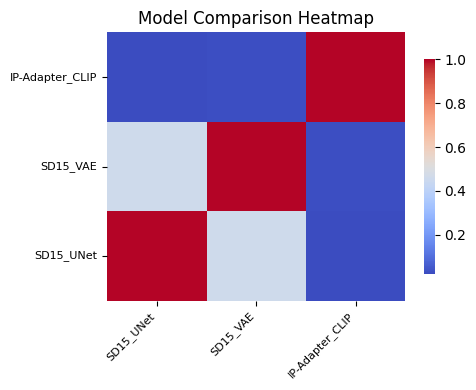

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 创建示例数据
models_x = ["SD15_UNet", "SD15_VAE", "IP-Adapter_CLIP"]
models_y = [ "IP-Adapter_CLIP", "SD15_VAE", "SD15_UNet",]
data =  [[0.02197266, 0.02893066, 1. ],
        [0.4609375 , 1., 0.02893066],
        [1., 0.4609375, 0.02197266],]

# 创建热图
plt.figure(figsize=(5, 4))
sns.heatmap(data, annot=False, cmap="coolwarm", xticklabels=models_x, yticklabels=models_y, cbar_kws={"shrink": 0.8})

# 调整显示
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title("Model Comparison Heatmap")
plt.tight_layout()
plt.show()

# 损失函数可视化

## 单独扰动IP-Adapter MSE
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_ipadapter_yingbu_agm_mse_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [5]:
loss_dict_list = [{'loss_sum': -0.453125, 'loss': -0.453125, 'ipadapter': -0.453125}, {'loss_sum': -0.41796875, 'loss': -0.41796875, 'ipadapter': -0.41796875}, {'loss_sum': -0.388671875, 'loss': -0.388671875, 'ipadapter': -0.388671875}, {'loss_sum': -0.3671875, 'loss': -0.3671875, 'ipadapter': -0.3671875}, {'loss_sum': -0.3515625, 'loss': -0.3515625, 'ipadapter': -0.3515625}, {'loss_sum': -0.337890625, 'loss': -0.337890625, 'ipadapter': -0.337890625}, {'loss_sum': -0.33203125, 'loss': -0.33203125, 'ipadapter': -0.33203125}, {'loss_sum': -0.32421875, 'loss': -0.32421875, 'ipadapter': -0.32421875}, {'loss_sum': -0.318359375, 'loss': -0.318359375, 'ipadapter': -0.318359375}, {'loss_sum': -0.31640625, 'loss': -0.31640625, 'ipadapter': -0.31640625}, {'loss_sum': -0.310546875, 'loss': -0.310546875, 'ipadapter': -0.310546875}, {'loss_sum': -0.30859375, 'loss': -0.30859375, 'ipadapter': -0.30859375}, {'loss_sum': -0.3046875, 'loss': -0.3046875, 'ipadapter': -0.3046875}, {'loss_sum': -0.302734375, 'loss': -0.302734375, 'ipadapter': -0.302734375}, {'loss_sum': -0.296875, 'loss': -0.296875, 'ipadapter': -0.296875}, {'loss_sum': -0.294921875, 'loss': -0.294921875, 'ipadapter': -0.294921875}, {'loss_sum': -0.29296875, 'loss': -0.29296875, 'ipadapter': -0.29296875}, {'loss_sum': -0.291015625, 'loss': -0.291015625, 'ipadapter': -0.291015625}, {'loss_sum': -0.287109375, 'loss': -0.287109375, 'ipadapter': -0.287109375}, {'loss_sum': -0.28515625, 'loss': -0.28515625, 'ipadapter': -0.28515625}, {'loss_sum': -0.283203125, 'loss': -0.283203125, 'ipadapter': -0.283203125}, {'loss_sum': -0.28125, 'loss': -0.28125, 'ipadapter': -0.28125}, {'loss_sum': -0.27734375, 'loss': -0.27734375, 'ipadapter': -0.27734375}, {'loss_sum': -0.27734375, 'loss': -0.27734375, 'ipadapter': -0.27734375}, {'loss_sum': -0.2734375, 'loss': -0.2734375, 'ipadapter': -0.2734375}, {'loss_sum': -0.271484375, 'loss': -0.271484375, 'ipadapter': -0.271484375}, {'loss_sum': -0.26953125, 'loss': -0.26953125, 'ipadapter': -0.26953125}, {'loss_sum': -0.265625, 'loss': -0.265625, 'ipadapter': -0.265625}, {'loss_sum': -0.265625, 'loss': -0.265625, 'ipadapter': -0.265625}, {'loss_sum': -0.265625, 'loss': -0.265625, 'ipadapter': -0.265625}, {'loss_sum': -0.26171875, 'loss': -0.26171875, 'ipadapter': -0.26171875}, {'loss_sum': -0.2578125, 'loss': -0.2578125, 'ipadapter': -0.2578125}, {'loss_sum': -0.2578125, 'loss': -0.2578125, 'ipadapter': -0.2578125}, {'loss_sum': -0.255859375, 'loss': -0.255859375, 'ipadapter': -0.255859375}, {'loss_sum': -0.251953125, 'loss': -0.251953125, 'ipadapter': -0.251953125}, {'loss_sum': -0.2490234375, 'loss': -0.2490234375, 'ipadapter': -0.2490234375}, {'loss_sum': -0.248046875, 'loss': -0.248046875, 'ipadapter': -0.248046875}, {'loss_sum': -0.2470703125, 'loss': -0.2470703125, 'ipadapter': -0.2470703125}, {'loss_sum': -0.24609375, 'loss': -0.24609375, 'ipadapter': -0.24609375}, {'loss_sum': -0.244140625, 'loss': -0.244140625, 'ipadapter': -0.244140625}, {'loss_sum': -0.2412109375, 'loss': -0.2412109375, 'ipadapter': -0.2412109375}, {'loss_sum': -0.23828125, 'loss': -0.23828125, 'ipadapter': -0.23828125}, {'loss_sum': -0.2392578125, 'loss': -0.2392578125, 'ipadapter': -0.2392578125}, {'loss_sum': -0.23828125, 'loss': -0.23828125, 'ipadapter': -0.23828125}, {'loss_sum': -0.2353515625, 'loss': -0.2353515625, 'ipadapter': -0.2353515625}, {'loss_sum': -0.2333984375, 'loss': -0.2333984375, 'ipadapter': -0.2333984375}, {'loss_sum': -0.232421875, 'loss': -0.232421875, 'ipadapter': -0.232421875}, {'loss_sum': -0.232421875, 'loss': -0.232421875, 'ipadapter': -0.232421875}, {'loss_sum': -0.2314453125, 'loss': -0.2314453125, 'ipadapter': -0.2314453125}, {'loss_sum': -0.228515625, 'loss': -0.228515625, 'ipadapter': -0.228515625}, {'loss_sum': -0.2265625, 'loss': -0.2265625, 'ipadapter': -0.2265625}, {'loss_sum': -0.2275390625, 'loss': -0.2275390625, 'ipadapter': -0.2275390625}, {'loss_sum': -0.228515625, 'loss': -0.228515625, 'ipadapter': -0.228515625}, {'loss_sum': -0.2265625, 'loss': -0.2265625, 'ipadapter': -0.2265625}, {'loss_sum': -0.2216796875, 'loss': -0.2216796875, 'ipadapter': -0.2216796875}, {'loss_sum': -0.2216796875, 'loss': -0.2216796875, 'ipadapter': -0.2216796875}, {'loss_sum': -0.2216796875, 'loss': -0.2216796875, 'ipadapter': -0.2216796875}, {'loss_sum': -0.2197265625, 'loss': -0.2197265625, 'ipadapter': -0.2197265625}, {'loss_sum': -0.216796875, 'loss': -0.216796875, 'ipadapter': -0.216796875}, {'loss_sum': -0.21484375, 'loss': -0.21484375, 'ipadapter': -0.21484375}, {'loss_sum': -0.21484375, 'loss': -0.21484375, 'ipadapter': -0.21484375}, {'loss_sum': -0.212890625, 'loss': -0.212890625, 'ipadapter': -0.212890625}, {'loss_sum': -0.21484375, 'loss': -0.21484375, 'ipadapter': -0.21484375}, {'loss_sum': -0.2138671875, 'loss': -0.2138671875, 'ipadapter': -0.2138671875}, {'loss_sum': -0.2119140625, 'loss': -0.2119140625, 'ipadapter': -0.2119140625}, {'loss_sum': -0.2109375, 'loss': -0.2109375, 'ipadapter': -0.2109375}, {'loss_sum': -0.2119140625, 'loss': -0.2119140625, 'ipadapter': -0.2119140625}, {'loss_sum': -0.208984375, 'loss': -0.208984375, 'ipadapter': -0.208984375}, {'loss_sum': -0.2109375, 'loss': -0.2109375, 'ipadapter': -0.2109375}, {'loss_sum': -0.2080078125, 'loss': -0.2080078125, 'ipadapter': -0.2080078125}, {'loss_sum': -0.20703125, 'loss': -0.20703125, 'ipadapter': -0.20703125}, {'loss_sum': -0.205078125, 'loss': -0.205078125, 'ipadapter': -0.205078125}, {'loss_sum': -0.203125, 'loss': -0.203125, 'ipadapter': -0.203125}, {'loss_sum': -0.205078125, 'loss': -0.205078125, 'ipadapter': -0.205078125}, {'loss_sum': -0.203125, 'loss': -0.203125, 'ipadapter': -0.203125}, {'loss_sum': -0.203125, 'loss': -0.203125, 'ipadapter': -0.203125}, {'loss_sum': -0.203125, 'loss': -0.203125, 'ipadapter': -0.203125}, {'loss_sum': -0.2001953125, 'loss': -0.2001953125, 'ipadapter': -0.2001953125}, {'loss_sum': -0.2001953125, 'loss': -0.2001953125, 'ipadapter': -0.2001953125}, {'loss_sum': -0.2001953125, 'loss': -0.2001953125, 'ipadapter': -0.2001953125}, {'loss_sum': -0.197265625, 'loss': -0.197265625, 'ipadapter': -0.197265625}, {'loss_sum': -0.1982421875, 'loss': -0.1982421875, 'ipadapter': -0.1982421875}, {'loss_sum': -0.1953125, 'loss': -0.1953125, 'ipadapter': -0.1953125}, {'loss_sum': -0.1943359375, 'loss': -0.1943359375, 'ipadapter': -0.1943359375}, {'loss_sum': -0.1943359375, 'loss': -0.1943359375, 'ipadapter': -0.1943359375}, {'loss_sum': -0.193359375, 'loss': -0.193359375, 'ipadapter': -0.193359375}, {'loss_sum': -0.1943359375, 'loss': -0.1943359375, 'ipadapter': -0.1943359375}, {'loss_sum': -0.1923828125, 'loss': -0.1923828125, 'ipadapter': -0.1923828125}, {'loss_sum': -0.1923828125, 'loss': -0.1923828125, 'ipadapter': -0.1923828125}, {'loss_sum': -0.189453125, 'loss': -0.189453125, 'ipadapter': -0.189453125}, {'loss_sum': -0.1884765625, 'loss': -0.1884765625, 'ipadapter': -0.1884765625}, {'loss_sum': -0.1875, 'loss': -0.1875, 'ipadapter': -0.1875}, {'loss_sum': -0.1884765625, 'loss': -0.1884765625, 'ipadapter': -0.1884765625}, {'loss_sum': -0.189453125, 'loss': -0.189453125, 'ipadapter': -0.189453125}, {'loss_sum': -0.1875, 'loss': -0.1875, 'ipadapter': -0.1875}, {'loss_sum': -0.1884765625, 'loss': -0.1884765625, 'ipadapter': -0.1884765625}, {'loss_sum': -0.1875, 'loss': -0.1875, 'ipadapter': -0.1875}, {'loss_sum': -0.1875, 'loss': -0.1875, 'ipadapter': -0.1875}, {'loss_sum': -0.1845703125, 'loss': -0.1845703125, 'ipadapter': -0.1845703125}, {'loss_sum': -0.181640625, 'loss': -0.181640625, 'ipadapter': -0.181640625}, {'loss_sum': -0.18359375, 'loss': -0.18359375, 'ipadapter': -0.18359375}, {'loss_sum': -0.1826171875, 'loss': -0.1826171875, 'ipadapter': -0.1826171875}, {'loss_sum': -0.1826171875, 'loss': -0.1826171875, 'ipadapter': -0.1826171875}, {'loss_sum': -0.1806640625, 'loss': -0.1806640625, 'ipadapter': -0.1806640625}, {'loss_sum': -0.181640625, 'loss': -0.181640625, 'ipadapter': -0.181640625}, {'loss_sum': -0.177734375, 'loss': -0.177734375, 'ipadapter': -0.177734375}, {'loss_sum': -0.1826171875, 'loss': -0.1826171875, 'ipadapter': -0.1826171875}, {'loss_sum': -0.177734375, 'loss': -0.177734375, 'ipadapter': -0.177734375}, {'loss_sum': -0.1787109375, 'loss': -0.1787109375, 'ipadapter': -0.1787109375}, {'loss_sum': -0.1787109375, 'loss': -0.1787109375, 'ipadapter': -0.1787109375}, {'loss_sum': -0.1787109375, 'loss': -0.1787109375, 'ipadapter': -0.1787109375}, {'loss_sum': -0.1767578125, 'loss': -0.1767578125, 'ipadapter': -0.1767578125}, {'loss_sum': -0.1767578125, 'loss': -0.1767578125, 'ipadapter': -0.1767578125}, {'loss_sum': -0.1748046875, 'loss': -0.1748046875, 'ipadapter': -0.1748046875}, {'loss_sum': -0.171875, 'loss': -0.171875, 'ipadapter': -0.171875}, {'loss_sum': -0.1728515625, 'loss': -0.1728515625, 'ipadapter': -0.1728515625}, {'loss_sum': -0.1728515625, 'loss': -0.1728515625, 'ipadapter': -0.1728515625}, {'loss_sum': -0.1728515625, 'loss': -0.1728515625, 'ipadapter': -0.1728515625}, {'loss_sum': -0.1728515625, 'loss': -0.1728515625, 'ipadapter': -0.1728515625}, {'loss_sum': -0.1708984375, 'loss': -0.1708984375, 'ipadapter': -0.1708984375}, {'loss_sum': -0.1748046875, 'loss': -0.1748046875, 'ipadapter': -0.1748046875}, {'loss_sum': -0.1708984375, 'loss': -0.1708984375, 'ipadapter': -0.1708984375}, {'loss_sum': -0.171875, 'loss': -0.171875, 'ipadapter': -0.171875}, {'loss_sum': -0.1689453125, 'loss': -0.1689453125, 'ipadapter': -0.1689453125}, {'loss_sum': -0.1728515625, 'loss': -0.1728515625, 'ipadapter': -0.1728515625}, {'loss_sum': -0.16796875, 'loss': -0.16796875, 'ipadapter': -0.16796875}, {'loss_sum': -0.171875, 'loss': -0.171875, 'ipadapter': -0.171875}, {'loss_sum': -0.169921875, 'loss': -0.169921875, 'ipadapter': -0.169921875}, {'loss_sum': -0.1669921875, 'loss': -0.1669921875, 'ipadapter': -0.1669921875}, {'loss_sum': -0.16796875, 'loss': -0.16796875, 'ipadapter': -0.16796875}, {'loss_sum': -0.16796875, 'loss': -0.16796875, 'ipadapter': -0.16796875}, {'loss_sum': -0.1669921875, 'loss': -0.1669921875, 'ipadapter': -0.1669921875}, {'loss_sum': -0.1650390625, 'loss': -0.1650390625, 'ipadapter': -0.1650390625}, {'loss_sum': -0.1669921875, 'loss': -0.1669921875, 'ipadapter': -0.1669921875}, {'loss_sum': -0.1630859375, 'loss': -0.1630859375, 'ipadapter': -0.1630859375}, {'loss_sum': -0.1650390625, 'loss': -0.1650390625, 'ipadapter': -0.1650390625}, {'loss_sum': -0.1650390625, 'loss': -0.1650390625, 'ipadapter': -0.1650390625}, {'loss_sum': -0.1640625, 'loss': -0.1640625, 'ipadapter': -0.1640625}, {'loss_sum': -0.1640625, 'loss': -0.1640625, 'ipadapter': -0.1640625}, {'loss_sum': -0.1640625, 'loss': -0.1640625, 'ipadapter': -0.1640625}, {'loss_sum': -0.1640625, 'loss': -0.1640625, 'ipadapter': -0.1640625}, {'loss_sum': -0.1630859375, 'loss': -0.1630859375, 'ipadapter': -0.1630859375}, {'loss_sum': -0.162109375, 'loss': -0.162109375, 'ipadapter': -0.162109375}, {'loss_sum': -0.1630859375, 'loss': -0.1630859375, 'ipadapter': -0.1630859375}, {'loss_sum': -0.1640625, 'loss': -0.1640625, 'ipadapter': -0.1640625}, {'loss_sum': -0.1630859375, 'loss': -0.1630859375, 'ipadapter': -0.1630859375}, {'loss_sum': -0.1611328125, 'loss': -0.1611328125, 'ipadapter': -0.1611328125}, {'loss_sum': -0.16015625, 'loss': -0.16015625, 'ipadapter': -0.16015625}, {'loss_sum': -0.162109375, 'loss': -0.162109375, 'ipadapter': -0.162109375}, {'loss_sum': -0.16015625, 'loss': -0.16015625, 'ipadapter': -0.16015625}, {'loss_sum': -0.1591796875, 'loss': -0.1591796875, 'ipadapter': -0.1591796875}, {'loss_sum': -0.1611328125, 'loss': -0.1611328125, 'ipadapter': -0.1611328125}, {'loss_sum': -0.158203125, 'loss': -0.158203125, 'ipadapter': -0.158203125}, {'loss_sum': -0.1611328125, 'loss': -0.1611328125, 'ipadapter': -0.1611328125}, {'loss_sum': -0.1572265625, 'loss': -0.1572265625, 'ipadapter': -0.1572265625}, {'loss_sum': -0.158203125, 'loss': -0.158203125, 'ipadapter': -0.158203125}, {'loss_sum': -0.15625, 'loss': -0.15625, 'ipadapter': -0.15625}, {'loss_sum': -0.1591796875, 'loss': -0.1591796875, 'ipadapter': -0.1591796875}, {'loss_sum': -0.154296875, 'loss': -0.154296875, 'ipadapter': -0.154296875}, {'loss_sum': -0.1572265625, 'loss': -0.1572265625, 'ipadapter': -0.1572265625}, {'loss_sum': -0.1552734375, 'loss': -0.1552734375, 'ipadapter': -0.1552734375}, {'loss_sum': -0.1572265625, 'loss': -0.1572265625, 'ipadapter': -0.1572265625}, {'loss_sum': -0.1552734375, 'loss': -0.1552734375, 'ipadapter': -0.1552734375}, {'loss_sum': -0.1533203125, 'loss': -0.1533203125, 'ipadapter': -0.1533203125}, {'loss_sum': -0.15234375, 'loss': -0.15234375, 'ipadapter': -0.15234375}, {'loss_sum': -0.1552734375, 'loss': -0.1552734375, 'ipadapter': -0.1552734375}, {'loss_sum': -0.1513671875, 'loss': -0.1513671875, 'ipadapter': -0.1513671875}, {'loss_sum': -0.1533203125, 'loss': -0.1533203125, 'ipadapter': -0.1533203125}, {'loss_sum': -0.15234375, 'loss': -0.15234375, 'ipadapter': -0.15234375}, {'loss_sum': -0.1552734375, 'loss': -0.1552734375, 'ipadapter': -0.1552734375}, {'loss_sum': -0.154296875, 'loss': -0.154296875, 'ipadapter': -0.154296875}, {'loss_sum': -0.1513671875, 'loss': -0.1513671875, 'ipadapter': -0.1513671875}, {'loss_sum': -0.1552734375, 'loss': -0.1552734375, 'ipadapter': -0.1552734375}, {'loss_sum': -0.1494140625, 'loss': -0.1494140625, 'ipadapter': -0.1494140625}, {'loss_sum': -0.150390625, 'loss': -0.150390625, 'ipadapter': -0.150390625}, {'loss_sum': -0.1484375, 'loss': -0.1484375, 'ipadapter': -0.1484375}, {'loss_sum': -0.1494140625, 'loss': -0.1494140625, 'ipadapter': -0.1494140625}, {'loss_sum': -0.150390625, 'loss': -0.150390625, 'ipadapter': -0.150390625}, {'loss_sum': -0.1494140625, 'loss': -0.1494140625, 'ipadapter': -0.1494140625}, {'loss_sum': -0.1513671875, 'loss': -0.1513671875, 'ipadapter': -0.1513671875}, {'loss_sum': -0.1484375, 'loss': -0.1484375, 'ipadapter': -0.1484375}, {'loss_sum': -0.150390625, 'loss': -0.150390625, 'ipadapter': -0.150390625}, {'loss_sum': -0.1484375, 'loss': -0.1484375, 'ipadapter': -0.1484375}, {'loss_sum': -0.1494140625, 'loss': -0.1494140625, 'ipadapter': -0.1494140625}, {'loss_sum': -0.150390625, 'loss': -0.150390625, 'ipadapter': -0.150390625}, {'loss_sum': -0.1494140625, 'loss': -0.1494140625, 'ipadapter': -0.1494140625}, {'loss_sum': -0.1513671875, 'loss': -0.1513671875, 'ipadapter': -0.1513671875}, {'loss_sum': -0.146484375, 'loss': -0.146484375, 'ipadapter': -0.146484375}, {'loss_sum': -0.1494140625, 'loss': -0.1494140625, 'ipadapter': -0.1494140625}, {'loss_sum': -0.1474609375, 'loss': -0.1474609375, 'ipadapter': -0.1474609375}, {'loss_sum': -0.1484375, 'loss': -0.1484375, 'ipadapter': -0.1484375}, {'loss_sum': -0.1474609375, 'loss': -0.1474609375, 'ipadapter': -0.1474609375}, {'loss_sum': -0.1474609375, 'loss': -0.1474609375, 'ipadapter': -0.1474609375}, {'loss_sum': -0.1474609375, 'loss': -0.1474609375, 'ipadapter': -0.1474609375}, {'loss_sum': -0.1455078125, 'loss': -0.1455078125, 'ipadapter': -0.1455078125}, {'loss_sum': -0.1455078125, 'loss': -0.1455078125, 'ipadapter': -0.1455078125}, {'loss_sum': -0.14453125, 'loss': -0.14453125, 'ipadapter': -0.14453125}, {'loss_sum': -0.1455078125, 'loss': -0.1455078125, 'ipadapter': -0.1455078125}, {'loss_sum': -0.1455078125, 'loss': -0.1455078125, 'ipadapter': -0.1455078125}, {'loss_sum': -0.1435546875, 'loss': -0.1435546875, 'ipadapter': -0.1435546875}, {'loss_sum': -0.1435546875, 'loss': -0.1435546875, 'ipadapter': -0.1435546875}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.14453125, 'loss': -0.14453125, 'ipadapter': -0.14453125}, {'loss_sum': -0.1455078125, 'loss': -0.1455078125, 'ipadapter': -0.1455078125}, {'loss_sum': -0.142578125, 'loss': -0.142578125, 'ipadapter': -0.142578125}, {'loss_sum': -0.14453125, 'loss': -0.14453125, 'ipadapter': -0.14453125}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.142578125, 'loss': -0.142578125, 'ipadapter': -0.142578125}, {'loss_sum': -0.1435546875, 'loss': -0.1435546875, 'ipadapter': -0.1435546875}, {'loss_sum': -0.146484375, 'loss': -0.146484375, 'ipadapter': -0.146484375}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.1455078125, 'loss': -0.1455078125, 'ipadapter': -0.1455078125}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.140625, 'loss': -0.140625, 'ipadapter': -0.140625}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.1416015625, 'loss': -0.1416015625, 'ipadapter': -0.1416015625}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.140625, 'loss': -0.140625, 'ipadapter': -0.140625}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.1376953125, 'loss': -0.1376953125, 'ipadapter': -0.1376953125}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.1376953125, 'loss': -0.1376953125, 'ipadapter': -0.1376953125}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.1396484375, 'loss': -0.1396484375, 'ipadapter': -0.1396484375}, {'loss_sum': -0.138671875, 'loss': -0.138671875, 'ipadapter': -0.138671875}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.1376953125, 'loss': -0.1376953125, 'ipadapter': -0.1376953125}, {'loss_sum': -0.1376953125, 'loss': -0.1376953125, 'ipadapter': -0.1376953125}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.134765625, 'loss': -0.134765625, 'ipadapter': -0.134765625}, {'loss_sum': -0.138671875, 'loss': -0.138671875, 'ipadapter': -0.138671875}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.138671875, 'loss': -0.138671875, 'ipadapter': -0.138671875}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.134765625, 'loss': -0.134765625, 'ipadapter': -0.134765625}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.134765625, 'loss': -0.134765625, 'ipadapter': -0.134765625}, {'loss_sum': -0.1376953125, 'loss': -0.1376953125, 'ipadapter': -0.1376953125}, {'loss_sum': -0.1337890625, 'loss': -0.1337890625, 'ipadapter': -0.1337890625}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.1337890625, 'loss': -0.1337890625, 'ipadapter': -0.1337890625}, {'loss_sum': -0.134765625, 'loss': -0.134765625, 'ipadapter': -0.134765625}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.13671875, 'loss': -0.13671875, 'ipadapter': -0.13671875}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.1357421875, 'loss': -0.1357421875, 'ipadapter': -0.1357421875}, {'loss_sum': -0.1337890625, 'loss': -0.1337890625, 'ipadapter': -0.1337890625}, {'loss_sum': -0.1337890625, 'loss': -0.1337890625, 'ipadapter': -0.1337890625}, {'loss_sum': -0.1318359375, 'loss': -0.1318359375, 'ipadapter': -0.1318359375}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.1318359375, 'loss': -0.1318359375, 'ipadapter': -0.1318359375}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.1318359375, 'loss': -0.1318359375, 'ipadapter': -0.1318359375}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.1328125, 'loss': -0.1328125, 'ipadapter': -0.1328125}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.1279296875, 'loss': -0.1279296875, 'ipadapter': -0.1279296875}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.1298828125, 'loss': -0.1298828125, 'ipadapter': -0.1298828125}, {'loss_sum': -0.1298828125, 'loss': -0.1298828125, 'ipadapter': -0.1298828125}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.126953125, 'loss': -0.126953125, 'ipadapter': -0.126953125}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.130859375, 'loss': -0.130859375, 'ipadapter': -0.130859375}, {'loss_sum': -0.1298828125, 'loss': -0.1298828125, 'ipadapter': -0.1298828125}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.1279296875, 'loss': -0.1279296875, 'ipadapter': -0.1279296875}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.1279296875, 'loss': -0.1279296875, 'ipadapter': -0.1279296875}, {'loss_sum': -0.12890625, 'loss': -0.12890625, 'ipadapter': -0.12890625}, {'loss_sum': -0.1259765625, 'loss': -0.1259765625, 'ipadapter': -0.1259765625}, {'loss_sum': -0.126953125, 'loss': -0.126953125, 'ipadapter': -0.126953125}, {'loss_sum': -0.126953125, 'loss': -0.126953125, 'ipadapter': -0.126953125}, {'loss_sum': -0.126953125, 'loss': -0.126953125, 'ipadapter': -0.126953125}, {'loss_sum': -0.1259765625, 'loss': -0.1259765625, 'ipadapter': -0.1259765625}, {'loss_sum': -0.1279296875, 'loss': -0.1279296875, 'ipadapter': -0.1279296875}, {'loss_sum': -0.126953125, 'loss': -0.126953125, 'ipadapter': -0.126953125}, {'loss_sum': -0.1259765625, 'loss': -0.1259765625, 'ipadapter': -0.1259765625}, {'loss_sum': -0.1259765625, 'loss': -0.1259765625, 'ipadapter': -0.1259765625}, {'loss_sum': -0.12353515625, 'loss': -0.12353515625, 'ipadapter': -0.12353515625}]


In [2]:
len(loss_dict_list)

300

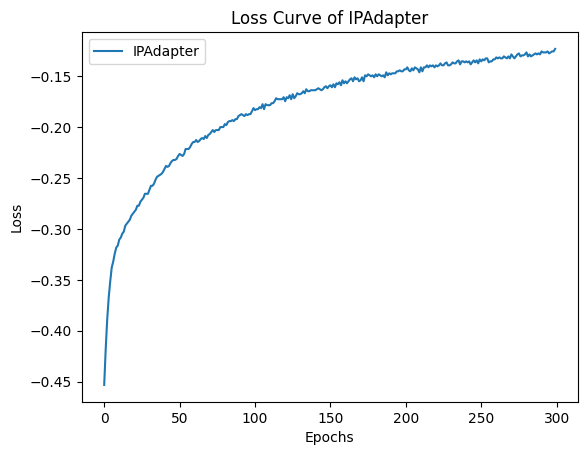

In [9]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IPAdapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IPAdapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## 单独扰动IP-Adapter Cosine
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_ipadapter_yingbu_agm_cosine_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [6]:
loss_dict_list = [{'loss_sum': 0.1328125, 'loss': 0.1328125, 'ipadapter': 0.1328125}, {'loss_sum': 0.1474609375, 'loss': 0.1474609375, 'ipadapter': 0.1474609375}, {'loss_sum': 0.162109375, 'loss': 0.162109375, 'ipadapter': 0.162109375}, {'loss_sum': 0.173828125, 'loss': 0.173828125, 'ipadapter': 0.173828125}, {'loss_sum': 0.1923828125, 'loss': 0.1923828125, 'ipadapter': 0.1923828125}, {'loss_sum': 0.205078125, 'loss': 0.205078125, 'ipadapter': 0.205078125}, {'loss_sum': 0.21875, 'loss': 0.21875, 'ipadapter': 0.21875}, {'loss_sum': 0.232421875, 'loss': 0.232421875, 'ipadapter': 0.232421875}, {'loss_sum': 0.251953125, 'loss': 0.251953125, 'ipadapter': 0.251953125}, {'loss_sum': 0.265625, 'loss': 0.265625, 'ipadapter': 0.265625}, {'loss_sum': 0.28125, 'loss': 0.28125, 'ipadapter': 0.28125}, {'loss_sum': 0.296875, 'loss': 0.296875, 'ipadapter': 0.296875}, {'loss_sum': 0.3125, 'loss': 0.3125, 'ipadapter': 0.3125}, {'loss_sum': 0.328125, 'loss': 0.328125, 'ipadapter': 0.328125}, {'loss_sum': 0.330078125, 'loss': 0.330078125, 'ipadapter': 0.330078125}, {'loss_sum': 0.341796875, 'loss': 0.341796875, 'ipadapter': 0.341796875}, {'loss_sum': 0.35546875, 'loss': 0.35546875, 'ipadapter': 0.35546875}, {'loss_sum': 0.36328125, 'loss': 0.36328125, 'ipadapter': 0.36328125}, {'loss_sum': 0.37109375, 'loss': 0.37109375, 'ipadapter': 0.37109375}, {'loss_sum': 0.376953125, 'loss': 0.376953125, 'ipadapter': 0.376953125}, {'loss_sum': 0.3828125, 'loss': 0.3828125, 'ipadapter': 0.3828125}, {'loss_sum': 0.396484375, 'loss': 0.396484375, 'ipadapter': 0.396484375}, {'loss_sum': 0.40234375, 'loss': 0.40234375, 'ipadapter': 0.40234375}, {'loss_sum': 0.412109375, 'loss': 0.412109375, 'ipadapter': 0.412109375}, {'loss_sum': 0.416015625, 'loss': 0.416015625, 'ipadapter': 0.416015625}, {'loss_sum': 0.42578125, 'loss': 0.42578125, 'ipadapter': 0.42578125}, {'loss_sum': 0.431640625, 'loss': 0.431640625, 'ipadapter': 0.431640625}, {'loss_sum': 0.431640625, 'loss': 0.431640625, 'ipadapter': 0.431640625}, {'loss_sum': 0.4453125, 'loss': 0.4453125, 'ipadapter': 0.4453125}, {'loss_sum': 0.44921875, 'loss': 0.44921875, 'ipadapter': 0.44921875}, {'loss_sum': 0.45703125, 'loss': 0.45703125, 'ipadapter': 0.45703125}, {'loss_sum': 0.455078125, 'loss': 0.455078125, 'ipadapter': 0.455078125}, {'loss_sum': 0.458984375, 'loss': 0.458984375, 'ipadapter': 0.458984375}, {'loss_sum': 0.47265625, 'loss': 0.47265625, 'ipadapter': 0.47265625}, {'loss_sum': 0.474609375, 'loss': 0.474609375, 'ipadapter': 0.474609375}, {'loss_sum': 0.478515625, 'loss': 0.478515625, 'ipadapter': 0.478515625}, {'loss_sum': 0.486328125, 'loss': 0.486328125, 'ipadapter': 0.486328125}, {'loss_sum': 0.484375, 'loss': 0.484375, 'ipadapter': 0.484375}, {'loss_sum': 0.498046875, 'loss': 0.498046875, 'ipadapter': 0.498046875}, {'loss_sum': 0.49609375, 'loss': 0.49609375, 'ipadapter': 0.49609375}, {'loss_sum': 0.50390625, 'loss': 0.50390625, 'ipadapter': 0.50390625}, {'loss_sum': 0.5, 'loss': 0.5, 'ipadapter': 0.5}, {'loss_sum': 0.515625, 'loss': 0.515625, 'ipadapter': 0.515625}, {'loss_sum': 0.51953125, 'loss': 0.51953125, 'ipadapter': 0.51953125}, {'loss_sum': 0.5234375, 'loss': 0.5234375, 'ipadapter': 0.5234375}, {'loss_sum': 0.53125, 'loss': 0.53125, 'ipadapter': 0.53125}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'ipadapter': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'ipadapter': 0.53515625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'ipadapter': 0.5390625}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'ipadapter': 0.54296875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'ipadapter': 0.546875}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'ipadapter': 0.55078125}, {'loss_sum': 0.55859375, 'loss': 0.55859375, 'ipadapter': 0.55859375}, {'loss_sum': 0.5546875, 'loss': 0.5546875, 'ipadapter': 0.5546875}, {'loss_sum': 0.55859375, 'loss': 0.55859375, 'ipadapter': 0.55859375}, {'loss_sum': 0.5625, 'loss': 0.5625, 'ipadapter': 0.5625}, {'loss_sum': 0.56640625, 'loss': 0.56640625, 'ipadapter': 0.56640625}, {'loss_sum': 0.5703125, 'loss': 0.5703125, 'ipadapter': 0.5703125}, {'loss_sum': 0.57421875, 'loss': 0.57421875, 'ipadapter': 0.57421875}, {'loss_sum': 0.5703125, 'loss': 0.5703125, 'ipadapter': 0.5703125}, {'loss_sum': 0.578125, 'loss': 0.578125, 'ipadapter': 0.578125}, {'loss_sum': 0.57421875, 'loss': 0.57421875, 'ipadapter': 0.57421875}, {'loss_sum': 0.58203125, 'loss': 0.58203125, 'ipadapter': 0.58203125}, {'loss_sum': 0.58984375, 'loss': 0.58984375, 'ipadapter': 0.58984375}, {'loss_sum': 0.5859375, 'loss': 0.5859375, 'ipadapter': 0.5859375}, {'loss_sum': 0.59375, 'loss': 0.59375, 'ipadapter': 0.59375}, {'loss_sum': 0.58984375, 'loss': 0.58984375, 'ipadapter': 0.58984375}, {'loss_sum': 0.59765625, 'loss': 0.59765625, 'ipadapter': 0.59765625}, {'loss_sum': 0.59375, 'loss': 0.59375, 'ipadapter': 0.59375}, {'loss_sum': 0.59765625, 'loss': 0.59765625, 'ipadapter': 0.59765625}, {'loss_sum': 0.6015625, 'loss': 0.6015625, 'ipadapter': 0.6015625}, {'loss_sum': 0.60546875, 'loss': 0.60546875, 'ipadapter': 0.60546875}, {'loss_sum': 0.60546875, 'loss': 0.60546875, 'ipadapter': 0.60546875}, {'loss_sum': 0.61328125, 'loss': 0.61328125, 'ipadapter': 0.61328125}, {'loss_sum': 0.61328125, 'loss': 0.61328125, 'ipadapter': 0.61328125}, {'loss_sum': 0.6015625, 'loss': 0.6015625, 'ipadapter': 0.6015625}, {'loss_sum': 0.61328125, 'loss': 0.61328125, 'ipadapter': 0.61328125}, {'loss_sum': 0.609375, 'loss': 0.609375, 'ipadapter': 0.609375}, {'loss_sum': 0.609375, 'loss': 0.609375, 'ipadapter': 0.609375}, {'loss_sum': 0.6171875, 'loss': 0.6171875, 'ipadapter': 0.6171875}, {'loss_sum': 0.625, 'loss': 0.625, 'ipadapter': 0.625}, {'loss_sum': 0.62109375, 'loss': 0.62109375, 'ipadapter': 0.62109375}, {'loss_sum': 0.625, 'loss': 0.625, 'ipadapter': 0.625}, {'loss_sum': 0.62890625, 'loss': 0.62890625, 'ipadapter': 0.62890625}, {'loss_sum': 0.6171875, 'loss': 0.6171875, 'ipadapter': 0.6171875}, {'loss_sum': 0.62890625, 'loss': 0.62890625, 'ipadapter': 0.62890625}, {'loss_sum': 0.6328125, 'loss': 0.6328125, 'ipadapter': 0.6328125}, {'loss_sum': 0.625, 'loss': 0.625, 'ipadapter': 0.625}, {'loss_sum': 0.63671875, 'loss': 0.63671875, 'ipadapter': 0.63671875}, {'loss_sum': 0.63671875, 'loss': 0.63671875, 'ipadapter': 0.63671875}, {'loss_sum': 0.6328125, 'loss': 0.6328125, 'ipadapter': 0.6328125}, {'loss_sum': 0.63671875, 'loss': 0.63671875, 'ipadapter': 0.63671875}, {'loss_sum': 0.63671875, 'loss': 0.63671875, 'ipadapter': 0.63671875}, {'loss_sum': 0.6328125, 'loss': 0.6328125, 'ipadapter': 0.6328125}, {'loss_sum': 0.63671875, 'loss': 0.63671875, 'ipadapter': 0.63671875}, {'loss_sum': 0.63671875, 'loss': 0.63671875, 'ipadapter': 0.63671875}, {'loss_sum': 0.640625, 'loss': 0.640625, 'ipadapter': 0.640625}, {'loss_sum': 0.640625, 'loss': 0.640625, 'ipadapter': 0.640625}, {'loss_sum': 0.64453125, 'loss': 0.64453125, 'ipadapter': 0.64453125}, {'loss_sum': 0.6484375, 'loss': 0.6484375, 'ipadapter': 0.6484375}, {'loss_sum': 0.6484375, 'loss': 0.6484375, 'ipadapter': 0.6484375}, {'loss_sum': 0.64453125, 'loss': 0.64453125, 'ipadapter': 0.64453125}, {'loss_sum': 0.6484375, 'loss': 0.6484375, 'ipadapter': 0.6484375}, {'loss_sum': 0.640625, 'loss': 0.640625, 'ipadapter': 0.640625}, {'loss_sum': 0.65234375, 'loss': 0.65234375, 'ipadapter': 0.65234375}, {'loss_sum': 0.64453125, 'loss': 0.64453125, 'ipadapter': 0.64453125}, {'loss_sum': 0.6484375, 'loss': 0.6484375, 'ipadapter': 0.6484375}, {'loss_sum': 0.6484375, 'loss': 0.6484375, 'ipadapter': 0.6484375}, {'loss_sum': 0.65625, 'loss': 0.65625, 'ipadapter': 0.65625}, {'loss_sum': 0.65234375, 'loss': 0.65234375, 'ipadapter': 0.65234375}, {'loss_sum': 0.65625, 'loss': 0.65625, 'ipadapter': 0.65625}, {'loss_sum': 0.65625, 'loss': 0.65625, 'ipadapter': 0.65625}, {'loss_sum': 0.66015625, 'loss': 0.66015625, 'ipadapter': 0.66015625}, {'loss_sum': 0.65625, 'loss': 0.65625, 'ipadapter': 0.65625}, {'loss_sum': 0.66015625, 'loss': 0.66015625, 'ipadapter': 0.66015625}, {'loss_sum': 0.66015625, 'loss': 0.66015625, 'ipadapter': 0.66015625}, {'loss_sum': 0.6640625, 'loss': 0.6640625, 'ipadapter': 0.6640625}, {'loss_sum': 0.66796875, 'loss': 0.66796875, 'ipadapter': 0.66796875}, {'loss_sum': 0.66015625, 'loss': 0.66015625, 'ipadapter': 0.66015625}, {'loss_sum': 0.66796875, 'loss': 0.66796875, 'ipadapter': 0.66796875}, {'loss_sum': 0.66015625, 'loss': 0.66015625, 'ipadapter': 0.66015625}, {'loss_sum': 0.66796875, 'loss': 0.66796875, 'ipadapter': 0.66796875}, {'loss_sum': 0.66796875, 'loss': 0.66796875, 'ipadapter': 0.66796875}, {'loss_sum': 0.6640625, 'loss': 0.6640625, 'ipadapter': 0.6640625}, {'loss_sum': 0.671875, 'loss': 0.671875, 'ipadapter': 0.671875}, {'loss_sum': 0.66796875, 'loss': 0.66796875, 'ipadapter': 0.66796875}, {'loss_sum': 0.671875, 'loss': 0.671875, 'ipadapter': 0.671875}, {'loss_sum': 0.66796875, 'loss': 0.66796875, 'ipadapter': 0.66796875}, {'loss_sum': 0.67578125, 'loss': 0.67578125, 'ipadapter': 0.67578125}, {'loss_sum': 0.67578125, 'loss': 0.67578125, 'ipadapter': 0.67578125}, {'loss_sum': 0.671875, 'loss': 0.671875, 'ipadapter': 0.671875}, {'loss_sum': 0.67578125, 'loss': 0.67578125, 'ipadapter': 0.67578125}, {'loss_sum': 0.67578125, 'loss': 0.67578125, 'ipadapter': 0.67578125}, {'loss_sum': 0.671875, 'loss': 0.671875, 'ipadapter': 0.671875}, {'loss_sum': 0.67578125, 'loss': 0.67578125, 'ipadapter': 0.67578125}, {'loss_sum': 0.67578125, 'loss': 0.67578125, 'ipadapter': 0.67578125}, {'loss_sum': 0.6796875, 'loss': 0.6796875, 'ipadapter': 0.6796875}, {'loss_sum': 0.671875, 'loss': 0.671875, 'ipadapter': 0.671875}, {'loss_sum': 0.6796875, 'loss': 0.6796875, 'ipadapter': 0.6796875}, {'loss_sum': 0.6796875, 'loss': 0.6796875, 'ipadapter': 0.6796875}, {'loss_sum': 0.6796875, 'loss': 0.6796875, 'ipadapter': 0.6796875}, {'loss_sum': 0.6796875, 'loss': 0.6796875, 'ipadapter': 0.6796875}, {'loss_sum': 0.68359375, 'loss': 0.68359375, 'ipadapter': 0.68359375}, {'loss_sum': 0.68359375, 'loss': 0.68359375, 'ipadapter': 0.68359375}, {'loss_sum': 0.6796875, 'loss': 0.6796875, 'ipadapter': 0.6796875}, {'loss_sum': 0.6796875, 'loss': 0.6796875, 'ipadapter': 0.6796875}, {'loss_sum': 0.6875, 'loss': 0.6875, 'ipadapter': 0.6875}, {'loss_sum': 0.6875, 'loss': 0.6875, 'ipadapter': 0.6875}, {'loss_sum': 0.68359375, 'loss': 0.68359375, 'ipadapter': 0.68359375}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'ipadapter': 0.69140625}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'ipadapter': 0.69140625}, {'loss_sum': 0.6875, 'loss': 0.6875, 'ipadapter': 0.6875}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'ipadapter': 0.69140625}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'ipadapter': 0.69140625}, {'loss_sum': 0.6875, 'loss': 0.6875, 'ipadapter': 0.6875}, {'loss_sum': 0.6953125, 'loss': 0.6953125, 'ipadapter': 0.6953125}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'ipadapter': 0.69140625}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'ipadapter': 0.69140625}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'ipadapter': 0.69140625}, {'loss_sum': 0.6953125, 'loss': 0.6953125, 'ipadapter': 0.6953125}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'ipadapter': 0.69140625}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'ipadapter': 0.69140625}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'ipadapter': 0.69140625}, {'loss_sum': 0.6953125, 'loss': 0.6953125, 'ipadapter': 0.6953125}, {'loss_sum': 0.6953125, 'loss': 0.6953125, 'ipadapter': 0.6953125}, {'loss_sum': 0.6953125, 'loss': 0.6953125, 'ipadapter': 0.6953125}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'ipadapter': 0.69140625}, {'loss_sum': 0.6953125, 'loss': 0.6953125, 'ipadapter': 0.6953125}, {'loss_sum': 0.6953125, 'loss': 0.6953125, 'ipadapter': 0.6953125}, {'loss_sum': 0.69921875, 'loss': 0.69921875, 'ipadapter': 0.69921875}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.69921875, 'loss': 0.69921875, 'ipadapter': 0.69921875}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.6953125, 'loss': 0.6953125, 'ipadapter': 0.6953125}, {'loss_sum': 0.69921875, 'loss': 0.69921875, 'ipadapter': 0.69921875}, {'loss_sum': 0.69921875, 'loss': 0.69921875, 'ipadapter': 0.69921875}, {'loss_sum': 0.69921875, 'loss': 0.69921875, 'ipadapter': 0.69921875}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.70703125, 'loss': 0.70703125, 'ipadapter': 0.70703125}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.7109375, 'loss': 0.7109375, 'ipadapter': 0.7109375}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.71484375, 'loss': 0.71484375, 'ipadapter': 0.71484375}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.70703125, 'loss': 0.70703125, 'ipadapter': 0.70703125}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.7109375, 'loss': 0.7109375, 'ipadapter': 0.7109375}, {'loss_sum': 0.70703125, 'loss': 0.70703125, 'ipadapter': 0.70703125}, {'loss_sum': 0.70703125, 'loss': 0.70703125, 'ipadapter': 0.70703125}, {'loss_sum': 0.70703125, 'loss': 0.70703125, 'ipadapter': 0.70703125}, {'loss_sum': 0.7109375, 'loss': 0.7109375, 'ipadapter': 0.7109375}, {'loss_sum': 0.7109375, 'loss': 0.7109375, 'ipadapter': 0.7109375}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.7109375, 'loss': 0.7109375, 'ipadapter': 0.7109375}, {'loss_sum': 0.7109375, 'loss': 0.7109375, 'ipadapter': 0.7109375}, {'loss_sum': 0.70703125, 'loss': 0.70703125, 'ipadapter': 0.70703125}, {'loss_sum': 0.703125, 'loss': 0.703125, 'ipadapter': 0.703125}, {'loss_sum': 0.70703125, 'loss': 0.70703125, 'ipadapter': 0.70703125}, {'loss_sum': 0.70703125, 'loss': 0.70703125, 'ipadapter': 0.70703125}, {'loss_sum': 0.71484375, 'loss': 0.71484375, 'ipadapter': 0.71484375}, {'loss_sum': 0.7109375, 'loss': 0.7109375, 'ipadapter': 0.7109375}, {'loss_sum': 0.7109375, 'loss': 0.7109375, 'ipadapter': 0.7109375}, {'loss_sum': 0.71875, 'loss': 0.71875, 'ipadapter': 0.71875}, {'loss_sum': 0.71875, 'loss': 0.71875, 'ipadapter': 0.71875}, {'loss_sum': 0.71875, 'loss': 0.71875, 'ipadapter': 0.71875}, {'loss_sum': 0.71875, 'loss': 0.71875, 'ipadapter': 0.71875}, {'loss_sum': 0.7109375, 'loss': 0.7109375, 'ipadapter': 0.7109375}, {'loss_sum': 0.71875, 'loss': 0.71875, 'ipadapter': 0.71875}, {'loss_sum': 0.71484375, 'loss': 0.71484375, 'ipadapter': 0.71484375}, {'loss_sum': 0.71875, 'loss': 0.71875, 'ipadapter': 0.71875}, {'loss_sum': 0.71875, 'loss': 0.71875, 'ipadapter': 0.71875}, {'loss_sum': 0.71875, 'loss': 0.71875, 'ipadapter': 0.71875}, {'loss_sum': 0.71484375, 'loss': 0.71484375, 'ipadapter': 0.71484375}, {'loss_sum': 0.72265625, 'loss': 0.72265625, 'ipadapter': 0.72265625}, {'loss_sum': 0.71484375, 'loss': 0.71484375, 'ipadapter': 0.71484375}, {'loss_sum': 0.72265625, 'loss': 0.72265625, 'ipadapter': 0.72265625}, {'loss_sum': 0.71875, 'loss': 0.71875, 'ipadapter': 0.71875}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.71875, 'loss': 0.71875, 'ipadapter': 0.71875}, {'loss_sum': 0.72265625, 'loss': 0.72265625, 'ipadapter': 0.72265625}, {'loss_sum': 0.72265625, 'loss': 0.72265625, 'ipadapter': 0.72265625}, {'loss_sum': 0.72265625, 'loss': 0.72265625, 'ipadapter': 0.72265625}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.72265625, 'loss': 0.72265625, 'ipadapter': 0.72265625}, {'loss_sum': 0.71875, 'loss': 0.71875, 'ipadapter': 0.71875}, {'loss_sum': 0.72265625, 'loss': 0.72265625, 'ipadapter': 0.72265625}, {'loss_sum': 0.71484375, 'loss': 0.71484375, 'ipadapter': 0.71484375}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.72265625, 'loss': 0.72265625, 'ipadapter': 0.72265625}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.72265625, 'loss': 0.72265625, 'ipadapter': 0.72265625}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.72265625, 'loss': 0.72265625, 'ipadapter': 0.72265625}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.734375, 'loss': 0.734375, 'ipadapter': 0.734375}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.734375, 'loss': 0.734375, 'ipadapter': 0.734375}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.734375, 'loss': 0.734375, 'ipadapter': 0.734375}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.73046875, 'loss': 0.73046875, 'ipadapter': 0.73046875}, {'loss_sum': 0.734375, 'loss': 0.734375, 'ipadapter': 0.734375}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.734375, 'loss': 0.734375, 'ipadapter': 0.734375}, {'loss_sum': 0.734375, 'loss': 0.734375, 'ipadapter': 0.734375}, {'loss_sum': 0.7421875, 'loss': 0.7421875, 'ipadapter': 0.7421875}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.7421875, 'loss': 0.7421875, 'ipadapter': 0.7421875}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.734375, 'loss': 0.734375, 'ipadapter': 0.734375}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.734375, 'loss': 0.734375, 'ipadapter': 0.734375}, {'loss_sum': 0.7421875, 'loss': 0.7421875, 'ipadapter': 0.7421875}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.734375, 'loss': 0.734375, 'ipadapter': 0.734375}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.734375, 'loss': 0.734375, 'ipadapter': 0.734375}, {'loss_sum': 0.7421875, 'loss': 0.7421875, 'ipadapter': 0.7421875}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.7421875, 'loss': 0.7421875, 'ipadapter': 0.7421875}, {'loss_sum': 0.734375, 'loss': 0.734375, 'ipadapter': 0.734375}, {'loss_sum': 0.74609375, 'loss': 0.74609375, 'ipadapter': 0.74609375}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.74609375, 'loss': 0.74609375, 'ipadapter': 0.74609375}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}, {'loss_sum': 0.734375, 'loss': 0.734375, 'ipadapter': 0.734375}, {'loss_sum': 0.7421875, 'loss': 0.7421875, 'ipadapter': 0.7421875}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'ipadapter': 0.73828125}]

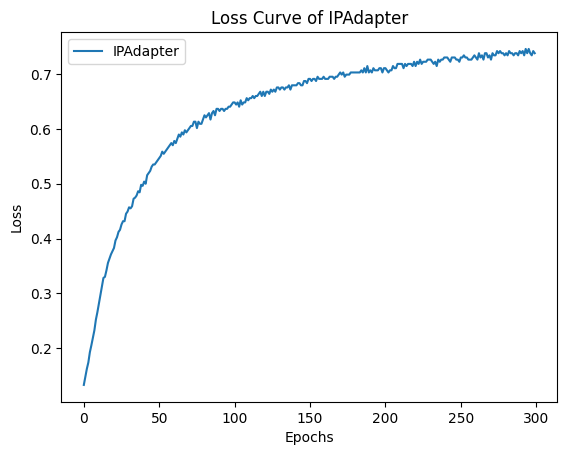

In [7]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IPAdapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IPAdapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## 10 * VAE + 1 * CLIP
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae-ipadapter_yingbu_no-agm-w1-0-w2-10-w3-1_mse_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [ ]:
loss_dict_list = [{'loss_sum': -2.8125, 'loss': -24.125, 'vae': -2.359375, 'ipadapter': -0.453125}, {'loss_sum': -2.59375, 'loss': -22.0, 'vae': -2.15625, 'ipadapter': -0.439453125}, {'loss_sum': -2.40625, 'loss': -20.125, 'vae': -1.9765625, 'ipadapter': -0.427734375}, {'loss_sum': -2.28125, 'loss': -19.0, 'vae': -1.859375, 'ipadapter': -0.41796875}, {'loss_sum': -2.1875, 'loss': -18.125, 'vae': -1.78125, 'ipadapter': -0.40625}, {'loss_sum': -2.109375, 'loss': -17.5, 'vae': -1.7109375, 'ipadapter': -0.396484375}, {'loss_sum': -2.046875, 'loss': -17.0, 'vae': -1.6640625, 'ipadapter': -0.38671875}, {'loss_sum': -1.9921875, 'loss': -16.5, 'vae': -1.6171875, 'ipadapter': -0.376953125}, {'loss_sum': -1.9453125, 'loss': -16.125, 'vae': -1.578125, 'ipadapter': -0.3671875}, {'loss_sum': -1.90625, 'loss': -15.875, 'vae': -1.546875, 'ipadapter': -0.36328125}, {'loss_sum': -1.875, 'loss': -15.5, 'vae': -1.515625, 'ipadapter': -0.35546875}, {'loss_sum': -1.84375, 'loss': -15.3125, 'vae': -1.4921875, 'ipadapter': -0.353515625}, {'loss_sum': -1.8203125, 'loss': -15.0625, 'vae': -1.46875, 'ipadapter': -0.349609375}, {'loss_sum': -1.7890625, 'loss': -14.8125, 'vae': -1.4453125, 'ipadapter': -0.345703125}, {'loss_sum': -1.7734375, 'loss': -14.625, 'vae': -1.4296875, 'ipadapter': -0.341796875}, {'loss_sum': -1.75, 'loss': -14.4375, 'vae': -1.4140625, 'ipadapter': -0.33984375}, {'loss_sum': -1.734375, 'loss': -14.3125, 'vae': -1.3984375, 'ipadapter': -0.337890625}, {'loss_sum': -1.71875, 'loss': -14.125, 'vae': -1.3828125, 'ipadapter': -0.333984375}, {'loss_sum': -1.6953125, 'loss': -14.0, 'vae': -1.3671875, 'ipadapter': -0.330078125}, {'loss_sum': -1.6796875, 'loss': -13.8125, 'vae': -1.3515625, 'ipadapter': -0.326171875}, {'loss_sum': -1.671875, 'loss': -13.75, 'vae': -1.34375, 'ipadapter': -0.32421875}, {'loss_sum': -1.65625, 'loss': -13.6875, 'vae': -1.3359375, 'ipadapter': -0.32421875}, {'loss_sum': -1.6484375, 'loss': -13.5625, 'vae': -1.328125, 'ipadapter': -0.322265625}, {'loss_sum': -1.6328125, 'loss': -13.4375, 'vae': -1.3125, 'ipadapter': -0.3203125}, {'loss_sum': -1.625, 'loss': -13.375, 'vae': -1.3046875, 'ipadapter': -0.3203125}, {'loss_sum': -1.625, 'loss': -13.375, 'vae': -1.3046875, 'ipadapter': -0.318359375}, {'loss_sum': -1.609375, 'loss': -13.3125, 'vae': -1.296875, 'ipadapter': -0.31640625}, {'loss_sum': -1.6015625, 'loss': -13.1875, 'vae': -1.2890625, 'ipadapter': -0.314453125}, {'loss_sum': -1.59375, 'loss': -13.125, 'vae': -1.28125, 'ipadapter': -0.3125}, {'loss_sum': -1.59375, 'loss': -13.125, 'vae': -1.28125, 'ipadapter': -0.3125}, {'loss_sum': -1.5859375, 'loss': -13.0625, 'vae': -1.2734375, 'ipadapter': -0.3125}, {'loss_sum': -1.578125, 'loss': -12.9375, 'vae': -1.265625, 'ipadapter': -0.3125}, {'loss_sum': -1.578125, 'loss': -12.9375, 'vae': -1.265625, 'ipadapter': -0.310546875}, {'loss_sum': -1.5625, 'loss': -12.875, 'vae': -1.2578125, 'ipadapter': -0.30859375}, {'loss_sum': -1.5703125, 'loss': -12.875, 'vae': -1.2578125, 'ipadapter': -0.310546875}, {'loss_sum': -1.5625, 'loss': -12.8125, 'vae': -1.25, 'ipadapter': -0.30859375}, {'loss_sum': -1.5625, 'loss': -12.8125, 'vae': -1.25, 'ipadapter': -0.30859375}, {'loss_sum': -1.546875, 'loss': -12.75, 'vae': -1.2421875, 'ipadapter': -0.306640625}, {'loss_sum': -1.546875, 'loss': -12.75, 'vae': -1.2421875, 'ipadapter': -0.306640625}, {'loss_sum': -1.546875, 'loss': -12.75, 'vae': -1.2421875, 'ipadapter': -0.3046875}, {'loss_sum': -1.5390625, 'loss': -12.6875, 'vae': -1.234375, 'ipadapter': -0.302734375}, {'loss_sum': -1.5390625, 'loss': -12.6875, 'vae': -1.234375, 'ipadapter': -0.302734375}, {'loss_sum': -1.5390625, 'loss': -12.6875, 'vae': -1.234375, 'ipadapter': -0.3046875}, {'loss_sum': -1.53125, 'loss': -12.5625, 'vae': -1.2265625, 'ipadapter': -0.302734375}, {'loss_sum': -1.53125, 'loss': -12.5625, 'vae': -1.2265625, 'ipadapter': -0.302734375}, {'loss_sum': -1.53125, 'loss': -12.5625, 'vae': -1.2265625, 'ipadapter': -0.302734375}, {'loss_sum': -1.5234375, 'loss': -12.5, 'vae': -1.21875, 'ipadapter': -0.302734375}, {'loss_sum': -1.5234375, 'loss': -12.5, 'vae': -1.21875, 'ipadapter': -0.302734375}, {'loss_sum': -1.515625, 'loss': -12.5, 'vae': -1.21875, 'ipadapter': -0.30078125}, {'loss_sum': -1.515625, 'loss': -12.4375, 'vae': -1.2109375, 'ipadapter': -0.302734375}, {'loss_sum': -1.515625, 'loss': -12.4375, 'vae': -1.2109375, 'ipadapter': -0.30078125}, {'loss_sum': -1.515625, 'loss': -12.4375, 'vae': -1.2109375, 'ipadapter': -0.30078125}, {'loss_sum': -1.515625, 'loss': -12.4375, 'vae': -1.2109375, 'ipadapter': -0.30078125}, {'loss_sum': -1.5, 'loss': -12.3125, 'vae': -1.203125, 'ipadapter': -0.298828125}, {'loss_sum': -1.5, 'loss': -12.3125, 'vae': -1.203125, 'ipadapter': -0.298828125}, {'loss_sum': -1.5, 'loss': -12.3125, 'vae': -1.203125, 'ipadapter': -0.296875}, {'loss_sum': -1.5, 'loss': -12.3125, 'vae': -1.203125, 'ipadapter': -0.296875}, {'loss_sum': -1.4921875, 'loss': -12.25, 'vae': -1.1953125, 'ipadapter': -0.296875}, {'loss_sum': -1.4921875, 'loss': -12.25, 'vae': -1.1953125, 'ipadapter': -0.298828125}, {'loss_sum': -1.4921875, 'loss': -12.25, 'vae': -1.1953125, 'ipadapter': -0.298828125}, {'loss_sum': -1.4921875, 'loss': -12.25, 'vae': -1.1953125, 'ipadapter': -0.298828125}, {'loss_sum': -1.4921875, 'loss': -12.25, 'vae': -1.1953125, 'ipadapter': -0.296875}, {'loss_sum': -1.4921875, 'loss': -12.25, 'vae': -1.1953125, 'ipadapter': -0.294921875}, {'loss_sum': -1.484375, 'loss': -12.1875, 'vae': -1.1875, 'ipadapter': -0.294921875}, {'loss_sum': -1.484375, 'loss': -12.1875, 'vae': -1.1875, 'ipadapter': -0.294921875}, {'loss_sum': -1.484375, 'loss': -12.1875, 'vae': -1.1875, 'ipadapter': -0.294921875}, {'loss_sum': -1.484375, 'loss': -12.1875, 'vae': -1.1875, 'ipadapter': -0.294921875}, {'loss_sum': -1.484375, 'loss': -12.1875, 'vae': -1.1875, 'ipadapter': -0.294921875}, {'loss_sum': -1.484375, 'loss': -12.1875, 'vae': -1.1875, 'ipadapter': -0.294921875}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.29296875}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.29296875}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.29296875}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.291015625}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.29296875}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.291015625}, {'loss_sum': -1.46875, 'loss': -12.125, 'vae': -1.1796875, 'ipadapter': -0.291015625}, {'loss_sum': -1.46875, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.29296875}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.291015625}, {'loss_sum': -1.46875, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.29296875}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.291015625}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.291015625}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.2890625}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.2890625}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.287109375}, {'loss_sum': -1.4609375, 'loss': -12.0625, 'vae': -1.171875, 'ipadapter': -0.287109375}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.28515625}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.287109375}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.28515625}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.287109375}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.28515625}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.28515625}, {'loss_sum': -1.4453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.283203125}, {'loss_sum': -1.453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.28515625}, {'loss_sum': -1.4453125, 'loss': -11.9375, 'vae': -1.1640625, 'ipadapter': -0.283203125}, {'loss_sum': -1.4453125, 'loss': -11.875, 'vae': -1.1640625, 'ipadapter': -0.28125}, {'loss_sum': -1.4453125, 'loss': -11.875, 'vae': -1.1640625, 'ipadapter': -0.28125}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.28125}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.283203125}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.283203125}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.283203125}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.28125}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.279296875}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.28125}, {'loss_sum': -1.4375, 'loss': -11.875, 'vae': -1.15625, 'ipadapter': -0.28125}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.279296875}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.279296875}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.279296875}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.279296875}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.27734375}, {'loss_sum': -1.4375, 'loss': -11.8125, 'vae': -1.15625, 'ipadapter': -0.27734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.27734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.27734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.275390625}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.275390625}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.275390625}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.275390625}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.2734375}, {'loss_sum': -1.4140625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.271484375}, {'loss_sum': -1.421875, 'loss': -11.75, 'vae': -1.1484375, 'ipadapter': -0.271484375}, {'loss_sum': -1.4140625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.271484375}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.26953125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.265625}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.267578125}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.265625}, {'loss_sum': -1.40625, 'loss': -11.625, 'vae': -1.140625, 'ipadapter': -0.265625}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.265625}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.265625}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.265625}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.265625}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.265625}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.265625}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3984375, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.263671875}, {'loss_sum': -1.390625, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5625, 'vae': -1.1328125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.26171875}, {'loss_sum': -1.390625, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.259765625}, {'loss_sum': -1.390625, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.26171875}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.259765625}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.259765625}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.259765625}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.259765625}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.2578125}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.3828125, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.255859375}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.251953125}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.251953125}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.251953125}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.375, 'loss': -11.5, 'vae': -1.125, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25390625}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25390625}, {'loss_sum': -1.375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25390625}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2490234375}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.251953125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.25}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2470703125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2470703125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2490234375}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2470703125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2470703125}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.248046875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.24609375}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.24609375}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.24609375}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2470703125}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2451171875}, {'loss_sum': -1.3671875, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2470703125}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2431640625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2431640625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2431640625}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.244140625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2431640625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.240234375}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2412109375}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2451171875}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.244140625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2421875}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.2431640625}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2431640625}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.2431640625}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.2431640625}, {'loss_sum': -1.3515625, 'loss': -11.375, 'vae': -1.109375, 'ipadapter': -0.2412109375}, {'loss_sum': -1.359375, 'loss': -11.4375, 'vae': -1.1171875, 'ipadapter': -0.2431640625}]


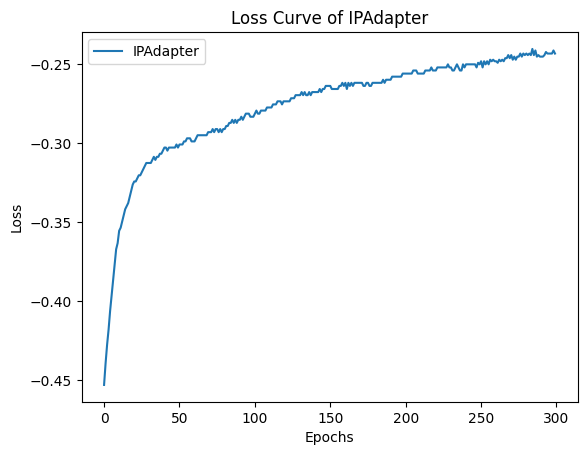

In [11]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IPAdapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IPAdapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## AGM(VAE+IP-Adapter)
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae-ipadapter_yingbu_agm_mse_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [1]:
# loss_dict_list = [{'loss_sum': -2.8125, 'loss': -1.3217787742614746, 'vae': -2.359375, 'ipadapter': -0.453125}, {'loss_sum': -2.609375, 'loss': -1.0572600364685059, 'vae': -2.1875, 'ipadapter': -0.423828125}, {'loss_sum': -2.4375, 'loss': -1.1028938293457031, 'vae': -2.046875, 'ipadapter': -0.3984375}, {'loss_sum': -2.296875, 'loss': -1.018142580986023, 'vae': -1.921875, 'ipadapter': -0.376953125}, {'loss_sum': -2.203125, 'loss': -1.0157577991485596, 'vae': -1.8359375, 'ipadapter': -0.36328125}, {'loss_sum': -2.109375, 'loss': -0.9424364566802979, 'vae': -1.765625, 'ipadapter': -0.349609375}, {'loss_sum': -2.046875, 'loss': -0.9201123714447021, 'vae': -1.7109375, 'ipadapter': -0.33984375}, {'loss_sum': -2.0, 'loss': -0.8597550392150879, 'vae': -1.671875, 'ipadapter': -0.333984375}, {'loss_sum': -1.96875, 'loss': -0.8918200731277466, 'vae': -1.640625, 'ipadapter': -0.328125}, {'loss_sum': -1.9375, 'loss': -0.8169972896575928, 'vae': -1.609375, 'ipadapter': -0.32421875}, {'loss_sum': -1.8984375, 'loss': -0.8546525835990906, 'vae': -1.578125, 'ipadapter': -0.3203125}, {'loss_sum': -1.875, 'loss': -0.7828946709632874, 'vae': -1.5546875, 'ipadapter': -0.31640625}, {'loss_sum': -1.84375, 'loss': -0.8208835124969482, 'vae': -1.53125, 'ipadapter': -0.310546875}, {'loss_sum': -1.8125, 'loss': -0.7536799907684326, 'vae': -1.5078125, 'ipadapter': -0.306640625}, {'loss_sum': -1.796875, 'loss': -0.7616189122200012, 'vae': -1.4921875, 'ipadapter': -0.3046875}, {'loss_sum': -1.7734375, 'loss': -0.7503950595855713, 'vae': -1.46875, 'ipadapter': -0.302734375}, {'loss_sum': -1.75, 'loss': -0.7703445553779602, 'vae': -1.453125, 'ipadapter': -0.298828125}, {'loss_sum': -1.734375, 'loss': -0.7144676446914673, 'vae': -1.4375, 'ipadapter': -0.296875}, {'loss_sum': -1.7265625, 'loss': -0.775892972946167, 'vae': -1.4296875, 'ipadapter': -0.296875}, {'loss_sum': -1.7109375, 'loss': -0.7177472114562988, 'vae': -1.421875, 'ipadapter': -0.291015625}, {'loss_sum': -1.6953125, 'loss': -0.7594664692878723, 'vae': -1.40625, 'ipadapter': -0.291015625}, {'loss_sum': -1.6875, 'loss': -0.7205843925476074, 'vae': -1.3984375, 'ipadapter': -0.2890625}, {'loss_sum': -1.6796875, 'loss': -0.7327212691307068, 'vae': -1.390625, 'ipadapter': -0.287109375}, {'loss_sum': -1.6640625, 'loss': -0.6933284997940063, 'vae': -1.3828125, 'ipadapter': -0.283203125}, {'loss_sum': -1.65625, 'loss': -0.706356406211853, 'vae': -1.375, 'ipadapter': -0.283203125}, {'loss_sum': -1.6484375, 'loss': -0.6845417618751526, 'vae': -1.3671875, 'ipadapter': -0.28125}, {'loss_sum': -1.640625, 'loss': -0.6927467584609985, 'vae': -1.359375, 'ipadapter': -0.27734375}, {'loss_sum': -1.625, 'loss': -0.6731368899345398, 'vae': -1.3515625, 'ipadapter': -0.27734375}, {'loss_sum': -1.6171875, 'loss': -0.6680374145507812, 'vae': -1.34375, 'ipadapter': -0.275390625}, {'loss_sum': -1.6171875, 'loss': -0.6658824682235718, 'vae': -1.34375, 'ipadapter': -0.2734375}, {'loss_sum': -1.609375, 'loss': -0.6911975741386414, 'vae': -1.3359375, 'ipadapter': -0.271484375}, {'loss_sum': -1.609375, 'loss': -0.6596157550811768, 'vae': -1.3359375, 'ipadapter': -0.26953125}, {'loss_sum': -1.59375, 'loss': -0.6861600875854492, 'vae': -1.328125, 'ipadapter': -0.26953125}, {'loss_sum': -1.5859375, 'loss': -0.6494693756103516, 'vae': -1.3203125, 'ipadapter': -0.265625}, {'loss_sum': -1.5859375, 'loss': -0.6627197265625, 'vae': -1.3203125, 'ipadapter': -0.265625}, {'loss_sum': -1.578125, 'loss': -0.6905020475387573, 'vae': -1.3125, 'ipadapter': -0.265625}, {'loss_sum': -1.578125, 'loss': -0.6394864320755005, 'vae': -1.3125, 'ipadapter': -0.26171875}, {'loss_sum': -1.5703125, 'loss': -0.6708648800849915, 'vae': -1.3046875, 'ipadapter': -0.263671875}, {'loss_sum': -1.5625, 'loss': -0.6496100425720215, 'vae': -1.3046875, 'ipadapter': -0.259765625}, {'loss_sum': -1.5625, 'loss': -0.665492057800293, 'vae': -1.3046875, 'ipadapter': -0.2578125}, {'loss_sum': -1.5546875, 'loss': -0.6919823884963989, 'vae': -1.296875, 'ipadapter': -0.255859375}, {'loss_sum': -1.546875, 'loss': -0.6547994017601013, 'vae': -1.296875, 'ipadapter': -0.25390625}, {'loss_sum': -1.546875, 'loss': -0.607577383518219, 'vae': -1.296875, 'ipadapter': -0.251953125}, {'loss_sum': -1.5390625, 'loss': -0.6345832943916321, 'vae': -1.2890625, 'ipadapter': -0.251953125}, {'loss_sum': -1.5390625, 'loss': -0.6676111221313477, 'vae': -1.2890625, 'ipadapter': -0.251953125}, {'loss_sum': -1.5390625, 'loss': -0.6051458716392517, 'vae': -1.2890625, 'ipadapter': -0.248046875}, {'loss_sum': -1.53125, 'loss': -0.6229445934295654, 'vae': -1.28125, 'ipadapter': -0.2470703125}, {'loss_sum': -1.53125, 'loss': -0.5988539457321167, 'vae': -1.28125, 'ipadapter': -0.2470703125}, {'loss_sum': -1.53125, 'loss': -0.583925187587738, 'vae': -1.28125, 'ipadapter': -0.2470703125}, {'loss_sum': -1.53125, 'loss': -0.6477271914482117, 'vae': -1.28125, 'ipadapter': -0.24609375}, {'loss_sum': -1.515625, 'loss': -0.5984607934951782, 'vae': -1.2734375, 'ipadapter': -0.2412109375}, {'loss_sum': -1.515625, 'loss': -0.5852071642875671, 'vae': -1.2734375, 'ipadapter': -0.2392578125}, {'loss_sum': -1.515625, 'loss': -0.6269693374633789, 'vae': -1.2734375, 'ipadapter': -0.240234375}, {'loss_sum': -1.5078125, 'loss': -0.5975425243377686, 'vae': -1.2734375, 'ipadapter': -0.236328125}, {'loss_sum': -1.5, 'loss': -0.5979716181755066, 'vae': -1.265625, 'ipadapter': -0.2373046875}, {'loss_sum': -1.5, 'loss': -0.578737735748291, 'vae': -1.265625, 'ipadapter': -0.2353515625}, {'loss_sum': -1.5, 'loss': -0.5997508764266968, 'vae': -1.265625, 'ipadapter': -0.234375}, {'loss_sum': -1.5, 'loss': -0.615925669670105, 'vae': -1.265625, 'ipadapter': -0.2333984375}, {'loss_sum': -1.484375, 'loss': -0.5587618947029114, 'vae': -1.2578125, 'ipadapter': -0.2294921875}, {'loss_sum': -1.4921875, 'loss': -0.5667195320129395, 'vae': -1.2578125, 'ipadapter': -0.2314453125}, {'loss_sum': -1.484375, 'loss': -0.5087116360664368, 'vae': -1.2578125, 'ipadapter': -0.23046875}, {'loss_sum': -1.484375, 'loss': -0.6315276622772217, 'vae': -1.2578125, 'ipadapter': -0.23046875}, {'loss_sum': -1.484375, 'loss': -0.547501802444458, 'vae': -1.2578125, 'ipadapter': -0.2275390625}, {'loss_sum': -1.484375, 'loss': -0.5846230387687683, 'vae': -1.2578125, 'ipadapter': -0.2255859375}, {'loss_sum': -1.484375, 'loss': -0.5593335628509521, 'vae': -1.2578125, 'ipadapter': -0.224609375}, {'loss_sum': -1.4765625, 'loss': -0.555942952632904, 'vae': -1.25, 'ipadapter': -0.224609375}, {'loss_sum': -1.46875, 'loss': -0.5756236910820007, 'vae': -1.25, 'ipadapter': -0.22265625}, {'loss_sum': -1.46875, 'loss': -0.5342550277709961, 'vae': -1.25, 'ipadapter': -0.22265625}, {'loss_sum': -1.46875, 'loss': -0.5584546327590942, 'vae': -1.25, 'ipadapter': -0.22265625}, {'loss_sum': -1.46875, 'loss': -0.4962127208709717, 'vae': -1.25, 'ipadapter': -0.220703125}, {'loss_sum': -1.4609375, 'loss': -0.5368607044219971, 'vae': -1.2421875, 'ipadapter': -0.2216796875}, {'loss_sum': -1.4609375, 'loss': -0.5317544937133789, 'vae': -1.2421875, 'ipadapter': -0.21875}, {'loss_sum': -1.4609375, 'loss': -0.5526188611984253, 'vae': -1.2421875, 'ipadapter': -0.21875}, {'loss_sum': -1.4609375, 'loss': -0.5141423940658569, 'vae': -1.2421875, 'ipadapter': -0.2158203125}, {'loss_sum': -1.4609375, 'loss': -0.5717964172363281, 'vae': -1.2421875, 'ipadapter': -0.216796875}, {'loss_sum': -1.453125, 'loss': -0.5243050456047058, 'vae': -1.2421875, 'ipadapter': -0.212890625}, {'loss_sum': -1.453125, 'loss': -0.5016152858734131, 'vae': -1.2421875, 'ipadapter': -0.212890625}, {'loss_sum': -1.4453125, 'loss': -0.5530298948287964, 'vae': -1.234375, 'ipadapter': -0.2138671875}, {'loss_sum': -1.4453125, 'loss': -0.5050370693206787, 'vae': -1.234375, 'ipadapter': -0.2119140625}, {'loss_sum': -1.4453125, 'loss': -0.5033082962036133, 'vae': -1.234375, 'ipadapter': -0.2109375}, {'loss_sum': -1.4453125, 'loss': -0.5487479567527771, 'vae': -1.234375, 'ipadapter': -0.2119140625}, {'loss_sum': -1.4453125, 'loss': -0.6063350439071655, 'vae': -1.234375, 'ipadapter': -0.2080078125}, {'loss_sum': -1.4375, 'loss': -0.5177114009857178, 'vae': -1.234375, 'ipadapter': -0.205078125}, {'loss_sum': -1.4375, 'loss': -0.5849193334579468, 'vae': -1.234375, 'ipadapter': -0.20703125}, {'loss_sum': -1.4375, 'loss': -0.5265854597091675, 'vae': -1.234375, 'ipadapter': -0.2060546875}, {'loss_sum': -1.4375, 'loss': -0.4827690124511719, 'vae': -1.234375, 'ipadapter': -0.2041015625}, {'loss_sum': -1.4296875, 'loss': -0.5490134954452515, 'vae': -1.2265625, 'ipadapter': -0.205078125}, {'loss_sum': -1.4296875, 'loss': -0.4626440405845642, 'vae': -1.2265625, 'ipadapter': -0.2021484375}, {'loss_sum': -1.4296875, 'loss': -0.5505151748657227, 'vae': -1.2265625, 'ipadapter': -0.2041015625}, {'loss_sum': -1.4296875, 'loss': -0.47207051515579224, 'vae': -1.2265625, 'ipadapter': -0.2001953125}, {'loss_sum': -1.4296875, 'loss': -0.5481967926025391, 'vae': -1.2265625, 'ipadapter': -0.2021484375}, {'loss_sum': -1.421875, 'loss': -0.5098944902420044, 'vae': -1.2265625, 'ipadapter': -0.19921875}, {'loss_sum': -1.4296875, 'loss': -0.49713432788848877, 'vae': -1.2265625, 'ipadapter': -0.2021484375}, {'loss_sum': -1.4296875, 'loss': -0.5130491256713867, 'vae': -1.2265625, 'ipadapter': -0.2021484375}, {'loss_sum': -1.4296875, 'loss': -0.48875656723976135, 'vae': -1.2265625, 'ipadapter': -0.201171875}, {'loss_sum': -1.4296875, 'loss': -0.5715539455413818, 'vae': -1.2265625, 'ipadapter': -0.2001953125}, {'loss_sum': -1.421875, 'loss': -0.5051389932632446, 'vae': -1.2265625, 'ipadapter': -0.197265625}, {'loss_sum': -1.421875, 'loss': -0.465192973613739, 'vae': -1.2265625, 'ipadapter': -0.197265625}, {'loss_sum': -1.421875, 'loss': -0.5331618189811707, 'vae': -1.2265625, 'ipadapter': -0.19921875}, {'loss_sum': -1.4140625, 'loss': -0.4643414616584778, 'vae': -1.21875, 'ipadapter': -0.197265625}, {'loss_sum': -1.421875, 'loss': -0.544404149055481, 'vae': -1.21875, 'ipadapter': -0.19921875}, {'loss_sum': -1.4140625, 'loss': -0.5686902403831482, 'vae': -1.21875, 'ipadapter': -0.197265625}, {'loss_sum': -1.4140625, 'loss': -0.45783472061157227, 'vae': -1.21875, 'ipadapter': -0.1943359375}, {'loss_sum': -1.4140625, 'loss': -0.5439262986183167, 'vae': -1.21875, 'ipadapter': -0.1962890625}, {'loss_sum': -1.4140625, 'loss': -0.49593114852905273, 'vae': -1.21875, 'ipadapter': -0.193359375}, {'loss_sum': -1.40625, 'loss': -0.44602370262145996, 'vae': -1.21875, 'ipadapter': -0.19140625}, {'loss_sum': -1.4140625, 'loss': -0.560116708278656, 'vae': -1.21875, 'ipadapter': -0.1953125}, {'loss_sum': -1.40625, 'loss': -0.45865944027900696, 'vae': -1.21875, 'ipadapter': -0.1904296875}, {'loss_sum': -1.4140625, 'loss': -0.4625466763973236, 'vae': -1.21875, 'ipadapter': -0.1923828125}, {'loss_sum': -1.4140625, 'loss': -0.4754870533943176, 'vae': -1.21875, 'ipadapter': -0.1923828125}, {'loss_sum': -1.40625, 'loss': -0.48872649669647217, 'vae': -1.2109375, 'ipadapter': -0.19140625}, {'loss_sum': -1.3984375, 'loss': -0.46806764602661133, 'vae': -1.2109375, 'ipadapter': -0.1884765625}, {'loss_sum': -1.3984375, 'loss': -0.4986814558506012, 'vae': -1.2109375, 'ipadapter': -0.1904296875}, {'loss_sum': -1.3984375, 'loss': -0.4299588203430176, 'vae': -1.2109375, 'ipadapter': -0.1884765625}, {'loss_sum': -1.3984375, 'loss': -0.4895952045917511, 'vae': -1.2109375, 'ipadapter': -0.189453125}, {'loss_sum': -1.3984375, 'loss': -0.450664222240448, 'vae': -1.2109375, 'ipadapter': -0.189453125}, {'loss_sum': -1.40625, 'loss': -0.5012716054916382, 'vae': -1.2109375, 'ipadapter': -0.1923828125}, {'loss_sum': -1.40625, 'loss': -0.47248125076293945, 'vae': -1.2109375, 'ipadapter': -0.19140625}, {'loss_sum': -1.3984375, 'loss': -0.4856449067592621, 'vae': -1.2109375, 'ipadapter': -0.1904296875}, {'loss_sum': -1.3984375, 'loss': -0.5483509302139282, 'vae': -1.2109375, 'ipadapter': -0.189453125}, {'loss_sum': -1.3984375, 'loss': -0.42720842361450195, 'vae': -1.2109375, 'ipadapter': -0.1865234375}, {'loss_sum': -1.3984375, 'loss': -0.5142333507537842, 'vae': -1.2109375, 'ipadapter': -0.189453125}, {'loss_sum': -1.3984375, 'loss': -0.46544021368026733, 'vae': -1.2109375, 'ipadapter': -0.185546875}, {'loss_sum': -1.3984375, 'loss': -0.46141916513442993, 'vae': -1.2109375, 'ipadapter': -0.185546875}, {'loss_sum': -1.3984375, 'loss': -0.46473023295402527, 'vae': -1.2109375, 'ipadapter': -0.1845703125}, {'loss_sum': -1.390625, 'loss': -0.4613924026489258, 'vae': -1.2109375, 'ipadapter': -0.18359375}, {'loss_sum': -1.390625, 'loss': -0.46355023980140686, 'vae': -1.2109375, 'ipadapter': -0.1826171875}, {'loss_sum': -1.390625, 'loss': -0.44038066267967224, 'vae': -1.2109375, 'ipadapter': -0.181640625}, {'loss_sum': -1.3828125, 'loss': -0.4722369313240051, 'vae': -1.203125, 'ipadapter': -0.1826171875}, {'loss_sum': -1.390625, 'loss': -0.42393046617507935, 'vae': -1.2109375, 'ipadapter': -0.1826171875}, {'loss_sum': -1.3828125, 'loss': -0.43914785981178284, 'vae': -1.203125, 'ipadapter': -0.1826171875}, {'loss_sum': -1.3828125, 'loss': -0.4759468734264374, 'vae': -1.203125, 'ipadapter': -0.181640625}, {'loss_sum': -1.3828125, 'loss': -0.44733726978302, 'vae': -1.203125, 'ipadapter': -0.1796875}, {'loss_sum': -1.3828125, 'loss': -0.4265759587287903, 'vae': -1.203125, 'ipadapter': -0.1787109375}, {'loss_sum': -1.3828125, 'loss': -0.44375717639923096, 'vae': -1.203125, 'ipadapter': -0.1796875}, {'loss_sum': -1.3828125, 'loss': -0.4683346152305603, 'vae': -1.203125, 'ipadapter': -0.1787109375}, {'loss_sum': -1.3828125, 'loss': -0.4237198233604431, 'vae': -1.203125, 'ipadapter': -0.1767578125}, {'loss_sum': -1.3828125, 'loss': -0.47620290517807007, 'vae': -1.203125, 'ipadapter': -0.177734375}, {'loss_sum': -1.3828125, 'loss': -0.4490460753440857, 'vae': -1.203125, 'ipadapter': -0.1767578125}, {'loss_sum': -1.3828125, 'loss': -0.45421597361564636, 'vae': -1.203125, 'ipadapter': -0.177734375}, {'loss_sum': -1.375, 'loss': -0.43321770429611206, 'vae': -1.203125, 'ipadapter': -0.1748046875}, {'loss_sum': -1.375, 'loss': -0.43321770429611206, 'vae': -1.203125, 'ipadapter': -0.1748046875}, {'loss_sum': -1.375, 'loss': -0.4521781802177429, 'vae': -1.203125, 'ipadapter': -0.173828125}, {'loss_sum': -1.375, 'loss': -0.4226346015930176, 'vae': -1.203125, 'ipadapter': -0.1728515625}, {'loss_sum': -1.375, 'loss': -0.4353674352169037, 'vae': -1.203125, 'ipadapter': -0.1748046875}, {'loss_sum': -1.375, 'loss': -0.39620834589004517, 'vae': -1.203125, 'ipadapter': -0.173828125}, {'loss_sum': -1.375, 'loss': -0.4411097764968872, 'vae': -1.203125, 'ipadapter': -0.173828125}, {'loss_sum': -1.375, 'loss': -0.42749810218811035, 'vae': -1.203125, 'ipadapter': -0.1728515625}, {'loss_sum': -1.375, 'loss': -0.413213849067688, 'vae': -1.203125, 'ipadapter': -0.169921875}, {'loss_sum': -1.375, 'loss': -0.38243842124938965, 'vae': -1.203125, 'ipadapter': -0.171875}, {'loss_sum': -1.3671875, 'loss': -0.4632995128631592, 'vae': -1.1953125, 'ipadapter': -0.173828125}, {'loss_sum': -1.375, 'loss': -0.45409947633743286, 'vae': -1.203125, 'ipadapter': -0.1708984375}, {'loss_sum': -1.375, 'loss': -0.4057199954986572, 'vae': -1.203125, 'ipadapter': -0.169921875}, {'loss_sum': -1.3671875, 'loss': -0.45266467332839966, 'vae': -1.1953125, 'ipadapter': -0.171875}, {'loss_sum': -1.375, 'loss': -0.4543617069721222, 'vae': -1.203125, 'ipadapter': -0.169921875}, {'loss_sum': -1.3671875, 'loss': -0.4461195468902588, 'vae': -1.1953125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.3671875, 'loss': -0.4504951536655426, 'vae': -1.1953125, 'ipadapter': -0.1708984375}, {'loss_sum': -1.375, 'loss': -0.4393238425254822, 'vae': -1.203125, 'ipadapter': -0.1708984375}, {'loss_sum': -1.3671875, 'loss': -0.437292218208313, 'vae': -1.1953125, 'ipadapter': -0.1708984375}, {'loss_sum': -1.3671875, 'loss': -0.4571712613105774, 'vae': -1.1953125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.359375, 'loss': -0.4009758234024048, 'vae': -1.1953125, 'ipadapter': -0.16796875}, {'loss_sum': -1.3671875, 'loss': -0.4643170237541199, 'vae': -1.1953125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.359375, 'loss': -0.3915415108203888, 'vae': -1.1953125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.359375, 'loss': -0.44878116250038147, 'vae': -1.1953125, 'ipadapter': -0.166015625}, {'loss_sum': -1.359375, 'loss': -0.43386244773864746, 'vae': -1.1953125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.359375, 'loss': -0.45266157388687134, 'vae': -1.1953125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.359375, 'loss': -0.40622955560684204, 'vae': -1.1953125, 'ipadapter': -0.166015625}, {'loss_sum': -1.359375, 'loss': -0.3923042416572571, 'vae': -1.1953125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.3671875, 'loss': -0.4524135887622833, 'vae': -1.1953125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.359375, 'loss': -0.3980116546154022, 'vae': -1.1953125, 'ipadapter': -0.1650390625}, {'loss_sum': -1.359375, 'loss': -0.4370037913322449, 'vae': -1.1953125, 'ipadapter': -0.166015625}, {'loss_sum': -1.359375, 'loss': -0.43257176876068115, 'vae': -1.1953125, 'ipadapter': -0.162109375}, {'loss_sum': -1.359375, 'loss': -0.43257176876068115, 'vae': -1.1953125, 'ipadapter': -0.162109375}, {'loss_sum': -1.3671875, 'loss': -0.3716816306114197, 'vae': -1.203125, 'ipadapter': -0.162109375}, {'loss_sum': -1.359375, 'loss': -0.45247602462768555, 'vae': -1.1953125, 'ipadapter': -0.1650390625}, {'loss_sum': -1.359375, 'loss': -0.3887764811515808, 'vae': -1.1953125, 'ipadapter': -0.1611328125}, {'loss_sum': -1.359375, 'loss': -0.46840763092041016, 'vae': -1.1953125, 'ipadapter': -0.1630859375}, {'loss_sum': -1.359375, 'loss': -0.41946882009506226, 'vae': -1.1953125, 'ipadapter': -0.16015625}, {'loss_sum': -1.359375, 'loss': -0.4119584858417511, 'vae': -1.1953125, 'ipadapter': -0.1611328125}, {'loss_sum': -1.359375, 'loss': -0.4472495913505554, 'vae': -1.1953125, 'ipadapter': -0.162109375}, {'loss_sum': -1.3515625, 'loss': -0.344230592250824, 'vae': -1.1953125, 'ipadapter': -0.1591796875}, {'loss_sum': -1.359375, 'loss': -0.42397016286849976, 'vae': -1.1953125, 'ipadapter': -0.1640625}, {'loss_sum': -1.359375, 'loss': -0.4442589282989502, 'vae': -1.1953125, 'ipadapter': -0.16015625}, {'loss_sum': -1.3515625, 'loss': -0.35660988092422485, 'vae': -1.1953125, 'ipadapter': -0.1591796875}, {'loss_sum': -1.359375, 'loss': -0.44048774242401123, 'vae': -1.1953125, 'ipadapter': -0.1630859375}, {'loss_sum': -1.359375, 'loss': -0.3962518572807312, 'vae': -1.1953125, 'ipadapter': -0.1611328125}, {'loss_sum': -1.359375, 'loss': -0.3924022912979126, 'vae': -1.1953125, 'ipadapter': -0.162109375}, {'loss_sum': -1.359375, 'loss': -0.4247996509075165, 'vae': -1.1953125, 'ipadapter': -0.16015625}, {'loss_sum': -1.3515625, 'loss': -0.39532577991485596, 'vae': -1.1953125, 'ipadapter': -0.158203125}, {'loss_sum': -1.34375, 'loss': -0.4292185306549072, 'vae': -1.1875, 'ipadapter': -0.1591796875}, {'loss_sum': -1.3515625, 'loss': -0.39532577991485596, 'vae': -1.1953125, 'ipadapter': -0.158203125}, {'loss_sum': -1.3515625, 'loss': -0.4193830192089081, 'vae': -1.1953125, 'ipadapter': -0.1572265625}, {'loss_sum': -1.34375, 'loss': -0.39117199182510376, 'vae': -1.1875, 'ipadapter': -0.1572265625}, {'loss_sum': -1.34375, 'loss': -0.4046756625175476, 'vae': -1.1875, 'ipadapter': -0.158203125}, {'loss_sum': -1.3515625, 'loss': -0.4594101011753082, 'vae': -1.1953125, 'ipadapter': -0.1591796875}, {'loss_sum': -1.3515625, 'loss': -0.3820646405220032, 'vae': -1.1953125, 'ipadapter': -0.1552734375}, {'loss_sum': -1.359375, 'loss': -0.45431020855903625, 'vae': -1.1953125, 'ipadapter': -0.1611328125}, {'loss_sum': -1.3515625, 'loss': -0.3846995532512665, 'vae': -1.1953125, 'ipadapter': -0.158203125}, {'loss_sum': -1.34375, 'loss': -0.39748841524124146, 'vae': -1.1875, 'ipadapter': -0.1591796875}, {'loss_sum': -1.34375, 'loss': -0.4032214879989624, 'vae': -1.1875, 'ipadapter': -0.16015625}, {'loss_sum': -1.3515625, 'loss': -0.3852676451206207, 'vae': -1.1953125, 'ipadapter': -0.158203125}, {'loss_sum': -1.34375, 'loss': -0.39967286586761475, 'vae': -1.1875, 'ipadapter': -0.1572265625}, {'loss_sum': -1.34375, 'loss': -0.3938411474227905, 'vae': -1.1875, 'ipadapter': -0.15625}, {'loss_sum': -1.34375, 'loss': -0.3820631206035614, 'vae': -1.1875, 'ipadapter': -0.1552734375}, {'loss_sum': -1.34375, 'loss': -0.3770877718925476, 'vae': -1.1875, 'ipadapter': -0.15625}, {'loss_sum': -1.3515625, 'loss': -0.3641347885131836, 'vae': -1.1953125, 'ipadapter': -0.1552734375}, {'loss_sum': -1.34375, 'loss': -0.4313795864582062, 'vae': -1.1875, 'ipadapter': -0.158203125}, {'loss_sum': -1.34375, 'loss': -0.41646838188171387, 'vae': -1.1875, 'ipadapter': -0.154296875}, {'loss_sum': -1.34375, 'loss': -0.36898285150527954, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.34375, 'loss': -0.37444940209388733, 'vae': -1.1875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.34375, 'loss': -0.40170156955718994, 'vae': -1.1875, 'ipadapter': -0.154296875}, {'loss_sum': -1.34375, 'loss': -0.37686604261398315, 'vae': -1.1875, 'ipadapter': -0.154296875}, {'loss_sum': -1.34375, 'loss': -0.40021613240242004, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.34375, 'loss': -0.3399208188056946, 'vae': -1.1875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.34375, 'loss': -0.45443543791770935, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.3359375, 'loss': -0.33764684200286865, 'vae': -1.1875, 'ipadapter': -0.150390625}, {'loss_sum': -1.3359375, 'loss': -0.411531925201416, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.3789353668689728, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.37735825777053833, 'vae': -1.1875, 'ipadapter': -0.150390625}, {'loss_sum': -1.34375, 'loss': -0.42236194014549255, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.3359375, 'loss': -0.38448476791381836, 'vae': -1.1875, 'ipadapter': -0.1484375}, {'loss_sum': -1.3359375, 'loss': -0.34152525663375854, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.34375, 'loss': -0.43320488929748535, 'vae': -1.1875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.3359375, 'loss': -0.3526016175746918, 'vae': -1.1875, 'ipadapter': -0.150390625}, {'loss_sum': -1.3359375, 'loss': -0.3885512351989746, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.411531925201416, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.3681707978248596, 'vae': -1.1875, 'ipadapter': -0.1474609375}, {'loss_sum': -1.3359375, 'loss': -0.34152525663375854, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.34375, 'loss': -0.4355579614639282, 'vae': -1.1875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.3359375, 'loss': -0.3047633171081543, 'vae': -1.1875, 'ipadapter': -0.1484375}, {'loss_sum': -1.34375, 'loss': -0.4330432713031769, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.3359375, 'loss': -0.3185359835624695, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.3359375, 'loss': -0.38084086775779724, 'vae': -1.1875, 'ipadapter': -0.1484375}, {'loss_sum': -1.3359375, 'loss': -0.3408583998680115, 'vae': -1.1875, 'ipadapter': -0.1474609375}, {'loss_sum': -1.3359375, 'loss': -0.4025043845176697, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.3359375, 'loss': -0.32933664321899414, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.3359375, 'loss': -0.4932549297809601, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.3419486880302429, 'vae': -1.1875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.3359375, 'loss': -0.37132227420806885, 'vae': -1.1875, 'ipadapter': -0.1494140625}, {'loss_sum': -1.3359375, 'loss': -0.3391442596912384, 'vae': -1.1875, 'ipadapter': -0.1474609375}, {'loss_sum': -1.3359375, 'loss': -0.36959630250930786, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.3359375, 'loss': -0.38959020376205444, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.328125, 'loss': -0.3375392258167267, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.3359375, 'loss': -0.4373660087585449, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.328125, 'loss': -0.38076043128967285, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.35191065073013306, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.37088531255722046, 'vae': -1.1796875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.328125, 'loss': -0.34458744525909424, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.3359375, 'loss': -0.3893046975135803, 'vae': -1.1875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.328125, 'loss': -0.35614287853240967, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.3234248757362366, 'vae': -1.1875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.37903040647506714, 'vae': -1.1796875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.3359375, 'loss': -0.3497099280357361, 'vae': -1.1875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.328125, 'loss': -0.3595173954963684, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.38597241044044495, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.3467208743095398, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.3203125, 'loss': -0.35035139322280884, 'vae': -1.1796875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.4115852415561676, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.312343031167984, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.3203125, 'loss': -0.36888444423675537, 'vae': -1.1796875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.3359375, 'loss': -0.4265281856060028, 'vae': -1.1875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.328125, 'loss': -0.3386293351650238, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.386722207069397, 'vae': -1.1875, 'ipadapter': -0.14453125}, {'loss_sum': -1.328125, 'loss': -0.312100887298584, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.4046920835971832, 'vae': -1.1875, 'ipadapter': -0.14453125}, {'loss_sum': -1.328125, 'loss': -0.3103858232498169, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.3359375, 'loss': -0.38405340909957886, 'vae': -1.1953125, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.3441086411476135, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.3467208743095398, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.3696199059486389, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.42641592025756836, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.3203125, 'loss': -0.36186325550079346, 'vae': -1.1796875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.33801424503326416, 'vae': -1.1875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.39235976338386536, 'vae': -1.1875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.3543083965778351, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.39235976338386536, 'vae': -1.1875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.3467208743095398, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.3696105480194092, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.33942121267318726, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.4359877109527588, 'vae': -1.1875, 'ipadapter': -0.14453125}, {'loss_sum': -1.328125, 'loss': -0.336028128862381, 'vae': -1.1875, 'ipadapter': -0.1396484375}, {'loss_sum': -1.328125, 'loss': -0.38433313369750977, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.3191661536693573, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.3203125, 'loss': -0.3707229495048523, 'vae': -1.1796875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.4116823673248291, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.316736102104187, 'vae': -1.1875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.3203125, 'loss': -0.42570972442626953, 'vae': -1.1796875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.3933931887149811, 'vae': -1.1875, 'ipadapter': -0.1396484375}, {'loss_sum': -1.328125, 'loss': -0.29765865206718445, 'vae': -1.1875, 'ipadapter': -0.138671875}, {'loss_sum': -1.328125, 'loss': -0.4009018540382385, 'vae': -1.1796875, 'ipadapter': -0.14453125}, {'loss_sum': -1.328125, 'loss': -0.3441086411476135, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.3801546096801758, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.3203125, 'loss': -0.35218489170074463, 'vae': -1.1796875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.3044087290763855, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.3203125, 'loss': -0.4266808331012726, 'vae': -1.1796875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.3682662844657898, 'vae': -1.1875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.328125, 'loss': -0.34374210238456726, 'vae': -1.1875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.328125, 'loss': -0.31531789898872375, 'vae': -1.1875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.328125, 'loss': -0.35888612270355225, 'vae': -1.1875, 'ipadapter': -0.138671875}, {'loss_sum': -1.328125, 'loss': -0.3605197072029114, 'vae': -1.1875, 'ipadapter': -0.138671875}]


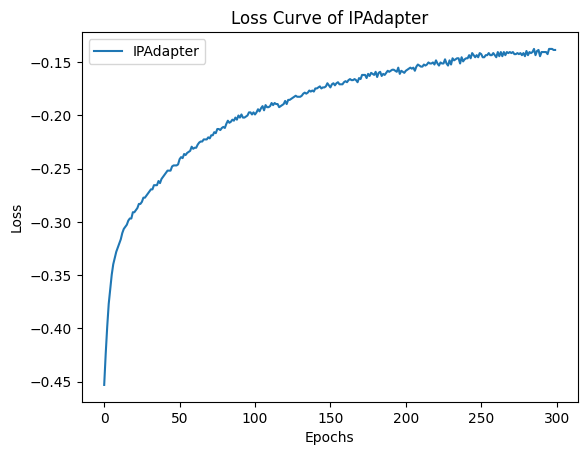

In [13]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IPAdapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IPAdapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## VAE Cosine
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae_yingbu_agm_cosine_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [8]:
loss_dict_list = [{'loss_sum': -0.11865234375, 'loss': -0.11865234375, 'vae': -0.11865234375}, {'loss_sum': -0.058837890625, 'loss': -0.058837890625, 'vae': -0.058837890625}, {'loss_sum': -0.000591278076171875, 'loss': -0.000591278076171875, 'vae': -0.000591278076171875}, {'loss_sum': 0.0478515625, 'loss': 0.0478515625, 'vae': 0.0478515625}, {'loss_sum': 0.08984375, 'loss': 0.08984375, 'vae': 0.08984375}, {'loss_sum': 0.125, 'loss': 0.125, 'vae': 0.125}, {'loss_sum': 0.1572265625, 'loss': 0.1572265625, 'vae': 0.1572265625}, {'loss_sum': 0.1845703125, 'loss': 0.1845703125, 'vae': 0.1845703125}, {'loss_sum': 0.20703125, 'loss': 0.20703125, 'vae': 0.20703125}, {'loss_sum': 0.2275390625, 'loss': 0.2275390625, 'vae': 0.2275390625}, {'loss_sum': 0.2470703125, 'loss': 0.2470703125, 'vae': 0.2470703125}, {'loss_sum': 0.263671875, 'loss': 0.263671875, 'vae': 0.263671875}, {'loss_sum': 0.279296875, 'loss': 0.279296875, 'vae': 0.279296875}, {'loss_sum': 0.29296875, 'loss': 0.29296875, 'vae': 0.29296875}, {'loss_sum': 0.306640625, 'loss': 0.306640625, 'vae': 0.306640625}, {'loss_sum': 0.318359375, 'loss': 0.318359375, 'vae': 0.318359375}, {'loss_sum': 0.328125, 'loss': 0.328125, 'vae': 0.328125}, {'loss_sum': 0.337890625, 'loss': 0.337890625, 'vae': 0.337890625}, {'loss_sum': 0.34765625, 'loss': 0.34765625, 'vae': 0.34765625}, {'loss_sum': 0.353515625, 'loss': 0.353515625, 'vae': 0.353515625}, {'loss_sum': 0.361328125, 'loss': 0.361328125, 'vae': 0.361328125}, {'loss_sum': 0.3671875, 'loss': 0.3671875, 'vae': 0.3671875}, {'loss_sum': 0.375, 'loss': 0.375, 'vae': 0.375}, {'loss_sum': 0.380859375, 'loss': 0.380859375, 'vae': 0.380859375}, {'loss_sum': 0.384765625, 'loss': 0.384765625, 'vae': 0.384765625}, {'loss_sum': 0.390625, 'loss': 0.390625, 'vae': 0.390625}, {'loss_sum': 0.39453125, 'loss': 0.39453125, 'vae': 0.39453125}, {'loss_sum': 0.3984375, 'loss': 0.3984375, 'vae': 0.3984375}, {'loss_sum': 0.404296875, 'loss': 0.404296875, 'vae': 0.404296875}, {'loss_sum': 0.40625, 'loss': 0.40625, 'vae': 0.40625}, {'loss_sum': 0.41015625, 'loss': 0.41015625, 'vae': 0.41015625}, {'loss_sum': 0.4140625, 'loss': 0.4140625, 'vae': 0.4140625}, {'loss_sum': 0.416015625, 'loss': 0.416015625, 'vae': 0.416015625}, {'loss_sum': 0.421875, 'loss': 0.421875, 'vae': 0.421875}, {'loss_sum': 0.421875, 'loss': 0.421875, 'vae': 0.421875}, {'loss_sum': 0.42578125, 'loss': 0.42578125, 'vae': 0.42578125}, {'loss_sum': 0.427734375, 'loss': 0.427734375, 'vae': 0.427734375}, {'loss_sum': 0.4296875, 'loss': 0.4296875, 'vae': 0.4296875}, {'loss_sum': 0.431640625, 'loss': 0.431640625, 'vae': 0.431640625}, {'loss_sum': 0.435546875, 'loss': 0.435546875, 'vae': 0.435546875}, {'loss_sum': 0.4375, 'loss': 0.4375, 'vae': 0.4375}, {'loss_sum': 0.439453125, 'loss': 0.439453125, 'vae': 0.439453125}, {'loss_sum': 0.44140625, 'loss': 0.44140625, 'vae': 0.44140625}, {'loss_sum': 0.4453125, 'loss': 0.4453125, 'vae': 0.4453125}, {'loss_sum': 0.4453125, 'loss': 0.4453125, 'vae': 0.4453125}, {'loss_sum': 0.447265625, 'loss': 0.447265625, 'vae': 0.447265625}, {'loss_sum': 0.44921875, 'loss': 0.44921875, 'vae': 0.44921875}, {'loss_sum': 0.451171875, 'loss': 0.451171875, 'vae': 0.451171875}, {'loss_sum': 0.451171875, 'loss': 0.451171875, 'vae': 0.451171875}, {'loss_sum': 0.453125, 'loss': 0.453125, 'vae': 0.453125}, {'loss_sum': 0.455078125, 'loss': 0.455078125, 'vae': 0.455078125}, {'loss_sum': 0.455078125, 'loss': 0.455078125, 'vae': 0.455078125}, {'loss_sum': 0.458984375, 'loss': 0.458984375, 'vae': 0.458984375}, {'loss_sum': 0.458984375, 'loss': 0.458984375, 'vae': 0.458984375}, {'loss_sum': 0.4609375, 'loss': 0.4609375, 'vae': 0.4609375}, {'loss_sum': 0.462890625, 'loss': 0.462890625, 'vae': 0.462890625}, {'loss_sum': 0.462890625, 'loss': 0.462890625, 'vae': 0.462890625}, {'loss_sum': 0.46484375, 'loss': 0.46484375, 'vae': 0.46484375}, {'loss_sum': 0.466796875, 'loss': 0.466796875, 'vae': 0.466796875}, {'loss_sum': 0.466796875, 'loss': 0.466796875, 'vae': 0.466796875}, {'loss_sum': 0.46875, 'loss': 0.46875, 'vae': 0.46875}, {'loss_sum': 0.470703125, 'loss': 0.470703125, 'vae': 0.470703125}, {'loss_sum': 0.470703125, 'loss': 0.470703125, 'vae': 0.470703125}, {'loss_sum': 0.470703125, 'loss': 0.470703125, 'vae': 0.470703125}, {'loss_sum': 0.47265625, 'loss': 0.47265625, 'vae': 0.47265625}, {'loss_sum': 0.474609375, 'loss': 0.474609375, 'vae': 0.474609375}, {'loss_sum': 0.4765625, 'loss': 0.4765625, 'vae': 0.4765625}, {'loss_sum': 0.4765625, 'loss': 0.4765625, 'vae': 0.4765625}, {'loss_sum': 0.4765625, 'loss': 0.4765625, 'vae': 0.4765625}, {'loss_sum': 0.478515625, 'loss': 0.478515625, 'vae': 0.478515625}, {'loss_sum': 0.478515625, 'loss': 0.478515625, 'vae': 0.478515625}, {'loss_sum': 0.48046875, 'loss': 0.48046875, 'vae': 0.48046875}, {'loss_sum': 0.482421875, 'loss': 0.482421875, 'vae': 0.482421875}, {'loss_sum': 0.484375, 'loss': 0.484375, 'vae': 0.484375}, {'loss_sum': 0.482421875, 'loss': 0.482421875, 'vae': 0.482421875}, {'loss_sum': 0.484375, 'loss': 0.484375, 'vae': 0.484375}, {'loss_sum': 0.486328125, 'loss': 0.486328125, 'vae': 0.486328125}, {'loss_sum': 0.484375, 'loss': 0.484375, 'vae': 0.484375}, {'loss_sum': 0.486328125, 'loss': 0.486328125, 'vae': 0.486328125}, {'loss_sum': 0.486328125, 'loss': 0.486328125, 'vae': 0.486328125}, {'loss_sum': 0.48828125, 'loss': 0.48828125, 'vae': 0.48828125}, {'loss_sum': 0.48828125, 'loss': 0.48828125, 'vae': 0.48828125}, {'loss_sum': 0.490234375, 'loss': 0.490234375, 'vae': 0.490234375}, {'loss_sum': 0.490234375, 'loss': 0.490234375, 'vae': 0.490234375}, {'loss_sum': 0.4921875, 'loss': 0.4921875, 'vae': 0.4921875}, {'loss_sum': 0.494140625, 'loss': 0.494140625, 'vae': 0.494140625}, {'loss_sum': 0.494140625, 'loss': 0.494140625, 'vae': 0.494140625}, {'loss_sum': 0.494140625, 'loss': 0.494140625, 'vae': 0.494140625}, {'loss_sum': 0.49609375, 'loss': 0.49609375, 'vae': 0.49609375}, {'loss_sum': 0.49609375, 'loss': 0.49609375, 'vae': 0.49609375}, {'loss_sum': 0.49609375, 'loss': 0.49609375, 'vae': 0.49609375}, {'loss_sum': 0.498046875, 'loss': 0.498046875, 'vae': 0.498046875}, {'loss_sum': 0.498046875, 'loss': 0.498046875, 'vae': 0.498046875}, {'loss_sum': 0.5, 'loss': 0.5, 'vae': 0.5}, {'loss_sum': 0.498046875, 'loss': 0.498046875, 'vae': 0.498046875}, {'loss_sum': 0.5, 'loss': 0.5, 'vae': 0.5}, {'loss_sum': 0.5, 'loss': 0.5, 'vae': 0.5}, {'loss_sum': 0.5, 'loss': 0.5, 'vae': 0.5}, {'loss_sum': 0.5, 'loss': 0.5, 'vae': 0.5}, {'loss_sum': 0.50390625, 'loss': 0.50390625, 'vae': 0.50390625}, {'loss_sum': 0.5, 'loss': 0.5, 'vae': 0.5}, {'loss_sum': 0.50390625, 'loss': 0.50390625, 'vae': 0.50390625}, {'loss_sum': 0.50390625, 'loss': 0.50390625, 'vae': 0.50390625}, {'loss_sum': 0.50390625, 'loss': 0.50390625, 'vae': 0.50390625}, {'loss_sum': 0.50390625, 'loss': 0.50390625, 'vae': 0.50390625}, {'loss_sum': 0.5078125, 'loss': 0.5078125, 'vae': 0.5078125}, {'loss_sum': 0.5078125, 'loss': 0.5078125, 'vae': 0.5078125}, {'loss_sum': 0.5078125, 'loss': 0.5078125, 'vae': 0.5078125}, {'loss_sum': 0.5078125, 'loss': 0.5078125, 'vae': 0.5078125}, {'loss_sum': 0.5078125, 'loss': 0.5078125, 'vae': 0.5078125}, {'loss_sum': 0.5078125, 'loss': 0.5078125, 'vae': 0.5078125}, {'loss_sum': 0.5078125, 'loss': 0.5078125, 'vae': 0.5078125}, {'loss_sum': 0.5078125, 'loss': 0.5078125, 'vae': 0.5078125}, {'loss_sum': 0.51171875, 'loss': 0.51171875, 'vae': 0.51171875}, {'loss_sum': 0.51171875, 'loss': 0.51171875, 'vae': 0.51171875}, {'loss_sum': 0.51171875, 'loss': 0.51171875, 'vae': 0.51171875}, {'loss_sum': 0.51171875, 'loss': 0.51171875, 'vae': 0.51171875}, {'loss_sum': 0.51171875, 'loss': 0.51171875, 'vae': 0.51171875}, {'loss_sum': 0.51171875, 'loss': 0.51171875, 'vae': 0.51171875}, {'loss_sum': 0.51171875, 'loss': 0.51171875, 'vae': 0.51171875}, {'loss_sum': 0.515625, 'loss': 0.515625, 'vae': 0.515625}, {'loss_sum': 0.515625, 'loss': 0.515625, 'vae': 0.515625}, {'loss_sum': 0.515625, 'loss': 0.515625, 'vae': 0.515625}, {'loss_sum': 0.515625, 'loss': 0.515625, 'vae': 0.515625}, {'loss_sum': 0.515625, 'loss': 0.515625, 'vae': 0.515625}, {'loss_sum': 0.515625, 'loss': 0.515625, 'vae': 0.515625}, {'loss_sum': 0.51953125, 'loss': 0.51953125, 'vae': 0.51953125}, {'loss_sum': 0.515625, 'loss': 0.515625, 'vae': 0.515625}, {'loss_sum': 0.515625, 'loss': 0.515625, 'vae': 0.515625}, {'loss_sum': 0.515625, 'loss': 0.515625, 'vae': 0.515625}, {'loss_sum': 0.515625, 'loss': 0.515625, 'vae': 0.515625}, {'loss_sum': 0.51953125, 'loss': 0.51953125, 'vae': 0.51953125}, {'loss_sum': 0.51953125, 'loss': 0.51953125, 'vae': 0.51953125}, {'loss_sum': 0.51953125, 'loss': 0.51953125, 'vae': 0.51953125}, {'loss_sum': 0.51953125, 'loss': 0.51953125, 'vae': 0.51953125}, {'loss_sum': 0.51953125, 'loss': 0.51953125, 'vae': 0.51953125}, {'loss_sum': 0.51953125, 'loss': 0.51953125, 'vae': 0.51953125}, {'loss_sum': 0.51953125, 'loss': 0.51953125, 'vae': 0.51953125}, {'loss_sum': 0.5234375, 'loss': 0.5234375, 'vae': 0.5234375}, {'loss_sum': 0.5234375, 'loss': 0.5234375, 'vae': 0.5234375}, {'loss_sum': 0.5234375, 'loss': 0.5234375, 'vae': 0.5234375}, {'loss_sum': 0.51953125, 'loss': 0.51953125, 'vae': 0.51953125}, {'loss_sum': 0.5234375, 'loss': 0.5234375, 'vae': 0.5234375}, {'loss_sum': 0.5234375, 'loss': 0.5234375, 'vae': 0.5234375}, {'loss_sum': 0.5234375, 'loss': 0.5234375, 'vae': 0.5234375}, {'loss_sum': 0.5234375, 'loss': 0.5234375, 'vae': 0.5234375}, {'loss_sum': 0.5234375, 'loss': 0.5234375, 'vae': 0.5234375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.5234375, 'loss': 0.5234375, 'vae': 0.5234375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.5234375, 'loss': 0.5234375, 'vae': 0.5234375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.53125, 'loss': 0.53125, 'vae': 0.53125}, {'loss_sum': 0.53125, 'loss': 0.53125, 'vae': 0.53125}, {'loss_sum': 0.53125, 'loss': 0.53125, 'vae': 0.53125}, {'loss_sum': 0.53125, 'loss': 0.53125, 'vae': 0.53125}, {'loss_sum': 0.53125, 'loss': 0.53125, 'vae': 0.53125}, {'loss_sum': 0.53125, 'loss': 0.53125, 'vae': 0.53125}, {'loss_sum': 0.53125, 'loss': 0.53125, 'vae': 0.53125}, {'loss_sum': 0.53125, 'loss': 0.53125, 'vae': 0.53125}, {'loss_sum': 0.53125, 'loss': 0.53125, 'vae': 0.53125}, {'loss_sum': 0.53125, 'loss': 0.53125, 'vae': 0.53125}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'vae': 0.52734375}, {'loss_sum': 0.53125, 'loss': 0.53125, 'vae': 0.53125}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.53515625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'vae': 0.5390625}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'vae': 0.54296875}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.5546875, 'loss': 0.5546875, 'vae': 0.5546875}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.5546875, 'loss': 0.5546875, 'vae': 0.5546875}, {'loss_sum': 0.546875, 'loss': 0.546875, 'vae': 0.546875}, {'loss_sum': 0.5546875, 'loss': 0.5546875, 'vae': 0.5546875}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.5546875, 'loss': 0.5546875, 'vae': 0.5546875}, {'loss_sum': 0.55078125, 'loss': 0.55078125, 'vae': 0.55078125}, {'loss_sum': 0.5546875, 'loss': 0.5546875, 'vae': 0.5546875}]


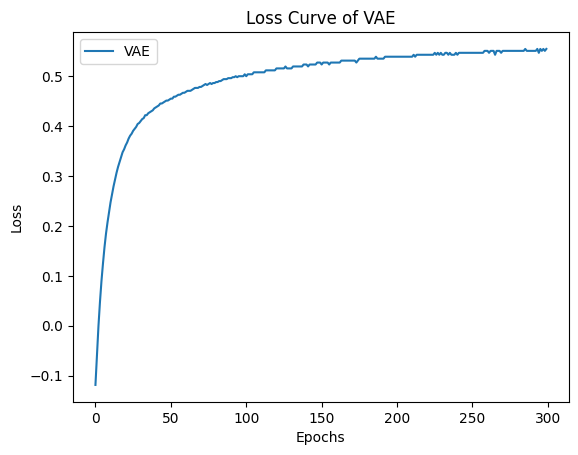

In [11]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['vae']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='VAE')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of VAE')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## VAE MSE
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae_yingbu_agm_mse_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [12]:
loss_dict_list = [{'loss_sum': -2.359375, 'loss': -2.359375, 'vae': -2.359375}, {'loss_sum': -2.15625, 'loss': -2.15625, 'vae': -2.15625}, {'loss_sum': -1.96875, 'loss': -1.96875, 'vae': -1.96875}, {'loss_sum': -1.8515625, 'loss': -1.8515625, 'vae': -1.8515625}, {'loss_sum': -1.765625, 'loss': -1.765625, 'vae': -1.765625}, {'loss_sum': -1.703125, 'loss': -1.703125, 'vae': -1.703125}, {'loss_sum': -1.6484375, 'loss': -1.6484375, 'vae': -1.6484375}, {'loss_sum': -1.609375, 'loss': -1.609375, 'vae': -1.609375}, {'loss_sum': -1.5703125, 'loss': -1.5703125, 'vae': -1.5703125}, {'loss_sum': -1.5390625, 'loss': -1.5390625, 'vae': -1.5390625}, {'loss_sum': -1.5078125, 'loss': -1.5078125, 'vae': -1.5078125}, {'loss_sum': -1.484375, 'loss': -1.484375, 'vae': -1.484375}, {'loss_sum': -1.4609375, 'loss': -1.4609375, 'vae': -1.4609375}, {'loss_sum': -1.4375, 'loss': -1.4375, 'vae': -1.4375}, {'loss_sum': -1.421875, 'loss': -1.421875, 'vae': -1.421875}, {'loss_sum': -1.3984375, 'loss': -1.3984375, 'vae': -1.3984375}, {'loss_sum': -1.3828125, 'loss': -1.3828125, 'vae': -1.3828125}, {'loss_sum': -1.3671875, 'loss': -1.3671875, 'vae': -1.3671875}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.3515625}, {'loss_sum': -1.34375, 'loss': -1.34375, 'vae': -1.34375}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.3359375}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.3203125}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.3125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.3046875}, {'loss_sum': -1.296875, 'loss': -1.296875, 'vae': -1.296875}, {'loss_sum': -1.2890625, 'loss': -1.2890625, 'vae': -1.2890625}, {'loss_sum': -1.2890625, 'loss': -1.2890625, 'vae': -1.2890625}, {'loss_sum': -1.28125, 'loss': -1.28125, 'vae': -1.28125}, {'loss_sum': -1.2734375, 'loss': -1.2734375, 'vae': -1.2734375}, {'loss_sum': -1.2734375, 'loss': -1.2734375, 'vae': -1.2734375}, {'loss_sum': -1.265625, 'loss': -1.265625, 'vae': -1.265625}, {'loss_sum': -1.265625, 'loss': -1.265625, 'vae': -1.265625}, {'loss_sum': -1.2578125, 'loss': -1.2578125, 'vae': -1.2578125}, {'loss_sum': -1.25, 'loss': -1.25, 'vae': -1.25}, {'loss_sum': -1.25, 'loss': -1.25, 'vae': -1.25}, {'loss_sum': -1.25, 'loss': -1.25, 'vae': -1.25}, {'loss_sum': -1.2421875, 'loss': -1.2421875, 'vae': -1.2421875}, {'loss_sum': -1.2421875, 'loss': -1.2421875, 'vae': -1.2421875}, {'loss_sum': -1.234375, 'loss': -1.234375, 'vae': -1.234375}, {'loss_sum': -1.234375, 'loss': -1.234375, 'vae': -1.234375}, {'loss_sum': -1.234375, 'loss': -1.234375, 'vae': -1.234375}, {'loss_sum': -1.2265625, 'loss': -1.2265625, 'vae': -1.2265625}, {'loss_sum': -1.2265625, 'loss': -1.2265625, 'vae': -1.2265625}, {'loss_sum': -1.21875, 'loss': -1.21875, 'vae': -1.21875}, {'loss_sum': -1.21875, 'loss': -1.21875, 'vae': -1.21875}, {'loss_sum': -1.21875, 'loss': -1.21875, 'vae': -1.21875}, {'loss_sum': -1.21875, 'loss': -1.21875, 'vae': -1.21875}, {'loss_sum': -1.2109375, 'loss': -1.2109375, 'vae': -1.2109375}, {'loss_sum': -1.2109375, 'loss': -1.2109375, 'vae': -1.2109375}, {'loss_sum': -1.2109375, 'loss': -1.2109375, 'vae': -1.2109375}, {'loss_sum': -1.2109375, 'loss': -1.2109375, 'vae': -1.2109375}, {'loss_sum': -1.203125, 'loss': -1.203125, 'vae': -1.203125}, {'loss_sum': -1.203125, 'loss': -1.203125, 'vae': -1.203125}, {'loss_sum': -1.203125, 'loss': -1.203125, 'vae': -1.203125}, {'loss_sum': -1.203125, 'loss': -1.203125, 'vae': -1.203125}, {'loss_sum': -1.203125, 'loss': -1.203125, 'vae': -1.203125}, {'loss_sum': -1.1953125, 'loss': -1.1953125, 'vae': -1.1953125}, {'loss_sum': -1.1953125, 'loss': -1.1953125, 'vae': -1.1953125}, {'loss_sum': -1.1953125, 'loss': -1.1953125, 'vae': -1.1953125}, {'loss_sum': -1.1953125, 'loss': -1.1953125, 'vae': -1.1953125}, {'loss_sum': -1.1953125, 'loss': -1.1953125, 'vae': -1.1953125}, {'loss_sum': -1.1875, 'loss': -1.1875, 'vae': -1.1875}, {'loss_sum': -1.1875, 'loss': -1.1875, 'vae': -1.1875}, {'loss_sum': -1.1875, 'loss': -1.1875, 'vae': -1.1875}, {'loss_sum': -1.1875, 'loss': -1.1875, 'vae': -1.1875}, {'loss_sum': -1.1875, 'loss': -1.1875, 'vae': -1.1875}, {'loss_sum': -1.1875, 'loss': -1.1875, 'vae': -1.1875}, {'loss_sum': -1.1796875, 'loss': -1.1796875, 'vae': -1.1796875}, {'loss_sum': -1.1796875, 'loss': -1.1796875, 'vae': -1.1796875}, {'loss_sum': -1.1796875, 'loss': -1.1796875, 'vae': -1.1796875}, {'loss_sum': -1.1796875, 'loss': -1.1796875, 'vae': -1.1796875}, {'loss_sum': -1.1796875, 'loss': -1.1796875, 'vae': -1.1796875}, {'loss_sum': -1.1796875, 'loss': -1.1796875, 'vae': -1.1796875}, {'loss_sum': -1.1796875, 'loss': -1.1796875, 'vae': -1.1796875}, {'loss_sum': -1.1796875, 'loss': -1.1796875, 'vae': -1.1796875}, {'loss_sum': -1.171875, 'loss': -1.171875, 'vae': -1.171875}, {'loss_sum': -1.171875, 'loss': -1.171875, 'vae': -1.171875}, {'loss_sum': -1.171875, 'loss': -1.171875, 'vae': -1.171875}, {'loss_sum': -1.171875, 'loss': -1.171875, 'vae': -1.171875}, {'loss_sum': -1.171875, 'loss': -1.171875, 'vae': -1.171875}, {'loss_sum': -1.171875, 'loss': -1.171875, 'vae': -1.171875}, {'loss_sum': -1.171875, 'loss': -1.171875, 'vae': -1.171875}, {'loss_sum': -1.171875, 'loss': -1.171875, 'vae': -1.171875}, {'loss_sum': -1.1640625, 'loss': -1.1640625, 'vae': -1.1640625}, {'loss_sum': -1.1640625, 'loss': -1.1640625, 'vae': -1.1640625}, {'loss_sum': -1.1640625, 'loss': -1.1640625, 'vae': -1.1640625}, {'loss_sum': -1.1640625, 'loss': -1.1640625, 'vae': -1.1640625}, {'loss_sum': -1.1640625, 'loss': -1.1640625, 'vae': -1.1640625}, {'loss_sum': -1.1640625, 'loss': -1.1640625, 'vae': -1.1640625}, {'loss_sum': -1.1640625, 'loss': -1.1640625, 'vae': -1.1640625}, {'loss_sum': -1.1640625, 'loss': -1.1640625, 'vae': -1.1640625}, {'loss_sum': -1.1640625, 'loss': -1.1640625, 'vae': -1.1640625}, {'loss_sum': -1.1640625, 'loss': -1.1640625, 'vae': -1.1640625}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.15625, 'loss': -1.15625, 'vae': -1.15625}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.1484375, 'loss': -1.1484375, 'vae': -1.1484375}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.140625, 'loss': -1.140625, 'vae': -1.140625}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.1328125, 'loss': -1.1328125, 'vae': -1.1328125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.125, 'loss': -1.125, 'vae': -1.125}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.1171875, 'loss': -1.1171875, 'vae': -1.1171875}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}, {'loss_sum': -1.109375, 'loss': -1.109375, 'vae': -1.109375}]


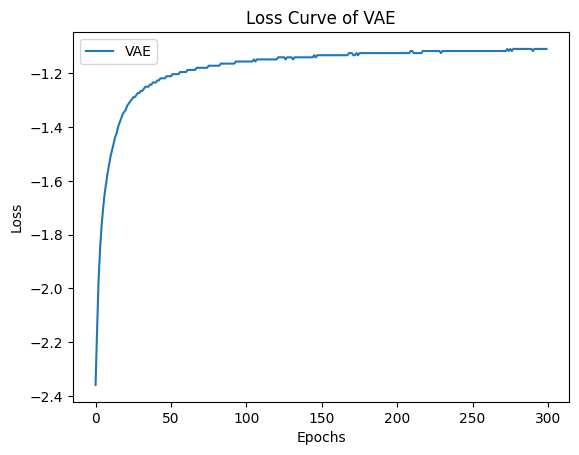

In [13]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['vae']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='VAE')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of VAE')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

# UNet COSINE
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_unet_yingbu_agm_cosine_eot-1_sds-0_unT-unet-0

In [14]:
loss_dict_list = [{'loss_sum': 0.00078582763671875, 'loss': 0.00078582763671875, 'unet': 0.00078582763671875}, {'loss_sum': 0.028076171875, 'loss': 0.028076171875, 'unet': 0.028076171875}, {'loss_sum': 0.034912109375, 'loss': 0.034912109375, 'unet': 0.034912109375}, {'loss_sum': 0.07080078125, 'loss': 0.07080078125, 'unet': 0.07080078125}, {'loss_sum': 0.05322265625, 'loss': 0.05322265625, 'unet': 0.05322265625}, {'loss_sum': 0.023193359375, 'loss': 0.023193359375, 'unet': 0.023193359375}, {'loss_sum': 0.09716796875, 'loss': 0.09716796875, 'unet': 0.09716796875}, {'loss_sum': 0.0927734375, 'loss': 0.0927734375, 'unet': 0.0927734375}, {'loss_sum': 0.1279296875, 'loss': 0.1279296875, 'unet': 0.1279296875}, {'loss_sum': 0.1259765625, 'loss': 0.1259765625, 'unet': 0.1259765625}, {'loss_sum': 0.1376953125, 'loss': 0.1376953125, 'unet': 0.1376953125}, {'loss_sum': 0.09130859375, 'loss': 0.09130859375, 'unet': 0.09130859375}, {'loss_sum': 0.1171875, 'loss': 0.1171875, 'unet': 0.1171875}, {'loss_sum': 0.1611328125, 'loss': 0.1611328125, 'unet': 0.1611328125}, {'loss_sum': 0.1767578125, 'loss': 0.1767578125, 'unet': 0.1767578125}, {'loss_sum': 0.0703125, 'loss': 0.0703125, 'unet': 0.0703125}, {'loss_sum': 0.2001953125, 'loss': 0.2001953125, 'unet': 0.2001953125}, {'loss_sum': 0.0947265625, 'loss': 0.0947265625, 'unet': 0.0947265625}, {'loss_sum': 0.1396484375, 'loss': 0.1396484375, 'unet': 0.1396484375}, {'loss_sum': 0.1279296875, 'loss': 0.1279296875, 'unet': 0.1279296875}, {'loss_sum': 0.09619140625, 'loss': 0.09619140625, 'unet': 0.09619140625}, {'loss_sum': 0.0771484375, 'loss': 0.0771484375, 'unet': 0.0771484375}, {'loss_sum': 0.09765625, 'loss': 0.09765625, 'unet': 0.09765625}, {'loss_sum': 0.11181640625, 'loss': 0.11181640625, 'unet': 0.11181640625}, {'loss_sum': 0.181640625, 'loss': 0.181640625, 'unet': 0.181640625}, {'loss_sum': 0.14453125, 'loss': 0.14453125, 'unet': 0.14453125}, {'loss_sum': 0.080078125, 'loss': 0.080078125, 'unet': 0.080078125}, {'loss_sum': 0.1455078125, 'loss': 0.1455078125, 'unet': 0.1455078125}, {'loss_sum': 0.07763671875, 'loss': 0.07763671875, 'unet': 0.07763671875}, {'loss_sum': 0.150390625, 'loss': 0.150390625, 'unet': 0.150390625}, {'loss_sum': 0.1748046875, 'loss': 0.1748046875, 'unet': 0.1748046875}, {'loss_sum': 0.166015625, 'loss': 0.166015625, 'unet': 0.166015625}, {'loss_sum': 0.12890625, 'loss': 0.12890625, 'unet': 0.12890625}, {'loss_sum': 0.1611328125, 'loss': 0.1611328125, 'unet': 0.1611328125}, {'loss_sum': 0.05224609375, 'loss': 0.05224609375, 'unet': 0.05224609375}, {'loss_sum': 0.1591796875, 'loss': 0.1591796875, 'unet': 0.1591796875}, {'loss_sum': 0.203125, 'loss': 0.203125, 'unet': 0.203125}, {'loss_sum': 0.1533203125, 'loss': 0.1533203125, 'unet': 0.1533203125}, {'loss_sum': 0.1806640625, 'loss': 0.1806640625, 'unet': 0.1806640625}, {'loss_sum': 0.1376953125, 'loss': 0.1376953125, 'unet': 0.1376953125}, {'loss_sum': 0.216796875, 'loss': 0.216796875, 'unet': 0.216796875}, {'loss_sum': 0.1328125, 'loss': 0.1328125, 'unet': 0.1328125}, {'loss_sum': 0.134765625, 'loss': 0.134765625, 'unet': 0.134765625}, {'loss_sum': 0.193359375, 'loss': 0.193359375, 'unet': 0.193359375}, {'loss_sum': 0.2314453125, 'loss': 0.2314453125, 'unet': 0.2314453125}, {'loss_sum': 0.1337890625, 'loss': 0.1337890625, 'unet': 0.1337890625}, {'loss_sum': 0.173828125, 'loss': 0.173828125, 'unet': 0.173828125}, {'loss_sum': 0.1328125, 'loss': 0.1328125, 'unet': 0.1328125}, {'loss_sum': 0.1611328125, 'loss': 0.1611328125, 'unet': 0.1611328125}, {'loss_sum': 0.169921875, 'loss': 0.169921875, 'unet': 0.169921875}, {'loss_sum': 0.08984375, 'loss': 0.08984375, 'unet': 0.08984375}, {'loss_sum': 0.14453125, 'loss': 0.14453125, 'unet': 0.14453125}, {'loss_sum': 0.1279296875, 'loss': 0.1279296875, 'unet': 0.1279296875}, {'loss_sum': 0.1396484375, 'loss': 0.1396484375, 'unet': 0.1396484375}, {'loss_sum': 0.0966796875, 'loss': 0.0966796875, 'unet': 0.0966796875}, {'loss_sum': 0.1708984375, 'loss': 0.1708984375, 'unet': 0.1708984375}, {'loss_sum': 0.0732421875, 'loss': 0.0732421875, 'unet': 0.0732421875}, {'loss_sum': 0.134765625, 'loss': 0.134765625, 'unet': 0.134765625}, {'loss_sum': 0.11181640625, 'loss': 0.11181640625, 'unet': 0.11181640625}, {'loss_sum': 0.150390625, 'loss': 0.150390625, 'unet': 0.150390625}, {'loss_sum': 0.150390625, 'loss': 0.150390625, 'unet': 0.150390625}, {'loss_sum': 0.19140625, 'loss': 0.19140625, 'unet': 0.19140625}, {'loss_sum': 0.162109375, 'loss': 0.162109375, 'unet': 0.162109375}, {'loss_sum': 0.203125, 'loss': 0.203125, 'unet': 0.203125}, {'loss_sum': 0.2119140625, 'loss': 0.2119140625, 'unet': 0.2119140625}, {'loss_sum': 0.1435546875, 'loss': 0.1435546875, 'unet': 0.1435546875}, {'loss_sum': 0.09619140625, 'loss': 0.09619140625, 'unet': 0.09619140625}, {'loss_sum': 0.16015625, 'loss': 0.16015625, 'unet': 0.16015625}, {'loss_sum': 0.1416015625, 'loss': 0.1416015625, 'unet': 0.1416015625}, {'loss_sum': 0.201171875, 'loss': 0.201171875, 'unet': 0.201171875}, {'loss_sum': 0.10986328125, 'loss': 0.10986328125, 'unet': 0.10986328125}, {'loss_sum': 0.1640625, 'loss': 0.1640625, 'unet': 0.1640625}, {'loss_sum': 0.1396484375, 'loss': 0.1396484375, 'unet': 0.1396484375}, {'loss_sum': 0.2080078125, 'loss': 0.2080078125, 'unet': 0.2080078125}, {'loss_sum': 0.123046875, 'loss': 0.123046875, 'unet': 0.123046875}, {'loss_sum': 0.10302734375, 'loss': 0.10302734375, 'unet': 0.10302734375}, {'loss_sum': 0.1474609375, 'loss': 0.1474609375, 'unet': 0.1474609375}, {'loss_sum': 0.1435546875, 'loss': 0.1435546875, 'unet': 0.1435546875}, {'loss_sum': 0.07568359375, 'loss': 0.07568359375, 'unet': 0.07568359375}, {'loss_sum': 0.1572265625, 'loss': 0.1572265625, 'unet': 0.1572265625}, {'loss_sum': 0.138671875, 'loss': 0.138671875, 'unet': 0.138671875}, {'loss_sum': 0.1025390625, 'loss': 0.1025390625, 'unet': 0.1025390625}, {'loss_sum': 0.0458984375, 'loss': 0.0458984375, 'unet': 0.0458984375}, {'loss_sum': 0.14453125, 'loss': 0.14453125, 'unet': 0.14453125}, {'loss_sum': 0.11181640625, 'loss': 0.11181640625, 'unet': 0.11181640625}, {'loss_sum': 0.17578125, 'loss': 0.17578125, 'unet': 0.17578125}, {'loss_sum': 0.115234375, 'loss': 0.115234375, 'unet': 0.115234375}, {'loss_sum': 0.1591796875, 'loss': 0.1591796875, 'unet': 0.1591796875}, {'loss_sum': 0.1357421875, 'loss': 0.1357421875, 'unet': 0.1357421875}, {'loss_sum': 0.1435546875, 'loss': 0.1435546875, 'unet': 0.1435546875}, {'loss_sum': 0.107421875, 'loss': 0.107421875, 'unet': 0.107421875}, {'loss_sum': 0.1083984375, 'loss': 0.1083984375, 'unet': 0.1083984375}, {'loss_sum': 0.18359375, 'loss': 0.18359375, 'unet': 0.18359375}, {'loss_sum': 0.1708984375, 'loss': 0.1708984375, 'unet': 0.1708984375}, {'loss_sum': 0.126953125, 'loss': 0.126953125, 'unet': 0.126953125}, {'loss_sum': 0.1513671875, 'loss': 0.1513671875, 'unet': 0.1513671875}, {'loss_sum': 0.13671875, 'loss': 0.13671875, 'unet': 0.13671875}, {'loss_sum': 0.1826171875, 'loss': 0.1826171875, 'unet': 0.1826171875}, {'loss_sum': 0.126953125, 'loss': 0.126953125, 'unet': 0.126953125}, {'loss_sum': 0.1826171875, 'loss': 0.1826171875, 'unet': 0.1826171875}, {'loss_sum': 0.1005859375, 'loss': 0.1005859375, 'unet': 0.1005859375}, {'loss_sum': 0.10205078125, 'loss': 0.10205078125, 'unet': 0.10205078125}, {'loss_sum': 0.1494140625, 'loss': 0.1494140625, 'unet': 0.1494140625}, {'loss_sum': 0.16015625, 'loss': 0.16015625, 'unet': 0.16015625}, {'loss_sum': 0.1064453125, 'loss': 0.1064453125, 'unet': 0.1064453125}, {'loss_sum': 0.09521484375, 'loss': 0.09521484375, 'unet': 0.09521484375}, {'loss_sum': 0.12255859375, 'loss': 0.12255859375, 'unet': 0.12255859375}, {'loss_sum': 0.1103515625, 'loss': 0.1103515625, 'unet': 0.1103515625}, {'loss_sum': 0.1591796875, 'loss': 0.1591796875, 'unet': 0.1591796875}, {'loss_sum': 0.1416015625, 'loss': 0.1416015625, 'unet': 0.1416015625}, {'loss_sum': 0.201171875, 'loss': 0.201171875, 'unet': 0.201171875}, {'loss_sum': 0.1845703125, 'loss': 0.1845703125, 'unet': 0.1845703125}, {'loss_sum': 0.2021484375, 'loss': 0.2021484375, 'unet': 0.2021484375}, {'loss_sum': 0.171875, 'loss': 0.171875, 'unet': 0.171875}, {'loss_sum': 0.1025390625, 'loss': 0.1025390625, 'unet': 0.1025390625}, {'loss_sum': 0.1982421875, 'loss': 0.1982421875, 'unet': 0.1982421875}, {'loss_sum': 0.1806640625, 'loss': 0.1806640625, 'unet': 0.1806640625}, {'loss_sum': 0.1376953125, 'loss': 0.1376953125, 'unet': 0.1376953125}, {'loss_sum': 0.1689453125, 'loss': 0.1689453125, 'unet': 0.1689453125}, {'loss_sum': 0.15625, 'loss': 0.15625, 'unet': 0.15625}, {'loss_sum': 0.1435546875, 'loss': 0.1435546875, 'unet': 0.1435546875}, {'loss_sum': 0.1328125, 'loss': 0.1328125, 'unet': 0.1328125}, {'loss_sum': 0.13671875, 'loss': 0.13671875, 'unet': 0.13671875}, {'loss_sum': 0.10107421875, 'loss': 0.10107421875, 'unet': 0.10107421875}, {'loss_sum': 0.1298828125, 'loss': 0.1298828125, 'unet': 0.1298828125}, {'loss_sum': 0.158203125, 'loss': 0.158203125, 'unet': 0.158203125}, {'loss_sum': 0.1708984375, 'loss': 0.1708984375, 'unet': 0.1708984375}, {'loss_sum': 0.1767578125, 'loss': 0.1767578125, 'unet': 0.1767578125}, {'loss_sum': 0.09814453125, 'loss': 0.09814453125, 'unet': 0.09814453125}, {'loss_sum': 0.146484375, 'loss': 0.146484375, 'unet': 0.146484375}, {'loss_sum': 0.220703125, 'loss': 0.220703125, 'unet': 0.220703125}, {'loss_sum': 0.1845703125, 'loss': 0.1845703125, 'unet': 0.1845703125}, {'loss_sum': 0.1982421875, 'loss': 0.1982421875, 'unet': 0.1982421875}, {'loss_sum': 0.1142578125, 'loss': 0.1142578125, 'unet': 0.1142578125}, {'loss_sum': 0.1728515625, 'loss': 0.1728515625, 'unet': 0.1728515625}, {'loss_sum': 0.181640625, 'loss': 0.181640625, 'unet': 0.181640625}, {'loss_sum': 0.1513671875, 'loss': 0.1513671875, 'unet': 0.1513671875}, {'loss_sum': 0.10205078125, 'loss': 0.10205078125, 'unet': 0.10205078125}, {'loss_sum': 0.1357421875, 'loss': 0.1357421875, 'unet': 0.1357421875}, {'loss_sum': 0.107421875, 'loss': 0.107421875, 'unet': 0.107421875}, {'loss_sum': 0.1298828125, 'loss': 0.1298828125, 'unet': 0.1298828125}, {'loss_sum': 0.1650390625, 'loss': 0.1650390625, 'unet': 0.1650390625}, {'loss_sum': 0.08349609375, 'loss': 0.08349609375, 'unet': 0.08349609375}, {'loss_sum': 0.1376953125, 'loss': 0.1376953125, 'unet': 0.1376953125}, {'loss_sum': 0.142578125, 'loss': 0.142578125, 'unet': 0.142578125}, {'loss_sum': 0.08935546875, 'loss': 0.08935546875, 'unet': 0.08935546875}, {'loss_sum': 0.1416015625, 'loss': 0.1416015625, 'unet': 0.1416015625}, {'loss_sum': 0.185546875, 'loss': 0.185546875, 'unet': 0.185546875}, {'loss_sum': 0.11328125, 'loss': 0.11328125, 'unet': 0.11328125}, {'loss_sum': 0.18359375, 'loss': 0.18359375, 'unet': 0.18359375}, {'loss_sum': 0.126953125, 'loss': 0.126953125, 'unet': 0.126953125}, {'loss_sum': 0.1484375, 'loss': 0.1484375, 'unet': 0.1484375}, {'loss_sum': 0.11572265625, 'loss': 0.11572265625, 'unet': 0.11572265625}, {'loss_sum': 0.10009765625, 'loss': 0.10009765625, 'unet': 0.10009765625}, {'loss_sum': 0.126953125, 'loss': 0.126953125, 'unet': 0.126953125}, {'loss_sum': 0.1552734375, 'loss': 0.1552734375, 'unet': 0.1552734375}, {'loss_sum': 0.126953125, 'loss': 0.126953125, 'unet': 0.126953125}, {'loss_sum': 0.0966796875, 'loss': 0.0966796875, 'unet': 0.0966796875}, {'loss_sum': 0.0810546875, 'loss': 0.0810546875, 'unet': 0.0810546875}, {'loss_sum': 0.10595703125, 'loss': 0.10595703125, 'unet': 0.10595703125}, {'loss_sum': 0.140625, 'loss': 0.140625, 'unet': 0.140625}, {'loss_sum': 0.12255859375, 'loss': 0.12255859375, 'unet': 0.12255859375}, {'loss_sum': 0.2001953125, 'loss': 0.2001953125, 'unet': 0.2001953125}, {'loss_sum': 0.2158203125, 'loss': 0.2158203125, 'unet': 0.2158203125}, {'loss_sum': 0.1865234375, 'loss': 0.1865234375, 'unet': 0.1865234375}, {'loss_sum': 0.0966796875, 'loss': 0.0966796875, 'unet': 0.0966796875}, {'loss_sum': 0.162109375, 'loss': 0.162109375, 'unet': 0.162109375}, {'loss_sum': 0.1875, 'loss': 0.1875, 'unet': 0.1875}, {'loss_sum': 0.134765625, 'loss': 0.134765625, 'unet': 0.134765625}, {'loss_sum': 0.1142578125, 'loss': 0.1142578125, 'unet': 0.1142578125}, {'loss_sum': 0.10888671875, 'loss': 0.10888671875, 'unet': 0.10888671875}, {'loss_sum': 0.1318359375, 'loss': 0.1318359375, 'unet': 0.1318359375}, {'loss_sum': 0.134765625, 'loss': 0.134765625, 'unet': 0.134765625}, {'loss_sum': 0.154296875, 'loss': 0.154296875, 'unet': 0.154296875}, {'loss_sum': 0.142578125, 'loss': 0.142578125, 'unet': 0.142578125}, {'loss_sum': 0.1796875, 'loss': 0.1796875, 'unet': 0.1796875}, {'loss_sum': 0.06103515625, 'loss': 0.06103515625, 'unet': 0.06103515625}, {'loss_sum': 0.09716796875, 'loss': 0.09716796875, 'unet': 0.09716796875}, {'loss_sum': 0.09033203125, 'loss': 0.09033203125, 'unet': 0.09033203125}, {'loss_sum': 0.1484375, 'loss': 0.1484375, 'unet': 0.1484375}, {'loss_sum': 0.177734375, 'loss': 0.177734375, 'unet': 0.177734375}, {'loss_sum': 0.1298828125, 'loss': 0.1298828125, 'unet': 0.1298828125}, {'loss_sum': 0.1298828125, 'loss': 0.1298828125, 'unet': 0.1298828125}, {'loss_sum': 0.10986328125, 'loss': 0.10986328125, 'unet': 0.10986328125}, {'loss_sum': 0.12109375, 'loss': 0.12109375, 'unet': 0.12109375}, {'loss_sum': 0.169921875, 'loss': 0.169921875, 'unet': 0.169921875}, {'loss_sum': 0.10791015625, 'loss': 0.10791015625, 'unet': 0.10791015625}, {'loss_sum': 0.1357421875, 'loss': 0.1357421875, 'unet': 0.1357421875}, {'loss_sum': 0.11279296875, 'loss': 0.11279296875, 'unet': 0.11279296875}, {'loss_sum': 0.1708984375, 'loss': 0.1708984375, 'unet': 0.1708984375}, {'loss_sum': 0.10107421875, 'loss': 0.10107421875, 'unet': 0.10107421875}, {'loss_sum': 0.1748046875, 'loss': 0.1748046875, 'unet': 0.1748046875}, {'loss_sum': 0.1591796875, 'loss': 0.1591796875, 'unet': 0.1591796875}, {'loss_sum': 0.169921875, 'loss': 0.169921875, 'unet': 0.169921875}, {'loss_sum': 0.173828125, 'loss': 0.173828125, 'unet': 0.173828125}, {'loss_sum': 0.177734375, 'loss': 0.177734375, 'unet': 0.177734375}, {'loss_sum': 0.150390625, 'loss': 0.150390625, 'unet': 0.150390625}, {'loss_sum': 0.1640625, 'loss': 0.1640625, 'unet': 0.1640625}, {'loss_sum': 0.1220703125, 'loss': 0.1220703125, 'unet': 0.1220703125}, {'loss_sum': 0.16015625, 'loss': 0.16015625, 'unet': 0.16015625}, {'loss_sum': 0.1494140625, 'loss': 0.1494140625, 'unet': 0.1494140625}, {'loss_sum': 0.06884765625, 'loss': 0.06884765625, 'unet': 0.06884765625}, {'loss_sum': 0.142578125, 'loss': 0.142578125, 'unet': 0.142578125}, {'loss_sum': 0.142578125, 'loss': 0.142578125, 'unet': 0.142578125}, {'loss_sum': 0.08837890625, 'loss': 0.08837890625, 'unet': 0.08837890625}, {'loss_sum': 0.1416015625, 'loss': 0.1416015625, 'unet': 0.1416015625}, {'loss_sum': 0.181640625, 'loss': 0.181640625, 'unet': 0.181640625}, {'loss_sum': 0.1123046875, 'loss': 0.1123046875, 'unet': 0.1123046875}, {'loss_sum': 0.11181640625, 'loss': 0.11181640625, 'unet': 0.11181640625}, {'loss_sum': 0.119140625, 'loss': 0.119140625, 'unet': 0.119140625}, {'loss_sum': 0.212890625, 'loss': 0.212890625, 'unet': 0.212890625}, {'loss_sum': 0.1728515625, 'loss': 0.1728515625, 'unet': 0.1728515625}, {'loss_sum': 0.1494140625, 'loss': 0.1494140625, 'unet': 0.1494140625}, {'loss_sum': 0.11181640625, 'loss': 0.11181640625, 'unet': 0.11181640625}, {'loss_sum': 0.220703125, 'loss': 0.220703125, 'unet': 0.220703125}, {'loss_sum': 0.1591796875, 'loss': 0.1591796875, 'unet': 0.1591796875}, {'loss_sum': 0.1845703125, 'loss': 0.1845703125, 'unet': 0.1845703125}, {'loss_sum': 0.1279296875, 'loss': 0.1279296875, 'unet': 0.1279296875}, {'loss_sum': 0.16015625, 'loss': 0.16015625, 'unet': 0.16015625}, {'loss_sum': 0.1748046875, 'loss': 0.1748046875, 'unet': 0.1748046875}, {'loss_sum': 0.07470703125, 'loss': 0.07470703125, 'unet': 0.07470703125}, {'loss_sum': 0.12109375, 'loss': 0.12109375, 'unet': 0.12109375}, {'loss_sum': 0.12353515625, 'loss': 0.12353515625, 'unet': 0.12353515625}, {'loss_sum': 0.1728515625, 'loss': 0.1728515625, 'unet': 0.1728515625}, {'loss_sum': 0.1845703125, 'loss': 0.1845703125, 'unet': 0.1845703125}, {'loss_sum': 0.1396484375, 'loss': 0.1396484375, 'unet': 0.1396484375}, {'loss_sum': 0.134765625, 'loss': 0.134765625, 'unet': 0.134765625}, {'loss_sum': 0.193359375, 'loss': 0.193359375, 'unet': 0.193359375}, {'loss_sum': 0.171875, 'loss': 0.171875, 'unet': 0.171875}, {'loss_sum': 0.1220703125, 'loss': 0.1220703125, 'unet': 0.1220703125}, {'loss_sum': 0.1240234375, 'loss': 0.1240234375, 'unet': 0.1240234375}, {'loss_sum': 0.2158203125, 'loss': 0.2158203125, 'unet': 0.2158203125}, {'loss_sum': 0.12890625, 'loss': 0.12890625, 'unet': 0.12890625}, {'loss_sum': 0.1640625, 'loss': 0.1640625, 'unet': 0.1640625}, {'loss_sum': 0.1611328125, 'loss': 0.1611328125, 'unet': 0.1611328125}, {'loss_sum': 0.1982421875, 'loss': 0.1982421875, 'unet': 0.1982421875}, {'loss_sum': 0.0732421875, 'loss': 0.0732421875, 'unet': 0.0732421875}, {'loss_sum': 0.13671875, 'loss': 0.13671875, 'unet': 0.13671875}, {'loss_sum': 0.154296875, 'loss': 0.154296875, 'unet': 0.154296875}, {'loss_sum': 0.09033203125, 'loss': 0.09033203125, 'unet': 0.09033203125}, {'loss_sum': 0.162109375, 'loss': 0.162109375, 'unet': 0.162109375}, {'loss_sum': 0.142578125, 'loss': 0.142578125, 'unet': 0.142578125}, {'loss_sum': 0.1455078125, 'loss': 0.1455078125, 'unet': 0.1455078125}, {'loss_sum': 0.125, 'loss': 0.125, 'unet': 0.125}, {'loss_sum': 0.1083984375, 'loss': 0.1083984375, 'unet': 0.1083984375}, {'loss_sum': 0.1787109375, 'loss': 0.1787109375, 'unet': 0.1787109375}, {'loss_sum': 0.1513671875, 'loss': 0.1513671875, 'unet': 0.1513671875}, {'loss_sum': 0.158203125, 'loss': 0.158203125, 'unet': 0.158203125}, {'loss_sum': 0.1142578125, 'loss': 0.1142578125, 'unet': 0.1142578125}, {'loss_sum': 0.10791015625, 'loss': 0.10791015625, 'unet': 0.10791015625}, {'loss_sum': 0.1123046875, 'loss': 0.1123046875, 'unet': 0.1123046875}, {'loss_sum': 0.095703125, 'loss': 0.095703125, 'unet': 0.095703125}, {'loss_sum': 0.15234375, 'loss': 0.15234375, 'unet': 0.15234375}, {'loss_sum': 0.1259765625, 'loss': 0.1259765625, 'unet': 0.1259765625}, {'loss_sum': 0.142578125, 'loss': 0.142578125, 'unet': 0.142578125}, {'loss_sum': 0.16015625, 'loss': 0.16015625, 'unet': 0.16015625}, {'loss_sum': 0.12890625, 'loss': 0.12890625, 'unet': 0.12890625}, {'loss_sum': 0.13671875, 'loss': 0.13671875, 'unet': 0.13671875}, {'loss_sum': 0.1171875, 'loss': 0.1171875, 'unet': 0.1171875}, {'loss_sum': 0.1025390625, 'loss': 0.1025390625, 'unet': 0.1025390625}, {'loss_sum': 0.134765625, 'loss': 0.134765625, 'unet': 0.134765625}, {'loss_sum': 0.181640625, 'loss': 0.181640625, 'unet': 0.181640625}, {'loss_sum': 0.07373046875, 'loss': 0.07373046875, 'unet': 0.07373046875}, {'loss_sum': 0.1640625, 'loss': 0.1640625, 'unet': 0.1640625}, {'loss_sum': 0.1533203125, 'loss': 0.1533203125, 'unet': 0.1533203125}, {'loss_sum': 0.091796875, 'loss': 0.091796875, 'unet': 0.091796875}, {'loss_sum': 0.150390625, 'loss': 0.150390625, 'unet': 0.150390625}, {'loss_sum': 0.1025390625, 'loss': 0.1025390625, 'unet': 0.1025390625}, {'loss_sum': 0.126953125, 'loss': 0.126953125, 'unet': 0.126953125}, {'loss_sum': 0.06982421875, 'loss': 0.06982421875, 'unet': 0.06982421875}, {'loss_sum': 0.12451171875, 'loss': 0.12451171875, 'unet': 0.12451171875}, {'loss_sum': 0.1865234375, 'loss': 0.1865234375, 'unet': 0.1865234375}, {'loss_sum': 0.1591796875, 'loss': 0.1591796875, 'unet': 0.1591796875}, {'loss_sum': 0.1904296875, 'loss': 0.1904296875, 'unet': 0.1904296875}, {'loss_sum': 0.1611328125, 'loss': 0.1611328125, 'unet': 0.1611328125}, {'loss_sum': 0.15625, 'loss': 0.15625, 'unet': 0.15625}, {'loss_sum': 0.12890625, 'loss': 0.12890625, 'unet': 0.12890625}, {'loss_sum': 0.169921875, 'loss': 0.169921875, 'unet': 0.169921875}, {'loss_sum': 0.09619140625, 'loss': 0.09619140625, 'unet': 0.09619140625}, {'loss_sum': 0.12060546875, 'loss': 0.12060546875, 'unet': 0.12060546875}, {'loss_sum': 0.1611328125, 'loss': 0.1611328125, 'unet': 0.1611328125}, {'loss_sum': 0.10205078125, 'loss': 0.10205078125, 'unet': 0.10205078125}, {'loss_sum': 0.1279296875, 'loss': 0.1279296875, 'unet': 0.1279296875}, {'loss_sum': 0.1591796875, 'loss': 0.1591796875, 'unet': 0.1591796875}, {'loss_sum': 0.146484375, 'loss': 0.146484375, 'unet': 0.146484375}, {'loss_sum': 0.2138671875, 'loss': 0.2138671875, 'unet': 0.2138671875}, {'loss_sum': 0.1591796875, 'loss': 0.1591796875, 'unet': 0.1591796875}, {'loss_sum': 0.1318359375, 'loss': 0.1318359375, 'unet': 0.1318359375}, {'loss_sum': 0.095703125, 'loss': 0.095703125, 'unet': 0.095703125}, {'loss_sum': 0.1611328125, 'loss': 0.1611328125, 'unet': 0.1611328125}, {'loss_sum': 0.185546875, 'loss': 0.185546875, 'unet': 0.185546875}, {'loss_sum': 0.1455078125, 'loss': 0.1455078125, 'unet': 0.1455078125}, {'loss_sum': 0.1787109375, 'loss': 0.1787109375, 'unet': 0.1787109375}, {'loss_sum': 0.13671875, 'loss': 0.13671875, 'unet': 0.13671875}, {'loss_sum': 0.17578125, 'loss': 0.17578125, 'unet': 0.17578125}, {'loss_sum': 0.1787109375, 'loss': 0.1787109375, 'unet': 0.1787109375}, {'loss_sum': 0.14453125, 'loss': 0.14453125, 'unet': 0.14453125}, {'loss_sum': 0.1845703125, 'loss': 0.1845703125, 'unet': 0.1845703125}, {'loss_sum': 0.09716796875, 'loss': 0.09716796875, 'unet': 0.09716796875}, {'loss_sum': 0.1162109375, 'loss': 0.1162109375, 'unet': 0.1162109375}]


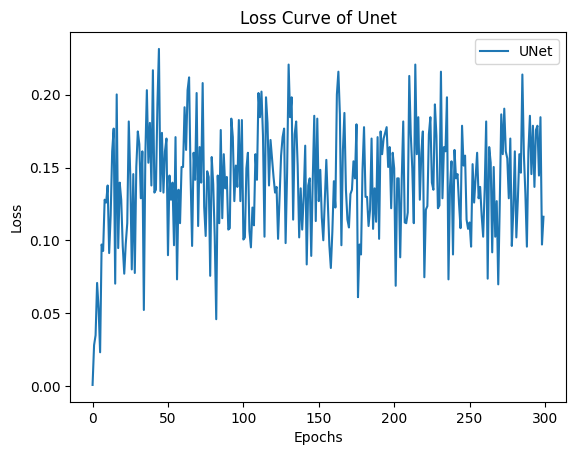

In [16]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['unet']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='UNet')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of Unet')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

# UNet MSE
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_unet_yingbu_agm_mse_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [17]:
loss_dict_list = [{'loss_sum': -2.140625, 'loss': -2.140625, 'unet': -2.140625}, {'loss_sum': -1.9140625, 'loss': -1.9140625, 'unet': -1.9140625}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -2.0625}, {'loss_sum': -1.9296875, 'loss': -1.9296875, 'unet': -1.9296875}, {'loss_sum': -2.03125, 'loss': -2.03125, 'unet': -2.03125}, {'loss_sum': -2.15625, 'loss': -2.15625, 'unet': -2.15625}, {'loss_sum': -1.8359375, 'loss': -1.8359375, 'unet': -1.8359375}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.953125}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.953125}, {'loss_sum': -1.9453125, 'loss': -1.9453125, 'unet': -1.9453125}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -2.0625}, {'loss_sum': -1.8359375, 'loss': -1.8359375, 'unet': -1.8359375}, {'loss_sum': -1.765625, 'loss': -1.765625, 'unet': -1.765625}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -2.0625}, {'loss_sum': -1.859375, 'loss': -1.859375, 'unet': -1.859375}, {'loss_sum': -1.6484375, 'loss': -1.6484375, 'unet': -1.6484375}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.890625}, {'loss_sum': -1.8203125, 'loss': -1.8203125, 'unet': -1.8203125}, {'loss_sum': -2.0, 'loss': -2.0, 'unet': -2.0}, {'loss_sum': -1.6484375, 'loss': -1.6484375, 'unet': -1.6484375}, {'loss_sum': -1.75, 'loss': -1.75, 'unet': -1.75}, {'loss_sum': -1.8828125, 'loss': -1.8828125, 'unet': -1.8828125}, {'loss_sum': -1.390625, 'loss': -1.390625, 'unet': -1.390625}, {'loss_sum': -1.90625, 'loss': -1.90625, 'unet': -1.90625}, {'loss_sum': -1.765625, 'loss': -1.765625, 'unet': -1.765625}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.796875}, {'loss_sum': -1.9921875, 'loss': -1.9921875, 'unet': -1.9921875}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -2.015625}, {'loss_sum': -1.9375, 'loss': -1.9375, 'unet': -1.9375}, {'loss_sum': -1.9140625, 'loss': -1.9140625, 'unet': -1.9140625}, {'loss_sum': -1.6875, 'loss': -1.6875, 'unet': -1.6875}, {'loss_sum': -1.9765625, 'loss': -1.9765625, 'unet': -1.9765625}, {'loss_sum': -1.75, 'loss': -1.75, 'unet': -1.75}, {'loss_sum': -1.8046875, 'loss': -1.8046875, 'unet': -1.8046875}, {'loss_sum': -1.734375, 'loss': -1.734375, 'unet': -1.734375}, {'loss_sum': -1.703125, 'loss': -1.703125, 'unet': -1.703125}, {'loss_sum': -1.734375, 'loss': -1.734375, 'unet': -1.734375}, {'loss_sum': -1.7421875, 'loss': -1.7421875, 'unet': -1.7421875}, {'loss_sum': -1.9296875, 'loss': -1.9296875, 'unet': -1.9296875}, {'loss_sum': -1.78125, 'loss': -1.78125, 'unet': -1.78125}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -2.09375}, {'loss_sum': -1.765625, 'loss': -1.765625, 'unet': -1.765625}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -2.046875}, {'loss_sum': -1.7890625, 'loss': -1.7890625, 'unet': -1.7890625}, {'loss_sum': -1.7890625, 'loss': -1.7890625, 'unet': -1.7890625}, {'loss_sum': -1.7890625, 'loss': -1.7890625, 'unet': -1.7890625}, {'loss_sum': -1.6484375, 'loss': -1.6484375, 'unet': -1.6484375}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -2.046875}, {'loss_sum': -1.453125, 'loss': -1.453125, 'unet': -1.453125}, {'loss_sum': -1.6953125, 'loss': -1.6953125, 'unet': -1.6953125}, {'loss_sum': -1.625, 'loss': -1.625, 'unet': -1.625}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.796875}, {'loss_sum': -1.4765625, 'loss': -1.4765625, 'unet': -1.4765625}, {'loss_sum': -1.8515625, 'loss': -1.8515625, 'unet': -1.8515625}, {'loss_sum': -1.8671875, 'loss': -1.8671875, 'unet': -1.8671875}, {'loss_sum': -1.8828125, 'loss': -1.8828125, 'unet': -1.8828125}, {'loss_sum': -1.9453125, 'loss': -1.9453125, 'unet': -1.9453125}, {'loss_sum': -1.453125, 'loss': -1.453125, 'unet': -1.453125}, {'loss_sum': -2.03125, 'loss': -2.03125, 'unet': -2.03125}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -2.046875}, {'loss_sum': -1.96875, 'loss': -1.96875, 'unet': -1.96875}, {'loss_sum': -1.90625, 'loss': -1.90625, 'unet': -1.90625}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.890625}, {'loss_sum': -1.8203125, 'loss': -1.8203125, 'unet': -1.8203125}, {'loss_sum': -1.5078125, 'loss': -1.5078125, 'unet': -1.5078125}, {'loss_sum': -1.7734375, 'loss': -1.7734375, 'unet': -1.7734375}, {'loss_sum': -1.9140625, 'loss': -1.9140625, 'unet': -1.9140625}, {'loss_sum': -1.921875, 'loss': -1.921875, 'unet': -1.921875}, {'loss_sum': -1.65625, 'loss': -1.65625, 'unet': -1.65625}, {'loss_sum': -1.6328125, 'loss': -1.6328125, 'unet': -1.6328125}, {'loss_sum': -1.734375, 'loss': -1.734375, 'unet': -1.734375}, {'loss_sum': -1.5625, 'loss': -1.5625, 'unet': -1.5625}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.953125}, {'loss_sum': -1.578125, 'loss': -1.578125, 'unet': -1.578125}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -2.0625}, {'loss_sum': -1.8359375, 'loss': -1.8359375, 'unet': -1.8359375}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.953125}, {'loss_sum': -1.65625, 'loss': -1.65625, 'unet': -1.65625}, {'loss_sum': -1.5703125, 'loss': -1.5703125, 'unet': -1.5703125}, {'loss_sum': -1.96875, 'loss': -1.96875, 'unet': -1.96875}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.890625}, {'loss_sum': -1.78125, 'loss': -1.78125, 'unet': -1.78125}, {'loss_sum': -1.578125, 'loss': -1.578125, 'unet': -1.578125}, {'loss_sum': -1.7578125, 'loss': -1.7578125, 'unet': -1.7578125}, {'loss_sum': -1.7734375, 'loss': -1.7734375, 'unet': -1.7734375}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.8125}, {'loss_sum': -1.578125, 'loss': -1.578125, 'unet': -1.578125}, {'loss_sum': -1.546875, 'loss': -1.546875, 'unet': -1.546875}, {'loss_sum': -1.8984375, 'loss': -1.8984375, 'unet': -1.8984375}, {'loss_sum': -1.7109375, 'loss': -1.7109375, 'unet': -1.7109375}, {'loss_sum': -1.515625, 'loss': -1.515625, 'unet': -1.515625}, {'loss_sum': -1.84375, 'loss': -1.84375, 'unet': -1.84375}, {'loss_sum': -1.78125, 'loss': -1.78125, 'unet': -1.78125}, {'loss_sum': -1.3671875, 'loss': -1.3671875, 'unet': -1.3671875}, {'loss_sum': -1.625, 'loss': -1.625, 'unet': -1.625}, {'loss_sum': -1.546875, 'loss': -1.546875, 'unet': -1.546875}, {'loss_sum': -1.8359375, 'loss': -1.8359375, 'unet': -1.8359375}, {'loss_sum': -1.53125, 'loss': -1.53125, 'unet': -1.53125}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.890625}, {'loss_sum': -1.9765625, 'loss': -1.9765625, 'unet': -1.9765625}, {'loss_sum': -1.7890625, 'loss': -1.7890625, 'unet': -1.7890625}, {'loss_sum': -1.75, 'loss': -1.75, 'unet': -1.75}, {'loss_sum': -1.8203125, 'loss': -1.8203125, 'unet': -1.8203125}, {'loss_sum': -1.75, 'loss': -1.75, 'unet': -1.75}, {'loss_sum': -1.765625, 'loss': -1.765625, 'unet': -1.765625}, {'loss_sum': -1.65625, 'loss': -1.65625, 'unet': -1.65625}, {'loss_sum': -1.9296875, 'loss': -1.9296875, 'unet': -1.9296875}, {'loss_sum': -1.7578125, 'loss': -1.7578125, 'unet': -1.7578125}, {'loss_sum': -1.59375, 'loss': -1.59375, 'unet': -1.59375}, {'loss_sum': -1.859375, 'loss': -1.859375, 'unet': -1.859375}, {'loss_sum': -1.7265625, 'loss': -1.7265625, 'unet': -1.7265625}, {'loss_sum': -1.5859375, 'loss': -1.5859375, 'unet': -1.5859375}, {'loss_sum': -1.7109375, 'loss': -1.7109375, 'unet': -1.7109375}, {'loss_sum': -1.7578125, 'loss': -1.7578125, 'unet': -1.7578125}, {'loss_sum': -1.578125, 'loss': -1.578125, 'unet': -1.578125}, {'loss_sum': -1.2578125, 'loss': -1.2578125, 'unet': -1.2578125}, {'loss_sum': -2.109375, 'loss': -2.109375, 'unet': -2.109375}, {'loss_sum': -1.546875, 'loss': -1.546875, 'unet': -1.546875}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.890625}, {'loss_sum': -1.8203125, 'loss': -1.8203125, 'unet': -1.8203125}, {'loss_sum': -1.8984375, 'loss': -1.8984375, 'unet': -1.8984375}, {'loss_sum': -1.8828125, 'loss': -1.8828125, 'unet': -1.8828125}, {'loss_sum': -1.4140625, 'loss': -1.4140625, 'unet': -1.4140625}, {'loss_sum': -1.5859375, 'loss': -1.5859375, 'unet': -1.5859375}, {'loss_sum': -1.7890625, 'loss': -1.7890625, 'unet': -1.7890625}, {'loss_sum': -1.625, 'loss': -1.625, 'unet': -1.625}, {'loss_sum': -1.6328125, 'loss': -1.6328125, 'unet': -1.6328125}, {'loss_sum': -1.5703125, 'loss': -1.5703125, 'unet': -1.5703125}, {'loss_sum': -1.6640625, 'loss': -1.6640625, 'unet': -1.6640625}, {'loss_sum': -1.6015625, 'loss': -1.6015625, 'unet': -1.6015625}, {'loss_sum': -1.734375, 'loss': -1.734375, 'unet': -1.734375}, {'loss_sum': -1.8515625, 'loss': -1.8515625, 'unet': -1.8515625}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -2.046875}, {'loss_sum': -1.734375, 'loss': -1.734375, 'unet': -1.734375}, {'loss_sum': -1.578125, 'loss': -1.578125, 'unet': -1.578125}, {'loss_sum': -1.828125, 'loss': -1.828125, 'unet': -1.828125}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.796875}, {'loss_sum': -1.75, 'loss': -1.75, 'unet': -1.75}, {'loss_sum': -1.4609375, 'loss': -1.4609375, 'unet': -1.4609375}, {'loss_sum': -2.0, 'loss': -2.0, 'unet': -2.0}, {'loss_sum': -1.640625, 'loss': -1.640625, 'unet': -1.640625}, {'loss_sum': -2.109375, 'loss': -2.109375, 'unet': -2.109375}, {'loss_sum': -1.84375, 'loss': -1.84375, 'unet': -1.84375}, {'loss_sum': -1.625, 'loss': -1.625, 'unet': -1.625}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.796875}, {'loss_sum': -1.7578125, 'loss': -1.7578125, 'unet': -1.7578125}, {'loss_sum': -1.59375, 'loss': -1.59375, 'unet': -1.59375}, {'loss_sum': -1.609375, 'loss': -1.609375, 'unet': -1.609375}, {'loss_sum': -1.46875, 'loss': -1.46875, 'unet': -1.46875}, {'loss_sum': -1.625, 'loss': -1.625, 'unet': -1.625}, {'loss_sum': -1.84375, 'loss': -1.84375, 'unet': -1.84375}, {'loss_sum': -1.65625, 'loss': -1.65625, 'unet': -1.65625}, {'loss_sum': -2.03125, 'loss': -2.03125, 'unet': -2.03125}, {'loss_sum': -1.6875, 'loss': -1.6875, 'unet': -1.6875}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.8125}, {'loss_sum': -2.109375, 'loss': -2.109375, 'unet': -2.109375}, {'loss_sum': -2.125, 'loss': -2.125, 'unet': -2.125}, {'loss_sum': -1.625, 'loss': -1.625, 'unet': -1.625}, {'loss_sum': -1.7890625, 'loss': -1.7890625, 'unet': -1.7890625}, {'loss_sum': -1.859375, 'loss': -1.859375, 'unet': -1.859375}, {'loss_sum': -1.671875, 'loss': -1.671875, 'unet': -1.671875}, {'loss_sum': -1.6875, 'loss': -1.6875, 'unet': -1.6875}, {'loss_sum': -1.609375, 'loss': -1.609375, 'unet': -1.609375}, {'loss_sum': -1.703125, 'loss': -1.703125, 'unet': -1.703125}, {'loss_sum': -2.03125, 'loss': -2.03125, 'unet': -2.03125}, {'loss_sum': -1.6875, 'loss': -1.6875, 'unet': -1.6875}, {'loss_sum': -1.84375, 'loss': -1.84375, 'unet': -1.84375}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.796875}, {'loss_sum': -1.609375, 'loss': -1.609375, 'unet': -1.609375}, {'loss_sum': -1.6328125, 'loss': -1.6328125, 'unet': -1.6328125}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.890625}, {'loss_sum': -1.734375, 'loss': -1.734375, 'unet': -1.734375}, {'loss_sum': -1.4140625, 'loss': -1.4140625, 'unet': -1.4140625}, {'loss_sum': -1.5546875, 'loss': -1.5546875, 'unet': -1.5546875}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.796875}, {'loss_sum': -1.5078125, 'loss': -1.5078125, 'unet': -1.5078125}, {'loss_sum': -1.59375, 'loss': -1.59375, 'unet': -1.59375}, {'loss_sum': -1.7578125, 'loss': -1.7578125, 'unet': -1.7578125}, {'loss_sum': -1.78125, 'loss': -1.78125, 'unet': -1.78125}, {'loss_sum': -1.9140625, 'loss': -1.9140625, 'unet': -1.9140625}, {'loss_sum': -1.9296875, 'loss': -1.9296875, 'unet': -1.9296875}, {'loss_sum': -1.4453125, 'loss': -1.4453125, 'unet': -1.4453125}, {'loss_sum': -1.6171875, 'loss': -1.6171875, 'unet': -1.6171875}, {'loss_sum': -1.8359375, 'loss': -1.8359375, 'unet': -1.8359375}, {'loss_sum': -1.765625, 'loss': -1.765625, 'unet': -1.765625}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -2.046875}, {'loss_sum': -1.6328125, 'loss': -1.6328125, 'unet': -1.6328125}, {'loss_sum': -1.6171875, 'loss': -1.6171875, 'unet': -1.6171875}, {'loss_sum': -1.3671875, 'loss': -1.3671875, 'unet': -1.3671875}, {'loss_sum': -1.8828125, 'loss': -1.8828125, 'unet': -1.8828125}, {'loss_sum': -1.828125, 'loss': -1.828125, 'unet': -1.828125}, {'loss_sum': -1.8828125, 'loss': -1.8828125, 'unet': -1.8828125}, {'loss_sum': -1.828125, 'loss': -1.828125, 'unet': -1.828125}, {'loss_sum': -1.8828125, 'loss': -1.8828125, 'unet': -1.8828125}, {'loss_sum': -1.84375, 'loss': -1.84375, 'unet': -1.84375}, {'loss_sum': -1.625, 'loss': -1.625, 'unet': -1.625}, {'loss_sum': -1.703125, 'loss': -1.703125, 'unet': -1.703125}, {'loss_sum': -1.609375, 'loss': -1.609375, 'unet': -1.609375}, {'loss_sum': -1.5703125, 'loss': -1.5703125, 'unet': -1.5703125}, {'loss_sum': -1.40625, 'loss': -1.40625, 'unet': -1.40625}, {'loss_sum': -1.4453125, 'loss': -1.4453125, 'unet': -1.4453125}, {'loss_sum': -1.8671875, 'loss': -1.8671875, 'unet': -1.8671875}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.8125}, {'loss_sum': -1.7890625, 'loss': -1.7890625, 'unet': -1.7890625}, {'loss_sum': -1.4609375, 'loss': -1.4609375, 'unet': -1.4609375}, {'loss_sum': -2.109375, 'loss': -2.109375, 'unet': -2.109375}, {'loss_sum': -1.90625, 'loss': -1.90625, 'unet': -1.90625}, {'loss_sum': -1.8671875, 'loss': -1.8671875, 'unet': -1.8671875}, {'loss_sum': -1.46875, 'loss': -1.46875, 'unet': -1.46875}, {'loss_sum': -1.9296875, 'loss': -1.9296875, 'unet': -1.9296875}, {'loss_sum': -1.90625, 'loss': -1.90625, 'unet': -1.90625}, {'loss_sum': -1.9140625, 'loss': -1.9140625, 'unet': -1.9140625}, {'loss_sum': -1.8984375, 'loss': -1.8984375, 'unet': -1.8984375}, {'loss_sum': -1.703125, 'loss': -1.703125, 'unet': -1.703125}, {'loss_sum': -1.875, 'loss': -1.875, 'unet': -1.875}, {'loss_sum': -1.8359375, 'loss': -1.8359375, 'unet': -1.8359375}, {'loss_sum': -1.375, 'loss': -1.375, 'unet': -1.375}, {'loss_sum': -1.5, 'loss': -1.5, 'unet': -1.5}, {'loss_sum': -1.484375, 'loss': -1.484375, 'unet': -1.484375}, {'loss_sum': -1.8359375, 'loss': -1.8359375, 'unet': -1.8359375}, {'loss_sum': -1.625, 'loss': -1.625, 'unet': -1.625}, {'loss_sum': -1.65625, 'loss': -1.65625, 'unet': -1.65625}, {'loss_sum': -1.53125, 'loss': -1.53125, 'unet': -1.53125}, {'loss_sum': -1.7734375, 'loss': -1.7734375, 'unet': -1.7734375}, {'loss_sum': -1.640625, 'loss': -1.640625, 'unet': -1.640625}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'unet': -1.3515625}, {'loss_sum': -1.640625, 'loss': -1.640625, 'unet': -1.640625}, {'loss_sum': -1.671875, 'loss': -1.671875, 'unet': -1.671875}, {'loss_sum': -1.8359375, 'loss': -1.8359375, 'unet': -1.8359375}, {'loss_sum': -1.9296875, 'loss': -1.9296875, 'unet': -1.9296875}, {'loss_sum': -1.8203125, 'loss': -1.8203125, 'unet': -1.8203125}, {'loss_sum': -1.5546875, 'loss': -1.5546875, 'unet': -1.5546875}, {'loss_sum': -1.6484375, 'loss': -1.6484375, 'unet': -1.6484375}, {'loss_sum': -2.0, 'loss': -2.0, 'unet': -2.0}, {'loss_sum': -1.9609375, 'loss': -1.9609375, 'unet': -1.9609375}, {'loss_sum': -1.765625, 'loss': -1.765625, 'unet': -1.765625}, {'loss_sum': -1.7109375, 'loss': -1.7109375, 'unet': -1.7109375}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.890625}, {'loss_sum': -1.5703125, 'loss': -1.5703125, 'unet': -1.5703125}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.953125}, {'loss_sum': -1.6953125, 'loss': -1.6953125, 'unet': -1.6953125}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.796875}, {'loss_sum': -1.8203125, 'loss': -1.8203125, 'unet': -1.8203125}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.890625}, {'loss_sum': -1.8203125, 'loss': -1.8203125, 'unet': -1.8203125}, {'loss_sum': -1.78125, 'loss': -1.78125, 'unet': -1.78125}, {'loss_sum': -1.8515625, 'loss': -1.8515625, 'unet': -1.8515625}, {'loss_sum': -1.4921875, 'loss': -1.4921875, 'unet': -1.4921875}, {'loss_sum': -1.9921875, 'loss': -1.9921875, 'unet': -1.9921875}, {'loss_sum': -1.78125, 'loss': -1.78125, 'unet': -1.78125}, {'loss_sum': -1.6875, 'loss': -1.6875, 'unet': -1.6875}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.8125}, {'loss_sum': -1.5390625, 'loss': -1.5390625, 'unet': -1.5390625}, {'loss_sum': -1.9609375, 'loss': -1.9609375, 'unet': -1.9609375}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.953125}, {'loss_sum': -1.8046875, 'loss': -1.8046875, 'unet': -1.8046875}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -2.046875}, {'loss_sum': -1.7109375, 'loss': -1.7109375, 'unet': -1.7109375}, {'loss_sum': -1.4921875, 'loss': -1.4921875, 'unet': -1.4921875}, {'loss_sum': -1.7890625, 'loss': -1.7890625, 'unet': -1.7890625}, {'loss_sum': -1.9140625, 'loss': -1.9140625, 'unet': -1.9140625}, {'loss_sum': -1.6796875, 'loss': -1.6796875, 'unet': -1.6796875}, {'loss_sum': -1.4921875, 'loss': -1.4921875, 'unet': -1.4921875}, {'loss_sum': -1.4921875, 'loss': -1.4921875, 'unet': -1.4921875}, {'loss_sum': -1.921875, 'loss': -1.921875, 'unet': -1.921875}, {'loss_sum': -1.546875, 'loss': -1.546875, 'unet': -1.546875}, {'loss_sum': -1.71875, 'loss': -1.71875, 'unet': -1.71875}, {'loss_sum': -2.078125, 'loss': -2.078125, 'unet': -2.078125}, {'loss_sum': -1.8203125, 'loss': -1.8203125, 'unet': -1.8203125}, {'loss_sum': -1.8203125, 'loss': -1.8203125, 'unet': -1.8203125}, {'loss_sum': -1.40625, 'loss': -1.40625, 'unet': -1.40625}, {'loss_sum': -1.8203125, 'loss': -1.8203125, 'unet': -1.8203125}, {'loss_sum': -1.7890625, 'loss': -1.7890625, 'unet': -1.7890625}, {'loss_sum': -1.9296875, 'loss': -1.9296875, 'unet': -1.9296875}, {'loss_sum': -1.578125, 'loss': -1.578125, 'unet': -1.578125}, {'loss_sum': -1.7578125, 'loss': -1.7578125, 'unet': -1.7578125}, {'loss_sum': -1.6796875, 'loss': -1.6796875, 'unet': -1.6796875}, {'loss_sum': -1.75, 'loss': -1.75, 'unet': -1.75}, {'loss_sum': -1.6171875, 'loss': -1.6171875, 'unet': -1.6171875}, {'loss_sum': -1.515625, 'loss': -1.515625, 'unet': -1.515625}, {'loss_sum': -1.734375, 'loss': -1.734375, 'unet': -1.734375}, {'loss_sum': -1.5625, 'loss': -1.5625, 'unet': -1.5625}, {'loss_sum': -1.8046875, 'loss': -1.8046875, 'unet': -1.8046875}, {'loss_sum': -1.46875, 'loss': -1.46875, 'unet': -1.46875}, {'loss_sum': -1.7421875, 'loss': -1.7421875, 'unet': -1.7421875}, {'loss_sum': -1.9609375, 'loss': -1.9609375, 'unet': -1.9609375}, {'loss_sum': -1.8828125, 'loss': -1.8828125, 'unet': -1.8828125}, {'loss_sum': -1.7109375, 'loss': -1.7109375, 'unet': -1.7109375}, {'loss_sum': -1.640625, 'loss': -1.640625, 'unet': -1.640625}, {'loss_sum': -1.828125, 'loss': -1.828125, 'unet': -1.828125}, {'loss_sum': -1.7734375, 'loss': -1.7734375, 'unet': -1.7734375}, {'loss_sum': -1.734375, 'loss': -1.734375, 'unet': -1.734375}, {'loss_sum': -1.9453125, 'loss': -1.9453125, 'unet': -1.9453125}, {'loss_sum': -1.859375, 'loss': -1.859375, 'unet': -1.859375}, {'loss_sum': -1.9921875, 'loss': -1.9921875, 'unet': -1.9921875}, {'loss_sum': -1.765625, 'loss': -1.765625, 'unet': -1.765625}, {'loss_sum': -1.640625, 'loss': -1.640625, 'unet': -1.640625}, {'loss_sum': -1.921875, 'loss': -1.921875, 'unet': -1.921875}, {'loss_sum': -1.8984375, 'loss': -1.8984375, 'unet': -1.8984375}, {'loss_sum': -1.734375, 'loss': -1.734375, 'unet': -1.734375}]


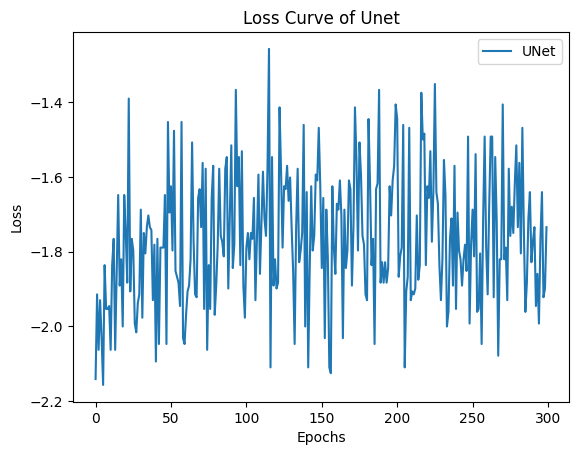

In [18]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['unet']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='UNet')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of Unet')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## agm(VAE+CLIP)+MSE
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae-ipadapter_yingbu_agm_mse_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [1]:
loss_dict_list = [{'loss_sum': -2.8125, 'loss': -1.3217787742614746, 'vae': -2.359375, 'ipadapter': -0.453125}, {'loss_sum': -2.609375, 'loss': -1.0572600364685059, 'vae': -2.1875, 'ipadapter': -0.423828125}, {'loss_sum': -2.4375, 'loss': -1.1028938293457031, 'vae': -2.046875, 'ipadapter': -0.3984375}, {'loss_sum': -2.296875, 'loss': -1.018142580986023, 'vae': -1.921875, 'ipadapter': -0.376953125}, {'loss_sum': -2.203125, 'loss': -1.0157577991485596, 'vae': -1.8359375, 'ipadapter': -0.36328125}, {'loss_sum': -2.109375, 'loss': -0.9424364566802979, 'vae': -1.765625, 'ipadapter': -0.349609375}, {'loss_sum': -2.046875, 'loss': -0.9201123714447021, 'vae': -1.7109375, 'ipadapter': -0.33984375}, {'loss_sum': -2.0, 'loss': -0.8597550392150879, 'vae': -1.671875, 'ipadapter': -0.333984375}, {'loss_sum': -1.96875, 'loss': -0.8918200731277466, 'vae': -1.640625, 'ipadapter': -0.328125}, {'loss_sum': -1.9375, 'loss': -0.8169972896575928, 'vae': -1.609375, 'ipadapter': -0.32421875}, {'loss_sum': -1.8984375, 'loss': -0.8546525835990906, 'vae': -1.578125, 'ipadapter': -0.3203125}, {'loss_sum': -1.875, 'loss': -0.7828946709632874, 'vae': -1.5546875, 'ipadapter': -0.31640625}, {'loss_sum': -1.84375, 'loss': -0.8208835124969482, 'vae': -1.53125, 'ipadapter': -0.310546875}, {'loss_sum': -1.8125, 'loss': -0.7536799907684326, 'vae': -1.5078125, 'ipadapter': -0.306640625}, {'loss_sum': -1.796875, 'loss': -0.7616189122200012, 'vae': -1.4921875, 'ipadapter': -0.3046875}, {'loss_sum': -1.7734375, 'loss': -0.7503950595855713, 'vae': -1.46875, 'ipadapter': -0.302734375}, {'loss_sum': -1.75, 'loss': -0.7703445553779602, 'vae': -1.453125, 'ipadapter': -0.298828125}, {'loss_sum': -1.734375, 'loss': -0.7144676446914673, 'vae': -1.4375, 'ipadapter': -0.296875}, {'loss_sum': -1.7265625, 'loss': -0.775892972946167, 'vae': -1.4296875, 'ipadapter': -0.296875}, {'loss_sum': -1.7109375, 'loss': -0.7177472114562988, 'vae': -1.421875, 'ipadapter': -0.291015625}, {'loss_sum': -1.6953125, 'loss': -0.7594664692878723, 'vae': -1.40625, 'ipadapter': -0.291015625}, {'loss_sum': -1.6875, 'loss': -0.7205843925476074, 'vae': -1.3984375, 'ipadapter': -0.2890625}, {'loss_sum': -1.6796875, 'loss': -0.7327212691307068, 'vae': -1.390625, 'ipadapter': -0.287109375}, {'loss_sum': -1.6640625, 'loss': -0.6933284997940063, 'vae': -1.3828125, 'ipadapter': -0.283203125}, {'loss_sum': -1.65625, 'loss': -0.706356406211853, 'vae': -1.375, 'ipadapter': -0.283203125}, {'loss_sum': -1.6484375, 'loss': -0.6845417618751526, 'vae': -1.3671875, 'ipadapter': -0.28125}, {'loss_sum': -1.640625, 'loss': -0.6927467584609985, 'vae': -1.359375, 'ipadapter': -0.27734375}, {'loss_sum': -1.625, 'loss': -0.6731368899345398, 'vae': -1.3515625, 'ipadapter': -0.27734375}, {'loss_sum': -1.6171875, 'loss': -0.6680374145507812, 'vae': -1.34375, 'ipadapter': -0.275390625}, {'loss_sum': -1.6171875, 'loss': -0.6658824682235718, 'vae': -1.34375, 'ipadapter': -0.2734375}, {'loss_sum': -1.609375, 'loss': -0.6911975741386414, 'vae': -1.3359375, 'ipadapter': -0.271484375}, {'loss_sum': -1.609375, 'loss': -0.6596157550811768, 'vae': -1.3359375, 'ipadapter': -0.26953125}, {'loss_sum': -1.59375, 'loss': -0.6861600875854492, 'vae': -1.328125, 'ipadapter': -0.26953125}, {'loss_sum': -1.5859375, 'loss': -0.6494693756103516, 'vae': -1.3203125, 'ipadapter': -0.265625}, {'loss_sum': -1.5859375, 'loss': -0.6627197265625, 'vae': -1.3203125, 'ipadapter': -0.265625}, {'loss_sum': -1.578125, 'loss': -0.6905020475387573, 'vae': -1.3125, 'ipadapter': -0.265625}, {'loss_sum': -1.578125, 'loss': -0.6394864320755005, 'vae': -1.3125, 'ipadapter': -0.26171875}, {'loss_sum': -1.5703125, 'loss': -0.6708648800849915, 'vae': -1.3046875, 'ipadapter': -0.263671875}, {'loss_sum': -1.5625, 'loss': -0.6496100425720215, 'vae': -1.3046875, 'ipadapter': -0.259765625}, {'loss_sum': -1.5625, 'loss': -0.665492057800293, 'vae': -1.3046875, 'ipadapter': -0.2578125}, {'loss_sum': -1.5546875, 'loss': -0.6919823884963989, 'vae': -1.296875, 'ipadapter': -0.255859375}, {'loss_sum': -1.546875, 'loss': -0.6547994017601013, 'vae': -1.296875, 'ipadapter': -0.25390625}, {'loss_sum': -1.546875, 'loss': -0.607577383518219, 'vae': -1.296875, 'ipadapter': -0.251953125}, {'loss_sum': -1.5390625, 'loss': -0.6345832943916321, 'vae': -1.2890625, 'ipadapter': -0.251953125}, {'loss_sum': -1.5390625, 'loss': -0.6676111221313477, 'vae': -1.2890625, 'ipadapter': -0.251953125}, {'loss_sum': -1.5390625, 'loss': -0.6051458716392517, 'vae': -1.2890625, 'ipadapter': -0.248046875}, {'loss_sum': -1.53125, 'loss': -0.6229445934295654, 'vae': -1.28125, 'ipadapter': -0.2470703125}, {'loss_sum': -1.53125, 'loss': -0.5988539457321167, 'vae': -1.28125, 'ipadapter': -0.2470703125}, {'loss_sum': -1.53125, 'loss': -0.583925187587738, 'vae': -1.28125, 'ipadapter': -0.2470703125}, {'loss_sum': -1.53125, 'loss': -0.6477271914482117, 'vae': -1.28125, 'ipadapter': -0.24609375}, {'loss_sum': -1.515625, 'loss': -0.5984607934951782, 'vae': -1.2734375, 'ipadapter': -0.2412109375}, {'loss_sum': -1.515625, 'loss': -0.5852071642875671, 'vae': -1.2734375, 'ipadapter': -0.2392578125}, {'loss_sum': -1.515625, 'loss': -0.6269693374633789, 'vae': -1.2734375, 'ipadapter': -0.240234375}, {'loss_sum': -1.5078125, 'loss': -0.5975425243377686, 'vae': -1.2734375, 'ipadapter': -0.236328125}, {'loss_sum': -1.5, 'loss': -0.5979716181755066, 'vae': -1.265625, 'ipadapter': -0.2373046875}, {'loss_sum': -1.5, 'loss': -0.578737735748291, 'vae': -1.265625, 'ipadapter': -0.2353515625}, {'loss_sum': -1.5, 'loss': -0.5997508764266968, 'vae': -1.265625, 'ipadapter': -0.234375}, {'loss_sum': -1.5, 'loss': -0.615925669670105, 'vae': -1.265625, 'ipadapter': -0.2333984375}, {'loss_sum': -1.484375, 'loss': -0.5587618947029114, 'vae': -1.2578125, 'ipadapter': -0.2294921875}, {'loss_sum': -1.4921875, 'loss': -0.5667195320129395, 'vae': -1.2578125, 'ipadapter': -0.2314453125}, {'loss_sum': -1.484375, 'loss': -0.5087116360664368, 'vae': -1.2578125, 'ipadapter': -0.23046875}, {'loss_sum': -1.484375, 'loss': -0.6315276622772217, 'vae': -1.2578125, 'ipadapter': -0.23046875}, {'loss_sum': -1.484375, 'loss': -0.547501802444458, 'vae': -1.2578125, 'ipadapter': -0.2275390625}, {'loss_sum': -1.484375, 'loss': -0.5846230387687683, 'vae': -1.2578125, 'ipadapter': -0.2255859375}, {'loss_sum': -1.484375, 'loss': -0.5593335628509521, 'vae': -1.2578125, 'ipadapter': -0.224609375}, {'loss_sum': -1.4765625, 'loss': -0.555942952632904, 'vae': -1.25, 'ipadapter': -0.224609375}, {'loss_sum': -1.46875, 'loss': -0.5756236910820007, 'vae': -1.25, 'ipadapter': -0.22265625}, {'loss_sum': -1.46875, 'loss': -0.5342550277709961, 'vae': -1.25, 'ipadapter': -0.22265625}, {'loss_sum': -1.46875, 'loss': -0.5584546327590942, 'vae': -1.25, 'ipadapter': -0.22265625}, {'loss_sum': -1.46875, 'loss': -0.4962127208709717, 'vae': -1.25, 'ipadapter': -0.220703125}, {'loss_sum': -1.4609375, 'loss': -0.5368607044219971, 'vae': -1.2421875, 'ipadapter': -0.2216796875}, {'loss_sum': -1.4609375, 'loss': -0.5317544937133789, 'vae': -1.2421875, 'ipadapter': -0.21875}, {'loss_sum': -1.4609375, 'loss': -0.5526188611984253, 'vae': -1.2421875, 'ipadapter': -0.21875}, {'loss_sum': -1.4609375, 'loss': -0.5141423940658569, 'vae': -1.2421875, 'ipadapter': -0.2158203125}, {'loss_sum': -1.4609375, 'loss': -0.5717964172363281, 'vae': -1.2421875, 'ipadapter': -0.216796875}, {'loss_sum': -1.453125, 'loss': -0.5243050456047058, 'vae': -1.2421875, 'ipadapter': -0.212890625}, {'loss_sum': -1.453125, 'loss': -0.5016152858734131, 'vae': -1.2421875, 'ipadapter': -0.212890625}, {'loss_sum': -1.4453125, 'loss': -0.5530298948287964, 'vae': -1.234375, 'ipadapter': -0.2138671875}, {'loss_sum': -1.4453125, 'loss': -0.5050370693206787, 'vae': -1.234375, 'ipadapter': -0.2119140625}, {'loss_sum': -1.4453125, 'loss': -0.5033082962036133, 'vae': -1.234375, 'ipadapter': -0.2109375}, {'loss_sum': -1.4453125, 'loss': -0.5487479567527771, 'vae': -1.234375, 'ipadapter': -0.2119140625}, {'loss_sum': -1.4453125, 'loss': -0.6063350439071655, 'vae': -1.234375, 'ipadapter': -0.2080078125}, {'loss_sum': -1.4375, 'loss': -0.5177114009857178, 'vae': -1.234375, 'ipadapter': -0.205078125}, {'loss_sum': -1.4375, 'loss': -0.5849193334579468, 'vae': -1.234375, 'ipadapter': -0.20703125}, {'loss_sum': -1.4375, 'loss': -0.5265854597091675, 'vae': -1.234375, 'ipadapter': -0.2060546875}, {'loss_sum': -1.4375, 'loss': -0.4827690124511719, 'vae': -1.234375, 'ipadapter': -0.2041015625}, {'loss_sum': -1.4296875, 'loss': -0.5490134954452515, 'vae': -1.2265625, 'ipadapter': -0.205078125}, {'loss_sum': -1.4296875, 'loss': -0.4626440405845642, 'vae': -1.2265625, 'ipadapter': -0.2021484375}, {'loss_sum': -1.4296875, 'loss': -0.5505151748657227, 'vae': -1.2265625, 'ipadapter': -0.2041015625}, {'loss_sum': -1.4296875, 'loss': -0.47207051515579224, 'vae': -1.2265625, 'ipadapter': -0.2001953125}, {'loss_sum': -1.4296875, 'loss': -0.5481967926025391, 'vae': -1.2265625, 'ipadapter': -0.2021484375}, {'loss_sum': -1.421875, 'loss': -0.5098944902420044, 'vae': -1.2265625, 'ipadapter': -0.19921875}, {'loss_sum': -1.4296875, 'loss': -0.49713432788848877, 'vae': -1.2265625, 'ipadapter': -0.2021484375}, {'loss_sum': -1.4296875, 'loss': -0.5130491256713867, 'vae': -1.2265625, 'ipadapter': -0.2021484375}, {'loss_sum': -1.4296875, 'loss': -0.48875656723976135, 'vae': -1.2265625, 'ipadapter': -0.201171875}, {'loss_sum': -1.4296875, 'loss': -0.5715539455413818, 'vae': -1.2265625, 'ipadapter': -0.2001953125}, {'loss_sum': -1.421875, 'loss': -0.5051389932632446, 'vae': -1.2265625, 'ipadapter': -0.197265625}, {'loss_sum': -1.421875, 'loss': -0.465192973613739, 'vae': -1.2265625, 'ipadapter': -0.197265625}, {'loss_sum': -1.421875, 'loss': -0.5331618189811707, 'vae': -1.2265625, 'ipadapter': -0.19921875}, {'loss_sum': -1.4140625, 'loss': -0.4643414616584778, 'vae': -1.21875, 'ipadapter': -0.197265625}, {'loss_sum': -1.421875, 'loss': -0.544404149055481, 'vae': -1.21875, 'ipadapter': -0.19921875}, {'loss_sum': -1.4140625, 'loss': -0.5686902403831482, 'vae': -1.21875, 'ipadapter': -0.197265625}, {'loss_sum': -1.4140625, 'loss': -0.45783472061157227, 'vae': -1.21875, 'ipadapter': -0.1943359375}, {'loss_sum': -1.4140625, 'loss': -0.5439262986183167, 'vae': -1.21875, 'ipadapter': -0.1962890625}, {'loss_sum': -1.4140625, 'loss': -0.49593114852905273, 'vae': -1.21875, 'ipadapter': -0.193359375}, {'loss_sum': -1.40625, 'loss': -0.44602370262145996, 'vae': -1.21875, 'ipadapter': -0.19140625}, {'loss_sum': -1.4140625, 'loss': -0.560116708278656, 'vae': -1.21875, 'ipadapter': -0.1953125}, {'loss_sum': -1.40625, 'loss': -0.45865944027900696, 'vae': -1.21875, 'ipadapter': -0.1904296875}, {'loss_sum': -1.4140625, 'loss': -0.4625466763973236, 'vae': -1.21875, 'ipadapter': -0.1923828125}, {'loss_sum': -1.4140625, 'loss': -0.4754870533943176, 'vae': -1.21875, 'ipadapter': -0.1923828125}, {'loss_sum': -1.40625, 'loss': -0.48872649669647217, 'vae': -1.2109375, 'ipadapter': -0.19140625}, {'loss_sum': -1.3984375, 'loss': -0.46806764602661133, 'vae': -1.2109375, 'ipadapter': -0.1884765625}, {'loss_sum': -1.3984375, 'loss': -0.4986814558506012, 'vae': -1.2109375, 'ipadapter': -0.1904296875}, {'loss_sum': -1.3984375, 'loss': -0.4299588203430176, 'vae': -1.2109375, 'ipadapter': -0.1884765625}, {'loss_sum': -1.3984375, 'loss': -0.4895952045917511, 'vae': -1.2109375, 'ipadapter': -0.189453125}, {'loss_sum': -1.3984375, 'loss': -0.450664222240448, 'vae': -1.2109375, 'ipadapter': -0.189453125}, {'loss_sum': -1.40625, 'loss': -0.5012716054916382, 'vae': -1.2109375, 'ipadapter': -0.1923828125}, {'loss_sum': -1.40625, 'loss': -0.47248125076293945, 'vae': -1.2109375, 'ipadapter': -0.19140625}, {'loss_sum': -1.3984375, 'loss': -0.4856449067592621, 'vae': -1.2109375, 'ipadapter': -0.1904296875}, {'loss_sum': -1.3984375, 'loss': -0.5483509302139282, 'vae': -1.2109375, 'ipadapter': -0.189453125}, {'loss_sum': -1.3984375, 'loss': -0.42720842361450195, 'vae': -1.2109375, 'ipadapter': -0.1865234375}, {'loss_sum': -1.3984375, 'loss': -0.5142333507537842, 'vae': -1.2109375, 'ipadapter': -0.189453125}, {'loss_sum': -1.3984375, 'loss': -0.46544021368026733, 'vae': -1.2109375, 'ipadapter': -0.185546875}, {'loss_sum': -1.3984375, 'loss': -0.46141916513442993, 'vae': -1.2109375, 'ipadapter': -0.185546875}, {'loss_sum': -1.3984375, 'loss': -0.46473023295402527, 'vae': -1.2109375, 'ipadapter': -0.1845703125}, {'loss_sum': -1.390625, 'loss': -0.4613924026489258, 'vae': -1.2109375, 'ipadapter': -0.18359375}, {'loss_sum': -1.390625, 'loss': -0.46355023980140686, 'vae': -1.2109375, 'ipadapter': -0.1826171875}, {'loss_sum': -1.390625, 'loss': -0.44038066267967224, 'vae': -1.2109375, 'ipadapter': -0.181640625}, {'loss_sum': -1.3828125, 'loss': -0.4722369313240051, 'vae': -1.203125, 'ipadapter': -0.1826171875}, {'loss_sum': -1.390625, 'loss': -0.42393046617507935, 'vae': -1.2109375, 'ipadapter': -0.1826171875}, {'loss_sum': -1.3828125, 'loss': -0.43914785981178284, 'vae': -1.203125, 'ipadapter': -0.1826171875}, {'loss_sum': -1.3828125, 'loss': -0.4759468734264374, 'vae': -1.203125, 'ipadapter': -0.181640625}, {'loss_sum': -1.3828125, 'loss': -0.44733726978302, 'vae': -1.203125, 'ipadapter': -0.1796875}, {'loss_sum': -1.3828125, 'loss': -0.4265759587287903, 'vae': -1.203125, 'ipadapter': -0.1787109375}, {'loss_sum': -1.3828125, 'loss': -0.44375717639923096, 'vae': -1.203125, 'ipadapter': -0.1796875}, {'loss_sum': -1.3828125, 'loss': -0.4683346152305603, 'vae': -1.203125, 'ipadapter': -0.1787109375}, {'loss_sum': -1.3828125, 'loss': -0.4237198233604431, 'vae': -1.203125, 'ipadapter': -0.1767578125}, {'loss_sum': -1.3828125, 'loss': -0.47620290517807007, 'vae': -1.203125, 'ipadapter': -0.177734375}, {'loss_sum': -1.3828125, 'loss': -0.4490460753440857, 'vae': -1.203125, 'ipadapter': -0.1767578125}, {'loss_sum': -1.3828125, 'loss': -0.45421597361564636, 'vae': -1.203125, 'ipadapter': -0.177734375}, {'loss_sum': -1.375, 'loss': -0.43321770429611206, 'vae': -1.203125, 'ipadapter': -0.1748046875}, {'loss_sum': -1.375, 'loss': -0.43321770429611206, 'vae': -1.203125, 'ipadapter': -0.1748046875}, {'loss_sum': -1.375, 'loss': -0.4521781802177429, 'vae': -1.203125, 'ipadapter': -0.173828125}, {'loss_sum': -1.375, 'loss': -0.4226346015930176, 'vae': -1.203125, 'ipadapter': -0.1728515625}, {'loss_sum': -1.375, 'loss': -0.4353674352169037, 'vae': -1.203125, 'ipadapter': -0.1748046875}, {'loss_sum': -1.375, 'loss': -0.39620834589004517, 'vae': -1.203125, 'ipadapter': -0.173828125}, {'loss_sum': -1.375, 'loss': -0.4411097764968872, 'vae': -1.203125, 'ipadapter': -0.173828125}, {'loss_sum': -1.375, 'loss': -0.42749810218811035, 'vae': -1.203125, 'ipadapter': -0.1728515625}, {'loss_sum': -1.375, 'loss': -0.413213849067688, 'vae': -1.203125, 'ipadapter': -0.169921875}, {'loss_sum': -1.375, 'loss': -0.38243842124938965, 'vae': -1.203125, 'ipadapter': -0.171875}, {'loss_sum': -1.3671875, 'loss': -0.4632995128631592, 'vae': -1.1953125, 'ipadapter': -0.173828125}, {'loss_sum': -1.375, 'loss': -0.45409947633743286, 'vae': -1.203125, 'ipadapter': -0.1708984375}, {'loss_sum': -1.375, 'loss': -0.4057199954986572, 'vae': -1.203125, 'ipadapter': -0.169921875}, {'loss_sum': -1.3671875, 'loss': -0.45266467332839966, 'vae': -1.1953125, 'ipadapter': -0.171875}, {'loss_sum': -1.375, 'loss': -0.4543617069721222, 'vae': -1.203125, 'ipadapter': -0.169921875}, {'loss_sum': -1.3671875, 'loss': -0.4461195468902588, 'vae': -1.1953125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.3671875, 'loss': -0.4504951536655426, 'vae': -1.1953125, 'ipadapter': -0.1708984375}, {'loss_sum': -1.375, 'loss': -0.4393238425254822, 'vae': -1.203125, 'ipadapter': -0.1708984375}, {'loss_sum': -1.3671875, 'loss': -0.437292218208313, 'vae': -1.1953125, 'ipadapter': -0.1708984375}, {'loss_sum': -1.3671875, 'loss': -0.4571712613105774, 'vae': -1.1953125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.359375, 'loss': -0.4009758234024048, 'vae': -1.1953125, 'ipadapter': -0.16796875}, {'loss_sum': -1.3671875, 'loss': -0.4643170237541199, 'vae': -1.1953125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.359375, 'loss': -0.3915415108203888, 'vae': -1.1953125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.359375, 'loss': -0.44878116250038147, 'vae': -1.1953125, 'ipadapter': -0.166015625}, {'loss_sum': -1.359375, 'loss': -0.43386244773864746, 'vae': -1.1953125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.359375, 'loss': -0.45266157388687134, 'vae': -1.1953125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.359375, 'loss': -0.40622955560684204, 'vae': -1.1953125, 'ipadapter': -0.166015625}, {'loss_sum': -1.359375, 'loss': -0.3923042416572571, 'vae': -1.1953125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.3671875, 'loss': -0.4524135887622833, 'vae': -1.1953125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.359375, 'loss': -0.3980116546154022, 'vae': -1.1953125, 'ipadapter': -0.1650390625}, {'loss_sum': -1.359375, 'loss': -0.4370037913322449, 'vae': -1.1953125, 'ipadapter': -0.166015625}, {'loss_sum': -1.359375, 'loss': -0.43257176876068115, 'vae': -1.1953125, 'ipadapter': -0.162109375}, {'loss_sum': -1.359375, 'loss': -0.43257176876068115, 'vae': -1.1953125, 'ipadapter': -0.162109375}, {'loss_sum': -1.3671875, 'loss': -0.3716816306114197, 'vae': -1.203125, 'ipadapter': -0.162109375}, {'loss_sum': -1.359375, 'loss': -0.45247602462768555, 'vae': -1.1953125, 'ipadapter': -0.1650390625}, {'loss_sum': -1.359375, 'loss': -0.3887764811515808, 'vae': -1.1953125, 'ipadapter': -0.1611328125}, {'loss_sum': -1.359375, 'loss': -0.46840763092041016, 'vae': -1.1953125, 'ipadapter': -0.1630859375}, {'loss_sum': -1.359375, 'loss': -0.41946882009506226, 'vae': -1.1953125, 'ipadapter': -0.16015625}, {'loss_sum': -1.359375, 'loss': -0.4119584858417511, 'vae': -1.1953125, 'ipadapter': -0.1611328125}, {'loss_sum': -1.359375, 'loss': -0.4472495913505554, 'vae': -1.1953125, 'ipadapter': -0.162109375}, {'loss_sum': -1.3515625, 'loss': -0.344230592250824, 'vae': -1.1953125, 'ipadapter': -0.1591796875}, {'loss_sum': -1.359375, 'loss': -0.42397016286849976, 'vae': -1.1953125, 'ipadapter': -0.1640625}, {'loss_sum': -1.359375, 'loss': -0.4442589282989502, 'vae': -1.1953125, 'ipadapter': -0.16015625}, {'loss_sum': -1.3515625, 'loss': -0.35660988092422485, 'vae': -1.1953125, 'ipadapter': -0.1591796875}, {'loss_sum': -1.359375, 'loss': -0.44048774242401123, 'vae': -1.1953125, 'ipadapter': -0.1630859375}, {'loss_sum': -1.359375, 'loss': -0.3962518572807312, 'vae': -1.1953125, 'ipadapter': -0.1611328125}, {'loss_sum': -1.359375, 'loss': -0.3924022912979126, 'vae': -1.1953125, 'ipadapter': -0.162109375}, {'loss_sum': -1.359375, 'loss': -0.4247996509075165, 'vae': -1.1953125, 'ipadapter': -0.16015625}, {'loss_sum': -1.3515625, 'loss': -0.39532577991485596, 'vae': -1.1953125, 'ipadapter': -0.158203125}, {'loss_sum': -1.34375, 'loss': -0.4292185306549072, 'vae': -1.1875, 'ipadapter': -0.1591796875}, {'loss_sum': -1.3515625, 'loss': -0.39532577991485596, 'vae': -1.1953125, 'ipadapter': -0.158203125}, {'loss_sum': -1.3515625, 'loss': -0.4193830192089081, 'vae': -1.1953125, 'ipadapter': -0.1572265625}, {'loss_sum': -1.34375, 'loss': -0.39117199182510376, 'vae': -1.1875, 'ipadapter': -0.1572265625}, {'loss_sum': -1.34375, 'loss': -0.4046756625175476, 'vae': -1.1875, 'ipadapter': -0.158203125}, {'loss_sum': -1.3515625, 'loss': -0.4594101011753082, 'vae': -1.1953125, 'ipadapter': -0.1591796875}, {'loss_sum': -1.3515625, 'loss': -0.3820646405220032, 'vae': -1.1953125, 'ipadapter': -0.1552734375}, {'loss_sum': -1.359375, 'loss': -0.45431020855903625, 'vae': -1.1953125, 'ipadapter': -0.1611328125}, {'loss_sum': -1.3515625, 'loss': -0.3846995532512665, 'vae': -1.1953125, 'ipadapter': -0.158203125}, {'loss_sum': -1.34375, 'loss': -0.39748841524124146, 'vae': -1.1875, 'ipadapter': -0.1591796875}, {'loss_sum': -1.34375, 'loss': -0.4032214879989624, 'vae': -1.1875, 'ipadapter': -0.16015625}, {'loss_sum': -1.3515625, 'loss': -0.3852676451206207, 'vae': -1.1953125, 'ipadapter': -0.158203125}, {'loss_sum': -1.34375, 'loss': -0.39967286586761475, 'vae': -1.1875, 'ipadapter': -0.1572265625}, {'loss_sum': -1.34375, 'loss': -0.3938411474227905, 'vae': -1.1875, 'ipadapter': -0.15625}, {'loss_sum': -1.34375, 'loss': -0.3820631206035614, 'vae': -1.1875, 'ipadapter': -0.1552734375}, {'loss_sum': -1.34375, 'loss': -0.3770877718925476, 'vae': -1.1875, 'ipadapter': -0.15625}, {'loss_sum': -1.3515625, 'loss': -0.3641347885131836, 'vae': -1.1953125, 'ipadapter': -0.1552734375}, {'loss_sum': -1.34375, 'loss': -0.4313795864582062, 'vae': -1.1875, 'ipadapter': -0.158203125}, {'loss_sum': -1.34375, 'loss': -0.41646838188171387, 'vae': -1.1875, 'ipadapter': -0.154296875}, {'loss_sum': -1.34375, 'loss': -0.36898285150527954, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.34375, 'loss': -0.37444940209388733, 'vae': -1.1875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.34375, 'loss': -0.40170156955718994, 'vae': -1.1875, 'ipadapter': -0.154296875}, {'loss_sum': -1.34375, 'loss': -0.37686604261398315, 'vae': -1.1875, 'ipadapter': -0.154296875}, {'loss_sum': -1.34375, 'loss': -0.40021613240242004, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.34375, 'loss': -0.3399208188056946, 'vae': -1.1875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.34375, 'loss': -0.45443543791770935, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.3359375, 'loss': -0.33764684200286865, 'vae': -1.1875, 'ipadapter': -0.150390625}, {'loss_sum': -1.3359375, 'loss': -0.411531925201416, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.3789353668689728, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.37735825777053833, 'vae': -1.1875, 'ipadapter': -0.150390625}, {'loss_sum': -1.34375, 'loss': -0.42236194014549255, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.3359375, 'loss': -0.38448476791381836, 'vae': -1.1875, 'ipadapter': -0.1484375}, {'loss_sum': -1.3359375, 'loss': -0.34152525663375854, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.34375, 'loss': -0.43320488929748535, 'vae': -1.1875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.3359375, 'loss': -0.3526016175746918, 'vae': -1.1875, 'ipadapter': -0.150390625}, {'loss_sum': -1.3359375, 'loss': -0.3885512351989746, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.411531925201416, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.3681707978248596, 'vae': -1.1875, 'ipadapter': -0.1474609375}, {'loss_sum': -1.3359375, 'loss': -0.34152525663375854, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.34375, 'loss': -0.4355579614639282, 'vae': -1.1875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.3359375, 'loss': -0.3047633171081543, 'vae': -1.1875, 'ipadapter': -0.1484375}, {'loss_sum': -1.34375, 'loss': -0.4330432713031769, 'vae': -1.1875, 'ipadapter': -0.15234375}, {'loss_sum': -1.3359375, 'loss': -0.3185359835624695, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.3359375, 'loss': -0.38084086775779724, 'vae': -1.1875, 'ipadapter': -0.1484375}, {'loss_sum': -1.3359375, 'loss': -0.3408583998680115, 'vae': -1.1875, 'ipadapter': -0.1474609375}, {'loss_sum': -1.3359375, 'loss': -0.4025043845176697, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.3359375, 'loss': -0.32933664321899414, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.3359375, 'loss': -0.4932549297809601, 'vae': -1.1875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.3359375, 'loss': -0.3419486880302429, 'vae': -1.1875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.3359375, 'loss': -0.37132227420806885, 'vae': -1.1875, 'ipadapter': -0.1494140625}, {'loss_sum': -1.3359375, 'loss': -0.3391442596912384, 'vae': -1.1875, 'ipadapter': -0.1474609375}, {'loss_sum': -1.3359375, 'loss': -0.36959630250930786, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.3359375, 'loss': -0.38959020376205444, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.328125, 'loss': -0.3375392258167267, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.3359375, 'loss': -0.4373660087585449, 'vae': -1.1875, 'ipadapter': -0.146484375}, {'loss_sum': -1.328125, 'loss': -0.38076043128967285, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.35191065073013306, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.37088531255722046, 'vae': -1.1796875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.328125, 'loss': -0.34458744525909424, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.3359375, 'loss': -0.3893046975135803, 'vae': -1.1875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.328125, 'loss': -0.35614287853240967, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.3234248757362366, 'vae': -1.1875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.37903040647506714, 'vae': -1.1796875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.3359375, 'loss': -0.3497099280357361, 'vae': -1.1875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.328125, 'loss': -0.3595173954963684, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.38597241044044495, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.3467208743095398, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.3203125, 'loss': -0.35035139322280884, 'vae': -1.1796875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.4115852415561676, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.312343031167984, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.3203125, 'loss': -0.36888444423675537, 'vae': -1.1796875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.3359375, 'loss': -0.4265281856060028, 'vae': -1.1875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.328125, 'loss': -0.3386293351650238, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.386722207069397, 'vae': -1.1875, 'ipadapter': -0.14453125}, {'loss_sum': -1.328125, 'loss': -0.312100887298584, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.4046920835971832, 'vae': -1.1875, 'ipadapter': -0.14453125}, {'loss_sum': -1.328125, 'loss': -0.3103858232498169, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.3359375, 'loss': -0.38405340909957886, 'vae': -1.1953125, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.3441086411476135, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.3467208743095398, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.3696199059486389, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.42641592025756836, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.3203125, 'loss': -0.36186325550079346, 'vae': -1.1796875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.33801424503326416, 'vae': -1.1875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.39235976338386536, 'vae': -1.1875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.3543083965778351, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.39235976338386536, 'vae': -1.1875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.3467208743095398, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.3696105480194092, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.33942121267318726, 'vae': -1.1875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.4359877109527588, 'vae': -1.1875, 'ipadapter': -0.14453125}, {'loss_sum': -1.328125, 'loss': -0.336028128862381, 'vae': -1.1875, 'ipadapter': -0.1396484375}, {'loss_sum': -1.328125, 'loss': -0.38433313369750977, 'vae': -1.1875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.3191661536693573, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.3203125, 'loss': -0.3707229495048523, 'vae': -1.1796875, 'ipadapter': -0.1416015625}, {'loss_sum': -1.328125, 'loss': -0.4116823673248291, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.316736102104187, 'vae': -1.1875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.3203125, 'loss': -0.42570972442626953, 'vae': -1.1796875, 'ipadapter': -0.1435546875}, {'loss_sum': -1.328125, 'loss': -0.3933931887149811, 'vae': -1.1875, 'ipadapter': -0.1396484375}, {'loss_sum': -1.328125, 'loss': -0.29765865206718445, 'vae': -1.1875, 'ipadapter': -0.138671875}, {'loss_sum': -1.328125, 'loss': -0.4009018540382385, 'vae': -1.1796875, 'ipadapter': -0.14453125}, {'loss_sum': -1.328125, 'loss': -0.3441086411476135, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.3801546096801758, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.3203125, 'loss': -0.35218489170074463, 'vae': -1.1796875, 'ipadapter': -0.140625}, {'loss_sum': -1.328125, 'loss': -0.3044087290763855, 'vae': -1.1875, 'ipadapter': -0.140625}, {'loss_sum': -1.3203125, 'loss': -0.4266808331012726, 'vae': -1.1796875, 'ipadapter': -0.142578125}, {'loss_sum': -1.328125, 'loss': -0.3682662844657898, 'vae': -1.1875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.328125, 'loss': -0.34374210238456726, 'vae': -1.1875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.328125, 'loss': -0.31531789898872375, 'vae': -1.1875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.328125, 'loss': -0.35888612270355225, 'vae': -1.1875, 'ipadapter': -0.138671875}, {'loss_sum': -1.328125, 'loss': -0.3605197072029114, 'vae': -1.1875, 'ipadapter': -0.138671875}]


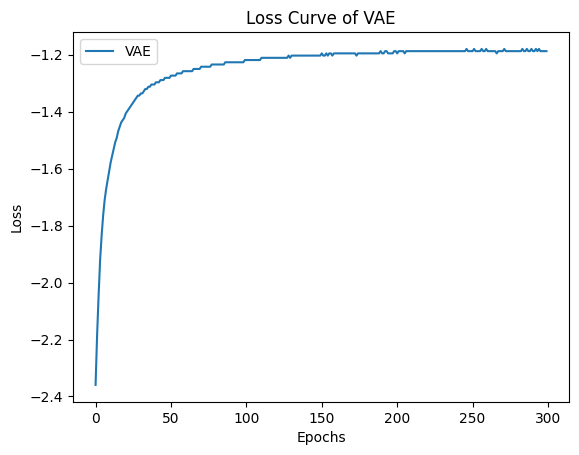

In [2]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['vae']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='VAE')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of VAE')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

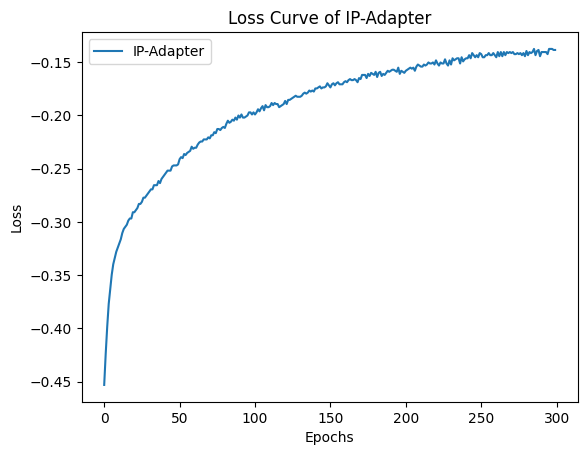

In [3]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IP-Adapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IP-Adapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## (1*VAE+1*CLIP)+MSE
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae-ipadapter_yingbu_no-agm-w1-0-w2-1-w3-1-w4-0_mse_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [4]:
loss_dict_list = [{'loss_sum': -2.8125, 'loss': -2.8125, 'vae': -2.359375, 'ipadapter': -0.453125}, {'loss_sum': -2.609375, 'loss': -2.609375, 'vae': -2.1875, 'ipadapter': -0.423828125}, {'loss_sum': -2.4375, 'loss': -2.4375, 'vae': -2.03125, 'ipadapter': -0.404296875}, {'loss_sum': -2.28125, 'loss': -2.28125, 'vae': -1.90625, 'ipadapter': -0.3828125}, {'loss_sum': -2.203125, 'loss': -2.203125, 'vae': -1.828125, 'ipadapter': -0.369140625}, {'loss_sum': -2.109375, 'loss': -2.109375, 'vae': -1.7578125, 'ipadapter': -0.35546875}, {'loss_sum': -2.0625, 'loss': -2.0625, 'vae': -1.7109375, 'ipadapter': -0.345703125}, {'loss_sum': -2.0, 'loss': -2.0, 'vae': -1.6640625, 'ipadapter': -0.33984375}, {'loss_sum': -1.953125, 'loss': -1.953125, 'vae': -1.625, 'ipadapter': -0.330078125}, {'loss_sum': -1.921875, 'loss': -1.921875, 'vae': -1.59375, 'ipadapter': -0.326171875}, {'loss_sum': -1.8828125, 'loss': -1.8828125, 'vae': -1.5625, 'ipadapter': -0.322265625}, {'loss_sum': -1.859375, 'loss': -1.859375, 'vae': -1.5390625, 'ipadapter': -0.31640625}, {'loss_sum': -1.828125, 'loss': -1.828125, 'vae': -1.515625, 'ipadapter': -0.314453125}, {'loss_sum': -1.8046875, 'loss': -1.8046875, 'vae': -1.4921875, 'ipadapter': -0.3125}, {'loss_sum': -1.78125, 'loss': -1.78125, 'vae': -1.4765625, 'ipadapter': -0.30859375}, {'loss_sum': -1.7578125, 'loss': -1.7578125, 'vae': -1.453125, 'ipadapter': -0.306640625}, {'loss_sum': -1.7421875, 'loss': -1.7421875, 'vae': -1.4375, 'ipadapter': -0.302734375}, {'loss_sum': -1.71875, 'loss': -1.71875, 'vae': -1.421875, 'ipadapter': -0.30078125}, {'loss_sum': -1.7109375, 'loss': -1.7109375, 'vae': -1.4140625, 'ipadapter': -0.298828125}, {'loss_sum': -1.6953125, 'loss': -1.6953125, 'vae': -1.3984375, 'ipadapter': -0.294921875}, {'loss_sum': -1.6875, 'loss': -1.6875, 'vae': -1.390625, 'ipadapter': -0.294921875}, {'loss_sum': -1.6796875, 'loss': -1.6796875, 'vae': -1.3828125, 'ipadapter': -0.294921875}, {'loss_sum': -1.671875, 'loss': -1.671875, 'vae': -1.375, 'ipadapter': -0.29296875}, {'loss_sum': -1.65625, 'loss': -1.65625, 'vae': -1.3671875, 'ipadapter': -0.2890625}, {'loss_sum': -1.6484375, 'loss': -1.6484375, 'vae': -1.359375, 'ipadapter': -0.287109375}, {'loss_sum': -1.640625, 'loss': -1.640625, 'vae': -1.3515625, 'ipadapter': -0.287109375}, {'loss_sum': -1.625, 'loss': -1.625, 'vae': -1.34375, 'ipadapter': -0.283203125}, {'loss_sum': -1.6171875, 'loss': -1.6171875, 'vae': -1.3359375, 'ipadapter': -0.283203125}, {'loss_sum': -1.609375, 'loss': -1.609375, 'vae': -1.328125, 'ipadapter': -0.279296875}, {'loss_sum': -1.6015625, 'loss': -1.6015625, 'vae': -1.3203125, 'ipadapter': -0.279296875}, {'loss_sum': -1.59375, 'loss': -1.59375, 'vae': -1.3203125, 'ipadapter': -0.27734375}, {'loss_sum': -1.59375, 'loss': -1.59375, 'vae': -1.3125, 'ipadapter': -0.27734375}, {'loss_sum': -1.5859375, 'loss': -1.5859375, 'vae': -1.3125, 'ipadapter': -0.275390625}, {'loss_sum': -1.578125, 'loss': -1.578125, 'vae': -1.3046875, 'ipadapter': -0.2734375}, {'loss_sum': -1.5703125, 'loss': -1.5703125, 'vae': -1.296875, 'ipadapter': -0.271484375}, {'loss_sum': -1.5703125, 'loss': -1.5703125, 'vae': -1.296875, 'ipadapter': -0.271484375}, {'loss_sum': -1.5625, 'loss': -1.5625, 'vae': -1.296875, 'ipadapter': -0.26953125}, {'loss_sum': -1.5546875, 'loss': -1.5546875, 'vae': -1.2890625, 'ipadapter': -0.267578125}, {'loss_sum': -1.5546875, 'loss': -1.5546875, 'vae': -1.2890625, 'ipadapter': -0.267578125}, {'loss_sum': -1.546875, 'loss': -1.546875, 'vae': -1.28125, 'ipadapter': -0.265625}, {'loss_sum': -1.546875, 'loss': -1.546875, 'vae': -1.28125, 'ipadapter': -0.263671875}, {'loss_sum': -1.546875, 'loss': -1.546875, 'vae': -1.28125, 'ipadapter': -0.26171875}, {'loss_sum': -1.53125, 'loss': -1.53125, 'vae': -1.2734375, 'ipadapter': -0.259765625}, {'loss_sum': -1.53125, 'loss': -1.53125, 'vae': -1.2734375, 'ipadapter': -0.2578125}, {'loss_sum': -1.53125, 'loss': -1.53125, 'vae': -1.2734375, 'ipadapter': -0.2578125}, {'loss_sum': -1.5234375, 'loss': -1.5234375, 'vae': -1.265625, 'ipadapter': -0.255859375}, {'loss_sum': -1.5234375, 'loss': -1.5234375, 'vae': -1.265625, 'ipadapter': -0.255859375}, {'loss_sum': -1.515625, 'loss': -1.515625, 'vae': -1.265625, 'ipadapter': -0.25390625}, {'loss_sum': -1.5078125, 'loss': -1.5078125, 'vae': -1.2578125, 'ipadapter': -0.251953125}, {'loss_sum': -1.5078125, 'loss': -1.5078125, 'vae': -1.2578125, 'ipadapter': -0.251953125}, {'loss_sum': -1.5078125, 'loss': -1.5078125, 'vae': -1.2578125, 'ipadapter': -0.2490234375}, {'loss_sum': -1.5078125, 'loss': -1.5078125, 'vae': -1.2578125, 'ipadapter': -0.2470703125}, {'loss_sum': -1.5, 'loss': -1.5, 'vae': -1.25, 'ipadapter': -0.2470703125}, {'loss_sum': -1.4921875, 'loss': -1.4921875, 'vae': -1.25, 'ipadapter': -0.2451171875}, {'loss_sum': -1.4921875, 'loss': -1.4921875, 'vae': -1.25, 'ipadapter': -0.244140625}, {'loss_sum': -1.4921875, 'loss': -1.4921875, 'vae': -1.25, 'ipadapter': -0.2431640625}, {'loss_sum': -1.484375, 'loss': -1.484375, 'vae': -1.2421875, 'ipadapter': -0.240234375}, {'loss_sum': -1.484375, 'loss': -1.484375, 'vae': -1.2421875, 'ipadapter': -0.2412109375}, {'loss_sum': -1.484375, 'loss': -1.484375, 'vae': -1.2421875, 'ipadapter': -0.2392578125}, {'loss_sum': -1.484375, 'loss': -1.484375, 'vae': -1.2421875, 'ipadapter': -0.23828125}, {'loss_sum': -1.484375, 'loss': -1.484375, 'vae': -1.2421875, 'ipadapter': -0.2421875}, {'loss_sum': -1.46875, 'loss': -1.46875, 'vae': -1.234375, 'ipadapter': -0.23828125}, {'loss_sum': -1.46875, 'loss': -1.46875, 'vae': -1.234375, 'ipadapter': -0.2373046875}, {'loss_sum': -1.46875, 'loss': -1.46875, 'vae': -1.234375, 'ipadapter': -0.2333984375}, {'loss_sum': -1.46875, 'loss': -1.46875, 'vae': -1.234375, 'ipadapter': -0.234375}, {'loss_sum': -1.46875, 'loss': -1.46875, 'vae': -1.234375, 'ipadapter': -0.234375}, {'loss_sum': -1.4609375, 'loss': -1.4609375, 'vae': -1.234375, 'ipadapter': -0.2294921875}, {'loss_sum': -1.46875, 'loss': -1.46875, 'vae': -1.234375, 'ipadapter': -0.2314453125}, {'loss_sum': -1.453125, 'loss': -1.453125, 'vae': -1.2265625, 'ipadapter': -0.2294921875}, {'loss_sum': -1.453125, 'loss': -1.453125, 'vae': -1.2265625, 'ipadapter': -0.228515625}, {'loss_sum': -1.453125, 'loss': -1.453125, 'vae': -1.2265625, 'ipadapter': -0.2275390625}, {'loss_sum': -1.453125, 'loss': -1.453125, 'vae': -1.2265625, 'ipadapter': -0.2275390625}, {'loss_sum': -1.453125, 'loss': -1.453125, 'vae': -1.2265625, 'ipadapter': -0.224609375}, {'loss_sum': -1.453125, 'loss': -1.453125, 'vae': -1.2265625, 'ipadapter': -0.2265625}, {'loss_sum': -1.453125, 'loss': -1.453125, 'vae': -1.2265625, 'ipadapter': -0.2255859375}, {'loss_sum': -1.4453125, 'loss': -1.4453125, 'vae': -1.21875, 'ipadapter': -0.224609375}, {'loss_sum': -1.4453125, 'loss': -1.4453125, 'vae': -1.21875, 'ipadapter': -0.224609375}, {'loss_sum': -1.4453125, 'loss': -1.4453125, 'vae': -1.21875, 'ipadapter': -0.224609375}, {'loss_sum': -1.4453125, 'loss': -1.4453125, 'vae': -1.21875, 'ipadapter': -0.2236328125}, {'loss_sum': -1.4375, 'loss': -1.4375, 'vae': -1.21875, 'ipadapter': -0.220703125}, {'loss_sum': -1.4375, 'loss': -1.4375, 'vae': -1.21875, 'ipadapter': -0.2216796875}, {'loss_sum': -1.4375, 'loss': -1.4375, 'vae': -1.21875, 'ipadapter': -0.2197265625}, {'loss_sum': -1.4375, 'loss': -1.4375, 'vae': -1.21875, 'ipadapter': -0.21875}, {'loss_sum': -1.4296875, 'loss': -1.4296875, 'vae': -1.2109375, 'ipadapter': -0.2177734375}, {'loss_sum': -1.4296875, 'loss': -1.4296875, 'vae': -1.2109375, 'ipadapter': -0.216796875}, {'loss_sum': -1.4296875, 'loss': -1.4296875, 'vae': -1.2109375, 'ipadapter': -0.2177734375}, {'loss_sum': -1.4296875, 'loss': -1.4296875, 'vae': -1.2109375, 'ipadapter': -0.2158203125}, {'loss_sum': -1.4296875, 'loss': -1.4296875, 'vae': -1.2109375, 'ipadapter': -0.2158203125}, {'loss_sum': -1.421875, 'loss': -1.421875, 'vae': -1.2109375, 'ipadapter': -0.21484375}, {'loss_sum': -1.421875, 'loss': -1.421875, 'vae': -1.203125, 'ipadapter': -0.2158203125}, {'loss_sum': -1.4296875, 'loss': -1.4296875, 'vae': -1.2109375, 'ipadapter': -0.2158203125}, {'loss_sum': -1.4140625, 'loss': -1.4140625, 'vae': -1.203125, 'ipadapter': -0.212890625}, {'loss_sum': -1.4140625, 'loss': -1.4140625, 'vae': -1.203125, 'ipadapter': -0.2138671875}, {'loss_sum': -1.421875, 'loss': -1.421875, 'vae': -1.203125, 'ipadapter': -0.2158203125}, {'loss_sum': -1.421875, 'loss': -1.421875, 'vae': -1.203125, 'ipadapter': -0.21484375}, {'loss_sum': -1.4140625, 'loss': -1.4140625, 'vae': -1.203125, 'ipadapter': -0.212890625}, {'loss_sum': -1.4140625, 'loss': -1.4140625, 'vae': -1.203125, 'ipadapter': -0.2119140625}, {'loss_sum': -1.4140625, 'loss': -1.4140625, 'vae': -1.203125, 'ipadapter': -0.2119140625}, {'loss_sum': -1.4140625, 'loss': -1.4140625, 'vae': -1.203125, 'ipadapter': -0.2109375}, {'loss_sum': -1.40625, 'loss': -1.40625, 'vae': -1.1953125, 'ipadapter': -0.2099609375}, {'loss_sum': -1.4140625, 'loss': -1.4140625, 'vae': -1.203125, 'ipadapter': -0.2099609375}, {'loss_sum': -1.40625, 'loss': -1.40625, 'vae': -1.1953125, 'ipadapter': -0.2099609375}, {'loss_sum': -1.40625, 'loss': -1.40625, 'vae': -1.1953125, 'ipadapter': -0.208984375}, {'loss_sum': -1.40625, 'loss': -1.40625, 'vae': -1.1953125, 'ipadapter': -0.2099609375}, {'loss_sum': -1.40625, 'loss': -1.40625, 'vae': -1.1953125, 'ipadapter': -0.20703125}, {'loss_sum': -1.40625, 'loss': -1.40625, 'vae': -1.1953125, 'ipadapter': -0.2099609375}, {'loss_sum': -1.40625, 'loss': -1.40625, 'vae': -1.1953125, 'ipadapter': -0.2080078125}, {'loss_sum': -1.3984375, 'loss': -1.3984375, 'vae': -1.1953125, 'ipadapter': -0.2060546875}, {'loss_sum': -1.3984375, 'loss': -1.3984375, 'vae': -1.1953125, 'ipadapter': -0.205078125}, {'loss_sum': -1.3984375, 'loss': -1.3984375, 'vae': -1.1953125, 'ipadapter': -0.2060546875}, {'loss_sum': -1.40625, 'loss': -1.40625, 'vae': -1.1953125, 'ipadapter': -0.20703125}, {'loss_sum': -1.390625, 'loss': -1.390625, 'vae': -1.1875, 'ipadapter': -0.2060546875}, {'loss_sum': -1.390625, 'loss': -1.390625, 'vae': -1.1875, 'ipadapter': -0.205078125}, {'loss_sum': -1.390625, 'loss': -1.390625, 'vae': -1.1875, 'ipadapter': -0.203125}, {'loss_sum': -1.390625, 'loss': -1.390625, 'vae': -1.1875, 'ipadapter': -0.2021484375}, {'loss_sum': -1.390625, 'loss': -1.390625, 'vae': -1.1875, 'ipadapter': -0.201171875}, {'loss_sum': -1.390625, 'loss': -1.390625, 'vae': -1.1875, 'ipadapter': -0.201171875}, {'loss_sum': -1.390625, 'loss': -1.390625, 'vae': -1.1875, 'ipadapter': -0.2041015625}, {'loss_sum': -1.390625, 'loss': -1.390625, 'vae': -1.1875, 'ipadapter': -0.201171875}, {'loss_sum': -1.390625, 'loss': -1.390625, 'vae': -1.1875, 'ipadapter': -0.19921875}, {'loss_sum': -1.390625, 'loss': -1.390625, 'vae': -1.1875, 'ipadapter': -0.201171875}, {'loss_sum': -1.390625, 'loss': -1.390625, 'vae': -1.1875, 'ipadapter': -0.2001953125}, {'loss_sum': -1.3828125, 'loss': -1.3828125, 'vae': -1.1875, 'ipadapter': -0.197265625}, {'loss_sum': -1.3828125, 'loss': -1.3828125, 'vae': -1.1875, 'ipadapter': -0.1982421875}, {'loss_sum': -1.3828125, 'loss': -1.3828125, 'vae': -1.1875, 'ipadapter': -0.1982421875}, {'loss_sum': -1.3828125, 'loss': -1.3828125, 'vae': -1.1875, 'ipadapter': -0.1962890625}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.197265625}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.197265625}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.197265625}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.1962890625}, {'loss_sum': -1.3828125, 'loss': -1.3828125, 'vae': -1.1875, 'ipadapter': -0.197265625}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.193359375}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.197265625}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.1943359375}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.1953125}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.1943359375}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.1962890625}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.1953125}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.1953125}, {'loss_sum': -1.3828125, 'loss': -1.3828125, 'vae': -1.1875, 'ipadapter': -0.1923828125}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.1943359375}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.1923828125}, {'loss_sum': -1.375, 'loss': -1.375, 'vae': -1.1796875, 'ipadapter': -0.1943359375}, {'loss_sum': -1.3671875, 'loss': -1.3671875, 'vae': -1.1796875, 'ipadapter': -0.1904296875}, {'loss_sum': -1.3671875, 'loss': -1.3671875, 'vae': -1.1796875, 'ipadapter': -0.189453125}, {'loss_sum': -1.3671875, 'loss': -1.3671875, 'vae': -1.1796875, 'ipadapter': -0.1904296875}, {'loss_sum': -1.3671875, 'loss': -1.3671875, 'vae': -1.1796875, 'ipadapter': -0.1884765625}, {'loss_sum': -1.3671875, 'loss': -1.3671875, 'vae': -1.1796875, 'ipadapter': -0.1884765625}, {'loss_sum': -1.3671875, 'loss': -1.3671875, 'vae': -1.1796875, 'ipadapter': -0.185546875}, {'loss_sum': -1.359375, 'loss': -1.359375, 'vae': -1.171875, 'ipadapter': -0.185546875}, {'loss_sum': -1.359375, 'loss': -1.359375, 'vae': -1.171875, 'ipadapter': -0.1865234375}, {'loss_sum': -1.359375, 'loss': -1.359375, 'vae': -1.171875, 'ipadapter': -0.1865234375}, {'loss_sum': -1.359375, 'loss': -1.359375, 'vae': -1.171875, 'ipadapter': -0.1875}, {'loss_sum': -1.359375, 'loss': -1.359375, 'vae': -1.171875, 'ipadapter': -0.185546875}, {'loss_sum': -1.359375, 'loss': -1.359375, 'vae': -1.171875, 'ipadapter': -0.1865234375}, {'loss_sum': -1.359375, 'loss': -1.359375, 'vae': -1.171875, 'ipadapter': -0.1865234375}, {'loss_sum': -1.359375, 'loss': -1.359375, 'vae': -1.171875, 'ipadapter': -0.185546875}, {'loss_sum': -1.359375, 'loss': -1.359375, 'vae': -1.171875, 'ipadapter': -0.185546875}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.1826171875}, {'loss_sum': -1.359375, 'loss': -1.359375, 'vae': -1.171875, 'ipadapter': -0.18359375}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.1806640625}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.1806640625}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.1826171875}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.181640625}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.181640625}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.181640625}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.1826171875}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.181640625}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.1806640625}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.1796875}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.1787109375}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.177734375}, {'loss_sum': -1.3515625, 'loss': -1.3515625, 'vae': -1.171875, 'ipadapter': -0.1767578125}, {'loss_sum': -1.34375, 'loss': -1.34375, 'vae': -1.1640625, 'ipadapter': -0.17578125}, {'loss_sum': -1.34375, 'loss': -1.34375, 'vae': -1.1640625, 'ipadapter': -0.177734375}, {'loss_sum': -1.34375, 'loss': -1.34375, 'vae': -1.1640625, 'ipadapter': -0.1787109375}, {'loss_sum': -1.34375, 'loss': -1.34375, 'vae': -1.1640625, 'ipadapter': -0.1787109375}, {'loss_sum': -1.34375, 'loss': -1.34375, 'vae': -1.1640625, 'ipadapter': -0.1787109375}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.1748046875}, {'loss_sum': -1.34375, 'loss': -1.34375, 'vae': -1.1640625, 'ipadapter': -0.177734375}, {'loss_sum': -1.34375, 'loss': -1.34375, 'vae': -1.1640625, 'ipadapter': -0.177734375}, {'loss_sum': -1.34375, 'loss': -1.34375, 'vae': -1.1640625, 'ipadapter': -0.177734375}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.1748046875}, {'loss_sum': -1.34375, 'loss': -1.34375, 'vae': -1.1640625, 'ipadapter': -0.17578125}, {'loss_sum': -1.34375, 'loss': -1.34375, 'vae': -1.1640625, 'ipadapter': -0.17578125}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.173828125}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.1748046875}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.1728515625}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.173828125}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.173828125}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.173828125}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.173828125}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.1728515625}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.1728515625}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.169921875}, {'loss_sum': -1.328125, 'loss': -1.328125, 'vae': -1.15625, 'ipadapter': -0.171875}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.171875}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.1728515625}, {'loss_sum': -1.328125, 'loss': -1.328125, 'vae': -1.15625, 'ipadapter': -0.1728515625}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.1708984375}, {'loss_sum': -1.328125, 'loss': -1.328125, 'vae': -1.15625, 'ipadapter': -0.1708984375}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.1708984375}, {'loss_sum': -1.328125, 'loss': -1.328125, 'vae': -1.15625, 'ipadapter': -0.1708984375}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.169921875}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.169921875}, {'loss_sum': -1.328125, 'loss': -1.328125, 'vae': -1.15625, 'ipadapter': -0.1689453125}, {'loss_sum': -1.3359375, 'loss': -1.3359375, 'vae': -1.1640625, 'ipadapter': -0.169921875}, {'loss_sum': -1.328125, 'loss': -1.328125, 'vae': -1.15625, 'ipadapter': -0.1689453125}, {'loss_sum': -1.328125, 'loss': -1.328125, 'vae': -1.15625, 'ipadapter': -0.169921875}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1669921875}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.166015625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1669921875}, {'loss_sum': -1.328125, 'loss': -1.328125, 'vae': -1.15625, 'ipadapter': -0.16796875}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1669921875}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1669921875}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.166015625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1650390625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.166015625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1650390625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1650390625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.166015625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1640625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1640625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1650390625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1650390625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1640625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1640625}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.166015625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.166015625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1669921875}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1630859375}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1650390625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1650390625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.166015625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.162109375}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.166015625}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1611328125}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1650390625}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.1630859375}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1640625}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.1611328125}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.162109375}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.1630859375}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.1611328125}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1611328125}, {'loss_sum': -1.3203125, 'loss': -1.3203125, 'vae': -1.15625, 'ipadapter': -0.1630859375}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.16015625}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.1630859375}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.1630859375}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.1611328125}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.16015625}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.1611328125}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.15625, 'ipadapter': -0.16015625}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.1611328125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1591796875}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.1611328125}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.16015625}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.16015625}, {'loss_sum': -1.3125, 'loss': -1.3125, 'vae': -1.1484375, 'ipadapter': -0.16015625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.158203125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1572265625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1572265625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.158203125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.158203125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.158203125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1591796875}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.158203125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.158203125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.158203125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.15625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.15625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.158203125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.15625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1572265625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.154296875}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1572265625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.15625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1552734375}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1552734375}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1552734375}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1572265625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.15625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.15625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1533203125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1552734375}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1533203125}, {'loss_sum': -1.296875, 'loss': -1.296875, 'vae': -1.1484375, 'ipadapter': -0.15234375}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.154296875}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1533203125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1533203125}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.1484375, 'ipadapter': -0.1533203125}, {'loss_sum': -1.296875, 'loss': -1.296875, 'vae': -1.1484375, 'ipadapter': -0.1513671875}, {'loss_sum': -1.296875, 'loss': -1.296875, 'vae': -1.1484375, 'ipadapter': -0.15234375}, {'loss_sum': -1.296875, 'loss': -1.296875, 'vae': -1.1484375, 'ipadapter': -0.1513671875}, {'loss_sum': -1.296875, 'loss': -1.296875, 'vae': -1.1484375, 'ipadapter': -0.150390625}, {'loss_sum': -1.296875, 'loss': -1.296875, 'vae': -1.1484375, 'ipadapter': -0.150390625}, {'loss_sum': -1.296875, 'loss': -1.296875, 'vae': -1.1484375, 'ipadapter': -0.1494140625}, {'loss_sum': -1.2890625, 'loss': -1.2890625, 'vae': -1.140625, 'ipadapter': -0.150390625}, {'loss_sum': -1.3046875, 'loss': -1.3046875, 'vae': -1.15625, 'ipadapter': -0.150390625}, {'loss_sum': -1.296875, 'loss': -1.296875, 'vae': -1.1484375, 'ipadapter': -0.1513671875}]


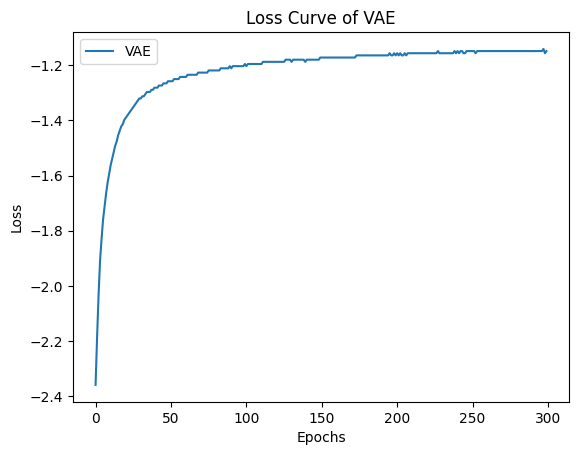

In [5]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['vae']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='VAE')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of VAE')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

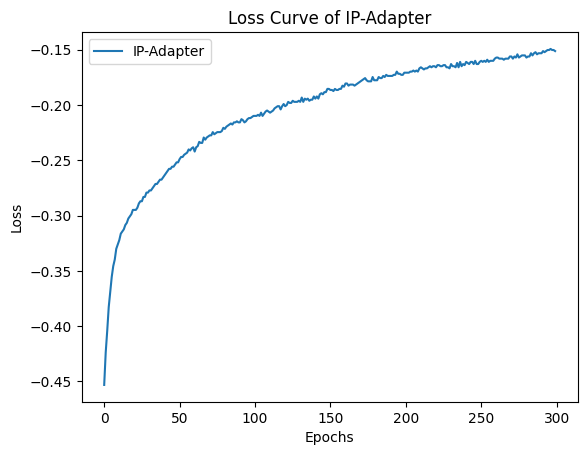

In [6]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IP-Adapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IP-Adapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## agm(VAE+CLIP)+Cosine
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae-ipadapter_yingbu_agm_cosine_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [7]:
loss_dict_list = [{'loss_sum': 0.01416015625, 'loss': 0.1328125, 'vae': -0.11865234375, 'ipadapter': 0.1328125}, {'loss_sum': 0.05078125, 'loss': 0.1474609375, 'vae': -0.0966796875, 'ipadapter': 0.1474609375}, {'loss_sum': 0.08642578125, 'loss': 0.1640625, 'vae': -0.07763671875, 'ipadapter': 0.1640625}, {'loss_sum': 0.09521484375, 'loss': 0.17578125, 'vae': -0.08056640625, 'ipadapter': 0.17578125}, {'loss_sum': 0.10693359375, 'loss': 0.189453125, 'vae': -0.08251953125, 'ipadapter': 0.189453125}, {'loss_sum': 0.1181640625, 'loss': 0.203125, 'vae': -0.0849609375, 'ipadapter': 0.203125}, {'loss_sum': 0.154296875, 'loss': -0.06494140625, 'vae': -0.06494140625, 'ipadapter': 0.2197265625}, {'loss_sum': 0.2080078125, 'loss': -0.01116881798952818, 'vae': -0.01116943359375, 'ipadapter': 0.21875}, {'loss_sum': 0.25390625, 'loss': 0.037947285920381546, 'vae': 0.03759765625, 'ipadapter': 0.216796875}, {'loss_sum': 0.298828125, 'loss': 0.08429881930351257, 'vae': 0.08056640625, 'ipadapter': 0.2177734375}, {'loss_sum': 0.3359375, 'loss': 0.12751993536949158, 'vae': 0.1171875, 'ipadapter': 0.2197265625}, {'loss_sum': 0.373046875, 'loss': 0.16222727298736572, 'vae': 0.146484375, 'ipadapter': 0.2265625}, {'loss_sum': 0.41015625, 'loss': 0.19078807532787323, 'vae': 0.171875, 'ipadapter': 0.2392578125}, {'loss_sum': 0.4453125, 'loss': 0.20647135376930237, 'vae': 0.1923828125, 'ipadapter': 0.25390625}, {'loss_sum': 0.47265625, 'loss': 0.22735342383384705, 'vae': 0.2119140625, 'ipadapter': 0.26171875}, {'loss_sum': 0.5, 'loss': 0.24416247010231018, 'vae': 0.2275390625, 'ipadapter': 0.2734375}, {'loss_sum': 0.52734375, 'loss': 0.2582972049713135, 'vae': 0.2412109375, 'ipadapter': 0.287109375}, {'loss_sum': 0.55078125, 'loss': 0.27159881591796875, 'vae': 0.251953125, 'ipadapter': 0.298828125}, {'loss_sum': 0.57421875, 'loss': 0.2852361798286438, 'vae': 0.263671875, 'ipadapter': 0.310546875}, {'loss_sum': 0.59375, 'loss': 0.2904362678527832, 'vae': 0.271484375, 'ipadapter': 0.3203125}, {'loss_sum': 0.609375, 'loss': 0.2998318672180176, 'vae': 0.279296875, 'ipadapter': 0.330078125}, {'loss_sum': 0.6328125, 'loss': 0.31065016984939575, 'vae': 0.2890625, 'ipadapter': 0.341796875}, {'loss_sum': 0.6484375, 'loss': 0.31974974274635315, 'vae': 0.296875, 'ipadapter': 0.349609375}, {'loss_sum': 0.65625, 'loss': 0.3228716552257538, 'vae': 0.30078125, 'ipadapter': 0.353515625}, {'loss_sum': 0.671875, 'loss': 0.3317354917526245, 'vae': 0.30859375, 'ipadapter': 0.36328125}, {'loss_sum': 0.6875, 'loss': 0.33941128849983215, 'vae': 0.314453125, 'ipadapter': 0.37109375}, {'loss_sum': 0.703125, 'loss': 0.34798431396484375, 'vae': 0.318359375, 'ipadapter': 0.3828125}, {'loss_sum': 0.7109375, 'loss': 0.35203132033348083, 'vae': 0.322265625, 'ipadapter': 0.38671875}, {'loss_sum': 0.72265625, 'loss': 0.35985150933265686, 'vae': 0.328125, 'ipadapter': 0.39453125}, {'loss_sum': 0.734375, 'loss': 0.36424869298934937, 'vae': 0.333984375, 'ipadapter': 0.400390625}, {'loss_sum': 0.7421875, 'loss': 0.3680267930030823, 'vae': 0.3359375, 'ipadapter': 0.408203125}, {'loss_sum': 0.75390625, 'loss': 0.38064366579055786, 'vae': 0.341796875, 'ipadapter': 0.412109375}, {'loss_sum': 0.765625, 'loss': 0.3793815076351166, 'vae': 0.34375, 'ipadapter': 0.419921875}, {'loss_sum': 0.77734375, 'loss': 0.386100709438324, 'vae': 0.34765625, 'ipadapter': 0.4296875}, {'loss_sum': 0.78515625, 'loss': 0.39113885164260864, 'vae': 0.349609375, 'ipadapter': 0.435546875}, {'loss_sum': 0.80078125, 'loss': 0.40186387300491333, 'vae': 0.35546875, 'ipadapter': 0.4453125}, {'loss_sum': 0.8046875, 'loss': 0.39679622650146484, 'vae': 0.357421875, 'ipadapter': 0.44921875}, {'loss_sum': 0.8125, 'loss': 0.399236798286438, 'vae': 0.359375, 'ipadapter': 0.453125}, {'loss_sum': 0.8203125, 'loss': 0.40271928906440735, 'vae': 0.361328125, 'ipadapter': 0.4609375}, {'loss_sum': 0.8359375, 'loss': 0.4157770276069641, 'vae': 0.365234375, 'ipadapter': 0.46875}, {'loss_sum': 0.84375, 'loss': 0.4208957552909851, 'vae': 0.369140625, 'ipadapter': 0.474609375}, {'loss_sum': 0.84375, 'loss': 0.42186659574508667, 'vae': 0.37109375, 'ipadapter': 0.474609375}, {'loss_sum': 0.8515625, 'loss': 0.42523375153541565, 'vae': 0.373046875, 'ipadapter': 0.478515625}, {'loss_sum': 0.8515625, 'loss': 0.42580729722976685, 'vae': 0.375, 'ipadapter': 0.4765625}, {'loss_sum': 0.85546875, 'loss': 0.4298696517944336, 'vae': 0.376953125, 'ipadapter': 0.478515625}, {'loss_sum': 0.8671875, 'loss': 0.4375343322753906, 'vae': 0.37890625, 'ipadapter': 0.486328125}, {'loss_sum': 0.87109375, 'loss': 0.4402084946632385, 'vae': 0.380859375, 'ipadapter': 0.490234375}, {'loss_sum': 0.875, 'loss': 0.4430100917816162, 'vae': 0.3828125, 'ipadapter': 0.4921875}, {'loss_sum': 0.8828125, 'loss': 0.4479690194129944, 'vae': 0.384765625, 'ipadapter': 0.5}, {'loss_sum': 0.890625, 'loss': 0.4477744698524475, 'vae': 0.384765625, 'ipadapter': 0.50390625}, {'loss_sum': 0.8984375, 'loss': 0.4566017985343933, 'vae': 0.388671875, 'ipadapter': 0.5078125}, {'loss_sum': 0.8984375, 'loss': 0.4506359100341797, 'vae': 0.388671875, 'ipadapter': 0.51171875}, {'loss_sum': 0.90234375, 'loss': 0.4546443819999695, 'vae': 0.38671875, 'ipadapter': 0.515625}, {'loss_sum': 0.9140625, 'loss': 0.46033281087875366, 'vae': 0.390625, 'ipadapter': 0.5234375}, {'loss_sum': 0.9140625, 'loss': 0.47516709566116333, 'vae': 0.392578125, 'ipadapter': 0.5234375}, {'loss_sum': 0.9296875, 'loss': 0.47877752780914307, 'vae': 0.396484375, 'ipadapter': 0.53125}, {'loss_sum': 0.92578125, 'loss': 0.46888262033462524, 'vae': 0.39453125, 'ipadapter': 0.53125}, {'loss_sum': 0.9296875, 'loss': 0.47140926122665405, 'vae': 0.396484375, 'ipadapter': 0.53125}, {'loss_sum': 0.9296875, 'loss': 0.4706158936023712, 'vae': 0.396484375, 'ipadapter': 0.53125}, {'loss_sum': 0.9296875, 'loss': 0.4703686833381653, 'vae': 0.396484375, 'ipadapter': 0.53515625}, {'loss_sum': 0.93359375, 'loss': 0.47552794218063354, 'vae': 0.3984375, 'ipadapter': 0.53515625}, {'loss_sum': 0.9375, 'loss': 0.4857853651046753, 'vae': 0.40234375, 'ipadapter': 0.53515625}, {'loss_sum': 0.9453125, 'loss': 0.49709635972976685, 'vae': 0.40234375, 'ipadapter': 0.54296875}, {'loss_sum': 0.953125, 'loss': 0.5023565292358398, 'vae': 0.404296875, 'ipadapter': 0.55078125}, {'loss_sum': 0.953125, 'loss': 0.5017833709716797, 'vae': 0.404296875, 'ipadapter': 0.55078125}, {'loss_sum': 0.953125, 'loss': 0.5004190802574158, 'vae': 0.40234375, 'ipadapter': 0.55078125}, {'loss_sum': 0.9609375, 'loss': 0.5103437900543213, 'vae': 0.404296875, 'ipadapter': 0.5546875}, {'loss_sum': 0.96875, 'loss': 0.5091971158981323, 'vae': 0.40625, 'ipadapter': 0.5625}, {'loss_sum': 0.96875, 'loss': 0.5011968612670898, 'vae': 0.404296875, 'ipadapter': 0.5625}, {'loss_sum': 0.96875, 'loss': 0.4978516101837158, 'vae': 0.40625, 'ipadapter': 0.5625}, {'loss_sum': 0.97265625, 'loss': 0.5098042488098145, 'vae': 0.40625, 'ipadapter': 0.56640625}, {'loss_sum': 0.9765625, 'loss': 0.5112651586532593, 'vae': 0.408203125, 'ipadapter': 0.5703125}, {'loss_sum': 0.9765625, 'loss': 0.5042740106582642, 'vae': 0.408203125, 'ipadapter': 0.5703125}, {'loss_sum': 0.984375, 'loss': 0.511284351348877, 'vae': 0.41015625, 'ipadapter': 0.57421875}, {'loss_sum': 0.984375, 'loss': 0.512234628200531, 'vae': 0.41015625, 'ipadapter': 0.57421875}, {'loss_sum': 0.9921875, 'loss': 0.5202722549438477, 'vae': 0.41015625, 'ipadapter': 0.58203125}, {'loss_sum': 0.9921875, 'loss': 0.5268021821975708, 'vae': 0.412109375, 'ipadapter': 0.58203125}, {'loss_sum': 1.0, 'loss': 0.5336439609527588, 'vae': 0.416015625, 'ipadapter': 0.58203125}, {'loss_sum': 0.99609375, 'loss': 0.5286612510681152, 'vae': 0.4140625, 'ipadapter': 0.58203125}, {'loss_sum': 1.0, 'loss': 0.5278047919273376, 'vae': 0.4140625, 'ipadapter': 0.5859375}, {'loss_sum': 0.99609375, 'loss': 0.5269299149513245, 'vae': 0.4140625, 'ipadapter': 0.58203125}, {'loss_sum': 1.0, 'loss': 0.5259027481079102, 'vae': 0.4140625, 'ipadapter': 0.5859375}, {'loss_sum': 1.0, 'loss': 0.5205753445625305, 'vae': 0.416015625, 'ipadapter': 0.5859375}, {'loss_sum': 1.0, 'loss': 0.5194903016090393, 'vae': 0.4140625, 'ipadapter': 0.5859375}, {'loss_sum': 1.0078125, 'loss': 0.5267946124076843, 'vae': 0.416015625, 'ipadapter': 0.58984375}, {'loss_sum': 1.015625, 'loss': 0.5375306010246277, 'vae': 0.41796875, 'ipadapter': 0.59765625}, {'loss_sum': 1.015625, 'loss': 0.5317831039428711, 'vae': 0.41796875, 'ipadapter': 0.59765625}, {'loss_sum': 1.015625, 'loss': 0.5435646772384644, 'vae': 0.41796875, 'ipadapter': 0.59765625}, {'loss_sum': 1.015625, 'loss': 0.5523819327354431, 'vae': 0.421875, 'ipadapter': 0.59765625}, {'loss_sum': 1.015625, 'loss': 0.5432828068733215, 'vae': 0.421875, 'ipadapter': 0.59765625}, {'loss_sum': 1.015625, 'loss': 0.5510098934173584, 'vae': 0.421875, 'ipadapter': 0.59765625}, {'loss_sum': 1.03125, 'loss': 0.5507140159606934, 'vae': 0.423828125, 'ipadapter': 0.60546875}, {'loss_sum': 1.0234375, 'loss': 0.5510464906692505, 'vae': 0.419921875, 'ipadapter': 0.60546875}, {'loss_sum': 1.0390625, 'loss': 0.5700702667236328, 'vae': 0.423828125, 'ipadapter': 0.61328125}, {'loss_sum': 1.0390625, 'loss': 0.5704768896102905, 'vae': 0.42578125, 'ipadapter': 0.61328125}, {'loss_sum': 1.0390625, 'loss': 0.5570645332336426, 'vae': 0.423828125, 'ipadapter': 0.6171875}, {'loss_sum': 1.03125, 'loss': 0.5573680996894836, 'vae': 0.421875, 'ipadapter': 0.61328125}, {'loss_sum': 1.0390625, 'loss': 0.5631083250045776, 'vae': 0.423828125, 'ipadapter': 0.6171875}, {'loss_sum': 1.046875, 'loss': 0.5657588243484497, 'vae': 0.42578125, 'ipadapter': 0.6171875}, {'loss_sum': 1.046875, 'loss': 0.5735313296318054, 'vae': 0.42578125, 'ipadapter': 0.6171875}, {'loss_sum': 1.046875, 'loss': 0.573278546333313, 'vae': 0.427734375, 'ipadapter': 0.62109375}, {'loss_sum': 1.046875, 'loss': 0.5663623809814453, 'vae': 0.423828125, 'ipadapter': 0.62109375}, {'loss_sum': 1.0546875, 'loss': 0.5688207149505615, 'vae': 0.427734375, 'ipadapter': 0.625}, {'loss_sum': 1.046875, 'loss': 0.5685201287269592, 'vae': 0.423828125, 'ipadapter': 0.62109375}, {'loss_sum': 1.0546875, 'loss': 0.576461136341095, 'vae': 0.427734375, 'ipadapter': 0.625}, {'loss_sum': 1.046875, 'loss': 0.574068546295166, 'vae': 0.427734375, 'ipadapter': 0.62109375}, {'loss_sum': 1.0546875, 'loss': 0.5736150741577148, 'vae': 0.427734375, 'ipadapter': 0.625}, {'loss_sum': 1.0546875, 'loss': 0.5771650075912476, 'vae': 0.427734375, 'ipadapter': 0.625}, {'loss_sum': 1.0625, 'loss': 0.5884289741516113, 'vae': 0.4296875, 'ipadapter': 0.6328125}, {'loss_sum': 1.0625, 'loss': 0.5894001126289368, 'vae': 0.4296875, 'ipadapter': 0.63671875}, {'loss_sum': 1.0625, 'loss': 0.5854272842407227, 'vae': 0.4296875, 'ipadapter': 0.6328125}, {'loss_sum': 1.0625, 'loss': 0.5809694528579712, 'vae': 0.427734375, 'ipadapter': 0.6328125}, {'loss_sum': 1.0625, 'loss': 0.6004828810691833, 'vae': 0.4296875, 'ipadapter': 0.63671875}, {'loss_sum': 1.078125, 'loss': 0.6057732105255127, 'vae': 0.43359375, 'ipadapter': 0.640625}, {'loss_sum': 1.078125, 'loss': 0.5979955196380615, 'vae': 0.431640625, 'ipadapter': 0.64453125}, {'loss_sum': 1.0703125, 'loss': 0.5958046913146973, 'vae': 0.427734375, 'ipadapter': 0.64453125}, {'loss_sum': 1.0703125, 'loss': 0.59671950340271, 'vae': 0.4296875, 'ipadapter': 0.640625}, {'loss_sum': 1.0703125, 'loss': 0.5970388650894165, 'vae': 0.4296875, 'ipadapter': 0.640625}, {'loss_sum': 1.078125, 'loss': 0.6053473949432373, 'vae': 0.431640625, 'ipadapter': 0.64453125}, {'loss_sum': 1.078125, 'loss': 0.6006383895874023, 'vae': 0.431640625, 'ipadapter': 0.6484375}, {'loss_sum': 1.078125, 'loss': 0.5924657583236694, 'vae': 0.4296875, 'ipadapter': 0.64453125}, {'loss_sum': 1.078125, 'loss': 0.6076744794845581, 'vae': 0.431640625, 'ipadapter': 0.64453125}, {'loss_sum': 1.0859375, 'loss': 0.6170414090156555, 'vae': 0.435546875, 'ipadapter': 0.6484375}, {'loss_sum': 1.078125, 'loss': 0.6071732044219971, 'vae': 0.43359375, 'ipadapter': 0.64453125}, {'loss_sum': 1.078125, 'loss': 0.6093835234642029, 'vae': 0.431640625, 'ipadapter': 0.64453125}, {'loss_sum': 1.078125, 'loss': 0.6081682443618774, 'vae': 0.431640625, 'ipadapter': 0.6484375}, {'loss_sum': 1.078125, 'loss': 0.6105479598045349, 'vae': 0.4296875, 'ipadapter': 0.6484375}, {'loss_sum': 1.09375, 'loss': 0.6014704704284668, 'vae': 0.43359375, 'ipadapter': 0.65625}, {'loss_sum': 1.078125, 'loss': 0.5937151908874512, 'vae': 0.42578125, 'ipadapter': 0.6484375}, {'loss_sum': 1.09375, 'loss': 0.6105040311813354, 'vae': 0.431640625, 'ipadapter': 0.66015625}, {'loss_sum': 1.078125, 'loss': 0.5933166742324829, 'vae': 0.4296875, 'ipadapter': 0.65234375}, {'loss_sum': 1.0859375, 'loss': 0.5962615609169006, 'vae': 0.4296875, 'ipadapter': 0.65625}, {'loss_sum': 1.09375, 'loss': 0.5960786938667297, 'vae': 0.4296875, 'ipadapter': 0.66015625}, {'loss_sum': 1.09375, 'loss': 0.6050221920013428, 'vae': 0.43359375, 'ipadapter': 0.65625}, {'loss_sum': 1.09375, 'loss': 0.6052191853523254, 'vae': 0.435546875, 'ipadapter': 0.65625}, {'loss_sum': 1.09375, 'loss': 0.6233205199241638, 'vae': 0.435546875, 'ipadapter': 0.65625}, {'loss_sum': 1.1015625, 'loss': 0.6303369402885437, 'vae': 0.439453125, 'ipadapter': 0.6640625}, {'loss_sum': 1.09375, 'loss': 0.6183527708053589, 'vae': 0.435546875, 'ipadapter': 0.66015625}, {'loss_sum': 1.09375, 'loss': 0.6250569224357605, 'vae': 0.435546875, 'ipadapter': 0.66015625}, {'loss_sum': 1.09375, 'loss': 0.6309017539024353, 'vae': 0.4375, 'ipadapter': 0.66015625}, {'loss_sum': 1.09375, 'loss': 0.6355314254760742, 'vae': 0.4375, 'ipadapter': 0.66015625}, {'loss_sum': 1.1015625, 'loss': 0.6381595730781555, 'vae': 0.439453125, 'ipadapter': 0.6640625}, {'loss_sum': 1.09375, 'loss': 0.6328556537628174, 'vae': 0.4375, 'ipadapter': 0.66015625}, {'loss_sum': 1.1015625, 'loss': 0.634829580783844, 'vae': 0.4375, 'ipadapter': 0.6640625}, {'loss_sum': 1.1015625, 'loss': 0.6381197571754456, 'vae': 0.435546875, 'ipadapter': 0.66796875}, {'loss_sum': 1.109375, 'loss': 0.6478700637817383, 'vae': 0.4375, 'ipadapter': 0.66796875}, {'loss_sum': 1.109375, 'loss': 0.6452533602714539, 'vae': 0.439453125, 'ipadapter': 0.66796875}, {'loss_sum': 1.109375, 'loss': 0.6422451734542847, 'vae': 0.4375, 'ipadapter': 0.671875}, {'loss_sum': 1.1015625, 'loss': 0.6420080661773682, 'vae': 0.435546875, 'ipadapter': 0.66796875}, {'loss_sum': 1.109375, 'loss': 0.6460793614387512, 'vae': 0.4375, 'ipadapter': 0.671875}, {'loss_sum': 1.1015625, 'loss': 0.6421982049942017, 'vae': 0.435546875, 'ipadapter': 0.66796875}, {'loss_sum': 1.1015625, 'loss': 0.6441041231155396, 'vae': 0.435546875, 'ipadapter': 0.66796875}, {'loss_sum': 1.1015625, 'loss': 0.6407214403152466, 'vae': 0.435546875, 'ipadapter': 0.66796875}, {'loss_sum': 1.109375, 'loss': 0.6455870270729065, 'vae': 0.435546875, 'ipadapter': 0.671875}, {'loss_sum': 1.109375, 'loss': 0.6529170274734497, 'vae': 0.435546875, 'ipadapter': 0.67578125}, {'loss_sum': 1.109375, 'loss': 0.651761531829834, 'vae': 0.435546875, 'ipadapter': 0.671875}, {'loss_sum': 1.109375, 'loss': 0.6517217755317688, 'vae': 0.4375, 'ipadapter': 0.67578125}, {'loss_sum': 1.109375, 'loss': 0.6537759304046631, 'vae': 0.43359375, 'ipadapter': 0.67578125}, {'loss_sum': 1.1171875, 'loss': 0.6598405838012695, 'vae': 0.4375, 'ipadapter': 0.6796875}, {'loss_sum': 1.109375, 'loss': 0.6464545726776123, 'vae': 0.43359375, 'ipadapter': 0.67578125}, {'loss_sum': 1.109375, 'loss': 0.6496393084526062, 'vae': 0.431640625, 'ipadapter': 0.67578125}, {'loss_sum': 1.1171875, 'loss': 0.6536688804626465, 'vae': 0.435546875, 'ipadapter': 0.6796875}, {'loss_sum': 1.109375, 'loss': 0.6443528532981873, 'vae': 0.43359375, 'ipadapter': 0.671875}, {'loss_sum': 1.109375, 'loss': 0.6571606993675232, 'vae': 0.435546875, 'ipadapter': 0.67578125}, {'loss_sum': 1.1171875, 'loss': 0.6597216725349426, 'vae': 0.4375, 'ipadapter': 0.6796875}, {'loss_sum': 1.109375, 'loss': 0.6609999537467957, 'vae': 0.4375, 'ipadapter': 0.67578125}, {'loss_sum': 1.1171875, 'loss': 0.6639337539672852, 'vae': 0.4375, 'ipadapter': 0.6796875}, {'loss_sum': 1.109375, 'loss': 0.6559224128723145, 'vae': 0.431640625, 'ipadapter': 0.67578125}, {'loss_sum': 1.109375, 'loss': 0.6566382646560669, 'vae': 0.431640625, 'ipadapter': 0.67578125}, {'loss_sum': 1.109375, 'loss': 0.6575074195861816, 'vae': 0.435546875, 'ipadapter': 0.671875}, {'loss_sum': 1.109375, 'loss': 0.6603845357894897, 'vae': 0.43359375, 'ipadapter': 0.6796875}, {'loss_sum': 1.109375, 'loss': 0.660736620426178, 'vae': 0.43359375, 'ipadapter': 0.67578125}, {'loss_sum': 1.109375, 'loss': 0.6615999937057495, 'vae': 0.43359375, 'ipadapter': 0.67578125}, {'loss_sum': 1.109375, 'loss': 0.6672683358192444, 'vae': 0.43359375, 'ipadapter': 0.6796875}, {'loss_sum': 1.1171875, 'loss': 0.6673669219017029, 'vae': 0.435546875, 'ipadapter': 0.6796875}, {'loss_sum': 1.109375, 'loss': 0.6665245890617371, 'vae': 0.43359375, 'ipadapter': 0.6796875}, {'loss_sum': 1.1171875, 'loss': 0.6701174974441528, 'vae': 0.431640625, 'ipadapter': 0.68359375}, {'loss_sum': 1.1171875, 'loss': 0.6736325621604919, 'vae': 0.431640625, 'ipadapter': 0.6875}, {'loss_sum': 1.1171875, 'loss': 0.6739049553871155, 'vae': 0.431640625, 'ipadapter': 0.6875}, {'loss_sum': 1.109375, 'loss': 0.6713932156562805, 'vae': 0.4296875, 'ipadapter': 0.68359375}, {'loss_sum': 1.109375, 'loss': 0.6674922108650208, 'vae': 0.427734375, 'ipadapter': 0.68359375}, {'loss_sum': 1.109375, 'loss': 0.6635736227035522, 'vae': 0.427734375, 'ipadapter': 0.6796875}, {'loss_sum': 1.1171875, 'loss': 0.6732062101364136, 'vae': 0.4296875, 'ipadapter': 0.6875}, {'loss_sum': 1.109375, 'loss': 0.6715619564056396, 'vae': 0.427734375, 'ipadapter': 0.68359375}, {'loss_sum': 1.109375, 'loss': 0.6692115068435669, 'vae': 0.4296875, 'ipadapter': 0.68359375}, {'loss_sum': 1.109375, 'loss': 0.6702525019645691, 'vae': 0.427734375, 'ipadapter': 0.68359375}, {'loss_sum': 1.125, 'loss': 0.6781404614448547, 'vae': 0.4296875, 'ipadapter': 0.69140625}, {'loss_sum': 1.1171875, 'loss': 0.6750084161758423, 'vae': 0.4296875, 'ipadapter': 0.6875}, {'loss_sum': 1.1171875, 'loss': 0.6770138144493103, 'vae': 0.427734375, 'ipadapter': 0.6875}, {'loss_sum': 1.125, 'loss': 0.6816093921661377, 'vae': 0.4296875, 'ipadapter': 0.69140625}, {'loss_sum': 1.1171875, 'loss': 0.677628219127655, 'vae': 0.423828125, 'ipadapter': 0.69140625}, {'loss_sum': 1.125, 'loss': 0.6796365976333618, 'vae': 0.42578125, 'ipadapter': 0.6953125}, {'loss_sum': 1.109375, 'loss': 0.676960289478302, 'vae': 0.421875, 'ipadapter': 0.69140625}, {'loss_sum': 1.125, 'loss': 0.6826234459877014, 'vae': 0.42578125, 'ipadapter': 0.6953125}, {'loss_sum': 1.125, 'loss': 0.6849392652511597, 'vae': 0.42578125, 'ipadapter': 0.69921875}, {'loss_sum': 1.125, 'loss': 0.6858973503112793, 'vae': 0.42578125, 'ipadapter': 0.69921875}, {'loss_sum': 1.1171875, 'loss': 0.683716356754303, 'vae': 0.423828125, 'ipadapter': 0.6953125}, {'loss_sum': 1.125, 'loss': 0.6908141374588013, 'vae': 0.42578125, 'ipadapter': 0.703125}, {'loss_sum': 1.1171875, 'loss': 0.6822769045829773, 'vae': 0.423828125, 'ipadapter': 0.6953125}, {'loss_sum': 1.125, 'loss': 0.6874669194221497, 'vae': 0.42578125, 'ipadapter': 0.69921875}, {'loss_sum': 1.125, 'loss': 0.6881676912307739, 'vae': 0.42578125, 'ipadapter': 0.69921875}, {'loss_sum': 1.125, 'loss': 0.6921477913856506, 'vae': 0.423828125, 'ipadapter': 0.703125}, {'loss_sum': 1.1171875, 'loss': 0.6848441958427429, 'vae': 0.421875, 'ipadapter': 0.6953125}, {'loss_sum': 1.125, 'loss': 0.691006064414978, 'vae': 0.42578125, 'ipadapter': 0.69921875}, {'loss_sum': 1.125, 'loss': 0.6886717081069946, 'vae': 0.423828125, 'ipadapter': 0.69921875}, {'loss_sum': 1.1171875, 'loss': 0.6870657205581665, 'vae': 0.421875, 'ipadapter': 0.6953125}, {'loss_sum': 1.125, 'loss': 0.6905904412269592, 'vae': 0.421875, 'ipadapter': 0.69921875}, {'loss_sum': 1.125, 'loss': 0.6928876042366028, 'vae': 0.419921875, 'ipadapter': 0.703125}, {'loss_sum': 1.125, 'loss': 0.6906473636627197, 'vae': 0.41796875, 'ipadapter': 0.703125}, {'loss_sum': 1.1171875, 'loss': 0.6883687376976013, 'vae': 0.41796875, 'ipadapter': 0.69921875}, {'loss_sum': 1.125, 'loss': 0.6948909163475037, 'vae': 0.419921875, 'ipadapter': 0.70703125}, {'loss_sum': 1.1171875, 'loss': 0.6861456632614136, 'vae': 0.416015625, 'ipadapter': 0.69921875}, {'loss_sum': 1.125, 'loss': 0.6990488171577454, 'vae': 0.41796875, 'ipadapter': 0.70703125}, {'loss_sum': 1.1328125, 'loss': 0.7039116621017456, 'vae': 0.423828125, 'ipadapter': 0.7109375}, {'loss_sum': 1.1328125, 'loss': 0.7010954022407532, 'vae': 0.419921875, 'ipadapter': 0.7109375}, {'loss_sum': 1.125, 'loss': 0.6974142789840698, 'vae': 0.41796875, 'ipadapter': 0.7109375}, {'loss_sum': 1.1171875, 'loss': 0.6956108808517456, 'vae': 0.412109375, 'ipadapter': 0.70703125}, {'loss_sum': 1.125, 'loss': 0.7032231092453003, 'vae': 0.41796875, 'ipadapter': 0.7109375}, {'loss_sum': 1.1328125, 'loss': 0.7046142816543579, 'vae': 0.419921875, 'ipadapter': 0.71484375}, {'loss_sum': 1.1328125, 'loss': 0.7045465111732483, 'vae': 0.41796875, 'ipadapter': 0.71484375}, {'loss_sum': 1.1328125, 'loss': 0.7086288332939148, 'vae': 0.416015625, 'ipadapter': 0.71875}, {'loss_sum': 1.1328125, 'loss': 0.7064915299415588, 'vae': 0.41796875, 'ipadapter': 0.71484375}, {'loss_sum': 1.140625, 'loss': 0.7129271030426025, 'vae': 0.41796875, 'ipadapter': 0.71875}, {'loss_sum': 1.140625, 'loss': 0.7132405638694763, 'vae': 0.419921875, 'ipadapter': 0.71875}, {'loss_sum': 1.125, 'loss': 0.7055808901786804, 'vae': 0.408203125, 'ipadapter': 0.71484375}, {'loss_sum': 1.125, 'loss': 0.7044272422790527, 'vae': 0.4140625, 'ipadapter': 0.71484375}, {'loss_sum': 1.125, 'loss': 0.703015148639679, 'vae': 0.4140625, 'ipadapter': 0.7109375}, {'loss_sum': 1.1328125, 'loss': 0.7080038785934448, 'vae': 0.416015625, 'ipadapter': 0.71484375}, {'loss_sum': 1.125, 'loss': 0.7071344256401062, 'vae': 0.4140625, 'ipadapter': 0.71484375}, {'loss_sum': 1.1328125, 'loss': 0.7071300148963928, 'vae': 0.416015625, 'ipadapter': 0.71484375}, {'loss_sum': 1.125, 'loss': 0.7062239646911621, 'vae': 0.4140625, 'ipadapter': 0.71484375}, {'loss_sum': 1.125, 'loss': 0.7083436250686646, 'vae': 0.412109375, 'ipadapter': 0.71484375}, {'loss_sum': 1.125, 'loss': 0.7054582834243774, 'vae': 0.412109375, 'ipadapter': 0.71484375}, {'loss_sum': 1.125, 'loss': 0.709923267364502, 'vae': 0.408203125, 'ipadapter': 0.71875}, {'loss_sum': 1.125, 'loss': 0.7074176669120789, 'vae': 0.4140625, 'ipadapter': 0.71484375}, {'loss_sum': 1.125, 'loss': 0.7084481716156006, 'vae': 0.412109375, 'ipadapter': 0.71484375}, {'loss_sum': 1.1328125, 'loss': 0.7160953879356384, 'vae': 0.412109375, 'ipadapter': 0.72265625}, {'loss_sum': 1.125, 'loss': 0.7075177431106567, 'vae': 0.41015625, 'ipadapter': 0.71484375}, {'loss_sum': 1.1328125, 'loss': 0.7157213687896729, 'vae': 0.41015625, 'ipadapter': 0.72265625}, {'loss_sum': 1.125, 'loss': 0.7110320329666138, 'vae': 0.41015625, 'ipadapter': 0.71875}, {'loss_sum': 1.125, 'loss': 0.7061603665351868, 'vae': 0.408203125, 'ipadapter': 0.71484375}, {'loss_sum': 1.1328125, 'loss': 0.7168641090393066, 'vae': 0.408203125, 'ipadapter': 0.72265625}, {'loss_sum': 1.140625, 'loss': 0.7200564742088318, 'vae': 0.412109375, 'ipadapter': 0.7265625}, {'loss_sum': 1.140625, 'loss': 0.7236748933792114, 'vae': 0.408203125, 'ipadapter': 0.73046875}, {'loss_sum': 1.1328125, 'loss': 0.7165064811706543, 'vae': 0.408203125, 'ipadapter': 0.72265625}, {'loss_sum': 1.1328125, 'loss': 0.7205600142478943, 'vae': 0.408203125, 'ipadapter': 0.7265625}, {'loss_sum': 1.1328125, 'loss': 0.7202913165092468, 'vae': 0.408203125, 'ipadapter': 0.7265625}, {'loss_sum': 1.125, 'loss': 0.7152014970779419, 'vae': 0.404296875, 'ipadapter': 0.72265625}, {'loss_sum': 1.125, 'loss': 0.7150191068649292, 'vae': 0.404296875, 'ipadapter': 0.72265625}, {'loss_sum': 1.125, 'loss': 0.7127969264984131, 'vae': 0.40234375, 'ipadapter': 0.71875}, {'loss_sum': 1.1328125, 'loss': 0.720325767993927, 'vae': 0.404296875, 'ipadapter': 0.7265625}, {'loss_sum': 1.125, 'loss': 0.7167326807975769, 'vae': 0.404296875, 'ipadapter': 0.72265625}, {'loss_sum': 1.1328125, 'loss': 0.721202552318573, 'vae': 0.404296875, 'ipadapter': 0.7265625}, {'loss_sum': 1.1328125, 'loss': 0.7214879989624023, 'vae': 0.40625, 'ipadapter': 0.7265625}, {'loss_sum': 1.140625, 'loss': 0.7285985350608826, 'vae': 0.40625, 'ipadapter': 0.734375}, {'loss_sum': 1.125, 'loss': 0.7209640145301819, 'vae': 0.40234375, 'ipadapter': 0.7265625}, {'loss_sum': 1.125, 'loss': 0.7193419933319092, 'vae': 0.40234375, 'ipadapter': 0.7265625}, {'loss_sum': 1.125, 'loss': 0.7193800210952759, 'vae': 0.3984375, 'ipadapter': 0.7265625}, {'loss_sum': 1.125, 'loss': 0.7230381369590759, 'vae': 0.40234375, 'ipadapter': 0.7265625}, {'loss_sum': 1.1328125, 'loss': 0.7251767516136169, 'vae': 0.404296875, 'ipadapter': 0.73046875}, {'loss_sum': 1.1328125, 'loss': 0.7272219061851501, 'vae': 0.40234375, 'ipadapter': 0.73046875}, {'loss_sum': 1.125, 'loss': 0.7168406844139099, 'vae': 0.3984375, 'ipadapter': 0.72265625}, {'loss_sum': 1.1171875, 'loss': 0.7130553722381592, 'vae': 0.3984375, 'ipadapter': 0.71875}, {'loss_sum': 1.125, 'loss': 0.724351167678833, 'vae': 0.396484375, 'ipadapter': 0.73046875}, {'loss_sum': 1.125, 'loss': 0.7206365466117859, 'vae': 0.396484375, 'ipadapter': 0.7265625}, {'loss_sum': 1.1328125, 'loss': 0.7289196848869324, 'vae': 0.396484375, 'ipadapter': 0.734375}, {'loss_sum': 1.1328125, 'loss': 0.7289512157440186, 'vae': 0.3984375, 'ipadapter': 0.734375}, {'loss_sum': 1.125, 'loss': 0.7259390950202942, 'vae': 0.396484375, 'ipadapter': 0.73046875}, {'loss_sum': 1.125, 'loss': 0.7237771153450012, 'vae': 0.3984375, 'ipadapter': 0.73046875}, {'loss_sum': 1.125, 'loss': 0.7255120277404785, 'vae': 0.396484375, 'ipadapter': 0.73046875}, {'loss_sum': 1.125, 'loss': 0.724888265132904, 'vae': 0.39453125, 'ipadapter': 0.73046875}, {'loss_sum': 1.125, 'loss': 0.7296488285064697, 'vae': 0.39453125, 'ipadapter': 0.734375}, {'loss_sum': 1.125, 'loss': 0.7257193326950073, 'vae': 0.396484375, 'ipadapter': 0.73046875}, {'loss_sum': 1.125, 'loss': 0.7221091985702515, 'vae': 0.39453125, 'ipadapter': 0.7265625}, {'loss_sum': 1.125, 'loss': 0.72629314661026, 'vae': 0.396484375, 'ipadapter': 0.73046875}, {'loss_sum': 1.125, 'loss': 0.725675642490387, 'vae': 0.392578125, 'ipadapter': 0.73046875}, {'loss_sum': 1.125, 'loss': 0.7295070886611938, 'vae': 0.39453125, 'ipadapter': 0.734375}, {'loss_sum': 1.125, 'loss': 0.7297232747077942, 'vae': 0.392578125, 'ipadapter': 0.734375}, {'loss_sum': 1.1328125, 'loss': 0.7339023947715759, 'vae': 0.392578125, 'ipadapter': 0.73828125}, {'loss_sum': 1.125, 'loss': 0.7287935614585876, 'vae': 0.390625, 'ipadapter': 0.734375}, {'loss_sum': 1.125, 'loss': 0.7257835268974304, 'vae': 0.390625, 'ipadapter': 0.73046875}, {'loss_sum': 1.125, 'loss': 0.7252525687217712, 'vae': 0.390625, 'ipadapter': 0.73046875}, {'loss_sum': 1.125, 'loss': 0.7322791218757629, 'vae': 0.390625, 'ipadapter': 0.73828125}, {'loss_sum': 1.125, 'loss': 0.7280246615409851, 'vae': 0.388671875, 'ipadapter': 0.734375}, {'loss_sum': 1.125, 'loss': 0.7324711680412292, 'vae': 0.388671875, 'ipadapter': 0.73828125}, {'loss_sum': 1.125, 'loss': 0.7250087857246399, 'vae': 0.390625, 'ipadapter': 0.73046875}, {'loss_sum': 1.1328125, 'loss': 0.7379958629608154, 'vae': 0.392578125, 'ipadapter': 0.7421875}, {'loss_sum': 1.1171875, 'loss': 0.7232875823974609, 'vae': 0.388671875, 'ipadapter': 0.73046875}, {'loss_sum': 1.125, 'loss': 0.7330487370491028, 'vae': 0.390625, 'ipadapter': 0.73828125}, {'loss_sum': 1.125, 'loss': 0.7295673489570618, 'vae': 0.388671875, 'ipadapter': 0.734375}, {'loss_sum': 1.125, 'loss': 0.7339783310890198, 'vae': 0.390625, 'ipadapter': 0.73828125}, {'loss_sum': 1.125, 'loss': 0.731913685798645, 'vae': 0.390625, 'ipadapter': 0.734375}, {'loss_sum': 1.1328125, 'loss': 0.7356940507888794, 'vae': 0.392578125, 'ipadapter': 0.73828125}, {'loss_sum': 1.125, 'loss': 0.7347621917724609, 'vae': 0.390625, 'ipadapter': 0.73828125}, {'loss_sum': 1.1171875, 'loss': 0.7308545708656311, 'vae': 0.384765625, 'ipadapter': 0.734375}, {'loss_sum': 1.125, 'loss': 0.7337637543678284, 'vae': 0.38671875, 'ipadapter': 0.73828125}, {'loss_sum': 1.125, 'loss': 0.7315202951431274, 'vae': 0.38671875, 'ipadapter': 0.734375}, {'loss_sum': 1.125, 'loss': 0.7334995865821838, 'vae': 0.38671875, 'ipadapter': 0.73828125}, {'loss_sum': 1.125, 'loss': 0.7342594861984253, 'vae': 0.3828125, 'ipadapter': 0.73828125}, {'loss_sum': 1.125, 'loss': 0.7335763573646545, 'vae': 0.384765625, 'ipadapter': 0.73828125}]


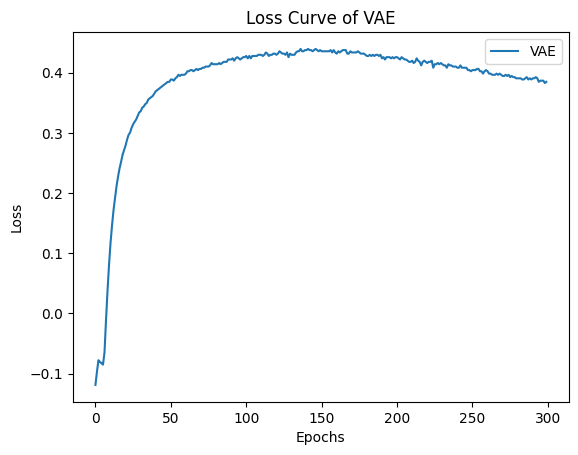

In [8]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['vae']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='VAE')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of VAE')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

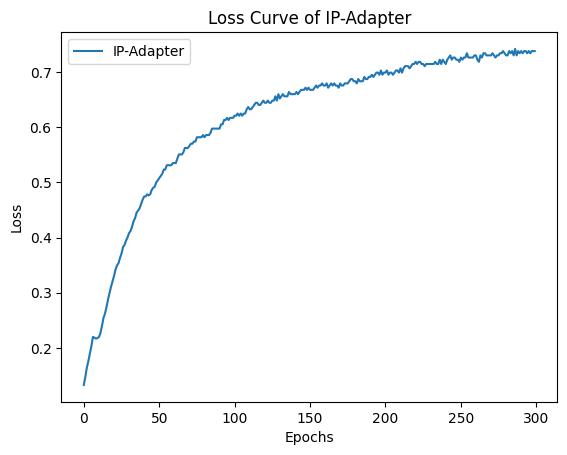

In [9]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IP-Adapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IP-Adapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## (1*VAE+1*CLIP)+Cosine
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_vae-ipadapter_yingbu_no-agm-w1-0-w2-1-w3-1-w4-0_cosine_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [10]:
loss_dict_list = [{'loss_sum': 0.01416015625, 'loss': 0.01416015625, 'vae': -0.11865234375, 'ipadapter': 0.1328125}, {'loss_sum': 0.07373046875, 'loss': 0.07373046875, 'vae': -0.07177734375, 'ipadapter': 0.1455078125}, {'loss_sum': 0.1337890625, 'loss': 0.1337890625, 'vae': -0.025634765625, 'ipadapter': 0.1591796875}, {'loss_sum': 0.193359375, 'loss': 0.193359375, 'vae': 0.016357421875, 'ipadapter': 0.1767578125}, {'loss_sum': 0.2373046875, 'loss': 0.2373046875, 'vae': 0.05078125, 'ipadapter': 0.1865234375}, {'loss_sum': 0.2890625, 'loss': 0.2890625, 'vae': 0.08203125, 'ipadapter': 0.2060546875}, {'loss_sum': 0.328125, 'loss': 0.328125, 'vae': 0.109375, 'ipadapter': 0.2197265625}, {'loss_sum': 0.36328125, 'loss': 0.36328125, 'vae': 0.130859375, 'ipadapter': 0.2314453125}, {'loss_sum': 0.39453125, 'loss': 0.39453125, 'vae': 0.150390625, 'ipadapter': 0.2431640625}, {'loss_sum': 0.42578125, 'loss': 0.42578125, 'vae': 0.1689453125, 'ipadapter': 0.255859375}, {'loss_sum': 0.45703125, 'loss': 0.45703125, 'vae': 0.185546875, 'ipadapter': 0.271484375}, {'loss_sum': 0.484375, 'loss': 0.484375, 'vae': 0.2001953125, 'ipadapter': 0.28515625}, {'loss_sum': 0.5078125, 'loss': 0.5078125, 'vae': 0.212890625, 'ipadapter': 0.296875}, {'loss_sum': 0.53515625, 'loss': 0.53515625, 'vae': 0.2255859375, 'ipadapter': 0.30859375}, {'loss_sum': 0.55859375, 'loss': 0.55859375, 'vae': 0.2373046875, 'ipadapter': 0.322265625}, {'loss_sum': 0.578125, 'loss': 0.578125, 'vae': 0.248046875, 'ipadapter': 0.330078125}, {'loss_sum': 0.6015625, 'loss': 0.6015625, 'vae': 0.2578125, 'ipadapter': 0.345703125}, {'loss_sum': 0.625, 'loss': 0.625, 'vae': 0.267578125, 'ipadapter': 0.357421875}, {'loss_sum': 0.64453125, 'loss': 0.64453125, 'vae': 0.275390625, 'ipadapter': 0.369140625}, {'loss_sum': 0.65234375, 'loss': 0.65234375, 'vae': 0.283203125, 'ipadapter': 0.369140625}, {'loss_sum': 0.6640625, 'loss': 0.6640625, 'vae': 0.2890625, 'ipadapter': 0.376953125}, {'loss_sum': 0.68359375, 'loss': 0.68359375, 'vae': 0.296875, 'ipadapter': 0.38671875}, {'loss_sum': 0.6953125, 'loss': 0.6953125, 'vae': 0.30078125, 'ipadapter': 0.392578125}, {'loss_sum': 0.703125, 'loss': 0.703125, 'vae': 0.306640625, 'ipadapter': 0.3984375}, {'loss_sum': 0.71875, 'loss': 0.71875, 'vae': 0.3125, 'ipadapter': 0.40625}, {'loss_sum': 0.734375, 'loss': 0.734375, 'vae': 0.318359375, 'ipadapter': 0.4140625}, {'loss_sum': 0.7421875, 'loss': 0.7421875, 'vae': 0.3203125, 'ipadapter': 0.421875}, {'loss_sum': 0.7421875, 'loss': 0.7421875, 'vae': 0.32421875, 'ipadapter': 0.419921875}, {'loss_sum': 0.7578125, 'loss': 0.7578125, 'vae': 0.330078125, 'ipadapter': 0.427734375}, {'loss_sum': 0.7734375, 'loss': 0.7734375, 'vae': 0.3359375, 'ipadapter': 0.435546875}, {'loss_sum': 0.78125, 'loss': 0.78125, 'vae': 0.337890625, 'ipadapter': 0.443359375}, {'loss_sum': 0.78125, 'loss': 0.78125, 'vae': 0.33984375, 'ipadapter': 0.443359375}, {'loss_sum': 0.796875, 'loss': 0.796875, 'vae': 0.34375, 'ipadapter': 0.453125}, {'loss_sum': 0.8046875, 'loss': 0.8046875, 'vae': 0.34765625, 'ipadapter': 0.45703125}, {'loss_sum': 0.796875, 'loss': 0.796875, 'vae': 0.349609375, 'ipadapter': 0.44921875}, {'loss_sum': 0.81640625, 'loss': 0.81640625, 'vae': 0.353515625, 'ipadapter': 0.462890625}, {'loss_sum': 0.82421875, 'loss': 0.82421875, 'vae': 0.35546875, 'ipadapter': 0.46875}, {'loss_sum': 0.83984375, 'loss': 0.83984375, 'vae': 0.357421875, 'ipadapter': 0.482421875}, {'loss_sum': 0.84375, 'loss': 0.84375, 'vae': 0.361328125, 'ipadapter': 0.482421875}, {'loss_sum': 0.84765625, 'loss': 0.84765625, 'vae': 0.36328125, 'ipadapter': 0.484375}, {'loss_sum': 0.85546875, 'loss': 0.85546875, 'vae': 0.365234375, 'ipadapter': 0.490234375}, {'loss_sum': 0.86328125, 'loss': 0.86328125, 'vae': 0.369140625, 'ipadapter': 0.494140625}, {'loss_sum': 0.8671875, 'loss': 0.8671875, 'vae': 0.369140625, 'ipadapter': 0.5}, {'loss_sum': 0.875, 'loss': 0.875, 'vae': 0.37109375, 'ipadapter': 0.50390625}, {'loss_sum': 0.87890625, 'loss': 0.87890625, 'vae': 0.37109375, 'ipadapter': 0.5078125}, {'loss_sum': 0.88671875, 'loss': 0.88671875, 'vae': 0.375, 'ipadapter': 0.51171875}, {'loss_sum': 0.890625, 'loss': 0.890625, 'vae': 0.376953125, 'ipadapter': 0.51171875}, {'loss_sum': 0.8984375, 'loss': 0.8984375, 'vae': 0.380859375, 'ipadapter': 0.515625}, {'loss_sum': 0.90234375, 'loss': 0.90234375, 'vae': 0.37890625, 'ipadapter': 0.5234375}, {'loss_sum': 0.90625, 'loss': 0.90625, 'vae': 0.3828125, 'ipadapter': 0.5234375}, {'loss_sum': 0.90625, 'loss': 0.90625, 'vae': 0.384765625, 'ipadapter': 0.5234375}, {'loss_sum': 0.91015625, 'loss': 0.91015625, 'vae': 0.38671875, 'ipadapter': 0.5234375}, {'loss_sum': 0.9140625, 'loss': 0.9140625, 'vae': 0.388671875, 'ipadapter': 0.5234375}, {'loss_sum': 0.9140625, 'loss': 0.9140625, 'vae': 0.388671875, 'ipadapter': 0.52734375}, {'loss_sum': 0.9296875, 'loss': 0.9296875, 'vae': 0.388671875, 'ipadapter': 0.5390625}, {'loss_sum': 0.9296875, 'loss': 0.9296875, 'vae': 0.392578125, 'ipadapter': 0.5390625}, {'loss_sum': 0.9375, 'loss': 0.9375, 'vae': 0.390625, 'ipadapter': 0.546875}, {'loss_sum': 0.94140625, 'loss': 0.94140625, 'vae': 0.39453125, 'ipadapter': 0.546875}, {'loss_sum': 0.94140625, 'loss': 0.94140625, 'vae': 0.39453125, 'ipadapter': 0.546875}, {'loss_sum': 0.9453125, 'loss': 0.9453125, 'vae': 0.3984375, 'ipadapter': 0.546875}, {'loss_sum': 0.94921875, 'loss': 0.94921875, 'vae': 0.3984375, 'ipadapter': 0.55078125}, {'loss_sum': 0.953125, 'loss': 0.953125, 'vae': 0.400390625, 'ipadapter': 0.5546875}, {'loss_sum': 0.9609375, 'loss': 0.9609375, 'vae': 0.400390625, 'ipadapter': 0.55859375}, {'loss_sum': 0.9609375, 'loss': 0.9609375, 'vae': 0.40234375, 'ipadapter': 0.55859375}, {'loss_sum': 0.97265625, 'loss': 0.97265625, 'vae': 0.40625, 'ipadapter': 0.56640625}, {'loss_sum': 0.96875, 'loss': 0.96875, 'vae': 0.404296875, 'ipadapter': 0.5625}, {'loss_sum': 0.96484375, 'loss': 0.96484375, 'vae': 0.40234375, 'ipadapter': 0.5625}, {'loss_sum': 0.97265625, 'loss': 0.97265625, 'vae': 0.40625, 'ipadapter': 0.56640625}, {'loss_sum': 0.9765625, 'loss': 0.9765625, 'vae': 0.408203125, 'ipadapter': 0.56640625}, {'loss_sum': 0.984375, 'loss': 0.984375, 'vae': 0.408203125, 'ipadapter': 0.57421875}, {'loss_sum': 0.9765625, 'loss': 0.9765625, 'vae': 0.408203125, 'ipadapter': 0.5703125}, {'loss_sum': 0.984375, 'loss': 0.984375, 'vae': 0.41015625, 'ipadapter': 0.57421875}, {'loss_sum': 0.9921875, 'loss': 0.9921875, 'vae': 0.412109375, 'ipadapter': 0.58203125}, {'loss_sum': 0.9921875, 'loss': 0.9921875, 'vae': 0.41015625, 'ipadapter': 0.58203125}, {'loss_sum': 1.0, 'loss': 1.0, 'vae': 0.4140625, 'ipadapter': 0.5859375}, {'loss_sum': 1.0, 'loss': 1.0, 'vae': 0.4140625, 'ipadapter': 0.5859375}, {'loss_sum': 1.0, 'loss': 1.0, 'vae': 0.416015625, 'ipadapter': 0.5859375}, {'loss_sum': 1.0078125, 'loss': 1.0078125, 'vae': 0.416015625, 'ipadapter': 0.58984375}, {'loss_sum': 1.015625, 'loss': 1.015625, 'vae': 0.419921875, 'ipadapter': 0.59375}, {'loss_sum': 1.015625, 'loss': 1.015625, 'vae': 0.419921875, 'ipadapter': 0.59375}, {'loss_sum': 1.015625, 'loss': 1.015625, 'vae': 0.41796875, 'ipadapter': 0.59765625}, {'loss_sum': 1.015625, 'loss': 1.015625, 'vae': 0.421875, 'ipadapter': 0.59765625}, {'loss_sum': 1.015625, 'loss': 1.015625, 'vae': 0.423828125, 'ipadapter': 0.58984375}, {'loss_sum': 1.015625, 'loss': 1.015625, 'vae': 0.421875, 'ipadapter': 0.59375}, {'loss_sum': 1.015625, 'loss': 1.015625, 'vae': 0.42578125, 'ipadapter': 0.59375}, {'loss_sum': 1.0234375, 'loss': 1.0234375, 'vae': 0.42578125, 'ipadapter': 0.59765625}, {'loss_sum': 1.0234375, 'loss': 1.0234375, 'vae': 0.42578125, 'ipadapter': 0.59765625}, {'loss_sum': 1.03125, 'loss': 1.03125, 'vae': 0.42578125, 'ipadapter': 0.60546875}, {'loss_sum': 1.03125, 'loss': 1.03125, 'vae': 0.427734375, 'ipadapter': 0.60546875}, {'loss_sum': 1.03125, 'loss': 1.03125, 'vae': 0.427734375, 'ipadapter': 0.60546875}, {'loss_sum': 1.0390625, 'loss': 1.0390625, 'vae': 0.427734375, 'ipadapter': 0.609375}, {'loss_sum': 1.046875, 'loss': 1.046875, 'vae': 0.4296875, 'ipadapter': 0.61328125}, {'loss_sum': 1.046875, 'loss': 1.046875, 'vae': 0.4296875, 'ipadapter': 0.61328125}, {'loss_sum': 1.046875, 'loss': 1.046875, 'vae': 0.431640625, 'ipadapter': 0.61328125}, {'loss_sum': 1.046875, 'loss': 1.046875, 'vae': 0.43359375, 'ipadapter': 0.61328125}, {'loss_sum': 1.046875, 'loss': 1.046875, 'vae': 0.431640625, 'ipadapter': 0.6171875}, {'loss_sum': 1.0625, 'loss': 1.0625, 'vae': 0.43359375, 'ipadapter': 0.625}, {'loss_sum': 1.046875, 'loss': 1.046875, 'vae': 0.43359375, 'ipadapter': 0.6171875}, {'loss_sum': 1.046875, 'loss': 1.046875, 'vae': 0.43359375, 'ipadapter': 0.6171875}, {'loss_sum': 1.0546875, 'loss': 1.0546875, 'vae': 0.435546875, 'ipadapter': 0.6171875}, {'loss_sum': 1.0546875, 'loss': 1.0546875, 'vae': 0.435546875, 'ipadapter': 0.6171875}, {'loss_sum': 1.0546875, 'loss': 1.0546875, 'vae': 0.4375, 'ipadapter': 0.6171875}, {'loss_sum': 1.0625, 'loss': 1.0625, 'vae': 0.439453125, 'ipadapter': 0.62109375}, {'loss_sum': 1.0546875, 'loss': 1.0546875, 'vae': 0.4375, 'ipadapter': 0.6171875}, {'loss_sum': 1.0625, 'loss': 1.0625, 'vae': 0.439453125, 'ipadapter': 0.625}, {'loss_sum': 1.0625, 'loss': 1.0625, 'vae': 0.44140625, 'ipadapter': 0.625}, {'loss_sum': 1.0625, 'loss': 1.0625, 'vae': 0.439453125, 'ipadapter': 0.625}, {'loss_sum': 1.0703125, 'loss': 1.0703125, 'vae': 0.439453125, 'ipadapter': 0.62890625}, {'loss_sum': 1.078125, 'loss': 1.078125, 'vae': 0.443359375, 'ipadapter': 0.6328125}, {'loss_sum': 1.0703125, 'loss': 1.0703125, 'vae': 0.443359375, 'ipadapter': 0.62890625}, {'loss_sum': 1.078125, 'loss': 1.078125, 'vae': 0.44140625, 'ipadapter': 0.6328125}, {'loss_sum': 1.0703125, 'loss': 1.0703125, 'vae': 0.443359375, 'ipadapter': 0.62890625}, {'loss_sum': 1.078125, 'loss': 1.078125, 'vae': 0.4453125, 'ipadapter': 0.62890625}, {'loss_sum': 1.078125, 'loss': 1.078125, 'vae': 0.4453125, 'ipadapter': 0.62890625}, {'loss_sum': 1.0703125, 'loss': 1.0703125, 'vae': 0.443359375, 'ipadapter': 0.62890625}, {'loss_sum': 1.0703125, 'loss': 1.0703125, 'vae': 0.4453125, 'ipadapter': 0.625}, {'loss_sum': 1.078125, 'loss': 1.078125, 'vae': 0.4453125, 'ipadapter': 0.6328125}, {'loss_sum': 1.0703125, 'loss': 1.0703125, 'vae': 0.447265625, 'ipadapter': 0.625}, {'loss_sum': 1.078125, 'loss': 1.078125, 'vae': 0.447265625, 'ipadapter': 0.6328125}, {'loss_sum': 1.0859375, 'loss': 1.0859375, 'vae': 0.447265625, 'ipadapter': 0.63671875}, {'loss_sum': 1.0859375, 'loss': 1.0859375, 'vae': 0.447265625, 'ipadapter': 0.640625}, {'loss_sum': 1.0859375, 'loss': 1.0859375, 'vae': 0.447265625, 'ipadapter': 0.640625}, {'loss_sum': 1.09375, 'loss': 1.09375, 'vae': 0.451171875, 'ipadapter': 0.640625}, {'loss_sum': 1.09375, 'loss': 1.09375, 'vae': 0.451171875, 'ipadapter': 0.64453125}, {'loss_sum': 1.09375, 'loss': 1.09375, 'vae': 0.44921875, 'ipadapter': 0.640625}, {'loss_sum': 1.0859375, 'loss': 1.0859375, 'vae': 0.451171875, 'ipadapter': 0.63671875}, {'loss_sum': 1.1015625, 'loss': 1.1015625, 'vae': 0.451171875, 'ipadapter': 0.6484375}, {'loss_sum': 1.09375, 'loss': 1.09375, 'vae': 0.44921875, 'ipadapter': 0.64453125}, {'loss_sum': 1.09375, 'loss': 1.09375, 'vae': 0.453125, 'ipadapter': 0.640625}, {'loss_sum': 1.1015625, 'loss': 1.1015625, 'vae': 0.455078125, 'ipadapter': 0.6484375}, {'loss_sum': 1.109375, 'loss': 1.109375, 'vae': 0.45703125, 'ipadapter': 0.6484375}, {'loss_sum': 1.09375, 'loss': 1.09375, 'vae': 0.453125, 'ipadapter': 0.640625}, {'loss_sum': 1.09375, 'loss': 1.09375, 'vae': 0.455078125, 'ipadapter': 0.640625}, {'loss_sum': 1.109375, 'loss': 1.109375, 'vae': 0.455078125, 'ipadapter': 0.65234375}, {'loss_sum': 1.09375, 'loss': 1.09375, 'vae': 0.453125, 'ipadapter': 0.64453125}, {'loss_sum': 1.109375, 'loss': 1.109375, 'vae': 0.458984375, 'ipadapter': 0.6484375}, {'loss_sum': 1.1015625, 'loss': 1.1015625, 'vae': 0.455078125, 'ipadapter': 0.6484375}, {'loss_sum': 1.109375, 'loss': 1.109375, 'vae': 0.458984375, 'ipadapter': 0.6484375}, {'loss_sum': 1.109375, 'loss': 1.109375, 'vae': 0.45703125, 'ipadapter': 0.65234375}, {'loss_sum': 1.109375, 'loss': 1.109375, 'vae': 0.458984375, 'ipadapter': 0.65234375}, {'loss_sum': 1.1015625, 'loss': 1.1015625, 'vae': 0.455078125, 'ipadapter': 0.6484375}, {'loss_sum': 1.109375, 'loss': 1.109375, 'vae': 0.458984375, 'ipadapter': 0.65234375}, {'loss_sum': 1.109375, 'loss': 1.109375, 'vae': 0.458984375, 'ipadapter': 0.65234375}, {'loss_sum': 1.1171875, 'loss': 1.1171875, 'vae': 0.4609375, 'ipadapter': 0.65625}, {'loss_sum': 1.1171875, 'loss': 1.1171875, 'vae': 0.458984375, 'ipadapter': 0.65625}, {'loss_sum': 1.1171875, 'loss': 1.1171875, 'vae': 0.4609375, 'ipadapter': 0.65625}, {'loss_sum': 1.125, 'loss': 1.125, 'vae': 0.462890625, 'ipadapter': 0.6640625}, {'loss_sum': 1.109375, 'loss': 1.109375, 'vae': 0.4609375, 'ipadapter': 0.65234375}, {'loss_sum': 1.125, 'loss': 1.125, 'vae': 0.462890625, 'ipadapter': 0.6640625}, {'loss_sum': 1.125, 'loss': 1.125, 'vae': 0.4609375, 'ipadapter': 0.6640625}, {'loss_sum': 1.125, 'loss': 1.125, 'vae': 0.462890625, 'ipadapter': 0.66015625}, {'loss_sum': 1.125, 'loss': 1.125, 'vae': 0.46484375, 'ipadapter': 0.6640625}, {'loss_sum': 1.125, 'loss': 1.125, 'vae': 0.462890625, 'ipadapter': 0.6640625}, {'loss_sum': 1.125, 'loss': 1.125, 'vae': 0.462890625, 'ipadapter': 0.6640625}, {'loss_sum': 1.1328125, 'loss': 1.1328125, 'vae': 0.466796875, 'ipadapter': 0.66796875}, {'loss_sum': 1.125, 'loss': 1.125, 'vae': 0.462890625, 'ipadapter': 0.6640625}, {'loss_sum': 1.1328125, 'loss': 1.1328125, 'vae': 0.462890625, 'ipadapter': 0.66796875}, {'loss_sum': 1.1328125, 'loss': 1.1328125, 'vae': 0.46484375, 'ipadapter': 0.66796875}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.46875, 'ipadapter': 0.66796875}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.46484375, 'ipadapter': 0.671875}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.466796875, 'ipadapter': 0.671875}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.46484375, 'ipadapter': 0.671875}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.466796875, 'ipadapter': 0.671875}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.46875, 'ipadapter': 0.67578125}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.466796875, 'ipadapter': 0.67578125}, {'loss_sum': 1.1328125, 'loss': 1.1328125, 'vae': 0.466796875, 'ipadapter': 0.66796875}, {'loss_sum': 1.1484375, 'loss': 1.1484375, 'vae': 0.470703125, 'ipadapter': 0.6796875}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.46875, 'ipadapter': 0.67578125}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.466796875, 'ipadapter': 0.671875}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.46875, 'ipadapter': 0.67578125}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.47265625, 'ipadapter': 0.6796875}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.470703125, 'ipadapter': 0.671875}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.47265625, 'ipadapter': 0.6796875}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.46875, 'ipadapter': 0.671875}, {'loss_sum': 1.1484375, 'loss': 1.1484375, 'vae': 0.46875, 'ipadapter': 0.6796875}, {'loss_sum': 1.140625, 'loss': 1.140625, 'vae': 0.47265625, 'ipadapter': 0.671875}, {'loss_sum': 1.1484375, 'loss': 1.1484375, 'vae': 0.47265625, 'ipadapter': 0.67578125}, {'loss_sum': 1.1484375, 'loss': 1.1484375, 'vae': 0.470703125, 'ipadapter': 0.67578125}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.47265625, 'ipadapter': 0.6796875}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.47265625, 'ipadapter': 0.68359375}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.474609375, 'ipadapter': 0.6796875}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.474609375, 'ipadapter': 0.68359375}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.47265625, 'ipadapter': 0.6796875}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.4765625, 'ipadapter': 0.68359375}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.474609375, 'ipadapter': 0.68359375}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.47265625, 'ipadapter': 0.68359375}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.4765625, 'ipadapter': 0.6796875}, {'loss_sum': 1.1640625, 'loss': 1.1640625, 'vae': 0.4765625, 'ipadapter': 0.6875}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.474609375, 'ipadapter': 0.68359375}, {'loss_sum': 1.1640625, 'loss': 1.1640625, 'vae': 0.474609375, 'ipadapter': 0.6875}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.47265625, 'ipadapter': 0.68359375}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.474609375, 'ipadapter': 0.68359375}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.4765625, 'ipadapter': 0.6796875}, {'loss_sum': 1.1640625, 'loss': 1.1640625, 'vae': 0.478515625, 'ipadapter': 0.6875}, {'loss_sum': 1.1640625, 'loss': 1.1640625, 'vae': 0.478515625, 'ipadapter': 0.68359375}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.48046875, 'ipadapter': 0.6875}, {'loss_sum': 1.1640625, 'loss': 1.1640625, 'vae': 0.48046875, 'ipadapter': 0.68359375}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.474609375, 'ipadapter': 0.68359375}, {'loss_sum': 1.1640625, 'loss': 1.1640625, 'vae': 0.4765625, 'ipadapter': 0.6875}, {'loss_sum': 1.1640625, 'loss': 1.1640625, 'vae': 0.48046875, 'ipadapter': 0.68359375}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.482421875, 'ipadapter': 0.6875}, {'loss_sum': 1.15625, 'loss': 1.15625, 'vae': 0.48046875, 'ipadapter': 0.671875}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.48046875, 'ipadapter': 0.6875}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.48046875, 'ipadapter': 0.6875}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.482421875, 'ipadapter': 0.6875}, {'loss_sum': 1.1640625, 'loss': 1.1640625, 'vae': 0.482421875, 'ipadapter': 0.68359375}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.482421875, 'ipadapter': 0.69140625}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.484375, 'ipadapter': 0.6875}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.48046875, 'ipadapter': 0.6875}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.482421875, 'ipadapter': 0.6875}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.484375, 'ipadapter': 0.69140625}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.484375, 'ipadapter': 0.69140625}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.48046875, 'ipadapter': 0.69140625}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.482421875, 'ipadapter': 0.69140625}, {'loss_sum': 1.1796875, 'loss': 1.1796875, 'vae': 0.484375, 'ipadapter': 0.6953125}, {'loss_sum': 1.1796875, 'loss': 1.1796875, 'vae': 0.486328125, 'ipadapter': 0.6953125}, {'loss_sum': 1.171875, 'loss': 1.171875, 'vae': 0.48046875, 'ipadapter': 0.69140625}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.48828125, 'ipadapter': 0.6953125}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.484375, 'ipadapter': 0.69921875}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.484375, 'ipadapter': 0.69921875}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.486328125, 'ipadapter': 0.69921875}, {'loss_sum': 1.1796875, 'loss': 1.1796875, 'vae': 0.484375, 'ipadapter': 0.6953125}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.48828125, 'ipadapter': 0.69921875}, {'loss_sum': 1.1796875, 'loss': 1.1796875, 'vae': 0.484375, 'ipadapter': 0.6953125}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.486328125, 'ipadapter': 0.69921875}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.486328125, 'ipadapter': 0.69921875}, {'loss_sum': 1.1796875, 'loss': 1.1796875, 'vae': 0.486328125, 'ipadapter': 0.69140625}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.48828125, 'ipadapter': 0.6953125}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.48828125, 'ipadapter': 0.69921875}, {'loss_sum': 1.1953125, 'loss': 1.1953125, 'vae': 0.490234375, 'ipadapter': 0.70703125}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.48828125, 'ipadapter': 0.69921875}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.48828125, 'ipadapter': 0.69921875}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.490234375, 'ipadapter': 0.6953125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.4921875, 'ipadapter': 0.70703125}, {'loss_sum': 1.1796875, 'loss': 1.1796875, 'vae': 0.486328125, 'ipadapter': 0.6953125}, {'loss_sum': 1.1953125, 'loss': 1.1953125, 'vae': 0.4921875, 'ipadapter': 0.703125}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.4921875, 'ipadapter': 0.69921875}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.48828125, 'ipadapter': 0.703125}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.4921875, 'ipadapter': 0.69140625}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.490234375, 'ipadapter': 0.69921875}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.48828125, 'ipadapter': 0.6953125}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.4921875, 'ipadapter': 0.69921875}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.4921875, 'ipadapter': 0.6953125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.49609375, 'ipadapter': 0.703125}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.490234375, 'ipadapter': 0.69921875}, {'loss_sum': 1.1953125, 'loss': 1.1953125, 'vae': 0.4921875, 'ipadapter': 0.703125}, {'loss_sum': 1.1953125, 'loss': 1.1953125, 'vae': 0.4921875, 'ipadapter': 0.703125}, {'loss_sum': 1.1953125, 'loss': 1.1953125, 'vae': 0.490234375, 'ipadapter': 0.703125}, {'loss_sum': 1.1953125, 'loss': 1.1953125, 'vae': 0.4921875, 'ipadapter': 0.703125}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.490234375, 'ipadapter': 0.69921875}, {'loss_sum': 1.1953125, 'loss': 1.1953125, 'vae': 0.49609375, 'ipadapter': 0.69921875}, {'loss_sum': 1.1953125, 'loss': 1.1953125, 'vae': 0.490234375, 'ipadapter': 0.703125}, {'loss_sum': 1.1953125, 'loss': 1.1953125, 'vae': 0.4921875, 'ipadapter': 0.703125}, {'loss_sum': 1.1875, 'loss': 1.1875, 'vae': 0.4921875, 'ipadapter': 0.69921875}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.494140625, 'ipadapter': 0.70703125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.49609375, 'ipadapter': 0.7109375}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.494140625, 'ipadapter': 0.70703125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.494140625, 'ipadapter': 0.70703125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.49609375, 'ipadapter': 0.70703125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.498046875, 'ipadapter': 0.70703125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.494140625, 'ipadapter': 0.70703125}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.498046875, 'ipadapter': 0.7109375}, {'loss_sum': 1.1953125, 'loss': 1.1953125, 'vae': 0.490234375, 'ipadapter': 0.70703125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.49609375, 'ipadapter': 0.7109375}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.49609375, 'ipadapter': 0.70703125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.49609375, 'ipadapter': 0.7109375}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.498046875, 'ipadapter': 0.71484375}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.498046875, 'ipadapter': 0.70703125}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.5, 'ipadapter': 0.7109375}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.5, 'ipadapter': 0.7109375}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.498046875, 'ipadapter': 0.70703125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.498046875, 'ipadapter': 0.70703125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.5, 'ipadapter': 0.70703125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.498046875, 'ipadapter': 0.70703125}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.49609375, 'ipadapter': 0.71484375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.5, 'ipadapter': 0.71484375}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.5, 'ipadapter': 0.70703125}, {'loss_sum': 1.203125, 'loss': 1.203125, 'vae': 0.49609375, 'ipadapter': 0.7109375}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.498046875, 'ipadapter': 0.71484375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.5, 'ipadapter': 0.71484375}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.49609375, 'ipadapter': 0.71484375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.498046875, 'ipadapter': 0.71875}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.5, 'ipadapter': 0.71484375}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.498046875, 'ipadapter': 0.71484375}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.5, 'ipadapter': 0.7109375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.50390625, 'ipadapter': 0.71484375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.5, 'ipadapter': 0.71484375}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.5, 'ipadapter': 0.7109375}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.5, 'ipadapter': 0.7109375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.50390625, 'ipadapter': 0.71484375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.5, 'ipadapter': 0.71484375}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.5, 'ipadapter': 0.7109375}, {'loss_sum': 1.2109375, 'loss': 1.2109375, 'vae': 0.5, 'ipadapter': 0.7109375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.50390625, 'ipadapter': 0.71484375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.5, 'ipadapter': 0.71484375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.50390625, 'ipadapter': 0.71484375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.50390625, 'ipadapter': 0.71484375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.50390625, 'ipadapter': 0.71875}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.5078125, 'ipadapter': 0.71484375}, {'loss_sum': 1.21875, 'loss': 1.21875, 'vae': 0.50390625, 'ipadapter': 0.7109375}]

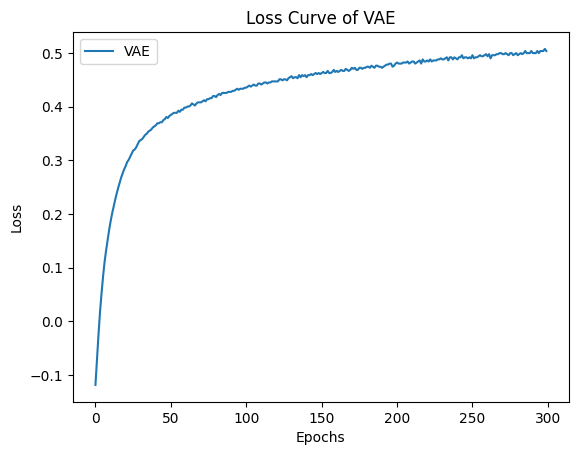

In [11]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['vae']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='VAE')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of VAE')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

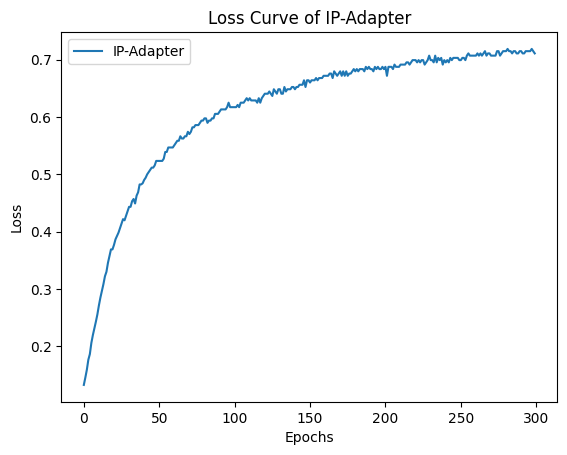

In [12]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IP-Adapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IP-Adapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## agm(UNet+CLIP)+MSE
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_unet-ipadapter_yingbu_agm_mse_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [1]:
loss_dict_list = [{'loss_sum': -2.59375, 'loss': -1.6707969903945923, 'unet': -2.140625, 'ipadapter': -0.453125}, {'loss_sum': -2.34375, 'loss': -1.4413973093032837, 'unet': -1.921875, 'ipadapter': -0.423828125}, {'loss_sum': -2.46875, 'loss': -1.5460026264190674, 'unet': -2.078125, 'ipadapter': -0.396484375}, {'loss_sum': -2.3125, 'loss': -1.2242345809936523, 'unet': -1.9296875, 'ipadapter': -0.376953125}, {'loss_sum': -2.40625, 'loss': -1.27903413772583, 'unet': -2.046875, 'ipadapter': -0.361328125}, {'loss_sum': -2.53125, 'loss': -1.3127974271774292, 'unet': -2.171875, 'ipadapter': -0.3515625}, {'loss_sum': -2.390625, 'loss': -1.1859045028686523, 'unet': -2.046875, 'ipadapter': -0.341796875}, {'loss_sum': -2.265625, 'loss': -1.1434686183929443, 'unet': -1.921875, 'ipadapter': -0.337890625}, {'loss_sum': -2.359375, 'loss': -1.146697759628296, 'unet': -2.03125, 'ipadapter': -0.328125}, {'loss_sum': -2.4375, 'loss': -1.1309425830841064, 'unet': -2.109375, 'ipadapter': -0.32421875}, {'loss_sum': -2.125, 'loss': -0.9078553915023804, 'unet': -1.8125, 'ipadapter': -0.3203125}, {'loss_sum': -1.96875, 'loss': -0.8788642883300781, 'unet': -1.6484375, 'ipadapter': -0.31640625}, {'loss_sum': -2.03125, 'loss': -0.8819410800933838, 'unet': -1.71875, 'ipadapter': -0.310546875}, {'loss_sum': -2.140625, 'loss': -0.9674221873283386, 'unet': -1.828125, 'ipadapter': -0.310546875}, {'loss_sum': -2.28125, 'loss': -0.973771333694458, 'unet': -1.9765625, 'ipadapter': -0.306640625}, {'loss_sum': -1.9921875, 'loss': -0.8485254049301147, 'unet': -1.6875, 'ipadapter': -0.306640625}, {'loss_sum': -2.25, 'loss': -0.9428365230560303, 'unet': -1.953125, 'ipadapter': -0.30078125}, {'loss_sum': -2.390625, 'loss': -1.062506914138794, 'unet': -2.09375, 'ipadapter': -0.298828125}, {'loss_sum': -2.0625, 'loss': -0.9061461687088013, 'unet': -1.765625, 'ipadapter': -0.296875}, {'loss_sum': -2.3125, 'loss': -1.0185649394989014, 'unet': -2.015625, 'ipadapter': -0.294921875}, {'loss_sum': -2.078125, 'loss': -0.8883581161499023, 'unet': -1.7890625, 'ipadapter': -0.291015625}, {'loss_sum': -2.125, 'loss': -0.9019359350204468, 'unet': -1.84375, 'ipadapter': -0.2890625}, {'loss_sum': -2.0625, 'loss': -0.8497735261917114, 'unet': -1.7734375, 'ipadapter': -0.287109375}, {'loss_sum': -2.03125, 'loss': -0.8384051322937012, 'unet': -1.75, 'ipadapter': -0.28515625}, {'loss_sum': -1.90625, 'loss': -0.7740725874900818, 'unet': -1.625, 'ipadapter': -0.28515625}, {'loss_sum': -1.9765625, 'loss': -0.8361085057258606, 'unet': -1.6953125, 'ipadapter': -0.283203125}, {'loss_sum': -2.125, 'loss': -0.8254998922348022, 'unet': -1.84375, 'ipadapter': -0.28125}, {'loss_sum': -1.9609375, 'loss': -0.8112243413925171, 'unet': -1.6796875, 'ipadapter': -0.28125}, {'loss_sum': -2.40625, 'loss': -0.9850292801856995, 'unet': -2.125, 'ipadapter': -0.27734375}, {'loss_sum': -2.125, 'loss': -0.8730885982513428, 'unet': -1.8515625, 'ipadapter': -0.275390625}, {'loss_sum': -1.7890625, 'loss': -0.7179446220397949, 'unet': -1.515625, 'ipadapter': -0.271484375}, {'loss_sum': -2.15625, 'loss': -0.7978139519691467, 'unet': -1.8828125, 'ipadapter': -0.267578125}, {'loss_sum': -2.0625, 'loss': -0.8199828863143921, 'unet': -1.796875, 'ipadapter': -0.267578125}, {'loss_sum': -2.234375, 'loss': -0.7987098097801208, 'unet': -1.9609375, 'ipadapter': -0.267578125}, {'loss_sum': -1.953125, 'loss': -0.7865090370178223, 'unet': -1.6875, 'ipadapter': -0.267578125}, {'loss_sum': -1.9296875, 'loss': -0.7235461473464966, 'unet': -1.6640625, 'ipadapter': -0.263671875}, {'loss_sum': -2.28125, 'loss': -0.8376009464263916, 'unet': -2.015625, 'ipadapter': -0.26171875}, {'loss_sum': -2.21875, 'loss': -0.9170636534690857, 'unet': -1.9609375, 'ipadapter': -0.26171875}, {'loss_sum': -2.203125, 'loss': -0.8486955761909485, 'unet': -1.9453125, 'ipadapter': -0.26171875}, {'loss_sum': -2.109375, 'loss': -0.8716408014297485, 'unet': -1.8515625, 'ipadapter': -0.259765625}, {'loss_sum': -1.828125, 'loss': -0.6053744554519653, 'unet': -1.5703125, 'ipadapter': -0.255859375}, {'loss_sum': -2.0625, 'loss': -0.7828691601753235, 'unet': -1.8046875, 'ipadapter': -0.255859375}, {'loss_sum': -1.890625, 'loss': -0.7199955582618713, 'unet': -1.6328125, 'ipadapter': -0.25390625}, {'loss_sum': -2.09375, 'loss': -0.7321434020996094, 'unet': -1.8359375, 'ipadapter': -0.25}, {'loss_sum': -2.15625, 'loss': -0.8429808616638184, 'unet': -1.90625, 'ipadapter': -0.25}, {'loss_sum': -2.03125, 'loss': -0.7825907468795776, 'unet': -1.78125, 'ipadapter': -0.248046875}, {'loss_sum': -1.953125, 'loss': -0.6419292092323303, 'unet': -1.7109375, 'ipadapter': -0.2451171875}, {'loss_sum': -2.109375, 'loss': -0.7450765371322632, 'unet': -1.8671875, 'ipadapter': -0.2451171875}, {'loss_sum': -2.046875, 'loss': -0.7326263189315796, 'unet': -1.8046875, 'ipadapter': -0.2431640625}, {'loss_sum': -1.8515625, 'loss': -0.678438127040863, 'unet': -1.609375, 'ipadapter': -0.2421875}, {'loss_sum': -1.828125, 'loss': -0.6001222729682922, 'unet': -1.59375, 'ipadapter': -0.2373046875}, {'loss_sum': -1.8359375, 'loss': -0.6329006552696228, 'unet': -1.6015625, 'ipadapter': -0.2373046875}, {'loss_sum': -1.71875, 'loss': -0.59952712059021, 'unet': -1.484375, 'ipadapter': -0.23828125}, {'loss_sum': -2.09375, 'loss': -0.7234959602355957, 'unet': -1.8515625, 'ipadapter': -0.2353515625}, {'loss_sum': -1.7578125, 'loss': -0.6095532178878784, 'unet': -1.5234375, 'ipadapter': -0.236328125}, {'loss_sum': -2.09375, 'loss': -0.7121020555496216, 'unet': -1.859375, 'ipadapter': -0.236328125}, {'loss_sum': -2.03125, 'loss': -0.713875949382782, 'unet': -1.796875, 'ipadapter': -0.2333984375}, {'loss_sum': -1.6484375, 'loss': -0.5693986415863037, 'unet': -1.4140625, 'ipadapter': -0.2314453125}, {'loss_sum': -1.890625, 'loss': -0.5760262608528137, 'unet': -1.6640625, 'ipadapter': -0.23046875}, {'loss_sum': -1.8046875, 'loss': -0.7588149309158325, 'unet': -1.5703125, 'ipadapter': -0.2314453125}, {'loss_sum': -1.8046875, 'loss': -0.5799243450164795, 'unet': -1.578125, 'ipadapter': -0.2265625}, {'loss_sum': -1.984375, 'loss': -0.6470730304718018, 'unet': -1.7578125, 'ipadapter': -0.2255859375}, {'loss_sum': -2.125, 'loss': -0.7783257365226746, 'unet': -1.8984375, 'ipadapter': -0.2275390625}, {'loss_sum': -2.046875, 'loss': -0.6698265075683594, 'unet': -1.828125, 'ipadapter': -0.224609375}, {'loss_sum': -1.65625, 'loss': -0.5404708981513977, 'unet': -1.4296875, 'ipadapter': -0.224609375}, {'loss_sum': -2.0, 'loss': -0.6776794195175171, 'unet': -1.78125, 'ipadapter': -0.2236328125}, {'loss_sum': -2.140625, 'loss': -0.6711747646331787, 'unet': -1.9140625, 'ipadapter': -0.2216796875}, {'loss_sum': -2.09375, 'loss': -0.6949424147605896, 'unet': -1.8671875, 'ipadapter': -0.22265625}, {'loss_sum': -2.140625, 'loss': -0.6963779330253601, 'unet': -1.921875, 'ipadapter': -0.220703125}, {'loss_sum': -2.1875, 'loss': -0.7742423415184021, 'unet': -1.9609375, 'ipadapter': -0.22265625}, {'loss_sum': -2.25, 'loss': -0.7311179637908936, 'unet': -2.03125, 'ipadapter': -0.21875}, {'loss_sum': -1.828125, 'loss': -0.6193193793296814, 'unet': -1.609375, 'ipadapter': -0.2177734375}, {'loss_sum': -2.140625, 'loss': -0.5984717011451721, 'unet': -1.9296875, 'ipadapter': -0.2138671875}, {'loss_sum': -2.125, 'loss': -0.6952687501907349, 'unet': -1.9140625, 'ipadapter': -0.21875}, {'loss_sum': -1.6796875, 'loss': -0.5436115264892578, 'unet': -1.4609375, 'ipadapter': -0.2158203125}, {'loss_sum': -1.8359375, 'loss': -0.5713427066802979, 'unet': -1.625, 'ipadapter': -0.2138671875}, {'loss_sum': -2.03125, 'loss': -0.6881727576255798, 'unet': -1.8125, 'ipadapter': -0.212890625}, {'loss_sum': -1.84375, 'loss': -0.5003109574317932, 'unet': -1.6328125, 'ipadapter': -0.2119140625}, {'loss_sum': -1.9140625, 'loss': -0.728601336479187, 'unet': -1.703125, 'ipadapter': -0.2138671875}, {'loss_sum': -1.84375, 'loss': -0.4641779661178589, 'unet': -1.6328125, 'ipadapter': -0.20703125}, {'loss_sum': -2.0625, 'loss': -0.716051459312439, 'unet': -1.84375, 'ipadapter': -0.2119140625}, {'loss_sum': -2.34375, 'loss': -0.7501026391983032, 'unet': -2.140625, 'ipadapter': -0.20703125}, {'loss_sum': -2.078125, 'loss': -0.6045676469802856, 'unet': -1.875, 'ipadapter': -0.20703125}, {'loss_sum': -1.8203125, 'loss': -0.5507833957672119, 'unet': -1.609375, 'ipadapter': -0.2080078125}, {'loss_sum': -2.109375, 'loss': -0.6084379553794861, 'unet': -1.90625, 'ipadapter': -0.2060546875}, {'loss_sum': -1.921875, 'loss': -0.6677761673927307, 'unet': -1.71875, 'ipadapter': -0.2060546875}, {'loss_sum': -1.9453125, 'loss': -0.5926952362060547, 'unet': -1.7421875, 'ipadapter': -0.2021484375}, {'loss_sum': -2.140625, 'loss': -0.5836266279220581, 'unet': -1.9375, 'ipadapter': -0.201171875}, {'loss_sum': -1.5078125, 'loss': -0.5556541681289673, 'unet': -1.3046875, 'ipadapter': -0.2060546875}, {'loss_sum': -1.875, 'loss': -0.5239254236221313, 'unet': -1.671875, 'ipadapter': -0.2001953125}, {'loss_sum': -2.078125, 'loss': -0.6164532899856567, 'unet': -1.875, 'ipadapter': -0.2021484375}, {'loss_sum': -1.8984375, 'loss': -0.5934171676635742, 'unet': -1.6953125, 'ipadapter': -0.203125}, {'loss_sum': -2.25, 'loss': -0.7267236113548279, 'unet': -2.046875, 'ipadapter': -0.201171875}, {'loss_sum': -1.921875, 'loss': -0.7139686346054077, 'unet': -1.71875, 'ipadapter': -0.201171875}, {'loss_sum': -2.046875, 'loss': -0.6120968461036682, 'unet': -1.84375, 'ipadapter': -0.197265625}, {'loss_sum': -2.328125, 'loss': -0.7015674114227295, 'unet': -2.125, 'ipadapter': -0.2001953125}, {'loss_sum': -2.140625, 'loss': -0.6301547884941101, 'unet': -1.9453125, 'ipadapter': -0.2021484375}, {'loss_sum': -2.125, 'loss': -0.6482018828392029, 'unet': -1.921875, 'ipadapter': -0.2001953125}, {'loss_sum': -2.125, 'loss': -0.6870611906051636, 'unet': -1.9296875, 'ipadapter': -0.1982421875}, {'loss_sum': -2.25, 'loss': -0.6604040265083313, 'unet': -2.046875, 'ipadapter': -0.197265625}, {'loss_sum': -2.0, 'loss': -0.6488081812858582, 'unet': -1.796875, 'ipadapter': -0.19921875}, {'loss_sum': -1.7578125, 'loss': -0.451948881149292, 'unet': -1.5625, 'ipadapter': -0.1953125}, {'loss_sum': -2.015625, 'loss': -0.508886992931366, 'unet': -1.828125, 'ipadapter': -0.1943359375}, {'loss_sum': -1.96875, 'loss': -0.5977651476860046, 'unet': -1.7734375, 'ipadapter': -0.1962890625}, {'loss_sum': -2.15625, 'loss': -0.5652086734771729, 'unet': -1.96875, 'ipadapter': -0.19140625}, {'loss_sum': -2.03125, 'loss': -0.6511771082878113, 'unet': -1.84375, 'ipadapter': -0.193359375}, {'loss_sum': -2.078125, 'loss': -0.5261209607124329, 'unet': -1.890625, 'ipadapter': -0.19140625}, {'loss_sum': -2.046875, 'loss': -0.6834629774093628, 'unet': -1.8515625, 'ipadapter': -0.1943359375}, {'loss_sum': -2.15625, 'loss': -0.7445420026779175, 'unet': -1.9609375, 'ipadapter': -0.1923828125}, {'loss_sum': -1.703125, 'loss': -0.49714821577072144, 'unet': -1.5078125, 'ipadapter': -0.19140625}, {'loss_sum': -1.828125, 'loss': -0.4852912425994873, 'unet': -1.640625, 'ipadapter': -0.1904296875}, {'loss_sum': -2.0625, 'loss': -0.6574320793151855, 'unet': -1.875, 'ipadapter': -0.1923828125}, {'loss_sum': -2.015625, 'loss': -0.6099101305007935, 'unet': -1.8203125, 'ipadapter': -0.1884765625}, {'loss_sum': -2.28125, 'loss': -0.5344343781471252, 'unet': -2.09375, 'ipadapter': -0.1875}, {'loss_sum': -1.875, 'loss': -0.639275074005127, 'unet': -1.6875, 'ipadapter': -0.1904296875}, {'loss_sum': -2.109375, 'loss': -0.5064566135406494, 'unet': -1.9296875, 'ipadapter': -0.1845703125}, {'loss_sum': -2.234375, 'loss': -0.6698455214500427, 'unet': -2.046875, 'ipadapter': -0.189453125}, {'loss_sum': -2.078125, 'loss': -0.5333697199821472, 'unet': -1.890625, 'ipadapter': -0.185546875}, {'loss_sum': -2.109375, 'loss': -0.551785409450531, 'unet': -1.921875, 'ipadapter': -0.1865234375}, {'loss_sum': -1.875, 'loss': -0.4746648073196411, 'unet': -1.6875, 'ipadapter': -0.1845703125}, {'loss_sum': -2.078125, 'loss': -0.5910585522651672, 'unet': -1.8984375, 'ipadapter': -0.1845703125}, {'loss_sum': -2.015625, 'loss': -0.5055861473083496, 'unet': -1.828125, 'ipadapter': -0.18359375}, {'loss_sum': -2.171875, 'loss': -0.5466828346252441, 'unet': -1.984375, 'ipadapter': -0.18359375}, {'loss_sum': -2.109375, 'loss': -0.6494562029838562, 'unet': -1.921875, 'ipadapter': -0.18359375}, {'loss_sum': -2.15625, 'loss': -0.5584781169891357, 'unet': -1.96875, 'ipadapter': -0.1796875}, {'loss_sum': -1.84375, 'loss': -0.5410187244415283, 'unet': -1.65625, 'ipadapter': -0.18359375}, {'loss_sum': -2.109375, 'loss': -0.5150924921035767, 'unet': -1.9375, 'ipadapter': -0.1787109375}, {'loss_sum': -2.125, 'loss': -0.6251391172409058, 'unet': -1.9453125, 'ipadapter': -0.18359375}, {'loss_sum': -2.140625, 'loss': -0.6506158113479614, 'unet': -1.953125, 'ipadapter': -0.1806640625}, {'loss_sum': -1.9375, 'loss': -0.5207114219665527, 'unet': -1.7578125, 'ipadapter': -0.1787109375}, {'loss_sum': -2.0625, 'loss': -0.5856038331985474, 'unet': -1.8828125, 'ipadapter': -0.1787109375}, {'loss_sum': -2.046875, 'loss': -0.5539758205413818, 'unet': -1.8671875, 'ipadapter': -0.177734375}, {'loss_sum': -2.140625, 'loss': -0.5613150596618652, 'unet': -1.9609375, 'ipadapter': -0.177734375}, {'loss_sum': -2.046875, 'loss': -0.5971179008483887, 'unet': -1.875, 'ipadapter': -0.1787109375}, {'loss_sum': -1.9921875, 'loss': -0.550017237663269, 'unet': -1.8203125, 'ipadapter': -0.1748046875}, {'loss_sum': -1.9765625, 'loss': -0.45285940170288086, 'unet': -1.8046875, 'ipadapter': -0.1748046875}, {'loss_sum': -2.171875, 'loss': -0.6137909293174744, 'unet': -2.0, 'ipadapter': -0.177734375}, {'loss_sum': -1.90625, 'loss': -0.4708954095840454, 'unet': -1.734375, 'ipadapter': -0.173828125}, {'loss_sum': -2.234375, 'loss': -0.6327123641967773, 'unet': -2.0625, 'ipadapter': -0.1748046875}, {'loss_sum': -1.8046875, 'loss': -0.4956895709037781, 'unet': -1.6328125, 'ipadapter': -0.173828125}, {'loss_sum': -1.953125, 'loss': -0.5242645740509033, 'unet': -1.78125, 'ipadapter': -0.1728515625}, {'loss_sum': -1.984375, 'loss': -0.5368520617485046, 'unet': -1.8125, 'ipadapter': -0.17578125}, {'loss_sum': -1.671875, 'loss': -0.467151403427124, 'unet': -1.5, 'ipadapter': -0.1748046875}, {'loss_sum': -2.0, 'loss': -0.47733867168426514, 'unet': -1.8359375, 'ipadapter': -0.171875}, {'loss_sum': -1.9296875, 'loss': -0.5329537391662598, 'unet': -1.7578125, 'ipadapter': -0.173828125}, {'loss_sum': -2.015625, 'loss': -0.5341978669166565, 'unet': -1.8515625, 'ipadapter': -0.1708984375}, {'loss_sum': -2.0, 'loss': -0.5747302770614624, 'unet': -1.828125, 'ipadapter': -0.173828125}, {'loss_sum': -2.0625, 'loss': -0.4735485911369324, 'unet': -1.8984375, 'ipadapter': -0.169921875}, {'loss_sum': -2.03125, 'loss': -0.5795792937278748, 'unet': -1.8671875, 'ipadapter': -0.171875}, {'loss_sum': -2.0, 'loss': -0.4911792278289795, 'unet': -1.8359375, 'ipadapter': -0.1689453125}, {'loss_sum': -2.0625, 'loss': -0.5440657138824463, 'unet': -1.8984375, 'ipadapter': -0.1708984375}, {'loss_sum': -2.0625, 'loss': -0.5547460317611694, 'unet': -1.8828125, 'ipadapter': -0.171875}, {'loss_sum': -2.09375, 'loss': -0.5732101798057556, 'unet': -1.9296875, 'ipadapter': -0.16796875}, {'loss_sum': -2.078125, 'loss': -0.5356510877609253, 'unet': -1.90625, 'ipadapter': -0.1669921875}, {'loss_sum': -1.9296875, 'loss': -0.5195008516311646, 'unet': -1.765625, 'ipadapter': -0.1669921875}, {'loss_sum': -1.9765625, 'loss': -0.47083693742752075, 'unet': -1.8125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.921875, 'loss': -0.5080204010009766, 'unet': -1.75, 'ipadapter': -0.169921875}, {'loss_sum': -1.890625, 'loss': -0.3960721790790558, 'unet': -1.71875, 'ipadapter': -0.1689453125}, {'loss_sum': -2.046875, 'loss': -0.6180877685546875, 'unet': -1.875, 'ipadapter': -0.169921875}, {'loss_sum': -1.84375, 'loss': -0.4653328061103821, 'unet': -1.6796875, 'ipadapter': -0.1669921875}, {'loss_sum': -2.0, 'loss': -0.4583301842212677, 'unet': -1.8359375, 'ipadapter': -0.166015625}, {'loss_sum': -1.8828125, 'loss': -0.5208901166915894, 'unet': -1.7109375, 'ipadapter': -0.1689453125}, {'loss_sum': -1.59375, 'loss': -0.46178150177001953, 'unet': -1.4296875, 'ipadapter': -0.166015625}, {'loss_sum': -2.03125, 'loss': -0.49445658922195435, 'unet': -1.8671875, 'ipadapter': -0.1630859375}, {'loss_sum': -1.9765625, 'loss': -0.5240957140922546, 'unet': -1.8125, 'ipadapter': -0.166015625}, {'loss_sum': -2.125, 'loss': -0.561190128326416, 'unet': -1.96875, 'ipadapter': -0.1640625}, {'loss_sum': -1.796875, 'loss': -0.46735525131225586, 'unet': -1.6328125, 'ipadapter': -0.1630859375}, {'loss_sum': -1.9609375, 'loss': -0.4103417992591858, 'unet': -1.796875, 'ipadapter': -0.1630859375}, {'loss_sum': -1.6953125, 'loss': -0.48367953300476074, 'unet': -1.53125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.71875, 'loss': -0.3594970107078552, 'unet': -1.5546875, 'ipadapter': -0.16015625}, {'loss_sum': -1.8671875, 'loss': -0.4482400417327881, 'unet': -1.703125, 'ipadapter': -0.1630859375}, {'loss_sum': -2.09375, 'loss': -0.46055445075035095, 'unet': -1.9296875, 'ipadapter': -0.1630859375}, {'loss_sum': -1.65625, 'loss': -0.40641045570373535, 'unet': -1.4921875, 'ipadapter': -0.1630859375}, {'loss_sum': -1.953125, 'loss': -0.3932245969772339, 'unet': -1.796875, 'ipadapter': -0.16015625}, {'loss_sum': -1.8828125, 'loss': -0.5643063187599182, 'unet': -1.71875, 'ipadapter': -0.1650390625}, {'loss_sum': -2.171875, 'loss': -0.5484516620635986, 'unet': -2.015625, 'ipadapter': -0.16015625}, {'loss_sum': -2.0625, 'loss': -0.5641885995864868, 'unet': -1.8984375, 'ipadapter': -0.16015625}, {'loss_sum': -2.15625, 'loss': -0.47055184841156006, 'unet': -2.0, 'ipadapter': -0.158203125}, {'loss_sum': -2.125, 'loss': -0.6011897325515747, 'unet': -1.9609375, 'ipadapter': -0.162109375}, {'loss_sum': -1.6953125, 'loss': -0.36315709352493286, 'unet': -1.5390625, 'ipadapter': -0.1591796875}, {'loss_sum': -2.15625, 'loss': -0.5491288304328918, 'unet': -2.0, 'ipadapter': -0.162109375}, {'loss_sum': -1.84375, 'loss': -0.5643972754478455, 'unet': -1.6796875, 'ipadapter': -0.162109375}, {'loss_sum': -2.15625, 'loss': -0.445659875869751, 'unet': -2.0, 'ipadapter': -0.1572265625}, {'loss_sum': -1.921875, 'loss': -0.5571362972259521, 'unet': -1.7578125, 'ipadapter': -0.1630859375}, {'loss_sum': -1.953125, 'loss': -0.5331842303276062, 'unet': -1.796875, 'ipadapter': -0.16015625}, {'loss_sum': -2.078125, 'loss': -0.44175273180007935, 'unet': -1.9140625, 'ipadapter': -0.158203125}, {'loss_sum': -2.078125, 'loss': -0.5102497339248657, 'unet': -1.921875, 'ipadapter': -0.1611328125}, {'loss_sum': -1.6953125, 'loss': -0.3769056797027588, 'unet': -1.5390625, 'ipadapter': -0.1572265625}, {'loss_sum': -1.9140625, 'loss': -0.44486474990844727, 'unet': -1.7578125, 'ipadapter': -0.1572265625}, {'loss_sum': -1.7890625, 'loss': -0.4086604714393616, 'unet': -1.6328125, 'ipadapter': -0.15625}, {'loss_sum': -2.046875, 'loss': -0.4892083704471588, 'unet': -1.890625, 'ipadapter': -0.1572265625}, {'loss_sum': -1.9765625, 'loss': -0.4379369914531708, 'unet': -1.8203125, 'ipadapter': -0.1552734375}, {'loss_sum': -1.84375, 'loss': -0.4487770199775696, 'unet': -1.6875, 'ipadapter': -0.15625}, {'loss_sum': -2.0, 'loss': -0.38177475333213806, 'unet': -1.84375, 'ipadapter': -0.1533203125}, {'loss_sum': -1.9609375, 'loss': -0.4932768642902374, 'unet': -1.8046875, 'ipadapter': -0.15625}, {'loss_sum': -2.109375, 'loss': -0.4454755187034607, 'unet': -1.953125, 'ipadapter': -0.154296875}, {'loss_sum': -2.15625, 'loss': -0.5124260187149048, 'unet': -2.0, 'ipadapter': -0.15625}, {'loss_sum': -1.8359375, 'loss': -0.43556344509124756, 'unet': -1.6796875, 'ipadapter': -0.1552734375}, {'loss_sum': -1.984375, 'loss': -0.4138062298297882, 'unet': -1.828125, 'ipadapter': -0.1533203125}, {'loss_sum': -1.9140625, 'loss': -0.5130549073219299, 'unet': -1.7578125, 'ipadapter': -0.15625}, {'loss_sum': -1.7109375, 'loss': -0.3500439524650574, 'unet': -1.5625, 'ipadapter': -0.1494140625}, {'loss_sum': -2.21875, 'loss': -0.6074149012565613, 'unet': -2.0625, 'ipadapter': -0.154296875}, {'loss_sum': -1.796875, 'loss': -0.41994595527648926, 'unet': -1.6484375, 'ipadapter': -0.1513671875}, {'loss_sum': -1.640625, 'loss': -0.41184788942337036, 'unet': -1.4921875, 'ipadapter': -0.15234375}, {'loss_sum': -2.0625, 'loss': -0.4323231279850006, 'unet': -1.9140625, 'ipadapter': -0.1513671875}, {'loss_sum': -2.0625, 'loss': -0.4960780441761017, 'unet': -1.90625, 'ipadapter': -0.1533203125}, {'loss_sum': -1.984375, 'loss': -0.45632612705230713, 'unet': -1.828125, 'ipadapter': -0.1533203125}, {'loss_sum': -1.859375, 'loss': -0.4127337336540222, 'unet': -1.703125, 'ipadapter': -0.1533203125}, {'loss_sum': -2.015625, 'loss': -0.4743952751159668, 'unet': -1.8671875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.8203125, 'loss': -0.38137590885162354, 'unet': -1.671875, 'ipadapter': -0.150390625}, {'loss_sum': -2.015625, 'loss': -0.4493635594844818, 'unet': -1.8671875, 'ipadapter': -0.1513671875}, {'loss_sum': -1.7734375, 'loss': -0.37103593349456787, 'unet': -1.625, 'ipadapter': -0.1494140625}, {'loss_sum': -1.65625, 'loss': -0.3705422878265381, 'unet': -1.5078125, 'ipadapter': -0.1484375}, {'loss_sum': -1.84375, 'loss': -0.47077879309654236, 'unet': -1.6953125, 'ipadapter': -0.150390625}, {'loss_sum': -2.15625, 'loss': -0.3900919556617737, 'unet': -2.015625, 'ipadapter': -0.1484375}, {'loss_sum': -1.9765625, 'loss': -0.5094038248062134, 'unet': -1.828125, 'ipadapter': -0.1513671875}, {'loss_sum': -1.921875, 'loss': -0.4066603481769562, 'unet': -1.7734375, 'ipadapter': -0.146484375}, {'loss_sum': -1.8125, 'loss': -0.38928622007369995, 'unet': -1.6640625, 'ipadapter': -0.146484375}, {'loss_sum': -1.765625, 'loss': -0.4560856819152832, 'unet': -1.6171875, 'ipadapter': -0.146484375}, {'loss_sum': -1.75, 'loss': -0.3001928925514221, 'unet': -1.6015625, 'ipadapter': -0.14453125}, {'loss_sum': -1.96875, 'loss': -0.5202217102050781, 'unet': -1.8203125, 'ipadapter': -0.150390625}, {'loss_sum': -1.8671875, 'loss': -0.4067171812057495, 'unet': -1.71875, 'ipadapter': -0.1455078125}, {'loss_sum': -1.9375, 'loss': -0.393812358379364, 'unet': -1.7890625, 'ipadapter': -0.1484375}, {'loss_sum': -2.015625, 'loss': -0.5124738812446594, 'unet': -1.8671875, 'ipadapter': -0.1484375}, {'loss_sum': -1.921875, 'loss': -0.36518925428390503, 'unet': -1.7734375, 'ipadapter': -0.1455078125}, {'loss_sum': -1.921875, 'loss': -0.40607598423957825, 'unet': -1.7734375, 'ipadapter': -0.146484375}, {'loss_sum': -1.9140625, 'loss': -0.3944271206855774, 'unet': -1.765625, 'ipadapter': -0.1474609375}, {'loss_sum': -1.921875, 'loss': -0.37077832221984863, 'unet': -1.7734375, 'ipadapter': -0.1474609375}, {'loss_sum': -1.953125, 'loss': -0.488275945186615, 'unet': -1.8046875, 'ipadapter': -0.1474609375}, {'loss_sum': -1.9296875, 'loss': -0.3378320336341858, 'unet': -1.7890625, 'ipadapter': -0.1435546875}, {'loss_sum': -1.9296875, 'loss': -0.6004484295845032, 'unet': -1.78125, 'ipadapter': -0.1474609375}, {'loss_sum': -1.6640625, 'loss': -0.28131407499313354, 'unet': -1.5234375, 'ipadapter': -0.140625}, {'loss_sum': -1.9609375, 'loss': -0.513421356678009, 'unet': -1.8125, 'ipadapter': -0.146484375}, {'loss_sum': -1.6875, 'loss': -0.3915124833583832, 'unet': -1.546875, 'ipadapter': -0.14453125}, {'loss_sum': -1.84375, 'loss': -0.4301968812942505, 'unet': -1.703125, 'ipadapter': -0.14453125}, {'loss_sum': -1.953125, 'loss': -0.42895936965942383, 'unet': -1.8125, 'ipadapter': -0.14453125}, {'loss_sum': -1.9140625, 'loss': -0.4980910122394562, 'unet': -1.765625, 'ipadapter': -0.1455078125}, {'loss_sum': -2.125, 'loss': -0.4398552179336548, 'unet': -1.9765625, 'ipadapter': -0.1435546875}, {'loss_sum': -2.09375, 'loss': -0.4281877279281616, 'unet': -1.953125, 'ipadapter': -0.1455078125}, {'loss_sum': -2.046875, 'loss': -0.4335833787918091, 'unet': -1.8984375, 'ipadapter': -0.14453125}, {'loss_sum': -2.09375, 'loss': -0.4245753586292267, 'unet': -1.9453125, 'ipadapter': -0.14453125}, {'loss_sum': -1.703125, 'loss': -0.3760036826133728, 'unet': -1.5546875, 'ipadapter': -0.1455078125}, {'loss_sum': -2.078125, 'loss': -0.33656346797943115, 'unet': -1.9375, 'ipadapter': -0.1416015625}, {'loss_sum': -2.0625, 'loss': -0.6829950213432312, 'unet': -1.921875, 'ipadapter': -0.1474609375}, {'loss_sum': -1.9375, 'loss': -0.322441041469574, 'unet': -1.796875, 'ipadapter': -0.1396484375}, {'loss_sum': -1.9765625, 'loss': -0.41820675134658813, 'unet': -1.828125, 'ipadapter': -0.1455078125}, {'loss_sum': -2.0625, 'loss': -0.523917555809021, 'unet': -1.921875, 'ipadapter': -0.14453125}, {'loss_sum': -1.734375, 'loss': -0.3937256336212158, 'unet': -1.59375, 'ipadapter': -0.1416015625}, {'loss_sum': -2.09375, 'loss': -0.42034533619880676, 'unet': -1.953125, 'ipadapter': -0.1416015625}, {'loss_sum': -1.8515625, 'loss': -0.4068461060523987, 'unet': -1.7109375, 'ipadapter': -0.1435546875}, {'loss_sum': -2.125, 'loss': -0.4694550931453705, 'unet': -1.984375, 'ipadapter': -0.1416015625}, {'loss_sum': -1.890625, 'loss': -0.43013644218444824, 'unet': -1.75, 'ipadapter': -0.1416015625}, {'loss_sum': -1.6953125, 'loss': -0.3493494391441345, 'unet': -1.5546875, 'ipadapter': -0.138671875}, {'loss_sum': -1.75, 'loss': -0.4021797776222229, 'unet': -1.609375, 'ipadapter': -0.140625}, {'loss_sum': -1.828125, 'loss': -0.38116928935050964, 'unet': -1.6875, 'ipadapter': -0.1396484375}, {'loss_sum': -1.8671875, 'loss': -0.44949468970298767, 'unet': -1.7265625, 'ipadapter': -0.142578125}, {'loss_sum': -1.9296875, 'loss': -0.4402294456958771, 'unet': -1.7890625, 'ipadapter': -0.1396484375}, {'loss_sum': -1.6640625, 'loss': -0.3490695655345917, 'unet': -1.5234375, 'ipadapter': -0.1396484375}, {'loss_sum': -1.5234375, 'loss': -0.31409916281700134, 'unet': -1.3828125, 'ipadapter': -0.140625}, {'loss_sum': -1.578125, 'loss': -0.3418310880661011, 'unet': -1.4375, 'ipadapter': -0.142578125}, {'loss_sum': -2.09375, 'loss': -0.38139185309410095, 'unet': -1.9609375, 'ipadapter': -0.140625}, {'loss_sum': -1.8359375, 'loss': -0.3992180824279785, 'unet': -1.6953125, 'ipadapter': -0.1416015625}, {'loss_sum': -2.140625, 'loss': -0.37581825256347656, 'unet': -2.0, 'ipadapter': -0.1376953125}, {'loss_sum': -1.921875, 'loss': -0.46290022134780884, 'unet': -1.78125, 'ipadapter': -0.1416015625}, {'loss_sum': -1.9375, 'loss': -0.4016266465187073, 'unet': -1.796875, 'ipadapter': -0.140625}, {'loss_sum': -1.90625, 'loss': -0.40649935603141785, 'unet': -1.765625, 'ipadapter': -0.1396484375}, {'loss_sum': -2.15625, 'loss': -0.5700910687446594, 'unet': -2.015625, 'ipadapter': -0.1396484375}, {'loss_sum': -1.984375, 'loss': -0.37773236632347107, 'unet': -1.8515625, 'ipadapter': -0.1357421875}, {'loss_sum': -1.75, 'loss': -0.3547531068325043, 'unet': -1.609375, 'ipadapter': -0.1376953125}, {'loss_sum': -1.9140625, 'loss': -0.4130114018917084, 'unet': -1.7734375, 'ipadapter': -0.1376953125}, {'loss_sum': -1.90625, 'loss': -0.38712725043296814, 'unet': -1.765625, 'ipadapter': -0.13671875}, {'loss_sum': -1.96875, 'loss': -0.4169023036956787, 'unet': -1.828125, 'ipadapter': -0.13671875}, {'loss_sum': -1.9140625, 'loss': -0.4159810543060303, 'unet': -1.7734375, 'ipadapter': -0.138671875}, {'loss_sum': -2.234375, 'loss': -0.5465179681777954, 'unet': -2.09375, 'ipadapter': -0.138671875}, {'loss_sum': -1.765625, 'loss': -0.41523265838623047, 'unet': -1.625, 'ipadapter': -0.1396484375}, {'loss_sum': -1.984375, 'loss': -0.39029553532600403, 'unet': -1.84375, 'ipadapter': -0.1376953125}, {'loss_sum': -2.109375, 'loss': -0.44365718960762024, 'unet': -1.9609375, 'ipadapter': -0.142578125}, {'loss_sum': -1.734375, 'loss': -0.4150020480155945, 'unet': -1.59375, 'ipadapter': -0.1416015625}, {'loss_sum': -1.875, 'loss': -0.3714655637741089, 'unet': -1.734375, 'ipadapter': -0.1396484375}, {'loss_sum': -1.9296875, 'loss': -0.3802497982978821, 'unet': -1.7890625, 'ipadapter': -0.140625}, {'loss_sum': -2.25, 'loss': -0.45695406198501587, 'unet': -2.109375, 'ipadapter': -0.138671875}, {'loss_sum': -1.7109375, 'loss': -0.4004794955253601, 'unet': -1.5703125, 'ipadapter': -0.138671875}, {'loss_sum': -1.84375, 'loss': -0.35712337493896484, 'unet': -1.7109375, 'ipadapter': -0.13671875}, {'loss_sum': -1.953125, 'loss': -0.44780075550079346, 'unet': -1.8125, 'ipadapter': -0.1396484375}, {'loss_sum': -1.9453125, 'loss': -0.37459370493888855, 'unet': -1.8046875, 'ipadapter': -0.1376953125}, {'loss_sum': -1.8828125, 'loss': -0.3677164912223816, 'unet': -1.7421875, 'ipadapter': -0.138671875}, {'loss_sum': -1.59375, 'loss': -0.37116870284080505, 'unet': -1.453125, 'ipadapter': -0.1396484375}, {'loss_sum': -1.8359375, 'loss': -0.3065512776374817, 'unet': -1.703125, 'ipadapter': -0.1357421875}, {'loss_sum': -1.875, 'loss': -0.43853309750556946, 'unet': -1.734375, 'ipadapter': -0.1416015625}, {'loss_sum': -1.8984375, 'loss': -0.3766542375087738, 'unet': -1.7578125, 'ipadapter': -0.1376953125}, {'loss_sum': -1.8828125, 'loss': -0.4384005069732666, 'unet': -1.7421875, 'ipadapter': -0.1396484375}, {'loss_sum': -2.0, 'loss': -0.3740088939666748, 'unet': -1.8671875, 'ipadapter': -0.1357421875}, {'loss_sum': -1.875, 'loss': -0.4453508257865906, 'unet': -1.734375, 'ipadapter': -0.1376953125}, {'loss_sum': -1.953125, 'loss': -0.40770915150642395, 'unet': -1.8203125, 'ipadapter': -0.1337890625}, {'loss_sum': -1.90625, 'loss': -0.4109128713607788, 'unet': -1.7734375, 'ipadapter': -0.13671875}, {'loss_sum': -1.796875, 'loss': -0.4234118163585663, 'unet': -1.65625, 'ipadapter': -0.13671875}, {'loss_sum': -1.8203125, 'loss': -0.33966386318206787, 'unet': -1.6875, 'ipadapter': -0.134765625}, {'loss_sum': -2.15625, 'loss': -0.48349273204803467, 'unet': -2.015625, 'ipadapter': -0.1376953125}, {'loss_sum': -1.9140625, 'loss': -0.33710652589797974, 'unet': -1.78125, 'ipadapter': -0.134765625}, {'loss_sum': -1.9609375, 'loss': -0.4490869641304016, 'unet': -1.828125, 'ipadapter': -0.1357421875}]


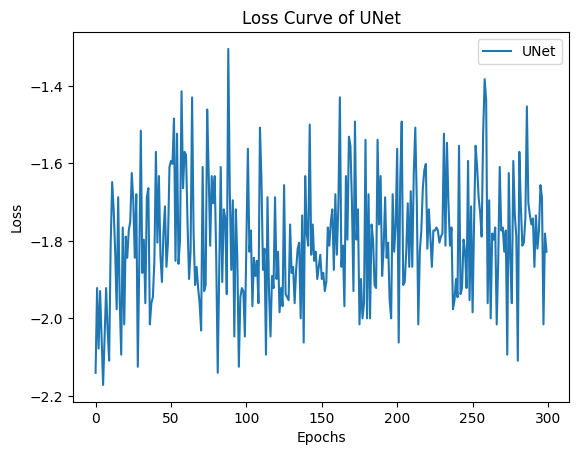

In [3]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['unet']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='UNet')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of UNet')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

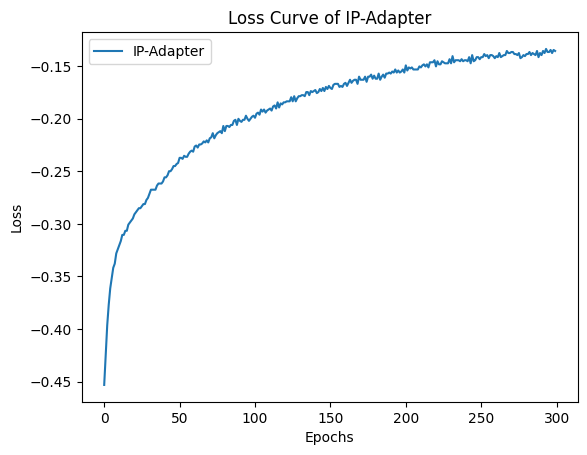

In [4]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IP-Adapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IP-Adapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## (1*UNet+1*CLIP)+MSE
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_unet-ipadapter_yingbu_no-agm-w1-1-w2-0-w3-1-w4-0_mse_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [3]:
loss_dict_list = [{'loss_sum': -2.59375, 'loss': -2.59375, 'unet': -2.140625, 'ipadapter': -0.453125}, {'loss_sum': -2.34375, 'loss': -2.34375, 'unet': -1.921875, 'ipadapter': -0.419921875}, {'loss_sum': -2.46875, 'loss': -2.46875, 'unet': -2.078125, 'ipadapter': -0.392578125}, {'loss_sum': -2.3125, 'loss': -2.3125, 'unet': -1.9453125, 'ipadapter': -0.375}, {'loss_sum': -2.390625, 'loss': -2.390625, 'unet': -2.03125, 'ipadapter': -0.359375}, {'loss_sum': -2.515625, 'loss': -2.515625, 'unet': -2.171875, 'ipadapter': -0.34765625}, {'loss_sum': -2.1875, 'loss': -2.1875, 'unet': -1.8515625, 'ipadapter': -0.3359375}, {'loss_sum': -2.3125, 'loss': -2.3125, 'unet': -1.9765625, 'ipadapter': -0.33203125}, {'loss_sum': -2.296875, 'loss': -2.296875, 'unet': -1.96875, 'ipadapter': -0.32421875}, {'loss_sum': -2.28125, 'loss': -2.28125, 'unet': -1.9609375, 'ipadapter': -0.3203125}, {'loss_sum': -2.390625, 'loss': -2.390625, 'unet': -2.078125, 'ipadapter': -0.31640625}, {'loss_sum': -2.171875, 'loss': -2.171875, 'unet': -1.859375, 'ipadapter': -0.3125}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -1.78125, 'ipadapter': -0.306640625}, {'loss_sum': -2.375, 'loss': -2.375, 'unet': -2.078125, 'ipadapter': -0.3046875}, {'loss_sum': -2.1875, 'loss': -2.1875, 'unet': -1.8828125, 'ipadapter': -0.302734375}, {'loss_sum': -1.96875, 'loss': -1.96875, 'unet': -1.671875, 'ipadapter': -0.30078125}, {'loss_sum': -2.203125, 'loss': -2.203125, 'unet': -1.90625, 'ipadapter': -0.296875}, {'loss_sum': -2.140625, 'loss': -2.140625, 'unet': -1.8515625, 'ipadapter': -0.294921875}, {'loss_sum': -2.3125, 'loss': -2.3125, 'unet': -2.015625, 'ipadapter': -0.296875}, {'loss_sum': -1.96875, 'loss': -1.96875, 'unet': -1.671875, 'ipadapter': -0.29296875}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -1.765625, 'ipadapter': -0.287109375}, {'loss_sum': -2.203125, 'loss': -2.203125, 'unet': -1.9140625, 'ipadapter': -0.287109375}, {'loss_sum': -1.703125, 'loss': -1.703125, 'unet': -1.4140625, 'ipadapter': -0.28515625}, {'loss_sum': -2.203125, 'loss': -2.203125, 'unet': -1.921875, 'ipadapter': -0.283203125}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.78125, 'ipadapter': -0.283203125}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -1.8125, 'ipadapter': -0.283203125}, {'loss_sum': -2.296875, 'loss': -2.296875, 'unet': -2.015625, 'ipadapter': -0.279296875}, {'loss_sum': -2.3125, 'loss': -2.3125, 'unet': -2.03125, 'ipadapter': -0.279296875}, {'loss_sum': -2.234375, 'loss': -2.234375, 'unet': -1.953125, 'ipadapter': -0.275390625}, {'loss_sum': -2.21875, 'loss': -2.21875, 'unet': -1.9375, 'ipadapter': -0.2734375}, {'loss_sum': -1.984375, 'loss': -1.984375, 'unet': -1.7109375, 'ipadapter': -0.275390625}, {'loss_sum': -2.265625, 'loss': -2.265625, 'unet': -1.9921875, 'ipadapter': -0.26953125}, {'loss_sum': -2.03125, 'loss': -2.03125, 'unet': -1.765625, 'ipadapter': -0.26953125}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -1.8203125, 'ipadapter': -0.267578125}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -1.75, 'ipadapter': -0.263671875}, {'loss_sum': -1.984375, 'loss': -1.984375, 'unet': -1.71875, 'ipadapter': -0.26171875}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -1.7578125, 'ipadapter': -0.26171875}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -1.7578125, 'ipadapter': -0.26171875}, {'loss_sum': -2.203125, 'loss': -2.203125, 'unet': -1.9453125, 'ipadapter': -0.26171875}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.796875, 'ipadapter': -0.259765625}, {'loss_sum': -2.359375, 'loss': -2.359375, 'unet': -2.109375, 'ipadapter': -0.255859375}, {'loss_sum': -2.03125, 'loss': -2.03125, 'unet': -1.7734375, 'ipadapter': -0.25390625}, {'loss_sum': -2.3125, 'loss': -2.3125, 'unet': -2.0625, 'ipadapter': -0.251953125}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.8046875, 'ipadapter': -0.251953125}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.8125, 'ipadapter': -0.25}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -1.8046875, 'ipadapter': -0.248046875}, {'loss_sum': -1.90625, 'loss': -1.90625, 'unet': -1.65625, 'ipadapter': -0.24609375}, {'loss_sum': -2.3125, 'loss': -2.3125, 'unet': -2.0625, 'ipadapter': -0.24609375}, {'loss_sum': -1.71875, 'loss': -1.71875, 'unet': -1.4765625, 'ipadapter': -0.2451171875}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.7109375, 'ipadapter': -0.2392578125}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.6484375, 'ipadapter': -0.23828125}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -1.8125, 'ipadapter': -0.2373046875}, {'loss_sum': -1.7421875, 'loss': -1.7421875, 'unet': -1.5, 'ipadapter': -0.2412109375}, {'loss_sum': -2.109375, 'loss': -2.109375, 'unet': -1.875, 'ipadapter': -0.234375}, {'loss_sum': -2.125, 'loss': -2.125, 'unet': -1.890625, 'ipadapter': -0.236328125}, {'loss_sum': -2.140625, 'loss': -2.140625, 'unet': -1.90625, 'ipadapter': -0.2353515625}, {'loss_sum': -2.1875, 'loss': -2.1875, 'unet': -1.9609375, 'ipadapter': -0.232421875}, {'loss_sum': -1.6953125, 'loss': -1.6953125, 'unet': -1.4609375, 'ipadapter': -0.2333984375}, {'loss_sum': -2.265625, 'loss': -2.265625, 'unet': -2.03125, 'ipadapter': -0.228515625}, {'loss_sum': -2.28125, 'loss': -2.28125, 'unet': -2.046875, 'ipadapter': -0.2314453125}, {'loss_sum': -2.21875, 'loss': -2.21875, 'unet': -1.984375, 'ipadapter': -0.23046875}, {'loss_sum': -2.15625, 'loss': -2.15625, 'unet': -1.9296875, 'ipadapter': -0.228515625}, {'loss_sum': -2.140625, 'loss': -2.140625, 'unet': -1.9140625, 'ipadapter': -0.2275390625}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.8359375, 'ipadapter': -0.2255859375}, {'loss_sum': -1.7578125, 'loss': -1.7578125, 'unet': -1.53125, 'ipadapter': -0.224609375}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -1.796875, 'ipadapter': -0.22265625}, {'loss_sum': -2.15625, 'loss': -2.15625, 'unet': -1.9375, 'ipadapter': -0.224609375}, {'loss_sum': -2.171875, 'loss': -2.171875, 'unet': -1.9453125, 'ipadapter': -0.2236328125}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.671875, 'ipadapter': -0.22265625}, {'loss_sum': -1.875, 'loss': -1.875, 'unet': -1.65625, 'ipadapter': -0.21875}, {'loss_sum': -1.9765625, 'loss': -1.9765625, 'unet': -1.7578125, 'ipadapter': -0.2197265625}, {'loss_sum': -1.78125, 'loss': -1.78125, 'unet': -1.5625, 'ipadapter': -0.21875}, {'loss_sum': -2.1875, 'loss': -2.1875, 'unet': -1.96875, 'ipadapter': -0.2158203125}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.59375, 'ipadapter': -0.2197265625}, {'loss_sum': -2.296875, 'loss': -2.296875, 'unet': -2.078125, 'ipadapter': -0.21484375}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.8515625, 'ipadapter': -0.2177734375}, {'loss_sum': -2.1875, 'loss': -2.1875, 'unet': -1.9765625, 'ipadapter': -0.21484375}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.671875, 'ipadapter': -0.21484375}, {'loss_sum': -1.8046875, 'loss': -1.8046875, 'unet': -1.59375, 'ipadapter': -0.2119140625}, {'loss_sum': -2.203125, 'loss': -2.203125, 'unet': -1.9921875, 'ipadapter': -0.2109375}, {'loss_sum': -2.125, 'loss': -2.125, 'unet': -1.9140625, 'ipadapter': -0.212890625}, {'loss_sum': -2.0, 'loss': -2.0, 'unet': -1.796875, 'ipadapter': -0.2109375}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.5859375, 'ipadapter': -0.2109375}, {'loss_sum': -1.9921875, 'loss': -1.9921875, 'unet': -1.78125, 'ipadapter': -0.2080078125}, {'loss_sum': -2.0, 'loss': -2.0, 'unet': -1.796875, 'ipadapter': -0.20703125}, {'loss_sum': -2.03125, 'loss': -2.03125, 'unet': -1.828125, 'ipadapter': -0.2099609375}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.59375, 'ipadapter': -0.20703125}, {'loss_sum': -1.75, 'loss': -1.75, 'unet': -1.546875, 'ipadapter': -0.2041015625}, {'loss_sum': -2.125, 'loss': -2.125, 'unet': -1.921875, 'ipadapter': -0.203125}, {'loss_sum': -1.9375, 'loss': -1.9375, 'unet': -1.734375, 'ipadapter': -0.2060546875}, {'loss_sum': -1.7109375, 'loss': -1.7109375, 'unet': -1.5078125, 'ipadapter': -0.205078125}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.8515625, 'ipadapter': -0.203125}, {'loss_sum': -2.0, 'loss': -2.0, 'unet': -1.796875, 'ipadapter': -0.2021484375}, {'loss_sum': -1.5859375, 'loss': -1.5859375, 'unet': -1.3828125, 'ipadapter': -0.203125}, {'loss_sum': -1.8359375, 'loss': -1.8359375, 'unet': -1.6328125, 'ipadapter': -0.2001953125}, {'loss_sum': -1.765625, 'loss': -1.765625, 'unet': -1.5625, 'ipadapter': -0.203125}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -1.84375, 'ipadapter': -0.2001953125}, {'loss_sum': -1.75, 'loss': -1.75, 'unet': -1.546875, 'ipadapter': -0.2001953125}, {'loss_sum': -2.109375, 'loss': -2.109375, 'unet': -1.9140625, 'ipadapter': -0.197265625}, {'loss_sum': -2.203125, 'loss': -2.203125, 'unet': -2.0, 'ipadapter': -0.2021484375}, {'loss_sum': -2.0, 'loss': -2.0, 'unet': -1.8046875, 'ipadapter': -0.19921875}, {'loss_sum': -1.9609375, 'loss': -1.9609375, 'unet': -1.765625, 'ipadapter': -0.197265625}, {'loss_sum': -2.03125, 'loss': -2.03125, 'unet': -1.8359375, 'ipadapter': -0.19921875}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.7578125, 'ipadapter': -0.197265625}, {'loss_sum': -1.96875, 'loss': -1.96875, 'unet': -1.7734375, 'ipadapter': -0.1962890625}, {'loss_sum': -1.8515625, 'loss': -1.8515625, 'unet': -1.65625, 'ipadapter': -0.1962890625}, {'loss_sum': -2.140625, 'loss': -2.140625, 'unet': -1.9453125, 'ipadapter': -0.1962890625}, {'loss_sum': -1.96875, 'loss': -1.96875, 'unet': -1.7734375, 'ipadapter': -0.197265625}, {'loss_sum': -1.8046875, 'loss': -1.8046875, 'unet': -1.609375, 'ipadapter': -0.1953125}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.8671875, 'ipadapter': -0.1943359375}, {'loss_sum': -1.9375, 'loss': -1.9375, 'unet': -1.7421875, 'ipadapter': -0.197265625}, {'loss_sum': -1.8046875, 'loss': -1.8046875, 'unet': -1.609375, 'ipadapter': -0.1943359375}, {'loss_sum': -1.921875, 'loss': -1.921875, 'unet': -1.7265625, 'ipadapter': -0.193359375}, {'loss_sum': -1.9609375, 'loss': -1.9609375, 'unet': -1.765625, 'ipadapter': -0.1943359375}, {'loss_sum': -1.78125, 'loss': -1.78125, 'unet': -1.5859375, 'ipadapter': -0.1953125}, {'loss_sum': -1.4609375, 'loss': -1.4609375, 'unet': -1.2734375, 'ipadapter': -0.189453125}, {'loss_sum': -2.3125, 'loss': -2.3125, 'unet': -2.125, 'ipadapter': -0.1904296875}, {'loss_sum': -1.765625, 'loss': -1.765625, 'unet': -1.5703125, 'ipadapter': -0.1982421875}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -1.90625, 'ipadapter': -0.1923828125}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -1.828125, 'ipadapter': -0.1943359375}, {'loss_sum': -2.109375, 'loss': -2.109375, 'unet': -1.9140625, 'ipadapter': -0.19140625}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -1.8984375, 'ipadapter': -0.1884765625}, {'loss_sum': -1.6171875, 'loss': -1.6171875, 'unet': -1.4296875, 'ipadapter': -0.1904296875}, {'loss_sum': -1.7890625, 'loss': -1.7890625, 'unet': -1.6015625, 'ipadapter': -0.185546875}, {'loss_sum': -1.984375, 'loss': -1.984375, 'unet': -1.796875, 'ipadapter': -0.1875}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.625, 'ipadapter': -0.1875}, {'loss_sum': -1.8359375, 'loss': -1.8359375, 'unet': -1.6484375, 'ipadapter': -0.1884765625}, {'loss_sum': -1.78125, 'loss': -1.78125, 'unet': -1.59375, 'ipadapter': -0.1865234375}, {'loss_sum': -1.859375, 'loss': -1.859375, 'unet': -1.671875, 'ipadapter': -0.1875}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.625, 'ipadapter': -0.1884765625}, {'loss_sum': -1.9453125, 'loss': -1.9453125, 'unet': -1.7578125, 'ipadapter': -0.1845703125}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -1.8671875, 'ipadapter': -0.1865234375}, {'loss_sum': -2.25, 'loss': -2.25, 'unet': -2.0625, 'ipadapter': -0.1845703125}, {'loss_sum': -1.9453125, 'loss': -1.9453125, 'unet': -1.7578125, 'ipadapter': -0.1865234375}, {'loss_sum': -1.78125, 'loss': -1.78125, 'unet': -1.6015625, 'ipadapter': -0.181640625}, {'loss_sum': -2.03125, 'loss': -2.03125, 'unet': -1.8515625, 'ipadapter': -0.1796875}, {'loss_sum': -2.0, 'loss': -2.0, 'unet': -1.8203125, 'ipadapter': -0.1826171875}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.765625, 'ipadapter': -0.18359375}, {'loss_sum': -1.625, 'loss': -1.625, 'unet': -1.4453125, 'ipadapter': -0.1826171875}, {'loss_sum': -2.203125, 'loss': -2.203125, 'unet': -2.015625, 'ipadapter': -0.181640625}, {'loss_sum': -1.8515625, 'loss': -1.8515625, 'unet': -1.6640625, 'ipadapter': -0.185546875}, {'loss_sum': -2.296875, 'loss': -2.296875, 'unet': -2.109375, 'ipadapter': -0.1826171875}, {'loss_sum': -2.03125, 'loss': -2.03125, 'unet': -1.8515625, 'ipadapter': -0.1865234375}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.6328125, 'ipadapter': -0.181640625}, {'loss_sum': -2.0, 'loss': -2.0, 'unet': -1.8203125, 'ipadapter': -0.1796875}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.7734375, 'ipadapter': -0.1826171875}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.6171875, 'ipadapter': -0.1806640625}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.6328125, 'ipadapter': -0.1787109375}, {'loss_sum': -1.6640625, 'loss': -1.6640625, 'unet': -1.484375, 'ipadapter': -0.1787109375}, {'loss_sum': -1.8203125, 'loss': -1.8203125, 'unet': -1.640625, 'ipadapter': -0.1767578125}, {'loss_sum': -2.03125, 'loss': -2.03125, 'unet': -1.859375, 'ipadapter': -0.1796875}, {'loss_sum': -1.8515625, 'loss': -1.8515625, 'unet': -1.671875, 'ipadapter': -0.1787109375}, {'loss_sum': -2.234375, 'loss': -2.234375, 'unet': -2.0625, 'ipadapter': -0.1767578125}, {'loss_sum': -1.875, 'loss': -1.875, 'unet': -1.6953125, 'ipadapter': -0.1806640625}, {'loss_sum': -2.0, 'loss': -2.0, 'unet': -1.828125, 'ipadapter': -0.17578125}, {'loss_sum': -2.296875, 'loss': -2.296875, 'unet': -2.125, 'ipadapter': -0.177734375}, {'loss_sum': -2.296875, 'loss': -2.296875, 'unet': -2.125, 'ipadapter': -0.1787109375}, {'loss_sum': -1.8046875, 'loss': -1.8046875, 'unet': -1.625, 'ipadapter': -0.177734375}, {'loss_sum': -1.9609375, 'loss': -1.9609375, 'unet': -1.7890625, 'ipadapter': -0.173828125}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -1.875, 'ipadapter': -0.173828125}, {'loss_sum': -1.8515625, 'loss': -1.8515625, 'unet': -1.6796875, 'ipadapter': -0.1748046875}, {'loss_sum': -1.875, 'loss': -1.875, 'unet': -1.703125, 'ipadapter': -0.1728515625}, {'loss_sum': -1.7890625, 'loss': -1.7890625, 'unet': -1.6171875, 'ipadapter': -0.1728515625}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.71875, 'ipadapter': -0.1728515625}, {'loss_sum': -2.21875, 'loss': -2.21875, 'unet': -2.046875, 'ipadapter': -0.177734375}, {'loss_sum': -1.859375, 'loss': -1.859375, 'unet': -1.6796875, 'ipadapter': -0.177734375}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -1.8671875, 'ipadapter': -0.173828125}, {'loss_sum': -2.0, 'loss': -2.0, 'unet': -1.8203125, 'ipadapter': -0.1767578125}, {'loss_sum': -1.8046875, 'loss': -1.8046875, 'unet': -1.6328125, 'ipadapter': -0.1728515625}, {'loss_sum': -1.8046875, 'loss': -1.8046875, 'unet': -1.6328125, 'ipadapter': -0.1728515625}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.8984375, 'ipadapter': -0.169921875}, {'loss_sum': -1.9140625, 'loss': -1.9140625, 'unet': -1.7421875, 'ipadapter': -0.1748046875}, {'loss_sum': -1.5859375, 'loss': -1.5859375, 'unet': -1.4140625, 'ipadapter': -0.1708984375}, {'loss_sum': -1.7421875, 'loss': -1.7421875, 'unet': -1.5703125, 'ipadapter': -0.1689453125}, {'loss_sum': -1.9765625, 'loss': -1.9765625, 'unet': -1.8046875, 'ipadapter': -0.1689453125}, {'loss_sum': -1.6875, 'loss': -1.6875, 'unet': -1.515625, 'ipadapter': -0.1708984375}, {'loss_sum': -1.78125, 'loss': -1.78125, 'unet': -1.609375, 'ipadapter': -0.16796875}, {'loss_sum': -1.9453125, 'loss': -1.9453125, 'unet': -1.7734375, 'ipadapter': -0.1689453125}, {'loss_sum': -1.96875, 'loss': -1.96875, 'unet': -1.796875, 'ipadapter': -0.1708984375}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -1.921875, 'ipadapter': -0.171875}, {'loss_sum': -2.109375, 'loss': -2.109375, 'unet': -1.9453125, 'ipadapter': -0.1669921875}, {'loss_sum': -1.625, 'loss': -1.625, 'unet': -1.4609375, 'ipadapter': -0.16796875}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.625, 'ipadapter': -0.1689453125}, {'loss_sum': -2.03125, 'loss': -2.03125, 'unet': -1.859375, 'ipadapter': -0.166015625}, {'loss_sum': -1.9609375, 'loss': -1.9609375, 'unet': -1.7890625, 'ipadapter': -0.1728515625}, {'loss_sum': -2.234375, 'loss': -2.234375, 'unet': -2.0625, 'ipadapter': -0.1728515625}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.640625, 'ipadapter': -0.173828125}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.625, 'ipadapter': -0.16796875}, {'loss_sum': -1.5546875, 'loss': -1.5546875, 'unet': -1.3828125, 'ipadapter': -0.1689453125}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.8984375, 'ipadapter': -0.1689453125}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -1.84375, 'ipadapter': -0.1708984375}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.890625, 'ipadapter': -0.1689453125}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -1.8515625, 'ipadapter': -0.169921875}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.890625, 'ipadapter': -0.16796875}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -1.875, 'ipadapter': -0.16796875}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.6484375, 'ipadapter': -0.166015625}, {'loss_sum': -1.875, 'loss': -1.875, 'unet': -1.7109375, 'ipadapter': -0.1630859375}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.6328125, 'ipadapter': -0.1630859375}, {'loss_sum': -1.75, 'loss': -1.75, 'unet': -1.5859375, 'ipadapter': -0.1650390625}, {'loss_sum': -1.59375, 'loss': -1.59375, 'unet': -1.4296875, 'ipadapter': -0.166015625}, {'loss_sum': -1.6171875, 'loss': -1.6171875, 'unet': -1.453125, 'ipadapter': -0.1611328125}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -1.8828125, 'ipadapter': -0.162109375}, {'loss_sum': -2.0, 'loss': -2.0, 'unet': -1.8359375, 'ipadapter': -0.1630859375}, {'loss_sum': -1.984375, 'loss': -1.984375, 'unet': -1.8203125, 'ipadapter': -0.1650390625}, {'loss_sum': -1.625, 'loss': -1.625, 'unet': -1.4609375, 'ipadapter': -0.1650390625}, {'loss_sum': -2.28125, 'loss': -2.28125, 'unet': -2.125, 'ipadapter': -0.1611328125}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -1.921875, 'ipadapter': -0.169921875}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.8984375, 'ipadapter': -0.1630859375}, {'loss_sum': -1.6484375, 'loss': -1.6484375, 'unet': -1.484375, 'ipadapter': -0.1640625}, {'loss_sum': -2.109375, 'loss': -2.109375, 'unet': -1.953125, 'ipadapter': -0.1591796875}, {'loss_sum': -2.078125, 'loss': -2.078125, 'unet': -1.921875, 'ipadapter': -0.16015625}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -1.9375, 'ipadapter': -0.1640625}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -1.9296875, 'ipadapter': -0.162109375}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.7265625, 'ipadapter': -0.16015625}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -1.890625, 'ipadapter': -0.158203125}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -1.8515625, 'ipadapter': -0.1591796875}, {'loss_sum': -1.53125, 'loss': -1.53125, 'unet': -1.375, 'ipadapter': -0.16015625}, {'loss_sum': -1.6796875, 'loss': -1.6796875, 'unet': -1.5234375, 'ipadapter': -0.1572265625}, {'loss_sum': -1.6484375, 'loss': -1.6484375, 'unet': -1.484375, 'ipadapter': -0.1630859375}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -1.8515625, 'ipadapter': -0.16015625}, {'loss_sum': -1.8046875, 'loss': -1.8046875, 'unet': -1.640625, 'ipadapter': -0.166015625}, {'loss_sum': -1.84375, 'loss': -1.84375, 'unet': -1.6796875, 'ipadapter': -0.16015625}, {'loss_sum': -1.6953125, 'loss': -1.6953125, 'unet': -1.5390625, 'ipadapter': -0.158203125}, {'loss_sum': -1.9453125, 'loss': -1.9453125, 'unet': -1.7890625, 'ipadapter': -0.1572265625}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.65625, 'ipadapter': -0.1552734375}, {'loss_sum': -1.5234375, 'loss': -1.5234375, 'unet': -1.3671875, 'ipadapter': -0.1572265625}, {'loss_sum': -1.828125, 'loss': -1.828125, 'unet': -1.671875, 'ipadapter': -0.15625}, {'loss_sum': -1.84375, 'loss': -1.84375, 'unet': -1.6875, 'ipadapter': -0.158203125}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -1.8515625, 'ipadapter': -0.1572265625}, {'loss_sum': -2.109375, 'loss': -2.109375, 'unet': -1.9453125, 'ipadapter': -0.158203125}, {'loss_sum': -1.9921875, 'loss': -1.9921875, 'unet': -1.8359375, 'ipadapter': -0.1591796875}, {'loss_sum': -1.734375, 'loss': -1.734375, 'unet': -1.5703125, 'ipadapter': -0.16015625}, {'loss_sum': -1.8125, 'loss': -1.8125, 'unet': -1.65625, 'ipadapter': -0.1572265625}, {'loss_sum': -2.171875, 'loss': -2.171875, 'unet': -2.015625, 'ipadapter': -0.158203125}, {'loss_sum': -2.140625, 'loss': -2.140625, 'unet': -1.984375, 'ipadapter': -0.16015625}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.7890625, 'ipadapter': -0.16015625}, {'loss_sum': -1.8828125, 'loss': -1.8828125, 'unet': -1.7265625, 'ipadapter': -0.15625}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.90625, 'ipadapter': -0.154296875}, {'loss_sum': -1.75, 'loss': -1.75, 'unet': -1.59375, 'ipadapter': -0.1572265625}, {'loss_sum': -2.125, 'loss': -2.125, 'unet': -1.96875, 'ipadapter': -0.154296875}, {'loss_sum': -1.875, 'loss': -1.875, 'unet': -1.71875, 'ipadapter': -0.158203125}, {'loss_sum': -1.9609375, 'loss': -1.9609375, 'unet': -1.8125, 'ipadapter': -0.1513671875}, {'loss_sum': -1.9921875, 'loss': -1.9921875, 'unet': -1.8359375, 'ipadapter': -0.158203125}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -1.8984375, 'ipadapter': -0.1552734375}, {'loss_sum': -1.9921875, 'loss': -1.9921875, 'unet': -1.8359375, 'ipadapter': -0.1552734375}, {'loss_sum': -1.96875, 'loss': -1.96875, 'unet': -1.8125, 'ipadapter': -0.1533203125}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -1.859375, 'ipadapter': -0.15234375}, {'loss_sum': -1.640625, 'loss': -1.640625, 'unet': -1.484375, 'ipadapter': -0.15234375}, {'loss_sum': -2.171875, 'loss': -2.171875, 'unet': -2.015625, 'ipadapter': -0.1494140625}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.8046875, 'ipadapter': -0.15234375}, {'loss_sum': -1.859375, 'loss': -1.859375, 'unet': -1.703125, 'ipadapter': -0.15625}, {'loss_sum': -1.9765625, 'loss': -1.9765625, 'unet': -1.828125, 'ipadapter': -0.1513671875}, {'loss_sum': -1.703125, 'loss': -1.703125, 'unet': -1.546875, 'ipadapter': -0.1533203125}, {'loss_sum': -2.140625, 'loss': -2.140625, 'unet': -1.984375, 'ipadapter': -0.15234375}, {'loss_sum': -2.125, 'loss': -2.125, 'unet': -1.96875, 'ipadapter': -0.15625}, {'loss_sum': -1.96875, 'loss': -1.96875, 'unet': -1.8125, 'ipadapter': -0.1552734375}, {'loss_sum': -2.21875, 'loss': -2.21875, 'unet': -2.0625, 'ipadapter': -0.1513671875}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.734375, 'ipadapter': -0.158203125}, {'loss_sum': -1.671875, 'loss': -1.671875, 'unet': -1.515625, 'ipadapter': -0.1533203125}, {'loss_sum': -1.96875, 'loss': -1.96875, 'unet': -1.8203125, 'ipadapter': -0.1494140625}, {'loss_sum': -2.078125, 'loss': -2.078125, 'unet': -1.921875, 'ipadapter': -0.1533203125}, {'loss_sum': -1.84375, 'loss': -1.84375, 'unet': -1.6953125, 'ipadapter': -0.15234375}, {'loss_sum': -1.640625, 'loss': -1.640625, 'unet': -1.4921875, 'ipadapter': -0.15234375}, {'loss_sum': -1.640625, 'loss': -1.640625, 'unet': -1.4921875, 'ipadapter': -0.1484375}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -1.9453125, 'ipadapter': -0.1494140625}, {'loss_sum': -1.71875, 'loss': -1.71875, 'unet': -1.5625, 'ipadapter': -0.15625}, {'loss_sum': -1.875, 'loss': -1.875, 'unet': -1.7265625, 'ipadapter': -0.15234375}, {'loss_sum': -2.25, 'loss': -2.25, 'unet': -2.09375, 'ipadapter': -0.1513671875}, {'loss_sum': -1.984375, 'loss': -1.984375, 'unet': -1.828125, 'ipadapter': -0.1572265625}, {'loss_sum': -1.9921875, 'loss': -1.9921875, 'unet': -1.8359375, 'ipadapter': -0.1533203125}, {'loss_sum': -1.5625, 'loss': -1.5625, 'unet': -1.4140625, 'ipadapter': -0.15234375}, {'loss_sum': -1.9921875, 'loss': -1.9921875, 'unet': -1.84375, 'ipadapter': -0.146484375}, {'loss_sum': -1.9609375, 'loss': -1.9609375, 'unet': -1.8046875, 'ipadapter': -0.1552734375}, {'loss_sum': -2.109375, 'loss': -2.109375, 'unet': -1.953125, 'ipadapter': -0.15234375}, {'loss_sum': -1.7578125, 'loss': -1.7578125, 'unet': -1.609375, 'ipadapter': -0.1494140625}, {'loss_sum': -1.9296875, 'loss': -1.9296875, 'unet': -1.78125, 'ipadapter': -0.146484375}, {'loss_sum': -1.84375, 'loss': -1.84375, 'unet': -1.6875, 'ipadapter': -0.15234375}, {'loss_sum': -1.9140625, 'loss': -1.9140625, 'unet': -1.765625, 'ipadapter': -0.1513671875}, {'loss_sum': -1.7734375, 'loss': -1.7734375, 'unet': -1.625, 'ipadapter': -0.1494140625}, {'loss_sum': -1.6640625, 'loss': -1.6640625, 'unet': -1.515625, 'ipadapter': -0.1474609375}, {'loss_sum': -1.8984375, 'loss': -1.8984375, 'unet': -1.75, 'ipadapter': -0.1474609375}, {'loss_sum': -1.734375, 'loss': -1.734375, 'unet': -1.5859375, 'ipadapter': -0.1484375}, {'loss_sum': -1.984375, 'loss': -1.984375, 'unet': -1.8359375, 'ipadapter': -0.146484375}, {'loss_sum': -1.6328125, 'loss': -1.6328125, 'unet': -1.484375, 'ipadapter': -0.1474609375}, {'loss_sum': -1.90625, 'loss': -1.90625, 'unet': -1.7578125, 'ipadapter': -0.1484375}, {'loss_sum': -2.140625, 'loss': -2.140625, 'unet': -1.984375, 'ipadapter': -0.150390625}, {'loss_sum': -2.046875, 'loss': -2.046875, 'unet': -1.890625, 'ipadapter': -0.1513671875}, {'loss_sum': -1.8671875, 'loss': -1.8671875, 'unet': -1.71875, 'ipadapter': -0.150390625}, {'loss_sum': -1.796875, 'loss': -1.796875, 'unet': -1.6484375, 'ipadapter': -0.150390625}, {'loss_sum': -1.9921875, 'loss': -1.9921875, 'unet': -1.84375, 'ipadapter': -0.1474609375}, {'loss_sum': -1.953125, 'loss': -1.953125, 'unet': -1.796875, 'ipadapter': -0.15234375}, {'loss_sum': -1.90625, 'loss': -1.90625, 'unet': -1.7578125, 'ipadapter': -0.1494140625}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -1.953125, 'ipadapter': -0.1484375}, {'loss_sum': -2.015625, 'loss': -2.015625, 'unet': -1.8671875, 'ipadapter': -0.15234375}, {'loss_sum': -2.15625, 'loss': -2.15625, 'unet': -2.015625, 'ipadapter': -0.1474609375}, {'loss_sum': -1.9296875, 'loss': -1.9296875, 'unet': -1.78125, 'ipadapter': -0.1494140625}, {'loss_sum': -1.8046875, 'loss': -1.8046875, 'unet': -1.65625, 'ipadapter': -0.1455078125}, {'loss_sum': -2.09375, 'loss': -2.09375, 'unet': -1.9453125, 'ipadapter': -0.1455078125}, {'loss_sum': -2.0625, 'loss': -2.0625, 'unet': -1.90625, 'ipadapter': -0.1484375}, {'loss_sum': -1.890625, 'loss': -1.890625, 'unet': -1.7421875, 'ipadapter': -0.1513671875}]


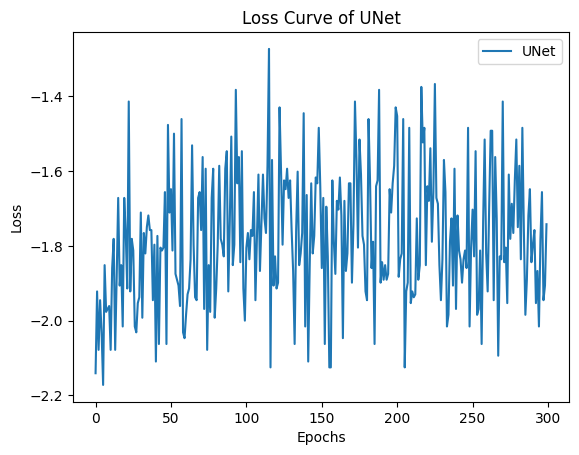

In [4]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['unet']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='UNet')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of UNet')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

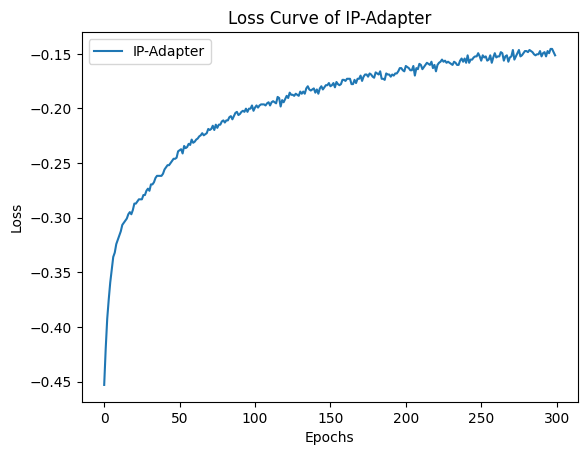

In [5]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IP-Adapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IP-Adapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## agm(UNet+CLIP)+Cosine
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_unet-ipadapter_yingbu_agm_cosine_eot-1_sds-0_unT-unet-0

In [6]:
loss_dict_list = [{'loss_sum': 0.1337890625, 'loss': 0.0007071949075907469, 'unet': 0.000701904296875, 'ipadapter': 0.1328125}, {'loss_sum': 0.1630859375, 'loss': 0.033083099871873856, 'unet': 0.031005859375, 'ipadapter': 0.1318359375}, {'loss_sum': 0.1767578125, 'loss': 0.045199088752269745, 'unet': 0.034912109375, 'ipadapter': 0.1416015625}, {'loss_sum': 0.224609375, 'loss': 0.09227976202964783, 'unet': 0.07080078125, 'ipadapter': 0.1533203125}, {'loss_sum': 0.21875, 'loss': 0.10482604056596756, 'unet': 0.05078125, 'ipadapter': 0.16796875}, {'loss_sum': 0.208984375, 'loss': 0.11999009549617767, 'unet': 0.0224609375, 'ipadapter': 0.1865234375}, {'loss_sum': 0.271484375, 'loss': 0.13859117031097412, 'unet': 0.060791015625, 'ipadapter': 0.2109375}, {'loss_sum': 0.302734375, 'loss': 0.14975234866142273, 'unet': 0.07568359375, 'ipadapter': 0.2275390625}, {'loss_sum': 0.310546875, 'loss': 0.1605396270751953, 'unet': 0.068359375, 'ipadapter': 0.2421875}, {'loss_sum': 0.306640625, 'loss': 0.10913629829883575, 'unet': 0.045166015625, 'ipadapter': 0.26171875}, {'loss_sum': 0.39453125, 'loss': 0.16773459315299988, 'unet': 0.11181640625, 'ipadapter': 0.283203125}, {'loss_sum': 0.4609375, 'loss': 0.21126174926757812, 'unet': 0.158203125, 'ipadapter': 0.302734375}, {'loss_sum': 0.44921875, 'loss': 0.1886017918586731, 'unet': 0.134765625, 'ipadapter': 0.314453125}, {'loss_sum': 0.43359375, 'loss': 0.16540926694869995, 'unet': 0.1044921875, 'ipadapter': 0.330078125}, {'loss_sum': 0.42578125, 'loss': 0.14708051085472107, 'unet': 0.080078125, 'ipadapter': 0.345703125}, {'loss_sum': 0.490234375, 'loss': 0.19136053323745728, 'unet': 0.13671875, 'ipadapter': 0.353515625}, {'loss_sum': 0.45703125, 'loss': 0.20645742118358612, 'unet': 0.09228515625, 'ipadapter': 0.365234375}, {'loss_sum': 0.431640625, 'loss': 0.19740374386310577, 'unet': 0.056396484375, 'ipadapter': 0.375}, {'loss_sum': 0.53515625, 'loss': 0.26429784297943115, 'unet': 0.1533203125, 'ipadapter': 0.3828125}, {'loss_sum': 0.46875, 'loss': 0.18065866827964783, 'unet': 0.07421875, 'ipadapter': 0.39453125}, {'loss_sum': 0.515625, 'loss': 0.15956780314445496, 'unet': 0.11083984375, 'ipadapter': 0.40625}, {'loss_sum': 0.53515625, 'loss': 0.25750043988227844, 'unet': 0.12158203125, 'ipadapter': 0.4140625}, {'loss_sum': 0.5546875, 'loss': 0.2467128038406372, 'unet': 0.134765625, 'ipadapter': 0.41796875}, {'loss_sum': 0.578125, 'loss': 0.24177706241607666, 'unet': 0.146484375, 'ipadapter': 0.4296875}, {'loss_sum': 0.60546875, 'loss': 0.25101274251937866, 'unet': 0.171875, 'ipadapter': 0.43359375}, {'loss_sum': 0.58984375, 'loss': 0.24851064383983612, 'unet': 0.154296875, 'ipadapter': 0.435546875}, {'loss_sum': 0.5625, 'loss': 0.24104750156402588, 'unet': 0.12109375, 'ipadapter': 0.44140625}, {'loss_sum': 0.60546875, 'loss': 0.2547680735588074, 'unet': 0.15625, 'ipadapter': 0.44921875}, {'loss_sum': 0.50390625, 'loss': 0.25564050674438477, 'unet': 0.04345703125, 'ipadapter': 0.458984375}, {'loss_sum': 0.59375, 'loss': 0.2638939321041107, 'unet': 0.1337890625, 'ipadapter': 0.458984375}, {'loss_sum': 0.6640625, 'loss': 0.28784286975860596, 'unet': 0.19921875, 'ipadapter': 0.46484375}, {'loss_sum': 0.578125, 'loss': 0.21294179558753967, 'unet': 0.1064453125, 'ipadapter': 0.47265625}, {'loss_sum': 0.6015625, 'loss': 0.23273038864135742, 'unet': 0.1259765625, 'ipadapter': 0.474609375}, {'loss_sum': 0.5703125, 'loss': 0.23232130706310272, 'unet': 0.09326171875, 'ipadapter': 0.478515625}, {'loss_sum': 0.6484375, 'loss': 0.32689499855041504, 'unet': 0.169921875, 'ipadapter': 0.4765625}, {'loss_sum': 0.63671875, 'loss': 0.24864168465137482, 'unet': 0.15234375, 'ipadapter': 0.484375}, {'loss_sum': 0.57421875, 'loss': 0.1671200692653656, 'unet': 0.08447265625, 'ipadapter': 0.490234375}, {'loss_sum': 0.59375, 'loss': 0.2811944782733917, 'unet': 0.103515625, 'ipadapter': 0.4921875}, {'loss_sum': 0.60546875, 'loss': 0.3408415615558624, 'unet': 0.11474609375, 'ipadapter': 0.4921875}, {'loss_sum': 0.62109375, 'loss': 0.20472975075244904, 'unet': 0.11279296875, 'ipadapter': 0.5078125}, {'loss_sum': 0.703125, 'loss': 0.31679150462150574, 'unet': 0.189453125, 'ipadapter': 0.51171875}, {'loss_sum': 0.63671875, 'loss': 0.24835455417633057, 'unet': 0.1259765625, 'ipadapter': 0.51171875}, {'loss_sum': 0.6796875, 'loss': 0.24219629168510437, 'unet': 0.16015625, 'ipadapter': 0.51953125}, {'loss_sum': 0.65625, 'loss': 0.2395632266998291, 'unet': 0.1298828125, 'ipadapter': 0.52734375}, {'loss_sum': 0.59765625, 'loss': 0.27315324544906616, 'unet': 0.08349609375, 'ipadapter': 0.515625}, {'loss_sum': 0.671875, 'loss': 0.3159354627132416, 'unet': 0.146484375, 'ipadapter': 0.5234375}, {'loss_sum': 0.671875, 'loss': 0.2756142318248749, 'unet': 0.1494140625, 'ipadapter': 0.5234375}, {'loss_sum': 0.6484375, 'loss': 0.24402447044849396, 'unet': 0.11279296875, 'ipadapter': 0.53515625}, {'loss_sum': 0.67578125, 'loss': 0.3018147945404053, 'unet': 0.1357421875, 'ipadapter': 0.5390625}, {'loss_sum': 0.7109375, 'loss': 0.28832781314849854, 'unet': 0.1728515625, 'ipadapter': 0.5390625}, {'loss_sum': 0.703125, 'loss': 0.2545316219329834, 'unet': 0.1640625, 'ipadapter': 0.5390625}, {'loss_sum': 0.73828125, 'loss': 0.3009452819824219, 'unet': 0.1875, 'ipadapter': 0.55078125}, {'loss_sum': 0.73828125, 'loss': 0.29135459661483765, 'unet': 0.1953125, 'ipadapter': 0.54296875}, {'loss_sum': 0.67578125, 'loss': 0.2913452684879303, 'unet': 0.125, 'ipadapter': 0.55078125}, {'loss_sum': 0.74609375, 'loss': 0.30697596073150635, 'unet': 0.1923828125, 'ipadapter': 0.5546875}, {'loss_sum': 0.6640625, 'loss': 0.17477211356163025, 'unet': 0.107421875, 'ipadapter': 0.55859375}, {'loss_sum': 0.69921875, 'loss': 0.29180219769477844, 'unet': 0.1396484375, 'ipadapter': 0.55859375}, {'loss_sum': 0.78125, 'loss': 0.34707406163215637, 'unet': 0.22265625, 'ipadapter': 0.55859375}, {'loss_sum': 0.7265625, 'loss': 0.25005578994750977, 'unet': 0.1572265625, 'ipadapter': 0.5703125}, {'loss_sum': 0.75, 'loss': 0.3693208694458008, 'unet': 0.185546875, 'ipadapter': 0.56640625}, {'loss_sum': 0.73828125, 'loss': 0.2793894410133362, 'unet': 0.1728515625, 'ipadapter': 0.56640625}, {'loss_sum': 0.71875, 'loss': 0.3158769905567169, 'unet': 0.1474609375, 'ipadapter': 0.5703125}, {'loss_sum': 0.66015625, 'loss': 0.33374613523483276, 'unet': 0.09912109375, 'ipadapter': 0.5625}, {'loss_sum': 0.6953125, 'loss': 0.2955738604068756, 'unet': 0.130859375, 'ipadapter': 0.5625}, {'loss_sum': 0.796875, 'loss': 0.36183232069015503, 'unet': 0.228515625, 'ipadapter': 0.5703125}, {'loss_sum': 0.72265625, 'loss': 0.2633601427078247, 'unet': 0.1435546875, 'ipadapter': 0.578125}, {'loss_sum': 0.6640625, 'loss': 0.23869474232196808, 'unet': 0.09033203125, 'ipadapter': 0.57421875}, {'loss_sum': 0.67578125, 'loss': 0.20235374569892883, 'unet': 0.10107421875, 'ipadapter': 0.57421875}, {'loss_sum': 0.6796875, 'loss': 0.3142582178115845, 'unet': 0.10693359375, 'ipadapter': 0.57421875}, {'loss_sum': 0.68359375, 'loss': 0.29569000005722046, 'unet': 0.1015625, 'ipadapter': 0.58203125}, {'loss_sum': 0.66796875, 'loss': 0.24661380052566528, 'unet': 0.08447265625, 'ipadapter': 0.58203125}, {'loss_sum': 0.74609375, 'loss': 0.3136192560195923, 'unet': 0.1650390625, 'ipadapter': 0.58203125}, {'loss_sum': 0.6875, 'loss': 0.20881134271621704, 'unet': 0.091796875, 'ipadapter': 0.59375}, {'loss_sum': 0.6953125, 'loss': 0.3086532652378082, 'unet': 0.10693359375, 'ipadapter': 0.58984375}, {'loss_sum': 0.80078125, 'loss': 0.3126193881034851, 'unet': 0.2119140625, 'ipadapter': 0.58984375}, {'loss_sum': 0.765625, 'loss': 0.33570149540901184, 'unet': 0.1728515625, 'ipadapter': 0.59375}, {'loss_sum': 0.71875, 'loss': 0.31199681758880615, 'unet': 0.1220703125, 'ipadapter': 0.59765625}, {'loss_sum': 0.7421875, 'loss': 0.24510341882705688, 'unet': 0.154296875, 'ipadapter': 0.5859375}, {'loss_sum': 0.765625, 'loss': 0.3111617863178253, 'unet': 0.1640625, 'ipadapter': 0.6015625}, {'loss_sum': 0.76953125, 'loss': 0.3199254870414734, 'unet': 0.1748046875, 'ipadapter': 0.59375}, {'loss_sum': 0.73828125, 'loss': 0.27717331051826477, 'unet': 0.13671875, 'ipadapter': 0.6015625}, {'loss_sum': 0.625, 'loss': 0.35795077681541443, 'unet': 0.03759765625, 'ipadapter': 0.5859375}, {'loss_sum': 0.7109375, 'loss': 0.3492014408111572, 'unet': 0.1162109375, 'ipadapter': 0.59375}, {'loss_sum': 0.77734375, 'loss': 0.345944344997406, 'unet': 0.1845703125, 'ipadapter': 0.59375}, {'loss_sum': 0.6953125, 'loss': 0.18719924986362457, 'unet': 0.095703125, 'ipadapter': 0.59765625}, {'loss_sum': 0.765625, 'loss': 0.37606194615364075, 'unet': 0.1630859375, 'ipadapter': 0.6015625}, {'loss_sum': 0.73046875, 'loss': 0.23152506351470947, 'unet': 0.1259765625, 'ipadapter': 0.60546875}, {'loss_sum': 0.7109375, 'loss': 0.25401169061660767, 'unet': 0.0986328125, 'ipadapter': 0.61328125}, {'loss_sum': 0.83203125, 'loss': 0.3215497136116028, 'unet': 0.23046875, 'ipadapter': 0.6015625}, {'loss_sum': 0.796875, 'loss': 0.33824536204338074, 'unet': 0.1767578125, 'ipadapter': 0.62109375}, {'loss_sum': 0.72265625, 'loss': 0.3130894899368286, 'unet': 0.11865234375, 'ipadapter': 0.60546875}, {'loss_sum': 0.76171875, 'loss': 0.3692133128643036, 'unet': 0.1611328125, 'ipadapter': 0.6015625}, {'loss_sum': 0.69140625, 'loss': 0.31925320625305176, 'unet': 0.0732421875, 'ipadapter': 0.6171875}, {'loss_sum': 0.765625, 'loss': 0.3031432628631592, 'unet': 0.1572265625, 'ipadapter': 0.609375}, {'loss_sum': 0.73828125, 'loss': 0.3579961657524109, 'unet': 0.12255859375, 'ipadapter': 0.6171875}, {'loss_sum': 0.65625, 'loss': 0.1412138044834137, 'unet': 0.042724609375, 'ipadapter': 0.61328125}, {'loss_sum': 0.7265625, 'loss': 0.31980034708976746, 'unet': 0.11865234375, 'ipadapter': 0.609375}, {'loss_sum': 0.72265625, 'loss': 0.2959846258163452, 'unet': 0.10888671875, 'ipadapter': 0.61328125}, {'loss_sum': 0.73046875, 'loss': 0.29246601462364197, 'unet': 0.11572265625, 'ipadapter': 0.61328125}, {'loss_sum': 0.6796875, 'loss': 0.3024470806121826, 'unet': 0.07958984375, 'ipadapter': 0.6015625}, {'loss_sum': 0.7421875, 'loss': 0.2593575716018677, 'unet': 0.126953125, 'ipadapter': 0.61328125}, {'loss_sum': 0.7734375, 'loss': 0.22631263732910156, 'unet': 0.158203125, 'ipadapter': 0.6171875}, {'loss_sum': 0.7421875, 'loss': 0.2066592425107956, 'unet': 0.11279296875, 'ipadapter': 0.62890625}, {'loss_sum': 0.7421875, 'loss': 0.1827641725540161, 'unet': 0.11865234375, 'ipadapter': 0.625}, {'loss_sum': 0.70703125, 'loss': 0.25085580348968506, 'unet': 0.0771484375, 'ipadapter': 0.62890625}, {'loss_sum': 0.734375, 'loss': 0.2567400634288788, 'unet': 0.1171875, 'ipadapter': 0.6171875}, {'loss_sum': 0.75, 'loss': 0.33223336935043335, 'unet': 0.12451171875, 'ipadapter': 0.625}, {'loss_sum': 0.72265625, 'loss': 0.2834773361682892, 'unet': 0.10107421875, 'ipadapter': 0.62109375}, {'loss_sum': 0.734375, 'loss': 0.296095073223114, 'unet': 0.099609375, 'ipadapter': 0.6328125}, {'loss_sum': 0.81640625, 'loss': 0.28150779008865356, 'unet': 0.1904296875, 'ipadapter': 0.625}, {'loss_sum': 0.8125, 'loss': 0.2971522808074951, 'unet': 0.1748046875, 'ipadapter': 0.63671875}, {'loss_sum': 0.76171875, 'loss': 0.3745737075805664, 'unet': 0.125, 'ipadapter': 0.63671875}, {'loss_sum': 0.765625, 'loss': 0.39989012479782104, 'unet': 0.138671875, 'ipadapter': 0.625}, {'loss_sum': 0.6875, 'loss': 0.12960761785507202, 'unet': 0.057861328125, 'ipadapter': 0.62890625}, {'loss_sum': 0.7890625, 'loss': 0.2597895860671997, 'unet': 0.1572265625, 'ipadapter': 0.6328125}, {'loss_sum': 0.75, 'loss': 0.3139229416847229, 'unet': 0.11376953125, 'ipadapter': 0.63671875}, {'loss_sum': 0.703125, 'loss': 0.23108309507369995, 'unet': 0.0791015625, 'ipadapter': 0.625}, {'loss_sum': 0.75, 'loss': 0.31644317507743835, 'unet': 0.11181640625, 'ipadapter': 0.63671875}, {'loss_sum': 0.7265625, 'loss': 0.16975204646587372, 'unet': 0.091796875, 'ipadapter': 0.63671875}, {'loss_sum': 0.78125, 'loss': 0.22462570667266846, 'unet': 0.1416015625, 'ipadapter': 0.640625}, {'loss_sum': 0.75390625, 'loss': 0.3009546399116516, 'unet': 0.10791015625, 'ipadapter': 0.64453125}, {'loss_sum': 0.7734375, 'loss': 0.3042841851711273, 'unet': 0.1318359375, 'ipadapter': 0.640625}, {'loss_sum': 0.73046875, 'loss': 0.31907275319099426, 'unet': 0.09375, 'ipadapter': 0.63671875}, {'loss_sum': 0.71484375, 'loss': 0.19983676075935364, 'unet': 0.0849609375, 'ipadapter': 0.62890625}, {'loss_sum': 0.74609375, 'loss': 0.3283641040325165, 'unet': 0.10498046875, 'ipadapter': 0.640625}, {'loss_sum': 0.79296875, 'loss': 0.3060874938964844, 'unet': 0.15234375, 'ipadapter': 0.640625}, {'loss_sum': 0.7421875, 'loss': 0.2758142948150635, 'unet': 0.095703125, 'ipadapter': 0.6484375}, {'loss_sum': 0.75, 'loss': 0.3171001672744751, 'unet': 0.099609375, 'ipadapter': 0.6484375}, {'loss_sum': 0.74609375, 'loss': 0.30009302496910095, 'unet': 0.1083984375, 'ipadapter': 0.63671875}, {'loss_sum': 0.8046875, 'loss': 0.3202701210975647, 'unet': 0.162109375, 'ipadapter': 0.64453125}, {'loss_sum': 0.75390625, 'loss': 0.24855545163154602, 'unet': 0.10791015625, 'ipadapter': 0.64453125}, {'loss_sum': 0.765625, 'loss': 0.23728854954242706, 'unet': 0.1162109375, 'ipadapter': 0.6484375}, {'loss_sum': 0.74609375, 'loss': 0.373779296875, 'unet': 0.10302734375, 'ipadapter': 0.64453125}, {'loss_sum': 0.765625, 'loss': 0.28503307700157166, 'unet': 0.11572265625, 'ipadapter': 0.6484375}, {'loss_sum': 0.76171875, 'loss': 0.2194783091545105, 'unet': 0.10693359375, 'ipadapter': 0.65625}, {'loss_sum': 0.77734375, 'loss': 0.24277463555335999, 'unet': 0.11962890625, 'ipadapter': 0.65625}, {'loss_sum': 0.75, 'loss': 0.2577935457229614, 'unet': 0.09375, 'ipadapter': 0.65625}, {'loss_sum': 0.77734375, 'loss': 0.22642675042152405, 'unet': 0.1328125, 'ipadapter': 0.64453125}, {'loss_sum': 0.7265625, 'loss': 0.3404152989387512, 'unet': 0.076171875, 'ipadapter': 0.65234375}, {'loss_sum': 0.80859375, 'loss': 0.356418639421463, 'unet': 0.1728515625, 'ipadapter': 0.63671875}, {'loss_sum': 0.79296875, 'loss': 0.3167662024497986, 'unet': 0.14453125, 'ipadapter': 0.6484375}, {'loss_sum': 0.796875, 'loss': 0.3430249094963074, 'unet': 0.1435546875, 'ipadapter': 0.65234375}, {'loss_sum': 0.83984375, 'loss': 0.3470502495765686, 'unet': 0.1962890625, 'ipadapter': 0.64453125}, {'loss_sum': 0.78515625, 'loss': 0.2914392352104187, 'unet': 0.1279296875, 'ipadapter': 0.65625}, {'loss_sum': 0.80078125, 'loss': 0.246130108833313, 'unet': 0.14453125, 'ipadapter': 0.65625}, {'loss_sum': 0.78515625, 'loss': 0.3915099799633026, 'unet': 0.1259765625, 'ipadapter': 0.66015625}, {'loss_sum': 0.7734375, 'loss': 0.3112552762031555, 'unet': 0.123046875, 'ipadapter': 0.65234375}, {'loss_sum': 0.7421875, 'loss': 0.15141379833221436, 'unet': 0.09130859375, 'ipadapter': 0.65234375}, {'loss_sum': 0.7578125, 'loss': 0.22519508004188538, 'unet': 0.10107421875, 'ipadapter': 0.65625}, {'loss_sum': 0.80078125, 'loss': 0.3431262671947479, 'unet': 0.14453125, 'ipadapter': 0.65625}, {'loss_sum': 0.7734375, 'loss': 0.3267946243286133, 'unet': 0.1181640625, 'ipadapter': 0.65625}, {'loss_sum': 0.75, 'loss': 0.21650370955467224, 'unet': 0.10205078125, 'ipadapter': 0.6484375}, {'loss_sum': 0.7734375, 'loss': 0.3355986475944519, 'unet': 0.1171875, 'ipadapter': 0.65625}, {'loss_sum': 0.734375, 'loss': 0.18202424049377441, 'unet': 0.080078125, 'ipadapter': 0.65234375}, {'loss_sum': 0.77734375, 'loss': 0.20650756359100342, 'unet': 0.12060546875, 'ipadapter': 0.65625}, {'loss_sum': 0.7734375, 'loss': 0.22551986575126648, 'unet': 0.11279296875, 'ipadapter': 0.66015625}, {'loss_sum': 0.8046875, 'loss': 0.37094974517822266, 'unet': 0.1484375, 'ipadapter': 0.65625}, {'loss_sum': 0.8125, 'loss': 0.3598896861076355, 'unet': 0.1552734375, 'ipadapter': 0.65625}, {'loss_sum': 0.77734375, 'loss': 0.3123925030231476, 'unet': 0.1201171875, 'ipadapter': 0.65625}, {'loss_sum': 0.8046875, 'loss': 0.2865387201309204, 'unet': 0.1484375, 'ipadapter': 0.65625}, {'loss_sum': 0.7890625, 'loss': 0.22844195365905762, 'unet': 0.1259765625, 'ipadapter': 0.6640625}, {'loss_sum': 0.828125, 'loss': 0.31920021772384644, 'unet': 0.1572265625, 'ipadapter': 0.671875}, {'loss_sum': 0.8828125, 'loss': 0.35825103521347046, 'unet': 0.21875, 'ipadapter': 0.6640625}, {'loss_sum': 0.7890625, 'loss': 0.29139554500579834, 'unet': 0.1162109375, 'ipadapter': 0.671875}, {'loss_sum': 0.78515625, 'loss': 0.21945957839488983, 'unet': 0.125, 'ipadapter': 0.66015625}, {'loss_sum': 0.765625, 'loss': 0.2619774639606476, 'unet': 0.099609375, 'ipadapter': 0.66796875}, {'loss_sum': 0.8515625, 'loss': 0.35626235604286194, 'unet': 0.1923828125, 'ipadapter': 0.66015625}, {'loss_sum': 0.80078125, 'loss': 0.2465832531452179, 'unet': 0.1357421875, 'ipadapter': 0.6640625}, {'loss_sum': 0.85546875, 'loss': 0.30045610666275024, 'unet': 0.19140625, 'ipadapter': 0.6640625}, {'loss_sum': 0.859375, 'loss': 0.3335148096084595, 'unet': 0.1953125, 'ipadapter': 0.6640625}, {'loss_sum': 0.8203125, 'loss': 0.280478298664093, 'unet': 0.1572265625, 'ipadapter': 0.6640625}, {'loss_sum': 0.7421875, 'loss': 0.16726967692375183, 'unet': 0.08837890625, 'ipadapter': 0.65234375}, {'loss_sum': 0.875, 'loss': 0.3795129358768463, 'unet': 0.21484375, 'ipadapter': 0.66015625}, {'loss_sum': 0.8046875, 'loss': 0.27945950627326965, 'unet': 0.138671875, 'ipadapter': 0.66796875}, {'loss_sum': 0.8125, 'loss': 0.3710728585720062, 'unet': 0.1650390625, 'ipadapter': 0.6484375}, {'loss_sum': 0.73828125, 'loss': 0.3514634668827057, 'unet': 0.0859375, 'ipadapter': 0.65234375}, {'loss_sum': 0.7578125, 'loss': 0.37841796875, 'unet': 0.1083984375, 'ipadapter': 0.6484375}, {'loss_sum': 0.734375, 'loss': 0.3400667905807495, 'unet': 0.080078125, 'ipadapter': 0.65234375}, {'loss_sum': 0.74609375, 'loss': 0.3720094859600067, 'unet': 0.0986328125, 'ipadapter': 0.6484375}, {'loss_sum': 0.828125, 'loss': 0.2471676766872406, 'unet': 0.171875, 'ipadapter': 0.65625}, {'loss_sum': 0.76171875, 'loss': 0.33157873153686523, 'unet': 0.0888671875, 'ipadapter': 0.671875}, {'loss_sum': 0.8046875, 'loss': 0.2599596381187439, 'unet': 0.1416015625, 'ipadapter': 0.6640625}, {'loss_sum': 0.7578125, 'loss': 0.17400304973125458, 'unet': 0.087890625, 'ipadapter': 0.671875}, {'loss_sum': 0.79296875, 'loss': 0.2626307010650635, 'unet': 0.1357421875, 'ipadapter': 0.65625}, {'loss_sum': 0.78125, 'loss': 0.2752722501754761, 'unet': 0.11669921875, 'ipadapter': 0.6640625}, {'loss_sum': 0.78515625, 'loss': 0.3034900426864624, 'unet': 0.11328125, 'ipadapter': 0.671875}, {'loss_sum': 0.765625, 'loss': 0.2932511568069458, 'unet': 0.10107421875, 'ipadapter': 0.6640625}, {'loss_sum': 0.84375, 'loss': 0.28098517656326294, 'unet': 0.17578125, 'ipadapter': 0.66796875}, {'loss_sum': 0.828125, 'loss': 0.3522959053516388, 'unet': 0.150390625, 'ipadapter': 0.6796875}, {'loss_sum': 0.85546875, 'loss': 0.3768012523651123, 'unet': 0.1845703125, 'ipadapter': 0.671875}, {'loss_sum': 0.796875, 'loss': 0.31241804361343384, 'unet': 0.125, 'ipadapter': 0.671875}, {'loss_sum': 0.7734375, 'loss': 0.2206408679485321, 'unet': 0.11669921875, 'ipadapter': 0.65625}, {'loss_sum': 0.83203125, 'loss': 0.32077258825302124, 'unet': 0.1640625, 'ipadapter': 0.66796875}, {'loss_sum': 0.80078125, 'loss': 0.22386032342910767, 'unet': 0.11962890625, 'ipadapter': 0.6796875}, {'loss_sum': 0.8046875, 'loss': 0.33204811811447144, 'unet': 0.138671875, 'ipadapter': 0.6640625}, {'loss_sum': 0.77734375, 'loss': 0.3231559991836548, 'unet': 0.1064453125, 'ipadapter': 0.671875}, {'loss_sum': 0.7578125, 'loss': 0.253506064414978, 'unet': 0.087890625, 'ipadapter': 0.66796875}, {'loss_sum': 0.828125, 'loss': 0.30923426151275635, 'unet': 0.1650390625, 'ipadapter': 0.6640625}, {'loss_sum': 0.80078125, 'loss': 0.23128767311573029, 'unet': 0.1298828125, 'ipadapter': 0.671875}, {'loss_sum': 0.796875, 'loss': 0.2372245192527771, 'unet': 0.12158203125, 'ipadapter': 0.67578125}, {'loss_sum': 0.84375, 'loss': 0.2917530834674835, 'unet': 0.177734375, 'ipadapter': 0.66796875}, {'loss_sum': 0.734375, 'loss': 0.21377137303352356, 'unet': 0.06494140625, 'ipadapter': 0.66796875}, {'loss_sum': 0.828125, 'loss': 0.3448134660720825, 'unet': 0.17578125, 'ipadapter': 0.65234375}, {'loss_sum': 0.87109375, 'loss': 0.31873998045921326, 'unet': 0.20703125, 'ipadapter': 0.6640625}, {'loss_sum': 0.7578125, 'loss': 0.2924227714538574, 'unet': 0.095703125, 'ipadapter': 0.66015625}, {'loss_sum': 0.765625, 'loss': 0.253736674785614, 'unet': 0.111328125, 'ipadapter': 0.65234375}, {'loss_sum': 0.79296875, 'loss': 0.32596927881240845, 'unet': 0.1357421875, 'ipadapter': 0.65625}, {'loss_sum': 0.8125, 'loss': 0.24599850177764893, 'unet': 0.1513671875, 'ipadapter': 0.66015625}, {'loss_sum': 0.78125, 'loss': 0.3022525906562805, 'unet': 0.115234375, 'ipadapter': 0.66796875}, {'loss_sum': 0.83203125, 'loss': 0.37066876888275146, 'unet': 0.17578125, 'ipadapter': 0.65625}, {'loss_sum': 0.75390625, 'loss': 0.17649836838245392, 'unet': 0.09423828125, 'ipadapter': 0.66015625}, {'loss_sum': 0.84375, 'loss': 0.3280918002128601, 'unet': 0.1767578125, 'ipadapter': 0.66796875}, {'loss_sum': 0.88671875, 'loss': 0.3853832185268402, 'unet': 0.2177734375, 'ipadapter': 0.66796875}, {'loss_sum': 0.82421875, 'loss': 0.32299867272377014, 'unet': 0.1552734375, 'ipadapter': 0.66796875}, {'loss_sum': 0.75, 'loss': 0.228056862950325, 'unet': 0.07568359375, 'ipadapter': 0.67578125}, {'loss_sum': 0.7734375, 'loss': 0.25943446159362793, 'unet': 0.11328125, 'ipadapter': 0.66015625}, {'loss_sum': 0.80859375, 'loss': 0.32290613651275635, 'unet': 0.1396484375, 'ipadapter': 0.66796875}, {'loss_sum': 0.83984375, 'loss': 0.34300845861434937, 'unet': 0.17578125, 'ipadapter': 0.6640625}, {'loss_sum': 0.83203125, 'loss': 0.32572463154792786, 'unet': 0.1689453125, 'ipadapter': 0.6640625}, {'loss_sum': 0.859375, 'loss': 0.3408358693122864, 'unet': 0.18359375, 'ipadapter': 0.67578125}, {'loss_sum': 0.8203125, 'loss': 0.31046247482299805, 'unet': 0.1396484375, 'ipadapter': 0.6796875}, {'loss_sum': 0.8359375, 'loss': 0.4105510115623474, 'unet': 0.1591796875, 'ipadapter': 0.67578125}, {'loss_sum': 0.8203125, 'loss': 0.34067827463150024, 'unet': 0.1494140625, 'ipadapter': 0.671875}, {'loss_sum': 0.7734375, 'loss': 0.2108662724494934, 'unet': 0.103515625, 'ipadapter': 0.671875}, {'loss_sum': 0.82421875, 'loss': 0.4144967794418335, 'unet': 0.1484375, 'ipadapter': 0.67578125}, {'loss_sum': 0.80859375, 'loss': 0.2713916301727295, 'unet': 0.1376953125, 'ipadapter': 0.671875}, {'loss_sum': 0.84375, 'loss': 0.383129358291626, 'unet': 0.1591796875, 'ipadapter': 0.68359375}, {'loss_sum': 0.80078125, 'loss': 0.20015139877796173, 'unet': 0.11962890625, 'ipadapter': 0.6796875}, {'loss_sum': 0.80859375, 'loss': 0.2478751540184021, 'unet': 0.11865234375, 'ipadapter': 0.69140625}, {'loss_sum': 0.83203125, 'loss': 0.237412229180336, 'unet': 0.1455078125, 'ipadapter': 0.6875}, {'loss_sum': 0.828125, 'loss': 0.3906603157520294, 'unet': 0.146484375, 'ipadapter': 0.68359375}, {'loss_sum': 0.859375, 'loss': 0.2797049880027771, 'unet': 0.1767578125, 'ipadapter': 0.68359375}, {'loss_sum': 0.8046875, 'loss': 0.20339858531951904, 'unet': 0.11669921875, 'ipadapter': 0.6875}, {'loss_sum': 0.875, 'loss': 0.35380494594573975, 'unet': 0.1943359375, 'ipadapter': 0.6796875}, {'loss_sum': 0.8359375, 'loss': 0.3583602011203766, 'unet': 0.1611328125, 'ipadapter': 0.67578125}, {'loss_sum': 0.80078125, 'loss': 0.32321423292160034, 'unet': 0.1357421875, 'ipadapter': 0.6640625}, {'loss_sum': 0.8203125, 'loss': 0.3819703161716461, 'unet': 0.162109375, 'ipadapter': 0.66015625}, {'loss_sum': 0.7578125, 'loss': 0.33099326491355896, 'unet': 0.08740234375, 'ipadapter': 0.671875}, {'loss_sum': 0.765625, 'loss': 0.34995871782302856, 'unet': 0.10302734375, 'ipadapter': 0.6640625}, {'loss_sum': 0.80078125, 'loss': 0.37071922421455383, 'unet': 0.12158203125, 'ipadapter': 0.6796875}, {'loss_sum': 0.78515625, 'loss': 0.3579811453819275, 'unet': 0.11328125, 'ipadapter': 0.671875}, {'loss_sum': 0.87109375, 'loss': 0.3735021948814392, 'unet': 0.1982421875, 'ipadapter': 0.671875}, {'loss_sum': 0.78125, 'loss': 0.33189553022384644, 'unet': 0.099609375, 'ipadapter': 0.68359375}, {'loss_sum': 0.74609375, 'loss': 0.12725397944450378, 'unet': 0.07568359375, 'ipadapter': 0.671875}, {'loss_sum': 0.8125, 'loss': 0.33207687735557556, 'unet': 0.1396484375, 'ipadapter': 0.671875}, {'loss_sum': 0.78125, 'loss': 0.20777077972888947, 'unet': 0.1103515625, 'ipadapter': 0.671875}, {'loss_sum': 0.78125, 'loss': 0.3896484375, 'unet': 0.103515625, 'ipadapter': 0.67578125}, {'loss_sum': 0.875, 'loss': 0.3932296335697174, 'unet': 0.1923828125, 'ipadapter': 0.68359375}, {'loss_sum': 0.79296875, 'loss': 0.30526524782180786, 'unet': 0.1103515625, 'ipadapter': 0.68359375}, {'loss_sum': 0.8125, 'loss': 0.29934531450271606, 'unet': 0.13671875, 'ipadapter': 0.67578125}, {'loss_sum': 0.77734375, 'loss': 0.29264163970947266, 'unet': 0.0947265625, 'ipadapter': 0.68359375}, {'loss_sum': 0.8125, 'loss': 0.3290714621543884, 'unet': 0.140625, 'ipadapter': 0.671875}, {'loss_sum': 0.875, 'loss': 0.3811624348163605, 'unet': 0.193359375, 'ipadapter': 0.68359375}, {'loss_sum': 0.84375, 'loss': 0.24185702204704285, 'unet': 0.1552734375, 'ipadapter': 0.6875}, {'loss_sum': 0.8515625, 'loss': 0.36522164940834045, 'unet': 0.1630859375, 'ipadapter': 0.6875}, {'loss_sum': 0.83984375, 'loss': 0.4129617214202881, 'unet': 0.1611328125, 'ipadapter': 0.6796875}, {'loss_sum': 0.8359375, 'loss': 0.3457145094871521, 'unet': 0.1494140625, 'ipadapter': 0.6875}, {'loss_sum': 0.86328125, 'loss': 0.2939307689666748, 'unet': 0.1767578125, 'ipadapter': 0.6875}, {'loss_sum': 0.9375, 'loss': 0.3719141483306885, 'unet': 0.236328125, 'ipadapter': 0.69921875}, {'loss_sum': 0.921875, 'loss': 0.36061787605285645, 'unet': 0.2275390625, 'ipadapter': 0.6953125}, {'loss_sum': 0.80078125, 'loss': 0.2603588402271271, 'unet': 0.10107421875, 'ipadapter': 0.69921875}, {'loss_sum': 0.8203125, 'loss': 0.24877873063087463, 'unet': 0.138671875, 'ipadapter': 0.68359375}, {'loss_sum': 0.78125, 'loss': 0.23541411757469177, 'unet': 0.0927734375, 'ipadapter': 0.6875}, {'loss_sum': 0.82421875, 'loss': 0.314754843711853, 'unet': 0.14453125, 'ipadapter': 0.6796875}, {'loss_sum': 0.84375, 'loss': 0.33921337127685547, 'unet': 0.150390625, 'ipadapter': 0.69140625}, {'loss_sum': 0.828125, 'loss': 0.372394323348999, 'unet': 0.142578125, 'ipadapter': 0.6875}, {'loss_sum': 0.77734375, 'loss': 0.3713843524456024, 'unet': 0.08154296875, 'ipadapter': 0.6953125}, {'loss_sum': 0.80078125, 'loss': 0.2143556773662567, 'unet': 0.1162109375, 'ipadapter': 0.68359375}, {'loss_sum': 0.8828125, 'loss': 0.3773645758628845, 'unet': 0.19140625, 'ipadapter': 0.69140625}, {'loss_sum': 0.828125, 'loss': 0.2752641439437866, 'unet': 0.13671875, 'ipadapter': 0.69140625}, {'loss_sum': 0.828125, 'loss': 0.2399958372116089, 'unet': 0.1435546875, 'ipadapter': 0.68359375}, {'loss_sum': 0.8203125, 'loss': 0.3836691677570343, 'unet': 0.12890625, 'ipadapter': 0.69140625}, {'loss_sum': 0.8359375, 'loss': 0.32486817240715027, 'unet': 0.1474609375, 'ipadapter': 0.6875}, {'loss_sum': 0.7421875, 'loss': 0.3138432800769806, 'unet': 0.060546875, 'ipadapter': 0.6796875}, {'loss_sum': 0.859375, 'loss': 0.3391960561275482, 'unet': 0.177734375, 'ipadapter': 0.68359375}, {'loss_sum': 0.81640625, 'loss': 0.41439521312713623, 'unet': 0.1328125, 'ipadapter': 0.68359375}, {'loss_sum': 0.7890625, 'loss': 0.3080138564109802, 'unet': 0.1044921875, 'ipadapter': 0.68359375}, {'loss_sum': 0.859375, 'loss': 0.2574652135372162, 'unet': 0.1728515625, 'ipadapter': 0.6875}, {'loss_sum': 0.83984375, 'loss': 0.276900053024292, 'unet': 0.1376953125, 'ipadapter': 0.703125}, {'loss_sum': 0.8359375, 'loss': 0.3349109888076782, 'unet': 0.1416015625, 'ipadapter': 0.6953125}, {'loss_sum': 0.7421875, 'loss': 0.32731571793556213, 'unet': 0.052978515625, 'ipadapter': 0.6875}, {'loss_sum': 0.859375, 'loss': 0.2927660346031189, 'unet': 0.177734375, 'ipadapter': 0.6796875}, {'loss_sum': 0.8515625, 'loss': 0.34260040521621704, 'unet': 0.158203125, 'ipadapter': 0.6953125}, {'loss_sum': 0.80859375, 'loss': 0.31226086616516113, 'unet': 0.1259765625, 'ipadapter': 0.68359375}, {'loss_sum': 0.82421875, 'loss': 0.21461692452430725, 'unet': 0.1318359375, 'ipadapter': 0.69140625}, {'loss_sum': 0.84765625, 'loss': 0.3059411644935608, 'unet': 0.1611328125, 'ipadapter': 0.6875}, {'loss_sum': 0.87890625, 'loss': 0.29831400513648987, 'unet': 0.1943359375, 'ipadapter': 0.68359375}, {'loss_sum': 0.86328125, 'loss': 0.3002108037471771, 'unet': 0.16796875, 'ipadapter': 0.6953125}, {'loss_sum': 0.85546875, 'loss': 0.31852400302886963, 'unet': 0.171875, 'ipadapter': 0.68359375}, {'loss_sum': 0.8359375, 'loss': 0.3454429805278778, 'unet': 0.15234375, 'ipadapter': 0.68359375}, {'loss_sum': 0.8359375, 'loss': 0.34023505449295044, 'unet': 0.1435546875, 'ipadapter': 0.69140625}, {'loss_sum': 0.79296875, 'loss': 0.22187340259552002, 'unet': 0.10107421875, 'ipadapter': 0.69140625}, {'loss_sum': 0.828125, 'loss': 0.26279255747795105, 'unet': 0.14453125, 'ipadapter': 0.68359375}, {'loss_sum': 0.81640625, 'loss': 0.251319944858551, 'unet': 0.12060546875, 'ipadapter': 0.6953125}, {'loss_sum': 0.80859375, 'loss': 0.19836074113845825, 'unet': 0.12060546875, 'ipadapter': 0.6875}, {'loss_sum': 0.875, 'loss': 0.3198309540748596, 'unet': 0.1806640625, 'ipadapter': 0.6953125}, {'loss_sum': 0.86328125, 'loss': 0.36960119009017944, 'unet': 0.1728515625, 'ipadapter': 0.69140625}, {'loss_sum': 0.76953125, 'loss': 0.23295854032039642, 'unet': 0.0751953125, 'ipadapter': 0.6953125}, {'loss_sum': 0.8203125, 'loss': 0.3415353000164032, 'unet': 0.138671875, 'ipadapter': 0.68359375}, {'loss_sum': 0.828125, 'loss': 0.35798779129981995, 'unet': 0.142578125, 'ipadapter': 0.6875}]


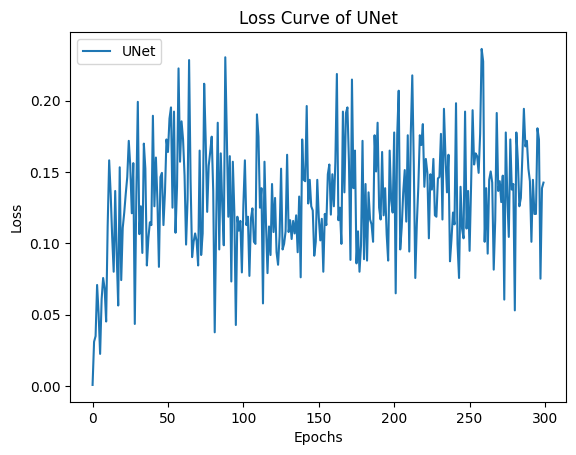

In [7]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['unet']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='UNet')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of UNet')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

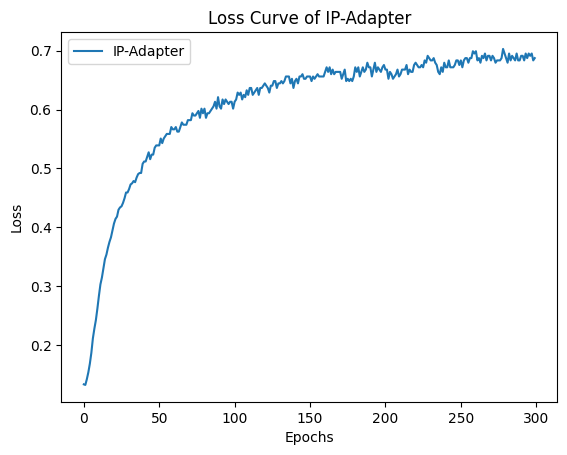

In [8]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IP-Adapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IP-Adapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

## (1*UNet+1*CLIP)+Cosine
- ASPL_ace-plus-ipadapter_VGGFace2_SD15_unet-ipadapter_yingbu_no-agm-w1-1-w2-0-w3-1-w4-0_cosine_eot-1_sds-0_unT-unet-0_fix-unet-0_fix-noise-0

In [9]:
loss_dict_list = [{'loss_sum': 0.1337890625, 'loss': 0.1337890625, 'unet': 0.0007171630859375, 'ipadapter': 0.1328125}, {'loss_sum': 0.1611328125, 'loss': 0.1611328125, 'unet': 0.0140380859375, 'ipadapter': 0.1474609375}, {'loss_sum': 0.1796875, 'loss': 0.1796875, 'unet': 0.01806640625, 'ipadapter': 0.1611328125}, {'loss_sum': 0.224609375, 'loss': 0.224609375, 'unet': 0.043701171875, 'ipadapter': 0.1806640625}, {'loss_sum': 0.220703125, 'loss': 0.220703125, 'unet': 0.0296630859375, 'ipadapter': 0.19140625}, {'loss_sum': 0.220703125, 'loss': 0.220703125, 'unet': 0.0137939453125, 'ipadapter': 0.20703125}, {'loss_sum': 0.2890625, 'loss': 0.2890625, 'unet': 0.06982421875, 'ipadapter': 0.21875}, {'loss_sum': 0.296875, 'loss': 0.296875, 'unet': 0.064453125, 'ipadapter': 0.232421875}, {'loss_sum': 0.3203125, 'loss': 0.3203125, 'unet': 0.07373046875, 'ipadapter': 0.24609375}, {'loss_sum': 0.3203125, 'loss': 0.3203125, 'unet': 0.06201171875, 'ipadapter': 0.2578125}, {'loss_sum': 0.3125, 'loss': 0.3125, 'unet': 0.041015625, 'ipadapter': 0.271484375}, {'loss_sum': 0.37890625, 'loss': 0.37890625, 'unet': 0.0927734375, 'ipadapter': 0.287109375}, {'loss_sum': 0.40234375, 'loss': 0.40234375, 'unet': 0.1005859375, 'ipadapter': 0.302734375}, {'loss_sum': 0.35546875, 'loss': 0.35546875, 'unet': 0.043212890625, 'ipadapter': 0.3125}, {'loss_sum': 0.427734375, 'loss': 0.427734375, 'unet': 0.1015625, 'ipadapter': 0.326171875}, {'loss_sum': 0.47265625, 'loss': 0.47265625, 'unet': 0.13671875, 'ipadapter': 0.3359375}, {'loss_sum': 0.44140625, 'loss': 0.44140625, 'unet': 0.09228515625, 'ipadapter': 0.349609375}, {'loss_sum': 0.46484375, 'loss': 0.46484375, 'unet': 0.107421875, 'ipadapter': 0.357421875}, {'loss_sum': 0.43359375, 'loss': 0.43359375, 'unet': 0.06494140625, 'ipadapter': 0.369140625}, {'loss_sum': 0.5234375, 'loss': 0.5234375, 'unet': 0.1484375, 'ipadapter': 0.375}, {'loss_sum': 0.49609375, 'loss': 0.49609375, 'unet': 0.1103515625, 'ipadapter': 0.38671875}, {'loss_sum': 0.4921875, 'loss': 0.4921875, 'unet': 0.099609375, 'ipadapter': 0.392578125}, {'loss_sum': 0.5859375, 'loss': 0.5859375, 'unet': 0.18359375, 'ipadapter': 0.400390625}, {'loss_sum': 0.5, 'loss': 0.5, 'unet': 0.0888671875, 'ipadapter': 0.41015625}, {'loss_sum': 0.53125, 'loss': 0.53125, 'unet': 0.11865234375, 'ipadapter': 0.4140625}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'unet': 0.1083984375, 'ipadapter': 0.41796875}, {'loss_sum': 0.4921875, 'loss': 0.4921875, 'unet': 0.07373046875, 'ipadapter': 0.41796875}, {'loss_sum': 0.490234375, 'loss': 0.490234375, 'unet': 0.060546875, 'ipadapter': 0.4296875}, {'loss_sum': 0.52734375, 'loss': 0.52734375, 'unet': 0.0908203125, 'ipadapter': 0.4375}, {'loss_sum': 0.5390625, 'loss': 0.5390625, 'unet': 0.09521484375, 'ipadapter': 0.4453125}, {'loss_sum': 0.609375, 'loss': 0.609375, 'unet': 0.1533203125, 'ipadapter': 0.455078125}, {'loss_sum': 0.53125, 'loss': 0.53125, 'unet': 0.07373046875, 'ipadapter': 0.45703125}, {'loss_sum': 0.57421875, 'loss': 0.57421875, 'unet': 0.11181640625, 'ipadapter': 0.462890625}, {'loss_sum': 0.58984375, 'loss': 0.58984375, 'unet': 0.12109375, 'ipadapter': 0.46875}, {'loss_sum': 0.6015625, 'loss': 0.6015625, 'unet': 0.1337890625, 'ipadapter': 0.466796875}, {'loss_sum': 0.6171875, 'loss': 0.6171875, 'unet': 0.14453125, 'ipadapter': 0.474609375}, {'loss_sum': 0.609375, 'loss': 0.609375, 'unet': 0.12890625, 'ipadapter': 0.478515625}, {'loss_sum': 0.61328125, 'loss': 0.61328125, 'unet': 0.1279296875, 'ipadapter': 0.484375}, {'loss_sum': 0.5859375, 'loss': 0.5859375, 'unet': 0.091796875, 'ipadapter': 0.49609375}, {'loss_sum': 0.61328125, 'loss': 0.61328125, 'unet': 0.1181640625, 'ipadapter': 0.494140625}, {'loss_sum': 0.54296875, 'loss': 0.54296875, 'unet': 0.044189453125, 'ipadapter': 0.498046875}, {'loss_sum': 0.62109375, 'loss': 0.62109375, 'unet': 0.1181640625, 'ipadapter': 0.50390625}, {'loss_sum': 0.56640625, 'loss': 0.56640625, 'unet': 0.056396484375, 'ipadapter': 0.51171875}, {'loss_sum': 0.625, 'loss': 0.625, 'unet': 0.11865234375, 'ipadapter': 0.5078125}, {'loss_sum': 0.640625, 'loss': 0.640625, 'unet': 0.126953125, 'ipadapter': 0.515625}, {'loss_sum': 0.65625, 'loss': 0.65625, 'unet': 0.1357421875, 'ipadapter': 0.51953125}, {'loss_sum': 0.671875, 'loss': 0.671875, 'unet': 0.1455078125, 'ipadapter': 0.52734375}, {'loss_sum': 0.59765625, 'loss': 0.59765625, 'unet': 0.06103515625, 'ipadapter': 0.53515625}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'unet': 0.1943359375, 'ipadapter': 0.53125}, {'loss_sum': 0.6796875, 'loss': 0.6796875, 'unet': 0.140625, 'ipadapter': 0.5390625}, {'loss_sum': 0.703125, 'loss': 0.703125, 'unet': 0.1689453125, 'ipadapter': 0.53515625}, {'loss_sum': 0.6484375, 'loss': 0.6484375, 'unet': 0.111328125, 'ipadapter': 0.5390625}, {'loss_sum': 0.7421875, 'loss': 0.7421875, 'unet': 0.2001953125, 'ipadapter': 0.54296875}, {'loss_sum': 0.66796875, 'loss': 0.66796875, 'unet': 0.11572265625, 'ipadapter': 0.55078125}, {'loss_sum': 0.66015625, 'loss': 0.66015625, 'unet': 0.11083984375, 'ipadapter': 0.55078125}, {'loss_sum': 0.66015625, 'loss': 0.66015625, 'unet': 0.1064453125, 'ipadapter': 0.5546875}, {'loss_sum': 0.640625, 'loss': 0.640625, 'unet': 0.08447265625, 'ipadapter': 0.5546875}, {'loss_sum': 0.75, 'loss': 0.75, 'unet': 0.19140625, 'ipadapter': 0.55859375}, {'loss_sum': 0.62890625, 'loss': 0.62890625, 'unet': 0.0673828125, 'ipadapter': 0.5625}, {'loss_sum': 0.6171875, 'loss': 0.6171875, 'unet': 0.06005859375, 'ipadapter': 0.55859375}, {'loss_sum': 0.65234375, 'loss': 0.65234375, 'unet': 0.0888671875, 'ipadapter': 0.5625}, {'loss_sum': 0.67578125, 'loss': 0.67578125, 'unet': 0.10791015625, 'ipadapter': 0.56640625}, {'loss_sum': 0.671875, 'loss': 0.671875, 'unet': 0.1083984375, 'ipadapter': 0.5625}, {'loss_sum': 0.68359375, 'loss': 0.68359375, 'unet': 0.10986328125, 'ipadapter': 0.57421875}, {'loss_sum': 0.7734375, 'loss': 0.7734375, 'unet': 0.193359375, 'ipadapter': 0.58203125}, {'loss_sum': 0.7109375, 'loss': 0.7109375, 'unet': 0.125, 'ipadapter': 0.5859375}, {'loss_sum': 0.68359375, 'loss': 0.68359375, 'unet': 0.1005859375, 'ipadapter': 0.58203125}, {'loss_sum': 0.6796875, 'loss': 0.6796875, 'unet': 0.09375, 'ipadapter': 0.5859375}, {'loss_sum': 0.75390625, 'loss': 0.75390625, 'unet': 0.1650390625, 'ipadapter': 0.58984375}, {'loss_sum': 0.7578125, 'loss': 0.7578125, 'unet': 0.1611328125, 'ipadapter': 0.59765625}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'unet': 0.1455078125, 'ipadapter': 0.59375}, {'loss_sum': 0.765625, 'loss': 0.765625, 'unet': 0.173828125, 'ipadapter': 0.59375}, {'loss_sum': 0.6640625, 'loss': 0.6640625, 'unet': 0.0712890625, 'ipadapter': 0.59375}, {'loss_sum': 0.75390625, 'loss': 0.75390625, 'unet': 0.16015625, 'ipadapter': 0.59375}, {'loss_sum': 0.6640625, 'loss': 0.6640625, 'unet': 0.057861328125, 'ipadapter': 0.60546875}, {'loss_sum': 0.71484375, 'loss': 0.71484375, 'unet': 0.11328125, 'ipadapter': 0.6015625}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'unet': 0.0888671875, 'ipadapter': 0.6015625}, {'loss_sum': 0.765625, 'loss': 0.765625, 'unet': 0.16015625, 'ipadapter': 0.60546875}, {'loss_sum': 0.80078125, 'loss': 0.80078125, 'unet': 0.1875, 'ipadapter': 0.61328125}, {'loss_sum': 0.69921875, 'loss': 0.69921875, 'unet': 0.0849609375, 'ipadapter': 0.61328125}, {'loss_sum': 0.7109375, 'loss': 0.7109375, 'unet': 0.09912109375, 'ipadapter': 0.61328125}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'unet': 0.109375, 'ipadapter': 0.6171875}, {'loss_sum': 0.79296875, 'loss': 0.79296875, 'unet': 0.1689453125, 'ipadapter': 0.625}, {'loss_sum': 0.7578125, 'loss': 0.7578125, 'unet': 0.134765625, 'ipadapter': 0.62109375}, {'loss_sum': 0.74609375, 'loss': 0.74609375, 'unet': 0.12890625, 'ipadapter': 0.6171875}, {'loss_sum': 0.74609375, 'loss': 0.74609375, 'unet': 0.11962890625, 'ipadapter': 0.625}, {'loss_sum': 0.796875, 'loss': 0.796875, 'unet': 0.17578125, 'ipadapter': 0.62109375}, {'loss_sum': 0.79296875, 'loss': 0.79296875, 'unet': 0.1708984375, 'ipadapter': 0.62109375}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'unet': 0.10302734375, 'ipadapter': 0.625}, {'loss_sum': 0.7734375, 'loss': 0.7734375, 'unet': 0.1474609375, 'ipadapter': 0.625}, {'loss_sum': 0.8125, 'loss': 0.8125, 'unet': 0.1865234375, 'ipadapter': 0.625}, {'loss_sum': 0.734375, 'loss': 0.734375, 'unet': 0.10107421875, 'ipadapter': 0.6328125}, {'loss_sum': 0.765625, 'loss': 0.765625, 'unet': 0.130859375, 'ipadapter': 0.6328125}, {'loss_sum': 0.859375, 'loss': 0.859375, 'unet': 0.228515625, 'ipadapter': 0.6328125}, {'loss_sum': 0.8046875, 'loss': 0.8046875, 'unet': 0.1650390625, 'ipadapter': 0.640625}, {'loss_sum': 0.8203125, 'loss': 0.8203125, 'unet': 0.185546875, 'ipadapter': 0.63671875}, {'loss_sum': 0.765625, 'loss': 0.765625, 'unet': 0.12255859375, 'ipadapter': 0.64453125}, {'loss_sum': 0.82421875, 'loss': 0.82421875, 'unet': 0.1845703125, 'ipadapter': 0.640625}, {'loss_sum': 0.74609375, 'loss': 0.74609375, 'unet': 0.1015625, 'ipadapter': 0.64453125}, {'loss_sum': 0.72265625, 'loss': 0.72265625, 'unet': 0.08349609375, 'ipadapter': 0.640625}, {'loss_sum': 0.7734375, 'loss': 0.7734375, 'unet': 0.1318359375, 'ipadapter': 0.640625}, {'loss_sum': 0.7890625, 'loss': 0.7890625, 'unet': 0.1435546875, 'ipadapter': 0.64453125}, {'loss_sum': 0.7578125, 'loss': 0.7578125, 'unet': 0.11181640625, 'ipadapter': 0.64453125}, {'loss_sum': 0.78515625, 'loss': 0.78515625, 'unet': 0.1455078125, 'ipadapter': 0.640625}, {'loss_sum': 0.7578125, 'loss': 0.7578125, 'unet': 0.1171875, 'ipadapter': 0.640625}, {'loss_sum': 0.80078125, 'loss': 0.80078125, 'unet': 0.16015625, 'ipadapter': 0.640625}, {'loss_sum': 0.734375, 'loss': 0.734375, 'unet': 0.09375, 'ipadapter': 0.640625}, {'loss_sum': 0.78125, 'loss': 0.78125, 'unet': 0.1376953125, 'ipadapter': 0.64453125}, {'loss_sum': 0.81640625, 'loss': 0.81640625, 'unet': 0.1669921875, 'ipadapter': 0.6484375}, {'loss_sum': 0.75, 'loss': 0.75, 'unet': 0.095703125, 'ipadapter': 0.65234375}, {'loss_sum': 0.796875, 'loss': 0.796875, 'unet': 0.150390625, 'ipadapter': 0.64453125}, {'loss_sum': 0.828125, 'loss': 0.828125, 'unet': 0.1826171875, 'ipadapter': 0.64453125}, {'loss_sum': 0.78125, 'loss': 0.78125, 'unet': 0.138671875, 'ipadapter': 0.64453125}, {'loss_sum': 0.77734375, 'loss': 0.77734375, 'unet': 0.1337890625, 'ipadapter': 0.64453125}, {'loss_sum': 0.82421875, 'loss': 0.82421875, 'unet': 0.1767578125, 'ipadapter': 0.6484375}, {'loss_sum': 0.90625, 'loss': 0.90625, 'unet': 0.251953125, 'ipadapter': 0.65234375}, {'loss_sum': 0.69140625, 'loss': 0.69140625, 'unet': 0.0341796875, 'ipadapter': 0.65625}, {'loss_sum': 0.8515625, 'loss': 0.8515625, 'unet': 0.197265625, 'ipadapter': 0.65234375}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'unet': 0.09130859375, 'ipadapter': 0.6484375}, {'loss_sum': 0.7734375, 'loss': 0.7734375, 'unet': 0.11572265625, 'ipadapter': 0.65625}, {'loss_sum': 0.75, 'loss': 0.75, 'unet': 0.09814453125, 'ipadapter': 0.65234375}, {'loss_sum': 0.76171875, 'loss': 0.76171875, 'unet': 0.1064453125, 'ipadapter': 0.65625}, {'loss_sum': 0.8828125, 'loss': 0.8828125, 'unet': 0.2216796875, 'ipadapter': 0.66015625}, {'loss_sum': 0.84375, 'loss': 0.84375, 'unet': 0.177734375, 'ipadapter': 0.6640625}, {'loss_sum': 0.78515625, 'loss': 0.78515625, 'unet': 0.12109375, 'ipadapter': 0.6640625}, {'loss_sum': 0.8203125, 'loss': 0.8203125, 'unet': 0.1552734375, 'ipadapter': 0.6640625}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.1708984375, 'ipadapter': 0.6640625}, {'loss_sum': 0.84375, 'loss': 0.84375, 'unet': 0.181640625, 'ipadapter': 0.66015625}, {'loss_sum': 0.828125, 'loss': 0.828125, 'unet': 0.16015625, 'ipadapter': 0.66796875}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.171875, 'ipadapter': 0.6640625}, {'loss_sum': 0.80859375, 'loss': 0.80859375, 'unet': 0.140625, 'ipadapter': 0.66796875}, {'loss_sum': 0.7734375, 'loss': 0.7734375, 'unet': 0.10693359375, 'ipadapter': 0.66796875}, {'loss_sum': 0.73828125, 'loss': 0.73828125, 'unet': 0.06689453125, 'ipadapter': 0.671875}, {'loss_sum': 0.8046875, 'loss': 0.8046875, 'unet': 0.146484375, 'ipadapter': 0.66015625}, {'loss_sum': 0.8515625, 'loss': 0.8515625, 'unet': 0.1845703125, 'ipadapter': 0.66796875}, {'loss_sum': 0.796875, 'loss': 0.796875, 'unet': 0.1259765625, 'ipadapter': 0.671875}, {'loss_sum': 0.796875, 'loss': 0.796875, 'unet': 0.1337890625, 'ipadapter': 0.6640625}, {'loss_sum': 0.8046875, 'loss': 0.8046875, 'unet': 0.134765625, 'ipadapter': 0.66796875}, {'loss_sum': 0.85546875, 'loss': 0.85546875, 'unet': 0.1806640625, 'ipadapter': 0.67578125}, {'loss_sum': 0.75390625, 'loss': 0.75390625, 'unet': 0.0712890625, 'ipadapter': 0.68359375}, {'loss_sum': 0.8203125, 'loss': 0.8203125, 'unet': 0.150390625, 'ipadapter': 0.671875}, {'loss_sum': 0.71484375, 'loss': 0.71484375, 'unet': 0.044189453125, 'ipadapter': 0.671875}, {'loss_sum': 0.77734375, 'loss': 0.77734375, 'unet': 0.10888671875, 'ipadapter': 0.66796875}, {'loss_sum': 0.84375, 'loss': 0.84375, 'unet': 0.16796875, 'ipadapter': 0.67578125}, {'loss_sum': 0.80859375, 'loss': 0.80859375, 'unet': 0.1328125, 'ipadapter': 0.67578125}, {'loss_sum': 0.8125, 'loss': 0.8125, 'unet': 0.142578125, 'ipadapter': 0.671875}, {'loss_sum': 0.87109375, 'loss': 0.87109375, 'unet': 0.1904296875, 'ipadapter': 0.6796875}, {'loss_sum': 0.84765625, 'loss': 0.84765625, 'unet': 0.1728515625, 'ipadapter': 0.67578125}, {'loss_sum': 0.890625, 'loss': 0.890625, 'unet': 0.20703125, 'ipadapter': 0.68359375}, {'loss_sum': 0.859375, 'loss': 0.859375, 'unet': 0.1748046875, 'ipadapter': 0.68359375}, {'loss_sum': 0.796875, 'loss': 0.796875, 'unet': 0.115234375, 'ipadapter': 0.68359375}, {'loss_sum': 0.84375, 'loss': 0.84375, 'unet': 0.1611328125, 'ipadapter': 0.68359375}, {'loss_sum': 0.75390625, 'loss': 0.75390625, 'unet': 0.0673828125, 'ipadapter': 0.6875}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.150390625, 'ipadapter': 0.68359375}, {'loss_sum': 0.80078125, 'loss': 0.80078125, 'unet': 0.11572265625, 'ipadapter': 0.68359375}, {'loss_sum': 0.72265625, 'loss': 0.72265625, 'unet': 0.0400390625, 'ipadapter': 0.68359375}, {'loss_sum': 0.7265625, 'loss': 0.7265625, 'unet': 0.0419921875, 'ipadapter': 0.68359375}, {'loss_sum': 0.859375, 'loss': 0.859375, 'unet': 0.1708984375, 'ipadapter': 0.6875}, {'loss_sum': 0.80078125, 'loss': 0.80078125, 'unet': 0.10986328125, 'ipadapter': 0.69140625}, {'loss_sum': 0.796875, 'loss': 0.796875, 'unet': 0.111328125, 'ipadapter': 0.6875}, {'loss_sum': 0.8515625, 'loss': 0.8515625, 'unet': 0.1630859375, 'ipadapter': 0.6875}, {'loss_sum': 0.84375, 'loss': 0.84375, 'unet': 0.15625, 'ipadapter': 0.6875}, {'loss_sum': 0.84765625, 'loss': 0.84765625, 'unet': 0.1640625, 'ipadapter': 0.68359375}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.1494140625, 'ipadapter': 0.6875}, {'loss_sum': 0.76171875, 'loss': 0.76171875, 'unet': 0.0732421875, 'ipadapter': 0.6875}, {'loss_sum': 0.83984375, 'loss': 0.83984375, 'unet': 0.15625, 'ipadapter': 0.68359375}, {'loss_sum': 0.80859375, 'loss': 0.80859375, 'unet': 0.12109375, 'ipadapter': 0.6875}, {'loss_sum': 0.81640625, 'loss': 0.81640625, 'unet': 0.12890625, 'ipadapter': 0.6875}, {'loss_sum': 0.86328125, 'loss': 0.86328125, 'unet': 0.1796875, 'ipadapter': 0.68359375}, {'loss_sum': 0.859375, 'loss': 0.859375, 'unet': 0.173828125, 'ipadapter': 0.6875}, {'loss_sum': 0.7890625, 'loss': 0.7890625, 'unet': 0.09423828125, 'ipadapter': 0.6953125}, {'loss_sum': 0.8203125, 'loss': 0.8203125, 'unet': 0.13671875, 'ipadapter': 0.68359375}, {'loss_sum': 0.91015625, 'loss': 0.91015625, 'unet': 0.22265625, 'ipadapter': 0.6875}, {'loss_sum': 0.87890625, 'loss': 0.87890625, 'unet': 0.1826171875, 'ipadapter': 0.6953125}, {'loss_sum': 0.8046875, 'loss': 0.8046875, 'unet': 0.11376953125, 'ipadapter': 0.69140625}, {'loss_sum': 0.890625, 'loss': 0.890625, 'unet': 0.203125, 'ipadapter': 0.6875}, {'loss_sum': 0.86328125, 'loss': 0.86328125, 'unet': 0.1728515625, 'ipadapter': 0.69140625}, {'loss_sum': 0.83203125, 'loss': 0.83203125, 'unet': 0.1376953125, 'ipadapter': 0.6953125}, {'loss_sum': 0.8203125, 'loss': 0.8203125, 'unet': 0.12451171875, 'ipadapter': 0.6953125}, {'loss_sum': 0.80078125, 'loss': 0.80078125, 'unet': 0.1005859375, 'ipadapter': 0.69921875}, {'loss_sum': 0.7890625, 'loss': 0.7890625, 'unet': 0.10009765625, 'ipadapter': 0.6875}, {'loss_sum': 0.91796875, 'loss': 0.91796875, 'unet': 0.2216796875, 'ipadapter': 0.6953125}, {'loss_sum': 0.87890625, 'loss': 0.87890625, 'unet': 0.1748046875, 'ipadapter': 0.703125}, {'loss_sum': 0.8125, 'loss': 0.8125, 'unet': 0.1171875, 'ipadapter': 0.6953125}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.1416015625, 'ipadapter': 0.6953125}, {'loss_sum': 0.765625, 'loss': 0.765625, 'unet': 0.064453125, 'ipadapter': 0.69921875}, {'loss_sum': 0.8671875, 'loss': 0.8671875, 'unet': 0.169921875, 'ipadapter': 0.69921875}, {'loss_sum': 0.8671875, 'loss': 0.8671875, 'unet': 0.1650390625, 'ipadapter': 0.703125}, {'loss_sum': 0.94140625, 'loss': 0.94140625, 'unet': 0.234375, 'ipadapter': 0.70703125}, {'loss_sum': 0.8125, 'loss': 0.8125, 'unet': 0.10888671875, 'ipadapter': 0.703125}, {'loss_sum': 0.8125, 'loss': 0.8125, 'unet': 0.11767578125, 'ipadapter': 0.6953125}, {'loss_sum': 0.796875, 'loss': 0.796875, 'unet': 0.09423828125, 'ipadapter': 0.703125}, {'loss_sum': 0.828125, 'loss': 0.828125, 'unet': 0.1259765625, 'ipadapter': 0.703125}, {'loss_sum': 0.796875, 'loss': 0.796875, 'unet': 0.0966796875, 'ipadapter': 0.69921875}, {'loss_sum': 0.8203125, 'loss': 0.8203125, 'unet': 0.119140625, 'ipadapter': 0.703125}, {'loss_sum': 0.8828125, 'loss': 0.8828125, 'unet': 0.177734375, 'ipadapter': 0.703125}, {'loss_sum': 0.828125, 'loss': 0.828125, 'unet': 0.126953125, 'ipadapter': 0.69921875}, {'loss_sum': 0.890625, 'loss': 0.890625, 'unet': 0.1826171875, 'ipadapter': 0.70703125}, {'loss_sum': 0.8828125, 'loss': 0.8828125, 'unet': 0.1796875, 'ipadapter': 0.703125}, {'loss_sum': 0.9296875, 'loss': 0.9296875, 'unet': 0.216796875, 'ipadapter': 0.7109375}, {'loss_sum': 0.9140625, 'loss': 0.9140625, 'unet': 0.2119140625, 'ipadapter': 0.703125}, {'loss_sum': 0.8203125, 'loss': 0.8203125, 'unet': 0.111328125, 'ipadapter': 0.70703125}, {'loss_sum': 0.828125, 'loss': 0.828125, 'unet': 0.12060546875, 'ipadapter': 0.70703125}, {'loss_sum': 0.828125, 'loss': 0.828125, 'unet': 0.1298828125, 'ipadapter': 0.69921875}, {'loss_sum': 0.91015625, 'loss': 0.91015625, 'unet': 0.2060546875, 'ipadapter': 0.703125}, {'loss_sum': 0.75, 'loss': 0.75, 'unet': 0.04052734375, 'ipadapter': 0.7109375}, {'loss_sum': 0.8046875, 'loss': 0.8046875, 'unet': 0.10205078125, 'ipadapter': 0.703125}, {'loss_sum': 0.83203125, 'loss': 0.83203125, 'unet': 0.12109375, 'ipadapter': 0.7109375}, {'loss_sum': 0.9140625, 'loss': 0.9140625, 'unet': 0.205078125, 'ipadapter': 0.70703125}, {'loss_sum': 0.80859375, 'loss': 0.80859375, 'unet': 0.09521484375, 'ipadapter': 0.71484375}, {'loss_sum': 0.80859375, 'loss': 0.80859375, 'unet': 0.10009765625, 'ipadapter': 0.70703125}, {'loss_sum': 0.8125, 'loss': 0.8125, 'unet': 0.10009765625, 'ipadapter': 0.7109375}, {'loss_sum': 0.8203125, 'loss': 0.8203125, 'unet': 0.10986328125, 'ipadapter': 0.7109375}, {'loss_sum': 0.87109375, 'loss': 0.87109375, 'unet': 0.16015625, 'ipadapter': 0.7109375}, {'loss_sum': 0.8203125, 'loss': 0.8203125, 'unet': 0.1083984375, 'ipadapter': 0.7109375}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.12060546875, 'ipadapter': 0.71484375}, {'loss_sum': 0.9453125, 'loss': 0.9453125, 'unet': 0.23046875, 'ipadapter': 0.71484375}, {'loss_sum': 0.9296875, 'loss': 0.9296875, 'unet': 0.20703125, 'ipadapter': 0.72265625}, {'loss_sum': 0.9140625, 'loss': 0.9140625, 'unet': 0.197265625, 'ipadapter': 0.71875}, {'loss_sum': 0.828125, 'loss': 0.828125, 'unet': 0.10400390625, 'ipadapter': 0.72265625}, {'loss_sum': 0.8828125, 'loss': 0.8828125, 'unet': 0.1728515625, 'ipadapter': 0.7109375}, {'loss_sum': 0.890625, 'loss': 0.890625, 'unet': 0.169921875, 'ipadapter': 0.71875}, {'loss_sum': 0.90625, 'loss': 0.90625, 'unet': 0.1875, 'ipadapter': 0.71875}, {'loss_sum': 0.85546875, 'loss': 0.85546875, 'unet': 0.1318359375, 'ipadapter': 0.72265625}, {'loss_sum': 0.890625, 'loss': 0.890625, 'unet': 0.1708984375, 'ipadapter': 0.71875}, {'loss_sum': 0.953125, 'loss': 0.953125, 'unet': 0.2314453125, 'ipadapter': 0.72265625}, {'loss_sum': 0.890625, 'loss': 0.890625, 'unet': 0.1640625, 'ipadapter': 0.7265625}, {'loss_sum': 0.87109375, 'loss': 0.87109375, 'unet': 0.1572265625, 'ipadapter': 0.71484375}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.11669921875, 'ipadapter': 0.71875}, {'loss_sum': 0.81640625, 'loss': 0.81640625, 'unet': 0.0927734375, 'ipadapter': 0.72265625}, {'loss_sum': 0.84765625, 'loss': 0.84765625, 'unet': 0.12451171875, 'ipadapter': 0.72265625}, {'loss_sum': 0.921875, 'loss': 0.921875, 'unet': 0.1943359375, 'ipadapter': 0.7265625}, {'loss_sum': 0.8828125, 'loss': 0.8828125, 'unet': 0.1572265625, 'ipadapter': 0.7265625}, {'loss_sum': 0.80078125, 'loss': 0.80078125, 'unet': 0.07763671875, 'ipadapter': 0.72265625}, {'loss_sum': 0.80859375, 'loss': 0.80859375, 'unet': 0.08642578125, 'ipadapter': 0.72265625}, {'loss_sum': 0.86328125, 'loss': 0.86328125, 'unet': 0.14453125, 'ipadapter': 0.71875}, {'loss_sum': 0.8671875, 'loss': 0.8671875, 'unet': 0.146484375, 'ipadapter': 0.72265625}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.1123046875, 'ipadapter': 0.72265625}, {'loss_sum': 0.88671875, 'loss': 0.88671875, 'unet': 0.1728515625, 'ipadapter': 0.71484375}, {'loss_sum': 0.81640625, 'loss': 0.81640625, 'unet': 0.0908203125, 'ipadapter': 0.7265625}, {'loss_sum': 0.8828125, 'loss': 0.8828125, 'unet': 0.1640625, 'ipadapter': 0.71875}, {'loss_sum': 0.85546875, 'loss': 0.85546875, 'unet': 0.1298828125, 'ipadapter': 0.7265625}, {'loss_sum': 0.84375, 'loss': 0.84375, 'unet': 0.12109375, 'ipadapter': 0.72265625}, {'loss_sum': 0.82421875, 'loss': 0.82421875, 'unet': 0.1015625, 'ipadapter': 0.72265625}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.11376953125, 'ipadapter': 0.72265625}, {'loss_sum': 0.86328125, 'loss': 0.86328125, 'unet': 0.140625, 'ipadapter': 0.72265625}, {'loss_sum': 0.83984375, 'loss': 0.83984375, 'unet': 0.11962890625, 'ipadapter': 0.71875}, {'loss_sum': 0.91015625, 'loss': 0.91015625, 'unet': 0.1826171875, 'ipadapter': 0.7265625}, {'loss_sum': 0.81640625, 'loss': 0.81640625, 'unet': 0.08447265625, 'ipadapter': 0.73046875}, {'loss_sum': 0.859375, 'loss': 0.859375, 'unet': 0.138671875, 'ipadapter': 0.71875}, {'loss_sum': 0.8828125, 'loss': 0.8828125, 'unet': 0.15234375, 'ipadapter': 0.73046875}, {'loss_sum': 0.8671875, 'loss': 0.8671875, 'unet': 0.134765625, 'ipadapter': 0.734375}, {'loss_sum': 0.91796875, 'loss': 0.91796875, 'unet': 0.18359375, 'ipadapter': 0.734375}, {'loss_sum': 0.82421875, 'loss': 0.82421875, 'unet': 0.08984375, 'ipadapter': 0.734375}, {'loss_sum': 0.81640625, 'loss': 0.81640625, 'unet': 0.08935546875, 'ipadapter': 0.7265625}, {'loss_sum': 0.8671875, 'loss': 0.8671875, 'unet': 0.1337890625, 'ipadapter': 0.734375}, {'loss_sum': 0.8046875, 'loss': 0.8046875, 'unet': 0.06591796875, 'ipadapter': 0.73828125}, {'loss_sum': 0.8828125, 'loss': 0.8828125, 'unet': 0.1533203125, 'ipadapter': 0.73046875}, {'loss_sum': 0.9453125, 'loss': 0.9453125, 'unet': 0.212890625, 'ipadapter': 0.734375}, {'loss_sum': 0.875, 'loss': 0.875, 'unet': 0.140625, 'ipadapter': 0.734375}, {'loss_sum': 0.83203125, 'loss': 0.83203125, 'unet': 0.09375, 'ipadapter': 0.73828125}, {'loss_sum': 0.890625, 'loss': 0.890625, 'unet': 0.158203125, 'ipadapter': 0.734375}, {'loss_sum': 0.91796875, 'loss': 0.91796875, 'unet': 0.1796875, 'ipadapter': 0.73828125}, {'loss_sum': 0.9453125, 'loss': 0.9453125, 'unet': 0.205078125, 'ipadapter': 0.73828125}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.09912109375, 'ipadapter': 0.73828125}, {'loss_sum': 0.9140625, 'loss': 0.9140625, 'unet': 0.185546875, 'ipadapter': 0.73046875}, {'loss_sum': 0.875, 'loss': 0.875, 'unet': 0.138671875, 'ipadapter': 0.734375}, {'loss_sum': 0.7890625, 'loss': 0.7890625, 'unet': 0.052734375, 'ipadapter': 0.734375}, {'loss_sum': 0.859375, 'loss': 0.859375, 'unet': 0.1279296875, 'ipadapter': 0.73046875}, {'loss_sum': 0.8671875, 'loss': 0.8671875, 'unet': 0.1279296875, 'ipadapter': 0.73828125}, {'loss_sum': 0.9609375, 'loss': 0.9609375, 'unet': 0.2255859375, 'ipadapter': 0.734375}, {'loss_sum': 0.8671875, 'loss': 0.8671875, 'unet': 0.123046875, 'ipadapter': 0.7421875}, {'loss_sum': 0.8671875, 'loss': 0.8671875, 'unet': 0.1318359375, 'ipadapter': 0.734375}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.0986328125, 'ipadapter': 0.73828125}, {'loss_sum': 0.921875, 'loss': 0.921875, 'unet': 0.1884765625, 'ipadapter': 0.734375}, {'loss_sum': 0.875, 'loss': 0.875, 'unet': 0.1279296875, 'ipadapter': 0.74609375}, {'loss_sum': 0.88671875, 'loss': 0.88671875, 'unet': 0.1494140625, 'ipadapter': 0.73828125}, {'loss_sum': 0.875, 'loss': 0.875, 'unet': 0.138671875, 'ipadapter': 0.73828125}, {'loss_sum': 0.921875, 'loss': 0.921875, 'unet': 0.181640625, 'ipadapter': 0.73828125}, {'loss_sum': 0.93359375, 'loss': 0.93359375, 'unet': 0.1953125, 'ipadapter': 0.73828125}, {'loss_sum': 0.890625, 'loss': 0.890625, 'unet': 0.1474609375, 'ipadapter': 0.7421875}, {'loss_sum': 0.92578125, 'loss': 0.92578125, 'unet': 0.1875, 'ipadapter': 0.73828125}, {'loss_sum': 0.87890625, 'loss': 0.87890625, 'unet': 0.1337890625, 'ipadapter': 0.74609375}, {'loss_sum': 0.95703125, 'loss': 0.95703125, 'unet': 0.21875, 'ipadapter': 0.73828125}, {'loss_sum': 0.8984375, 'loss': 0.8984375, 'unet': 0.1513671875, 'ipadapter': 0.74609375}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.09228515625, 'ipadapter': 0.7421875}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.1005859375, 'ipadapter': 0.734375}, {'loss_sum': 0.8828125, 'loss': 0.8828125, 'unet': 0.1416015625, 'ipadapter': 0.7421875}, {'loss_sum': 0.90625, 'loss': 0.90625, 'unet': 0.166015625, 'ipadapter': 0.7421875}, {'loss_sum': 0.8515625, 'loss': 0.8515625, 'unet': 0.1181640625, 'ipadapter': 0.734375}, {'loss_sum': 0.875, 'loss': 0.875, 'unet': 0.140625, 'ipadapter': 0.734375}, {'loss_sum': 0.8828125, 'loss': 0.8828125, 'unet': 0.146484375, 'ipadapter': 0.734375}, {'loss_sum': 0.80859375, 'loss': 0.80859375, 'unet': 0.08154296875, 'ipadapter': 0.7265625}, {'loss_sum': 0.8515625, 'loss': 0.8515625, 'unet': 0.11767578125, 'ipadapter': 0.734375}, {'loss_sum': 0.8203125, 'loss': 0.8203125, 'unet': 0.08447265625, 'ipadapter': 0.734375}, {'loss_sum': 0.859375, 'loss': 0.859375, 'unet': 0.12890625, 'ipadapter': 0.73046875}, {'loss_sum': 0.90234375, 'loss': 0.90234375, 'unet': 0.1630859375, 'ipadapter': 0.73828125}, {'loss_sum': 0.83203125, 'loss': 0.83203125, 'unet': 0.0966796875, 'ipadapter': 0.734375}, {'loss_sum': 0.8359375, 'loss': 0.8359375, 'unet': 0.09765625, 'ipadapter': 0.73828125}, {'loss_sum': 0.88671875, 'loss': 0.88671875, 'unet': 0.1533203125, 'ipadapter': 0.734375}]


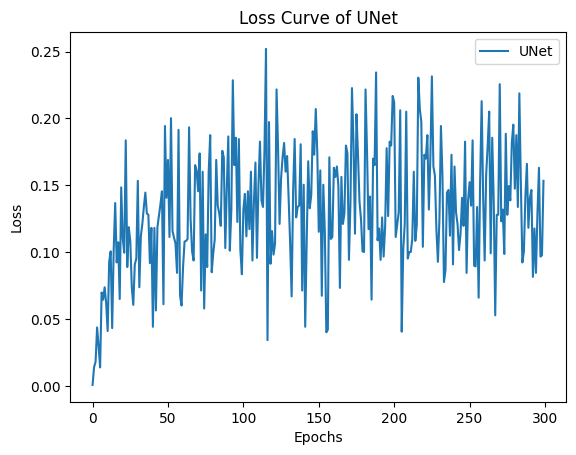

In [10]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['unet']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='UNet')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of UNet')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()

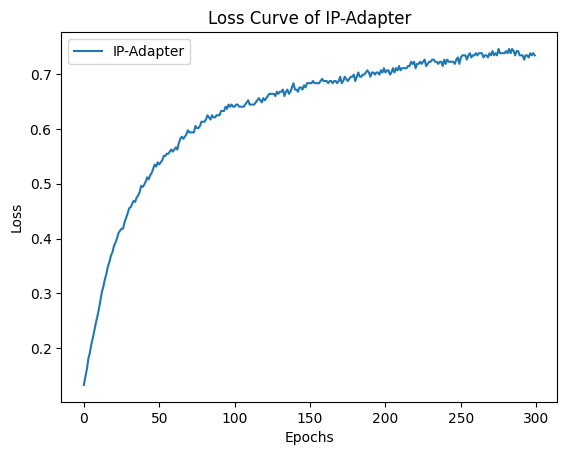

In [11]:
import matplotlib.pyplot as plt

loss_list = list()
for loss_dict in loss_dict_list:
    loss_ipadapter = loss_dict['ipadapter']
    # print(loss_ipadapter)
    loss_list.append(loss_ipadapter)
# 绘制损失函数曲线，横坐标是轮次，纵坐标是损失值
plt.plot(range(len(loss_list)), loss_list, label='IP-Adapter')
# 设置图表标题和坐标轴标签
plt.title('Loss Curve of IP-Adapter')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# 显示图例
plt.legend()
# 显示图表
plt.show()